# 📊 Intro to Statistics: Zero to Hero (for Machine Learning)
## A refresher that assumes you have forgotten all of it

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
![Python](https://img.shields.io/badge/Python-3.10+-blue.svg)
![No installs](https://img.shields.io/badge/installs-none%20needed-brightgreen.svg)
![Prereqs](https://img.shields.io/badge/prerequisites-none-brightgreen.svg)
![Level](https://img.shields.io/badge/level-zero%20to%20hero-orange.svg)

---
<div style="background: linear-gradient(135deg, #42275a 0%, #734b6d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### Statistics is one question, asked over and over.

**"I measured a few. What can I say about all of them?"**

You cannot test your model on every input it will ever see. You cannot survey every user. You measured forty people and you want to say something about two hundred thousand. Everything in this notebook — averages, confidence intervals, p-values, t-tests, cross-validation — is machinery for answering that one question *honestly*, which mostly means being clear about how wrong you might be.

The awkward part is that the honest answer is never a number. It is a number **with a range attached**, and the range is the actual content. A result reported without one is not a stronger result; it is an unfinished one.

This notebook has an unusual advantage: **we simulate the whole population**, so you can always check. Every estimate you make gets compared against the truth you are not supposed to know. When a method works, you will see it work. When it fails, you will see that too.


</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📖 Who this is for, and how it works

**For you if** you can compute an average, have nodded along to "p < 0.05", and could not explain what a confidence interval actually claims — and you now want to evaluate models honestly.

**No prerequisites.** Part 1 starts at the mean. Every symbol is named in words the first time.

**We can see the population.** That is this notebook's trick. Real statistics is inference in the dark; here we keep the lights on, so every method can be checked against the answer it is trying to find.

**Simulation over formulas.** Where a formula and a simulation both give an answer, we show both. If they disagree, we investigate rather than trusting the algebra.

</div>

## 🎯 What you will be able to do

1. **Describe a dataset** — centre, spread, shape — and know when the mean is the wrong summary.
2. **Say what a sample is** and why a sample statistic is not the thing you want.
3. **Explain the Central Limit Theorem** and why it makes so much else possible.
4. **Build and correctly interpret a confidence interval** — including what it does *not* say.
5. **Run a hypothesis test** and state precisely what a p-value is and is not.
6. **Compare two groups** and report an effect size, not just significance.
7. **Fit a regression line** and read what it does and does not establish.
8. **Recognise the traps**: multiple comparisons, p-hacking, Simpson's paradox.
9. **Evaluate a model honestly** — train/test, cross-validation, and error bars on a score.

---
## 🗺️ The Ten Parts

This is a **refresher that assumes you have forgotten everything**. Part 1 starts at what a function is. Nothing later depends on anything we did not build earlier, and every rule is derived before it is used.

| Part | What it covers | |
|---|---|---|
| **0** | Why statistics, and the sample we study |  &larr; **you are here**
| **1** | Describing data: centre, spread, and shape |
| **2** | Populations, samples, and why the difference bites |
| **3** | Sampling distributions and the Central Limit Theorem |
| **4** | Confidence intervals: honest uncertainty |
| **5** | Hypothesis testing, and what a p-value is not |
| **6** | Comparing groups: t-tests and effect size |
| **7** | Correlation, regression, and the line of best fit |
| **8** | The traps: multiple comparisons, p-hacking, Simpson's paradox |
| **9** | Statistics doing ML: train/test, cross-validation, and honest evaluation |

Parts 1-3 are the ideas. Parts 4-5 make derivatives usable. Parts 6-7 do the same for integrals and then show the two are one idea. Parts 8-9 are where it becomes machine learning.


## ⚙️ Setup

Nothing to install.

In [1]:
# ============================================================
#  Setup -- no installs, no downloads, no network.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.3
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11

C_F, C_SLOPE, C_AREA = "#2563EB", "#DC2626", "#059669"
C_APPROX, C_EXACT, C_GREY, C_SOFT = "#D97706", "#7C3AED", "#6B7280", "#E5E7EB"


print(f"numpy {np.__version__}")


numpy 2.2.6


---

# 0️⃣ A population you can see

Two hundred thousand people's reaction times, in milliseconds. We generate them,
which means we know the true mean and the true spread **exactly**.

That is not how statistics normally works, and the difference matters. In a real
study the population mean is a fixed number you will never learn; the whole
apparatus of standard errors and intervals exists to reason about it in the
dark. Here we keep the lights on — so when you build a confidence interval in
Part 4, you can check whether it actually contains the truth, and when you run a
test in Part 5, you can check whether it reaches the right conclusion.

The distribution is deliberately **skewed**, not a neat bell curve — reaction
times cannot be negative and have a long right tail of people who were
distracted. That skew matters immediately, in Part 1, for whether the mean is
even the right summary.


In [2]:
# ============================================================
#  The running example -- a population we can actually SEE.
#  Statistics is about guessing a population from a sample.
#  Normally you never see the population. Here we simulate it,
#  so every estimate can be checked against the truth.
# ============================================================
import numpy as np

RNG = np.random.default_rng(23)

# THE POPULATION: reaction times (ms) of 200,000 people. We know these
# numbers exactly. A real study never would -- that is the whole problem.
POP_N   = 200_000
POP     = RNG.lognormal(mean=np.log(280), sigma=0.28, size=POP_N)
POP_MU  = POP.mean()
POP_SD  = POP.std(ddof=0)

# A SAMPLE: what a real study actually collects.
SAMPLE_N = 40
sample   = RNG.choice(POP, SAMPLE_N, replace=False)

print(f"population : {POP_N:,} people")
print(f"  true mean          mu = {POP_MU:8.2f} ms   <- normally UNKNOWABLE")
print(f"  true sd         sigma = {POP_SD:8.2f} ms")
print()
print(f"one sample of {SAMPLE_N}:")
print(f"  sample mean     x-bar = {sample.mean():8.2f} ms")
print(f"  sample sd           s = {sample.std(ddof=1):8.2f} ms")
print(f"  off by                {sample.mean() - POP_MU:+8.2f} ms")


population : 200,000 people
  true mean          mu =   290.99 ms   <- normally UNKNOWABLE
  true sd         sigma =    83.01 ms

one sample of 40:
  sample mean     x-bar =   280.85 ms
  sample sd           s =    74.36 ms
  off by                  -10.14 ms


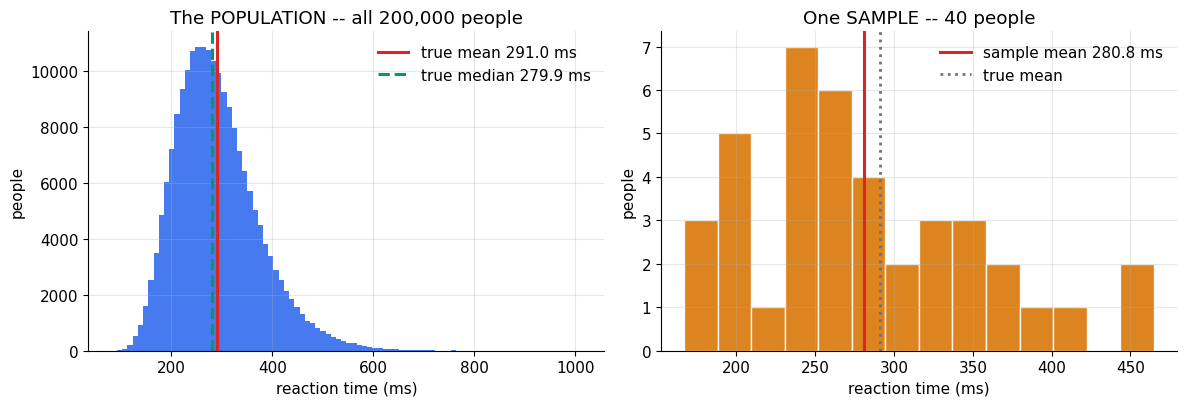

true mean   mu    =   290.99 ms
sample mean x-bar =   280.85 ms
error             =   -10.14 ms (3.48% off)

Take another sample and you get a different answer. That variability
is not a flaw in the method -- it IS the subject.


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

ax1.hist(POP, bins=90, color=C_F, alpha=0.85)
ax1.axvline(POP_MU, color=C_SLOPE, lw=2.2, label=f"true mean {POP_MU:.1f} ms")
ax1.axvline(np.median(POP), color=C_AREA, lw=2.2, ls="--",
            label=f"true median {np.median(POP):.1f} ms")
ax1.set_title(f"The POPULATION -- all {POP_N:,} people")
ax1.set_xlabel("reaction time (ms)"); ax1.set_ylabel("people")
ax1.legend(frameon=False)

ax2.hist(sample, bins=14, color=C_APPROX, alpha=0.9, edgecolor="white")
ax2.axvline(sample.mean(), color=C_SLOPE, lw=2.2,
            label=f"sample mean {sample.mean():.1f} ms")
ax2.axvline(POP_MU, color=C_GREY, lw=2.0, ls=":", label="true mean")
ax2.set_title(f"One SAMPLE -- {SAMPLE_N} people")
ax2.set_xlabel("reaction time (ms)"); ax2.set_ylabel("people")
ax2.legend(frameon=False)

fig.tight_layout(); plt.show()

print(f"true mean   mu    = {POP_MU:8.2f} ms")
print(f"sample mean x-bar = {sample.mean():8.2f} ms")
print(f"error             = {sample.mean() - POP_MU:+8.2f} ms "
      f"({abs(sample.mean() - POP_MU) / POP_MU:.2%} off)")
print()
print("Take another sample and you get a different answer. That variability")
print("is not a flaw in the method -- it IS the subject.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: all 200,000 people. The distribution leans right — a long tail of slow reactions — so the mean (solid red) sits noticeably **above** the median (dashed green). For a symmetric bell curve they would coincide; here the tail drags the mean.

Right: the forty people a real study would actually have. Same underlying population, but lumpy and irregular, and its mean misses the truth by the printed amount. Nothing went wrong — that is simply what forty draws look like.

**The common misread:** looking at the right panel and concluding the population is bumpy or multi-peaked. It is not. Those bumps are sampling noise, and re-running with a different seed produces different bumps in different places. Distinguishing real structure from noise like this is most of what the rest of this notebook is for.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Population** = everyone you care about. Its mean is written $\mu$ ("mu") and its standard deviation $\sigma$ ("sigma"). These are fixed numbers you almost never know.

**Sample** = the few you actually measured. Its mean is $\bar{x}$ ("x-bar") and its standard deviation $s$. These you can compute — and they change every time you take a new sample.

Greek letters for the truth, Latin letters for your estimate of it. That convention is nearly universal and it is worth learning now, because it makes every formula later tell you which side of the divide it is on.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

Your test-set accuracy is a **sample statistic**. The number you actually want — how the model performs on data it has never seen, in general — is a population parameter you will never observe.

So "93.2% accuracy" is an estimate with uncertainty attached, and two models scoring 93.2% and 92.8% on the same test set may well be indistinguishable. Part 9 makes that concrete: it puts an honest error bar on a model score and asks whether a difference is real.

</div>

### Notation, once, up front

| Written | Said aloud | Means |
|---|---|---|
| $\mu$ | "mu" | the **population** mean — usually unknown |
| $\sigma$ | "sigma" | the population standard deviation |
| $\bar{x}$ | "x-bar" | the **sample** mean — computed from data |
| $s$ | "s" | the sample standard deviation |
| $n$ | "n" | how many are in the sample |
| $\hat{\theta}$ | "theta hat" | an **estimate** of something — the hat means estimate |
| $H_0$ | "H nought" | the null hypothesis (Part 5) |

The hat and the Greek/Latin split carry real information. When you see
$\hat{\mu}$, someone is telling you this is a guess at $\mu$, not $\mu$ itself —
and keeping that distinction visible is most of what it means to do statistics
honestly.

---


---

# 1️⃣ Describing data: centre, spread, and shape

Before you can *infer* anything you have to be able to *describe* what is in
front of you. That sounds like the boring part. It is not — it is where most
real errors happen, because a summary is a deliberate act of throwing
information away, and if you throw away the wrong information nothing you do
later can recover it.

Three questions, asked of any pile of numbers:

| Question | Called | We compute |
|---|---|---|
| Where is it? | **centre** | mean, median, mode |
| How spread out is it? | **spread** | range, IQR, variance, standard deviation |
| What shape is it? | **shape** | skewness, kurtosis, quantiles |

Our population is **skewed**, on purpose. That single fact is enough to make
the most familiar summary of all — the average — the wrong thing to report,
and the rest of this part is largely about showing you exactly how and why.

## 1.1 Centre: three different meanings of "typical"

Ask for "the typical reaction time" and you have asked an ambiguous question.
There are three standard answers and they are not the same number.

- The **mean** is the balance point. Add everything up, divide by how many.
- The **median** is the middle. Sort the values, take the one in the centre.
- The **mode** is the most common. The peak of the histogram.

We will compute all three from the definition — no library — and then check
against numpy, so you can see the definition *is* the function.


In [4]:
# ---- the three centres, written out from the definition -------------------

def mean_by_hand(x):
    total = 0.0
    for v in x:                 # deliberately the slow, literal version
        total += v
    return total / len(x)

def median_by_hand(x):
    s = sorted(x)
    n = len(s)
    mid = n // 2
    if n % 2 == 1:              # odd: there IS a middle value
        return s[mid]
    return (s[mid - 1] + s[mid]) / 2   # even: average the two middles

def mode_by_hand(x, bins=60):
    # Continuous measurements essentially never repeat, so "most common value"
    # is meaningless as stated. The usable version: which BIN is fullest?
    counts, edges = np.histogram(x, bins=bins)
    k = counts.argmax()
    return (edges[k] + edges[k + 1]) / 2

print("on the sample of 40")
print(f"  mean   by hand {mean_by_hand(sample):8.3f}   numpy {np.mean(sample):8.3f}")
print(f"  median by hand {median_by_hand(sample):8.3f}   numpy {np.median(sample):8.3f}")
print(f"  mode   (binned){mode_by_hand(sample):8.3f}")
print()
print("agreement with numpy:",
      np.isclose(mean_by_hand(sample), np.mean(sample)),
      np.isclose(median_by_hand(sample), np.median(sample)))


on the sample of 40
  mean   by hand  280.850   numpy  280.850
  median by hand  269.296   numpy  269.296
  mode   (binned) 243.878

agreement with numpy: True True


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words


The **mean** of $n$ numbers $x_1, x_2, \dots, x_n$ is written

$$\bar{x} \;=\; \frac{1}{n}\sum_{i=1}^{n} x_i$$

and every symbol in it is doing something ordinary. The $\sum$ ("sigma", capital
S for *sum*) says *add these up*; $i=1$ underneath and $n$ on top say *starting
at the first, ending at the last*; $x_i$ is "the $i$-th number". So the whole
expression reads: **add all $n$ of them, then divide by $n$.** That is it.

The **median** has no formula worth writing, only a procedure: sort, take the
middle. That is precisely why it behaves so differently — it looks at the
*order* of your data, not the *values*.


</div>

### The mean and the median disagree — and the gap is information

On a symmetric bell curve, mean and median land on the same spot. Our
population is not symmetric: it has a long right tail of slow reactions, and
that tail pulls the mean upward while the median barely notices.

Because we can see the whole population, we can measure the gap exactly rather
than argue about it.


In [5]:
pop_mean   = POP.mean()
pop_median = np.median(POP)
gap        = pop_mean - pop_median

print("THE WHOLE POPULATION (200,000 people)")
print(f"  mean   = {pop_mean:8.2f} ms")
print(f"  median = {pop_median:8.2f} ms")
print(f"  gap    = {gap:+8.2f} ms   (mean sits {gap / pop_median:.2%} above the median)")
print()

# How many people are actually BELOW the mean? On a symmetric distribution
# it would be half. Here it is not, and that is the whole objection to the mean.
below = (POP < pop_mean).mean()
print(f"  fraction of people FASTER than the mean   : {below:.3%}")
print(f"  fraction of people FASTER than the median : {(POP < pop_median).mean():.3%}")
print()
print("The median is the value that splits the population in half, by")
print("construction. The mean makes no such promise -- and here it breaks it")
print(f"by {abs(below - 0.5) * 100:.1f} percentage points.")


THE WHOLE POPULATION (200,000 people)
  mean   =   290.99 ms
  median =   279.95 ms
  gap    =   +11.04 ms   (mean sits 3.94% above the median)

  fraction of people FASTER than the mean   : 55.489%
  fraction of people FASTER than the median : 50.000%

The median is the value that splits the population in half, by
construction. The mean makes no such promise -- and here it breaks it
by 5.5 percentage points.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted


We did not *assert* that the mean sits above the median on right-skewed data —
we computed both on all 200,000 people and printed the gap. And we did not
assert that "the mean splits the data in half" is false; we counted the people
on each side of it and printed the fraction.

That is the pattern for the whole notebook. Any claim that can be checked
against the population **is** checked against the population.


</div>

### The killer demo: one bad measurement

Suppose one person in your study of forty was distracted — phone rang, sneezed,
walked away — and their recorded reaction time is 10,000 ms. Ten seconds.
Obviously not a reaction time.

You now have 41 numbers. Watch what each summary does.


In [6]:
OUTLIER = 10_000.0
contaminated = np.append(sample, OUTLIER)

rows = [
    ("mean",   np.mean(sample),        np.mean(contaminated)),
    ("median", np.median(sample),      np.median(contaminated)),
    ("mode",   mode_by_hand(sample),   mode_by_hand(contaminated)),
]

print(f"one value of {OUTLIER:,.0f} ms added to {SAMPLE_N} clean measurements\n")
print(f"{'statistic':<10}{'before':>12}{'after':>12}{'moved by':>12}{'  as % of before':>18}")
print("-" * 64)
for name, before, after in rows:
    print(f"{name:<10}{before:>12.2f}{after:>12.2f}{after - before:>+12.2f}"
          f"{(after - before) / before:>17.2%}")

print()
print(f"true population mean : {POP_MU:.2f} ms")
print(f"contaminated mean    : {np.mean(contaminated):.2f} ms  "
      f"-> off by {np.mean(contaminated) - POP_MU:+.2f} ms")
print(f"contaminated median  : {np.median(contaminated):.2f} ms  "
      f"-> off by {np.median(contaminated) - np.median(POP):+.2f} ms from the true median")


one value of 10,000 ms added to 40 clean measurements

statistic       before       after    moved by    as % of before
----------------------------------------------------------------
mean            280.85      517.90     +237.05           84.41%
median          269.30      270.05       +0.75            0.28%
mode            243.88      248.92       +5.04            2.07%

true population mean : 290.99 ms
contaminated mean    : 517.90 ms  -> off by +226.91 ms
contaminated median  : 270.05 ms  -> off by -9.90 ms from the true median


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up


One value in forty-one and the mean has moved by hundreds of milliseconds while
the median has moved by a few. The median did not "resist" the outlier through
cleverness — it never looked at its value at all. Sorting 41 numbers and taking
the 21st does not care whether the largest is 600 or 600,000. That property has
a name (**robustness**) and §1.5 measures it properly. The trap it points at:

**reporting the mean of skewed data as though it were "typical".**

Salaries, house prices, response times, session durations, time-to-failure,
number of purchases per customer — these are all right-skewed, and for all of
them "the average" describes a person who may not exist. We just measured it:
the average reaction time is *slower* than most people in the population, and
the printed fraction above the mean tells you exactly how misleading that is.

The fix is not complicated. **Report both.** If the mean and median are close,
you have said the same thing twice and lost nothing. If they are far apart,
that distance is the single most useful fact about your data, and reporting
only one of them hides it.


</div>

---

## 1.2 Spread: how far from the centre do things sit?

Two datasets can share a mean and be nothing alike. *Everyone at 291 ms* and
*half at 100 ms, half at 482 ms* have the same average and describe completely
different worlds. Spread is the second number you must always report.

| Measure | Definition | Uses |
|---|---|---|
| **range** | largest minus smallest | only the two most extreme points |
| **IQR** | 75th percentile minus 25th | the middle half, ignores tails |
| **variance** | average squared distance from the mean | every point, squared |
| **standard deviation** | square root of the variance | every point, back in original units |


In [7]:
# ---- spread, from the definitions ----------------------------------------

def variance_by_hand(x, ddof=0):
    m = mean_by_hand(x)
    squared_gaps = [(v - m) ** 2 for v in x]
    return sum(squared_gaps) / (len(x) - ddof)

x = sample
q25, q75 = np.percentile(x, [25, 75])

print(f"{'range':<26}{x.max() - x.min():10.3f} ms")
print(f"{'IQR (q75 - q25)':<26}{q75 - q25:10.3f} ms")
print(f"{'variance, ddof=0':<26}{variance_by_hand(x, 0):10.3f} ms^2   "
      f"numpy {np.var(x, ddof=0):10.3f}")
print(f"{'variance, ddof=1':<26}{variance_by_hand(x, 1):10.3f} ms^2   "
      f"numpy {np.var(x, ddof=1):10.3f}")
print(f"{'std dev, ddof=1':<26}{variance_by_hand(x, 1) ** 0.5:10.3f} ms     "
      f"numpy {np.std(x, ddof=1):10.3f}")
print()
print("by hand == numpy :",
      np.isclose(variance_by_hand(x, 0), np.var(x, ddof=0)),
      np.isclose(variance_by_hand(x, 1), np.var(x, ddof=1)))


range                        297.668 ms
IQR (q75 - q25)               89.508 ms
variance, ddof=0            5391.423 ms^2   numpy   5391.423
variance, ddof=1            5529.665 ms^2   numpy   5529.665
std dev, ddof=1               74.362 ms     numpy     74.362

by hand == numpy : True True


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words


**Variance is the average squared distance from the mean.** Read the formula
left to right and it says exactly that:

$$\sigma^2 \;=\; \frac{1}{n}\sum_{i=1}^{n}\bigl(x_i - \mu\bigr)^2$$

$x_i - \mu$ is "how far this point is from the centre". Squaring does two jobs:
it makes negatives positive (so points below the centre do not cancel points
above it) and it punishes far-away points much harder than near ones — twice as
far counts four times as much.

The squaring leaves you in the wrong units, though: squared milliseconds mean
nothing to anybody. So we take the square root and call it the **standard
deviation** $\sigma$, which is back in milliseconds and can be compared
directly to the data.

Why not just average the *absolute* distances and skip the squaring? You can —
that is the mean absolute deviation, and it is a perfectly good measure. Squares
won historically because they have clean algebra (they differentiate nicely, and
variances of independent things simply add). Not because they are more true.


</div>

### Why `ddof=1`? The most-skipped detail in all of statistics

You may have noticed the two variances above differ, and that numpy needed to
be told which one you wanted. Here is the argument, in words, before we test it.

To measure spread you need a centre to measure from. With a **population** you
have the real centre $\mu$. With a **sample** you do not — so you use $\bar{x}$,
the sample's own mean, as a stand-in.

And $\bar{x}$ is *fitted to your sample*. It is, by construction, the point that
makes the total squared distance to **your particular 40 numbers** as small as
it can possibly be. The true mean $\mu$ cannot beat it on your data; at best it
ties. So measuring spread from $\bar{x}$ gives you a number that is too small —
not occasionally, but **on average, every time**.

Dividing by $n-1$ instead of $n$ inflates the answer by just enough to cancel
that shrinkage. The claim is precise and testable: divide by $n$ and the answer
is systematically low; divide by $n-1$ and it is centred on the truth.

So let us test it, on thousands of samples, against a population whose variance
we know exactly.


200,000 independent samples of n = 6, drawn from the real population

  TRUE population variance               6890.99 ms^2
  average of ddof=0 estimates            5752.31 ms^2   (-16.52%)
  average of ddof=1 estimates            6902.78 ms^2   (+0.17%)

  ddof=0 is low by a factor of      0.8348
  theory says it should be (n-1)/n = 0.8333

Not approximately. Exactly the predicted factor -- because the shrinkage
is not random bad luck, it is a fixed geometric consequence of measuring
distances from a centre that was fitted to the data.

     n    ddof=0 / truth    ddof=1 / truth     (n-1)/n
------------------------------------------------------
     3            0.6716            1.0073      0.6667
     5            0.8000            1.0000      0.8000
    10            0.9037            1.0041      0.9000
    25            0.9622            1.0023      0.9600


   100            0.9898            0.9998      0.9900


   500            0.9975            0.9995      0.9980


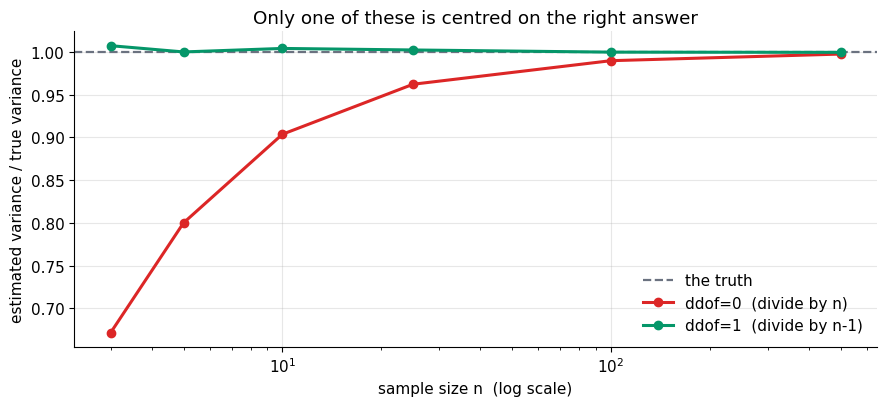

In [8]:
# ============================================================
#  Does ddof=1 actually remove the bias? Simulate and find out.
#  Small samples (n=6) so the effect is large and unmistakable.
# ============================================================
rng_ddof = np.random.default_rng(101)

N_SIM, n = 200_000, 6
draws = POP[rng_ddof.integers(0, POP_N, size=(N_SIM, n))]   # 200k samples of 6

var_n     = draws.var(axis=1, ddof=0).mean()   # divide by n
var_nm1   = draws.var(axis=1, ddof=1).mean()   # divide by n-1
true_var  = POP.var(ddof=0)                    # the answer we are chasing

print(f"{N_SIM:,} independent samples of n = {n}, drawn from the real population\n")
print(f"  TRUE population variance          {true_var:12.2f} ms^2")
print(f"  average of ddof=0 estimates       {var_n:12.2f} ms^2   "
      f"({var_n / true_var - 1:+.2%})")
print(f"  average of ddof=1 estimates       {var_nm1:12.2f} ms^2   "
      f"({var_nm1 / true_var - 1:+.2%})")
print()
print(f"  ddof=0 is low by a factor of      {var_n / true_var:.4f}")
print(f"  theory says it should be (n-1)/n = {(n - 1) / n:.4f}")
print()
print("Not approximately. Exactly the predicted factor -- because the shrinkage")
print("is not random bad luck, it is a fixed geometric consequence of measuring")
print("distances from a centre that was fitted to the data.")
print()

# The bias shrinks as n grows -- which is why nobody notices it on big data.
ns = [3, 5, 10, 25, 100, 500]
ratios_0, ratios_1 = [], []
rng_s = np.random.default_rng(202)

print(f"{'n':>6}{'ddof=0 / truth':>18}{'ddof=1 / truth':>18}{'(n-1)/n':>12}")
print("-" * 54)
for nn in ns:
    d = POP[rng_s.integers(0, POP_N, size=(40_000, nn))]
    r0 = d.var(axis=1, ddof=0).mean() / true_var
    r1 = d.var(axis=1, ddof=1).mean() / true_var
    ratios_0.append(r0); ratios_1.append(r1)
    print(f"{nn:>6}{r0:>18.4f}{r1:>18.4f}{(nn - 1) / nn:>12.4f}")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axhline(1.0, color=C_GREY, lw=1.6, ls="--", label="the truth")
ax.plot(ns, ratios_0, "o-", color=C_SLOPE, lw=2.2, label="ddof=0  (divide by n)")
ax.plot(ns, ratios_1, "o-", color=C_AREA,  lw=2.2, label="ddof=1  (divide by n-1)")
ax.set_xscale("log")
ax.set_xlabel("sample size n  (log scale)")
ax.set_ylabel("estimated variance / true variance")
ax.set_title("Only one of these is centred on the right answer")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


The grey dashed line at 1.0 is the truth. The green curve (`ddof=1`) sits on it
at every sample size. The red curve (`ddof=0`) sits below it and only crawls up
as $n$ grows, exactly tracking the printed $(n-1)/n$ column.

At $n = 500$ the two are indistinguishable to the eye, which is why this
correction is easy to ignore on large datasets and genuinely matters on small
ones — the per-fold results of a 5-fold cross-validation, a handful of
benchmark runs, a small pilot study.

**The common misread:** thinking `ddof=1` makes any single estimate *more
accurate*. It does not. A `ddof=1` estimate from one sample can be badly wrong,
and can be further from the truth than the `ddof=0` estimate from the same
sample. What the correction fixes is the **long-run average**: repeat it forever
and `ddof=1` centres on the truth while `ddof=0` never does. That distinction —
one estimate versus the average of all possible estimates — is exactly the idea
Part 2 is built on.


</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted


Everything above was measured, not quoted. We drew 200,000 samples of six people
from a population whose variance we can compute exactly, and printed the average
of each estimator next to it. `ddof=0` came in low by the printed percentage and
its ratio to the truth matched the predicted $(n-1)/n$ to four decimal places.

If the algebra had been wrong, this cell would have said so.


</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up


**`np.var` and `np.std` default to `ddof=0`. `pandas` `.var()` and `.std()`
default to `ddof=1`.**

The two libraries you are most likely to use in the same script disagree about
the default, silently, and both are defensible — numpy is describing the array
you handed it, pandas is assuming that array is a sample from something larger.

Two consequences worth internalising:

- Switching a computation from pandas to numpy (or back) can change your error
  bars without changing your data. Nothing warns you.
- **Ask which one you want**, do not memorise a rule. Describing exactly these
  numbers and nothing else? `ddof=0` is correct. Estimating the spread of a
  wider population from a sample of it — which is nearly always what you are
  doing — `ddof=1`.


</div>

---

## 1.3 Shape: skewness and kurtosis

Centre and spread still do not pin down a distribution. Two more numbers get
you most of the rest of the way, and both are defined by the same trick: keep
taking averages of powers of the standardised distance from the mean.

- **Skewness** — the average *cubed* standardised distance. Cubing keeps the
  sign, so a long right tail contributes big positive numbers that nothing
  cancels. **Positive means the tail points right.** Zero means symmetric.
- **Kurtosis** — the average *fourth* power. Fourth powers are dominated by the
  most extreme points, so this is a measure of **how heavy the tails are**: how
  much of your data lives far out. Reported as *excess* kurtosis, meaning
  "relative to a normal distribution", so a bell curve scores 0.

Neither is something you will compute by hand often. But knowing the sign of
the skew tells you immediately whether the mean is trustworthy, and that is
worth the thirty seconds.


In [9]:
from scipy import stats

def skew_by_hand(x):
    m, s = np.mean(x), np.std(x, ddof=0)
    return np.mean(((x - m) / s) ** 3)

def excess_kurtosis_by_hand(x):
    m, s = np.mean(x), np.std(x, ddof=0)
    return np.mean(((x - m) / s) ** 4) - 3.0     # -3 makes a normal score 0

print("POPULATION shape")
print(f"  skewness         by hand {skew_by_hand(POP):8.4f}   "
      f"scipy {stats.skew(POP):8.4f}")
print(f"  excess kurtosis  by hand {excess_kurtosis_by_hand(POP):8.4f}   "
      f"scipy {stats.kurtosis(POP):8.4f}")
print()

# What does a symmetric bell curve score? Same code, different data.
bell = np.random.default_rng(5).normal(POP_MU, POP_SD, POP_N)
print("a NORMAL distribution with the same mean and sd, for comparison")
print(f"  skewness         {skew_by_hand(bell):8.4f}")
print(f"  excess kurtosis  {excess_kurtosis_by_hand(bell):8.4f}")
print()
print(f"mean - median, our population : {POP_MU - np.median(POP):+8.2f} ms")
print(f"mean - median, the bell curve : {bell.mean() - np.median(bell):+8.2f} ms")
print()
print("Positive skew and a positive mean-minus-median gap are the same fact,")
print("measured two ways.")


POPULATION shape
  skewness         by hand   0.8804   scipy   0.8804
  excess kurtosis  by hand   1.4069   scipy   1.4069

a NORMAL distribution with the same mean and sd, for comparison
  skewness           0.0055
  excess kurtosis   -0.0110

mean - median, our population :   +11.04 ms
mean - median, the bell curve :    +0.06 ms

Positive skew and a positive mean-minus-median gap are the same fact,
measured two ways.


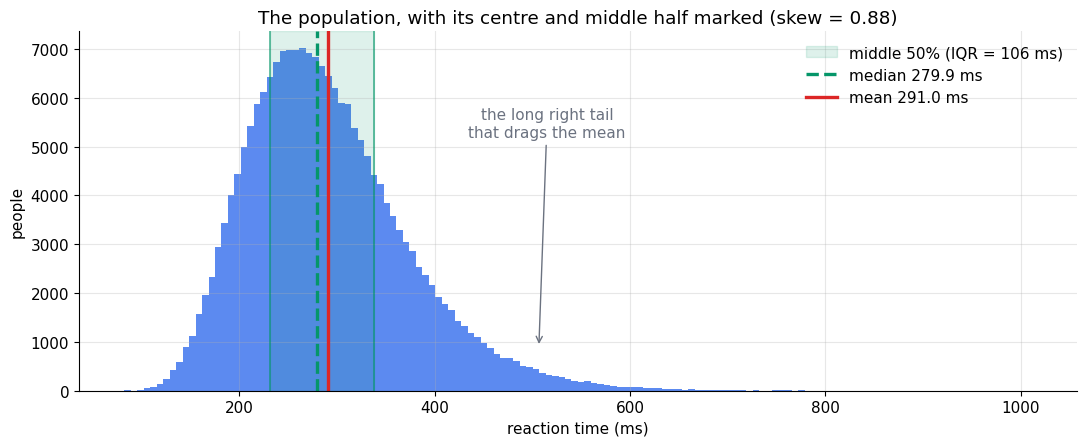

In [10]:
q25p, q50p, q75p = np.percentile(POP, [25, 50, 75])

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.hist(POP, bins=140, color=C_F, alpha=0.75)
ax.axvspan(q25p, q75p, color=C_AREA, alpha=0.13,
           label=f"middle 50% (IQR = {q75p - q25p:.0f} ms)")
ax.axvline(q50p,   color=C_AREA,  lw=2.4, ls="--", label=f"median {q50p:.1f} ms")
ax.axvline(POP_MU, color=C_SLOPE, lw=2.4,          label=f"mean {POP_MU:.1f} ms")
ax.axvline(q25p, color=C_AREA, lw=1.2, alpha=0.7)
ax.axvline(q75p, color=C_AREA, lw=1.2, alpha=0.7)
ax.annotate("the long right tail\nthat drags the mean",
            xy=(POP_MU + 2.6 * POP_SD, 900), xytext=(POP_MU + 2.7 * POP_SD, 5200),
            color=C_GREY, ha="center",
            arrowprops=dict(arrowstyle="->", color=C_GREY))
ax.set_xlabel("reaction time (ms)"); ax.set_ylabel("people")
ax.set_title(f"The population, with its centre and middle half marked "
             f"(skew = {stats.skew(POP):.2f})")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


The shaded band is the middle half of everybody — 25th to 75th percentile. The
dashed green line inside it is the median, and notice it does **not** sit in
the middle of the band: the right half of the band is wider than the left. That
asymmetry, visible by eye, is what the positive skewness number measures.

The solid red mean sits to the right of the median, pulled there by the tail
the arrow points at. Those far-right people are few — the bars out there are
barely visible — but they are *very* far out, and the mean weights distance
while the median only counts heads.

**The common misread:** treating the long tail as contamination to be cleaned
away. Nothing is wrong with this data. Skew is a genuine property of most
real-world quantities that cannot go below zero (times, prices, counts, sizes),
and deleting the tail does not give you cleaner data — it gives you a different
population that you no longer have a name for.


</div>

---

## 1.4 Percentiles, quantiles, and what a box plot is actually drawing

A **percentile** is defined by counting, not by arithmetic. The 90th percentile
is the value with 90% of the data at or below it. That is the whole definition,
and it is the reason percentiles survive skew and outliers untouched: moving
your largest value from 600 ms to 600,000 ms changes no percentile except the
very top ones, because it changes nobody's *rank*.

"Quantile" is the same idea on a 0-to-1 scale — the 0.9 quantile is the 90th
percentile. Three of them have their own names: the **quartiles** $Q_1, Q_2,
Q_3$ at 25%, 50% and 75%, with $Q_2$ being the median wearing a different hat.


   pct    population    sample of 40    sample error
----------------------------------------------------
    0%         82.37          166.98          +84.61
    1%        145.83          172.55          +26.71
    5%        176.61          183.72           +7.11
   10%        195.46          194.12           -1.34
   25%        231.81          235.39           +3.58
   50%        279.95          269.30          -10.65
   75%        337.61          324.89          -12.71
   90%        400.13          377.44          -22.69
   95%        443.40          410.40          -33.00
   99%        537.50          460.48          -77.01
  100%       1011.29          464.65         -546.64

IQR, population :   105.80 ms
IQR, sample     :    89.51 ms

Middle percentiles are estimated well from 40 people. The extremes are
not -- a sample of 40 has almost no information about the top 1%,
because it contains at most a handful of people from there.



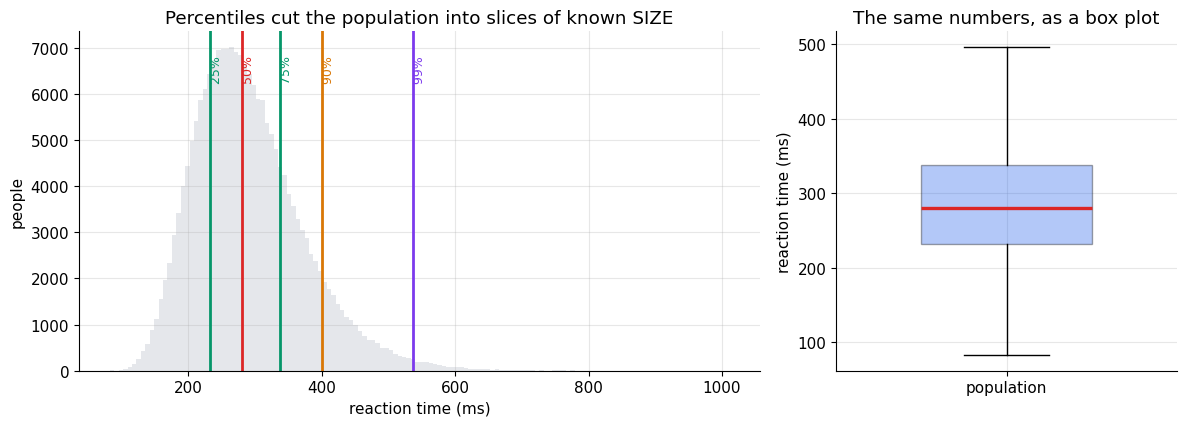

what the box plot is drawing, in numbers:
  box bottom  = Q1     =   231.81 ms
  red line    = median =   279.95 ms
  box top     = Q3     =   337.61 ms
  whiskers reach to the furthest points within 1.5 x IQR of the box:
      lower fence    73.10 ms      upper fence   496.31 ms
  people beyond the upper fence: 2.08% of the population


In [11]:
levels = [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]
pop_q  = np.percentile(POP, levels)
smp_q  = np.percentile(sample, levels)

print(f"{'pct':>6}{'population':>14}{'sample of 40':>16}{'sample error':>16}")
print("-" * 52)
for lv, pq, sq in zip(levels, pop_q, smp_q):
    print(f"{lv:>5}%{pq:>14.2f}{sq:>16.2f}{sq - pq:>+16.2f}")
print()
print(f"IQR, population : {pop_q[6] - pop_q[4]:8.2f} ms")
print(f"IQR, sample     : {smp_q[6] - smp_q[4]:8.2f} ms")
print()
print("Middle percentiles are estimated well from 40 people. The extremes are")
print("not -- a sample of 40 has almost no information about the top 1%,")
print("because it contains at most a handful of people from there.")
print()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.4),
                               gridspec_kw={"width_ratios": [2, 1]})

axL.hist(POP, bins=140, color=C_SOFT)
for lv, col in [(25, C_AREA), (50, C_SLOPE), (75, C_AREA), (90, C_APPROX),
                (99, C_EXACT)]:
    v = np.percentile(POP, lv)
    axL.axvline(v, color=col, lw=2.0)
    axL.text(v, axL.get_ylim()[1] * 0.93, f" {lv}%", color=col,
             fontsize=9, rotation=90, va="top")
axL.set_xlabel("reaction time (ms)"); axL.set_ylabel("people")
axL.set_title("Percentiles cut the population into slices of known SIZE")

bp = axR.boxplot([POP], widths=0.5, patch_artist=True,
                 showfliers=False)
bp["boxes"][0].set_facecolor(C_F); bp["boxes"][0].set_alpha(0.35)
bp["medians"][0].set_color(C_SLOPE); bp["medians"][0].set_linewidth(2.4)
axR.set_xticks([1]); axR.set_xticklabels(["population"])
axR.set_ylabel("reaction time (ms)")
axR.set_title("The same numbers, as a box plot")
fig.tight_layout(); plt.show()

lo_w = np.percentile(POP, 25) - 1.5 * (np.percentile(POP, 75) - np.percentile(POP, 25))
hi_w = np.percentile(POP, 75) + 1.5 * (np.percentile(POP, 75) - np.percentile(POP, 25))
print("what the box plot is drawing, in numbers:")
print(f"  box bottom  = Q1     = {np.percentile(POP, 25):8.2f} ms")
print(f"  red line    = median = {np.percentile(POP, 50):8.2f} ms")
print(f"  box top     = Q3     = {np.percentile(POP, 75):8.2f} ms")
print(f"  whiskers reach to the furthest points within 1.5 x IQR of the box:")
print(f"      lower fence {lo_w:8.2f} ms      upper fence {hi_w:8.2f} ms")
print(f"  people beyond the upper fence: {(POP > hi_w).mean():.2%} of the population")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


Left: the same histogram with percentile lines drawn on it. The lines are not
evenly spaced, but the *slices between them* contain known fractions of people —
25% between the 25% and 50% lines, 25% between 50% and 75%, and so on. Where the
data is dense the lines crowd together; where it thins out into the tail, 90% to
99% spans an enormous stretch of milliseconds containing only 9% of people.

Right: a box plot is that picture with everything but five numbers erased. The
box spans the middle half, the red line is the median, the whiskers reach out
1.5 IQRs. Read the two panels together and the box plot stops being an arbitrary
convention — it is a percentile diagram, drawn sideways.

**The common misread:** reading points beyond the whiskers as "outliers" in the
sense of errors. The 1.5 IQR rule is a drawing convention, nothing more. We just
printed the fraction of our perfectly healthy, uncontaminated population that
falls beyond the upper fence — on skewed data that number is never zero, and
those people are not mistakes.


</div>

---

## 1.5 Robust statistics: what survives contamination

Section 1.1 showed one outlier wrecking a mean. Now let us measure the effect
properly, by contaminating a sample progressively and watching each statistic
as the damage accumulates.

The question each statistic answers is: **what fraction of my data can be
arbitrarily corrupted before my answer becomes arbitrarily wrong?** That
fraction is called the *breakdown point*, and the numbers are stark — the mean's
is $0$ (one bad point out of a million is enough to move it anywhere you like),
the median's is $0.5$ (you must corrupt *half* the data before it breaks).


200 clean measurements; the first k replaced by 8,000 ms

  corrupt    k       mean     median         sd        IQR
----------------------------------------------------------
      0%    0      295.0      292.6       81.7      108.9
      1%    2      372.3      293.9      772.9      111.2
      2%    4      449.5      295.2     1084.4      114.3
      5%   10      681.6      297.7     1685.1      121.5
     10%   20     1068.7      302.3     2317.6      131.8
     20%   40     1843.8      319.6     3086.7      177.9
     30%   60     2613.9      349.1     3535.6     7736.4

change from clean, at 10% contamination:
  mean      295.0 ->   1068.7   (+262.2%)
  median    292.6 ->    302.3   (+3.3%)
  sd         81.7 ->   2317.6   (+2737.5%)
  IQR       108.9 ->    131.8   (+21.0%)


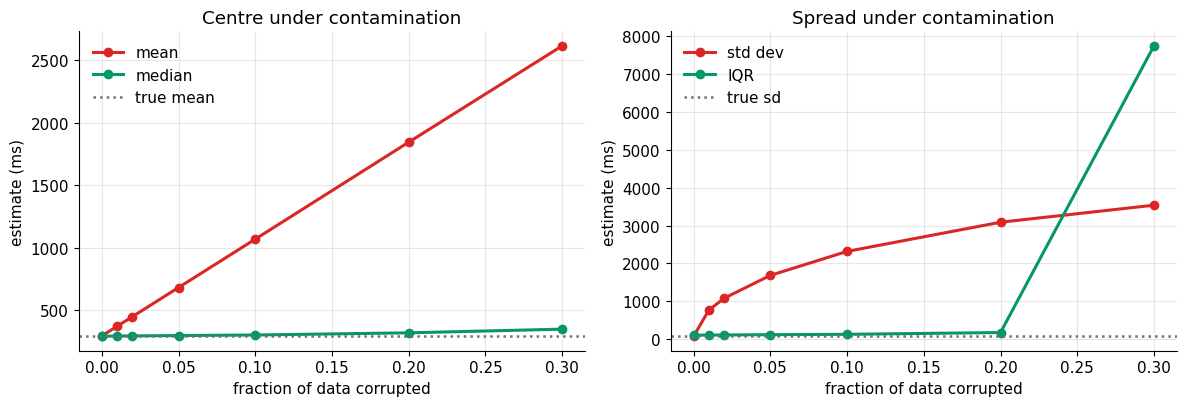

In [12]:
rng_rob   = np.random.default_rng(77)
base      = rng_rob.choice(POP, 200, replace=False)
fractions = [0.00, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30]
BAD       = 8_000.0          # the value each corrupted point takes

res = []
for f in fractions:
    k   = int(round(f * len(base)))
    con = base.copy()
    con[:k] = BAD                       # replace k points with garbage
    res.append((f, k, con.mean(), np.median(con),
                con.std(ddof=1),
                np.percentile(con, 75) - np.percentile(con, 25)))

print(f"200 clean measurements; the first k replaced by {BAD:,.0f} ms\n")
print(f"{'corrupt':>9}{'k':>5}{'mean':>11}{'median':>11}{'sd':>11}{'IQR':>11}")
print("-" * 58)
for f, k, m, med, sd, iqr in res:
    print(f"{f:>8.0%}{k:>5}{m:>11.1f}{med:>11.1f}{sd:>11.1f}{iqr:>11.1f}")

clean = res[0]
print()
print("change from clean, at 10% contamination:")
r10 = [r for r in res if r[0] == 0.10][0]
print(f"  mean   {clean[2]:8.1f} -> {r10[2]:8.1f}   ({r10[2] / clean[2] - 1:+.1%})")
print(f"  median {clean[3]:8.1f} -> {r10[3]:8.1f}   ({r10[3] / clean[3] - 1:+.1%})")
print(f"  sd     {clean[4]:8.1f} -> {r10[4]:8.1f}   ({r10[4] / clean[4] - 1:+.1%})")
print(f"  IQR    {clean[5]:8.1f} -> {r10[5]:8.1f}   ({r10[5] / clean[5] - 1:+.1%})")

fs = [r[0] for r in res]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))

a1.plot(fs, [r[2] for r in res], "o-", color=C_SLOPE, lw=2.2, label="mean")
a1.plot(fs, [r[3] for r in res], "o-", color=C_AREA,  lw=2.2, label="median")
a1.axhline(POP_MU, color=C_GREY, ls=":", lw=1.8, label="true mean")
a1.set_xlabel("fraction of data corrupted"); a1.set_ylabel("estimate (ms)")
a1.set_title("Centre under contamination"); a1.legend(frameon=False)

a2.plot(fs, [r[4] for r in res], "o-", color=C_SLOPE, lw=2.2, label="std dev")
a2.plot(fs, [r[5] for r in res], "o-", color=C_AREA,  lw=2.2, label="IQR")
a2.axhline(POP_SD, color=C_GREY, ls=":", lw=1.8, label="true sd")
a2.set_xlabel("fraction of data corrupted"); a2.set_ylabel("estimate (ms)")
a2.set_title("Spread under contamination"); a2.legend(frameon=False)

fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


Both red curves climb steeply and immediately; both green curves stay nearly
flat across the whole range. The mean and standard deviation start drifting away
from the truth at the very first corrupted point and never come back. The median
and IQR barely register the damage until a large fraction of the data is gone.

Look at the green median curve at 30% contamination: still close to the dotted
truth. Nearly a third of the measurements are nonsense and the median is still
approximately right, because 70% of the sorted values are still real and the
middle one is still among them.

**The common misread:** concluding that robust statistics are simply better and
you should always use the median. On *clean* data the mean is the more efficient
estimator — it uses every value, so it extracts more information from the same
number of observations, and Parts 3 through 6 are built almost entirely on it.
Robustness is insurance, and like all insurance it costs something. The skill is
knowing when you are exposed.


</div>

---

## 1.6 When a summary hides the data

Here is the uncomfortable ending to a section about summaries: mean and standard
deviation together — the two numbers most results are reported with — do not
determine what your data looks like. Not approximately. At all.

We will build three datasets with **identical means and identical standard
deviations to several decimal places**, and they will look nothing alike.


dataset           mean     std dev      median      skew   ex.kurt
------------------------------------------------------------------
skewed        290.9890     83.0120      279.96     0.844     1.137
bimodal       290.9890     83.0120      301.32    -0.006    -1.725
uniform       290.9890     83.0120      289.66     0.029    -1.192

The first two columns match to four decimal places. Everything after
them does not, and neither do the pictures below.


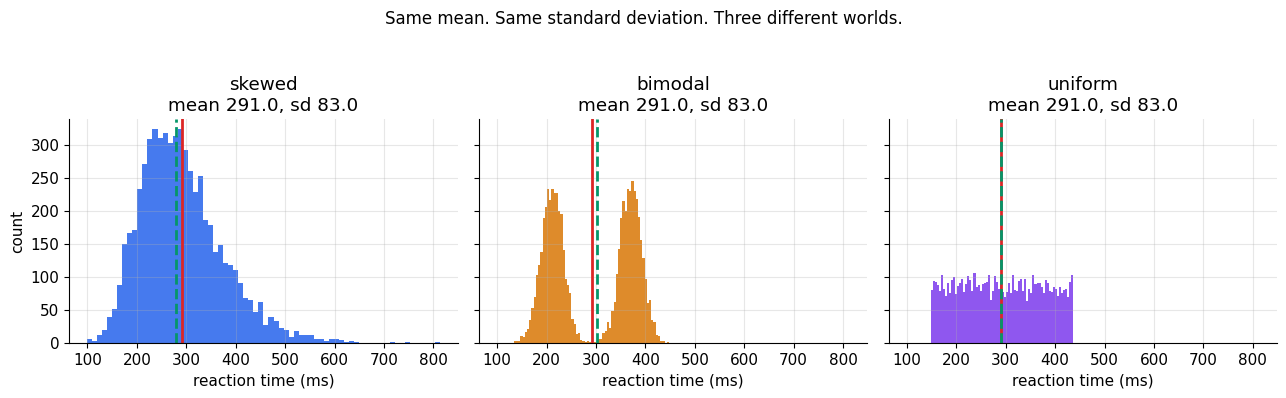

In [13]:
rng_same = np.random.default_rng(31)
M, S, N3 = POP_MU, POP_SD, 6_000

def force(x, m=M, s=S):
    """Shift and scale x so its mean is exactly m and its sd exactly s."""
    return (x - x.mean()) / x.std(ddof=0) * s + m

skewed  = force(rng_same.lognormal(np.log(280), 0.28, N3))
bimodal = force(np.concatenate([rng_same.normal(-1, 0.28, N3 // 2),
                                rng_same.normal(+1, 0.28, N3 // 2)]))
uniform = force(rng_same.uniform(0, 1, N3))

sets = [("skewed",  skewed,  C_F),
        ("bimodal", bimodal, C_APPROX),
        ("uniform", uniform, C_EXACT)]

print(f"{'dataset':<10}{'mean':>12}{'std dev':>12}{'median':>12}"
      f"{'skew':>10}{'ex.kurt':>10}")
print("-" * 66)
for name, d, _ in sets:
    print(f"{name:<10}{d.mean():>12.4f}{d.std(ddof=0):>12.4f}"
          f"{np.median(d):>12.2f}{stats.skew(d):>10.3f}"
          f"{stats.kurtosis(d):>10.3f}")
print()
print("The first two columns match to four decimal places. Everything after")
print("them does not, and neither do the pictures below.")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True)
for ax, (name, d, col) in zip(axes, sets):
    ax.hist(d, bins=70, color=col, alpha=0.85)
    ax.axvline(d.mean(), color=C_SLOPE, lw=2.0)
    ax.axvline(np.median(d), color=C_AREA, lw=2.0, ls="--")
    ax.set_title(f"{name}\nmean {d.mean():.1f}, sd {d.std(ddof=0):.1f}")
    ax.set_xlabel("reaction time (ms)")
axes[0].set_ylabel("count")
fig.suptitle("Same mean. Same standard deviation. Three different worlds.",
             y=1.04, fontsize=12)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


Three histograms whose first two summary statistics are identical to four
decimal places. The solid red mean line sits at the same place in all three. So
does the spread, if you measure it by standard deviation.

The pictures are not remotely alike. In the middle panel the mean falls in a
*gap* — a value almost nobody has, sitting between two clusters of people who
are genuinely fast and genuinely slow. Reporting "the average user takes
about 291 milliseconds" there is not a rough summary; it is a description of a
person who does not exist.

**The common misread:** believing that adding more summary statistics eventually
pins the picture down. It does not. Skewness and kurtosis separate these three,
so a fourth dataset could be built to match all four numbers and still look
different again. **Plot the data. Always plot the data.** Summaries are for
communicating what you found, not for finding it.


</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares


**Your loss function is choosing a centre for you, and it is usually choosing
the mean.**

Minimising **squared** error makes your model predict the *conditional mean* of
the target; minimising **absolute** error makes it predict the *conditional
median*. That is the identical mean-versus-median trade-off from §1.1, relocated
into the training loop — which is why a regressor trained with MSE on skewed
targets (prices, durations, counts) systematically over-predicts the typical
case, chasing a tail that a handful of examples own.

The same split runs through the rest of the stack. Standardising features by
mean and sd lets one bad row shift an entire column; `RobustScaler` uses the
median and IQR precisely because of the curves in §1.5. And a model reported
only by its *average* error across the test set is a §1.6 summary: the per-example
error distribution can be bimodal — excellent on most inputs, catastrophic on a
subgroup — and the average will not tell you.


</div>

---

### Where that leaves us

You can now describe a pile of numbers honestly: its centre by more than one
definition, its spread, its shape, and the ways each of those can mislead. You
have also seen the first genuinely statistical idea, hiding inside `ddof=1` —
that an estimator can be **systematically wrong in a fixed direction**, and that
you can detect and correct that by simulating many samples and looking at where
they land *on average*.

Hold onto that, because it is the whole of Part 2. Every number in this part was
computed from either the population (where it is simply true) or one sample
(where it is a guess). We have been sliding between the two without being
careful about it.

Part 2 stops sliding. It separates the two ideas properly, gives them different
notation, and shows what it costs you when you confuse them.


---

# 2️⃣ Populations, samples, and why the difference bites

Part 1 computed a mean of the population and a mean of the sample and printed
them side by side as if they were the same kind of object. They are not, and
almost every mistake in applied statistics comes from forgetting it.

## 2.1 Parameters and statistics: two different kinds of number

| | The population | Your sample |
|---|---|---|
| what it is | everyone you care about | the few you measured |
| its numbers are called | **parameters** | **statistics** |
| mean | $\mu$ ("mu") | $\bar{x}$ ("x-bar") |
| standard deviation | $\sigma$ ("sigma") | $s$ |
| size | $N$ | $n$ |
| is it fixed? | **yes** — one number, forever | **no** — changes with every sample |
| can you see it? | **no** (except here) | yes, always |

A parameter is a fixed fact about the world that you do not get to see. A
statistic is something you computed, which means you can always see it, and
which would have come out differently if you had knocked on different doors.

**Greek for the truth, Latin for your guess at it.** That convention is worth
learning now, because from here on every formula announces which side of the
divide it lives on just by the alphabet it is written in.


In [14]:
# The same six quantities, computed on the population and on the sample.
# In real work the left column does not exist.
pairs = [
    ("mean",              POP.mean(),            sample.mean()),
    ("standard deviation", POP.std(ddof=0),      sample.std(ddof=1)),
    ("median",            np.median(POP),        np.median(sample)),
    ("25th percentile",   np.percentile(POP, 25), np.percentile(sample, 25)),
    ("75th percentile",   np.percentile(POP, 75), np.percentile(sample, 75)),
    ("size",              float(POP_N),          float(SAMPLE_N)),
]

print(f"{'quantity':<20}{'PARAMETER':>14}{'STATISTIC':>14}{'error':>12}{'  % off':>10}")
print(f"{'':<20}{'(population)':>14}{'(n=40)':>14}")
print("-" * 70)
for name, par, stat in pairs[:-1]:
    print(f"{name:<20}{par:>14.2f}{stat:>14.2f}{stat - par:>+12.2f}"
          f"{(stat - par) / par:>10.2%}")
print(f"{'size':<20}{POP_N:>14,}{SAMPLE_N:>14,}")
print()
print("Left column: fixed, true, and in any real study invisible.")
print("Right column: visible, computable, and different every time you sample.")


quantity                 PARAMETER     STATISTIC       error     % off
                      (population)        (n=40)
----------------------------------------------------------------------
mean                        290.99        280.85      -10.14    -3.48%
standard deviation           83.01         74.36       -8.65   -10.42%
median                      279.95        269.30      -10.65    -3.81%
25th percentile             231.81        235.39       +3.58     1.54%
75th percentile             337.61        324.89      -12.71    -3.77%
size                       200,000            40

Left column: fixed, true, and in any real study invisible.
Right column: visible, computable, and different every time you sample.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words


$\mu$ is **the** mean reaction time of all two hundred thousand people. There is
exactly one such number and it does not move.

$\bar{x}$ is the mean of the forty people who happened to walk into your lab. It
is a **guess at $\mu$**, and it is also a *random quantity*: not because the
world is random, but because *which forty people you got* was.

That second point is the entire idea of this part. The $\bar{x}$ printed in the
table above is one draw from a lottery. Statistics is the study
of what that lottery looks like — and once you know its shape, you can say how
far from $\mu$ your one ticket is likely to be.


The hat notation makes the relationship explicit: $\hat{\mu}$ means "our estimate
of $\mu$", and here $\hat{\mu} = \bar{x}$. Different estimators, same target.


</div>

---

## 2.2 Sampling variability, made visceral

Enough abstraction. Let us take twelve honest, independent, perfectly correct
samples of forty people each — no mistakes, no bias, no bad measurements — and
look at the twelve answers we get.


12 independent, correctly-taken samples of 40 people

  study   sample mean   error vs mu  
----------------------------------------
      1        302.33        +11.34   ##### slow
      2        279.64        -11.35   ##### fast
      3        296.67         +5.68   ## slow
      4        285.27         -5.72   ## fast
      5        276.17        -14.82   ####### fast
      6        281.44         -9.55   #### fast
      7        299.74         +8.75   #### slow
      8        266.72        -24.27   ############ fast
      9        279.40        -11.59   ##### fast
     10        268.68        -22.31   ########### fast
     11        303.80        +12.82   ###### slow
     12        313.93        +22.94   ########### slow
----------------------------------------
  truth        290.99

lowest  answer : 266.72 ms
highest answer : 313.93 ms
spread between them : 47.22 ms
every one of these studies did everything right.


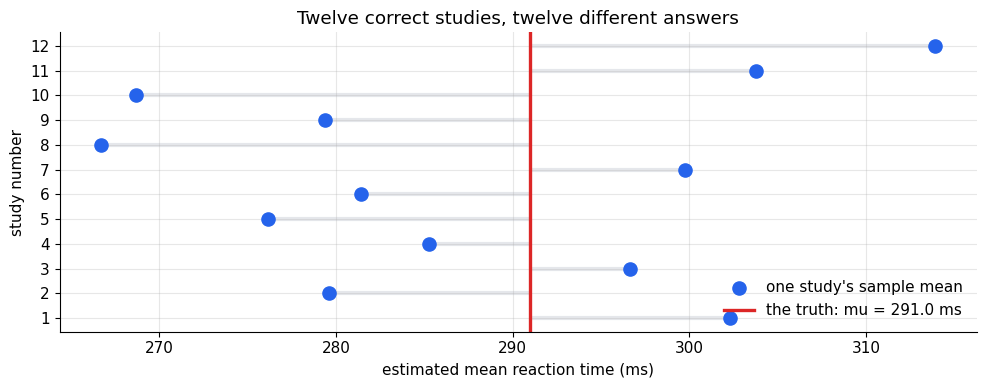

In [15]:
rng_var = np.random.default_rng(1234)

K = 12
samples = [rng_var.choice(POP, SAMPLE_N, replace=False) for _ in range(K)]
means   = np.array([s.mean() for s in samples])

print(f"{K} independent, correctly-taken samples of {SAMPLE_N} people\n")
print(f"{'study':>7}{'sample mean':>14}{'error vs mu':>14}{'  ':>2}")
print("-" * 40)
for i, m in enumerate(means, 1):
    bar = "#" * int(abs(m - POP_MU) / 2)
    side = "slow" if m > POP_MU else "fast"
    print(f"{i:>7}{m:>14.2f}{m - POP_MU:>+14.2f}   {bar} {side}")
print("-" * 40)
print(f"{'truth':>7}{POP_MU:>14.2f}")
print()
print(f"lowest  answer : {means.min():.2f} ms")
print(f"highest answer : {means.max():.2f} ms")
print(f"spread between them : {means.max() - means.min():.2f} ms")
print(f"every one of these studies did everything right.")

fig, ax = plt.subplots(figsize=(10, 4.0))
ax.scatter(means, np.arange(1, K + 1), s=90, color=C_F, zorder=3,
           label="one study's sample mean")
ax.hlines(np.arange(1, K + 1), np.minimum(means, POP_MU),
          np.maximum(means, POP_MU), color=C_SOFT, lw=3, zorder=1)
ax.axvline(POP_MU, color=C_SLOPE, lw=2.4, zorder=2,
           label=f"the truth: mu = {POP_MU:.1f} ms")
ax.set_yticks(np.arange(1, K + 1))
ax.set_ylabel("study number"); ax.set_xlabel("estimated mean reaction time (ms)")
ax.set_title("Twelve correct studies, twelve different answers")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


Twelve dots, one per study, each connected by a grey bar to the red line that
marks the truth. No dot lands on the line. Some sit well to the left, some well
to the right, and the printed spread between the best and worst is large enough
to change what you would conclude.

Every one of these studies sampled at random from the correct population,
measured everything perfectly, and made no error of any kind. The scatter is not
sloppiness. It is what taking forty of something *is*.

**The common misread:** seeing two studies disagree and assuming one of them
must be wrong. Two honest studies of the same population routinely disagree by
more than the effect people are arguing about. "Study A found 285 ms, study B
found 298 ms, so somebody messed up" is, on this evidence, simply false — and
the useful question is not *who is right* but *is this gap bigger than sampling
noise would produce anyway*, which is exactly what Parts 4 and 5 are for.


</div>

---

## 2.3 Judging an estimator: bias and variance

If a single answer is always somewhat wrong, you cannot judge a method by
whether it got the right answer once. You have to ask what it does **over all
the samples it could have drawn**. Two questions, and they are independent:

- **Bias** — if you repeated the study forever, would the average of your
  answers land on the truth? If yes the estimator is **unbiased**. If it lands
  somewhere else, that gap is the bias, and it does not shrink with more data.
- **Variance** — how widely do the answers scatter around wherever they are
  centred? This *does* shrink with more data.

Bias is aiming at the wrong target. Variance is a shaky hand. A shaky hand
aimed correctly averages out; a steady hand aimed wrongly never does.

You have already met a biased estimator: `ddof=0` in Part 1. Now let us test
the sample mean itself.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words


Write $\hat{\theta}$ ("theta hat") for any recipe that turns a sample into an
estimate, and $\theta$ for the true value it is aiming at. Then

$$\text{bias}(\hat{\theta}) \;=\; \mathbb{E}\bigl[\hat{\theta}\bigr] - \theta$$

The $\mathbb{E}[\cdot]$ is read "the expected value of", and it means exactly
what our simulation does: **the average over all the samples you could have
taken.** So the formula says *take the average of your answers across every
possible study, and see how far that average sits from the truth.*

An unbiased estimator has bias zero. It does not promise your particular answer
is right; it promises the errors cancel in the long run.


</div>

In [16]:
# ============================================================
#  Is the sample mean centred on the truth? 10,000 studies.
# ============================================================
rng_bias = np.random.default_rng(404)
N_STUDIES = 10_000

draws   = POP[rng_bias.integers(0, POP_N, size=(N_STUDIES, SAMPLE_N))]
x_bars  = draws.mean(axis=1)      # estimator 1: the sample mean
x_meds  = np.median(draws, axis=1)  # estimator 2: the sample median

POP_MED = np.median(POP)

print(f"{N_STUDIES:,} studies, each of {SAMPLE_N} people\n")
print(f"{'estimator':<16}{'aimed at':<18}{'target':>10}{'average':>11}"
      f"{'bias':>10}{'spread':>10}")
print("-" * 76)
print(f"{'sample mean':<16}{'population mean':<18}{POP_MU:>10.2f}"
      f"{x_bars.mean():>11.2f}{x_bars.mean() - POP_MU:>+10.3f}{x_bars.std():>10.2f}")
print(f"{'sample median':<16}{'population median':<18}{POP_MED:>10.2f}"
      f"{x_meds.mean():>11.2f}{x_meds.mean() - POP_MED:>+10.3f}{x_meds.std():>10.2f}")
print(f"{'sample median':<16}{'population MEAN':<18}{POP_MU:>10.2f}"
      f"{x_meds.mean():>11.2f}{x_meds.mean() - POP_MU:>+10.3f}{x_meds.std():>10.2f}")
print()
print(f"The sample mean is off by {abs(x_bars.mean() - POP_MU):.3f} ms on average "
      f"-- that is {abs(x_bars.mean() - POP_MU) / x_bars.std() * 100:.1f}% of one")
print("study's typical error, i.e. indistinguishable from zero. UNBIASED.")
print()
print("The sample median is unbiased for the population MEDIAN (line 2) and")
print(f"badly biased for the population MEAN (line 3, off by "
      f"{x_meds.mean() - POP_MU:+.2f} ms).")
print("Same recipe, same data. Whether it is 'biased' depends entirely on what")
print("you claim it estimates.")


10,000 studies, each of 40 people

estimator       aimed at              target    average      bias    spread
----------------------------------------------------------------------------
sample mean     population mean       290.99     290.81    -0.182     13.14
sample median   population median     279.95     280.28    +0.327     15.16
sample median   population MEAN       290.99     280.28   -10.713     15.16

The sample mean is off by 0.182 ms on average -- that is 1.4% of one
study's typical error, i.e. indistinguishable from zero. UNBIASED.

The sample median is unbiased for the population MEDIAN (line 2) and
badly biased for the population MEAN (line 3, off by -10.71 ms).
Same recipe, same data. Whether it is 'biased' depends entirely on what
you claim it estimates.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted


Nothing above was quoted from a textbook. We ran ten thousand studies against a
population whose mean and median we can compute exactly, and printed the average
answer next to each target.

Note the third line especially. The sample median is a perfectly good estimator
that is simultaneously unbiased and heavily biased — for different targets. On
Part 1's skewed population the median is *not* an estimate of $\mu$, and calling
it "the average" would build a fixed error of the printed size into everything
downstream.


</div>

---

## 2.4 What more data buys you

The sample mean is centred on the truth, but individual studies still miss by a
lot. The obvious lever is $n$. Let us pull it and measure precisely what we get.

Four sample sizes — 10, 40, 200, 1000 — four thousand studies at each.


4,000 studies at each sample size

      n   avg estimate      bias   spread of estimates    spread x sqrt(n)
----------------------------------------------------------------------------
     10         291.15     +0.16                26.157               82.72
     40         290.91     -0.08                12.878               81.45
    200         291.10     +0.11                 5.807               82.12
   1000         291.01     +0.02                 2.660               84.13
----------------------------------------------------------------------------
  truth         290.99

population sd for comparison: 83.01 ms

Read the last two columns together. The spread falls as n grows -- but
the last column, spread times the square root of n, barely moves at all.
Something specific is going on. Part 3 says what.


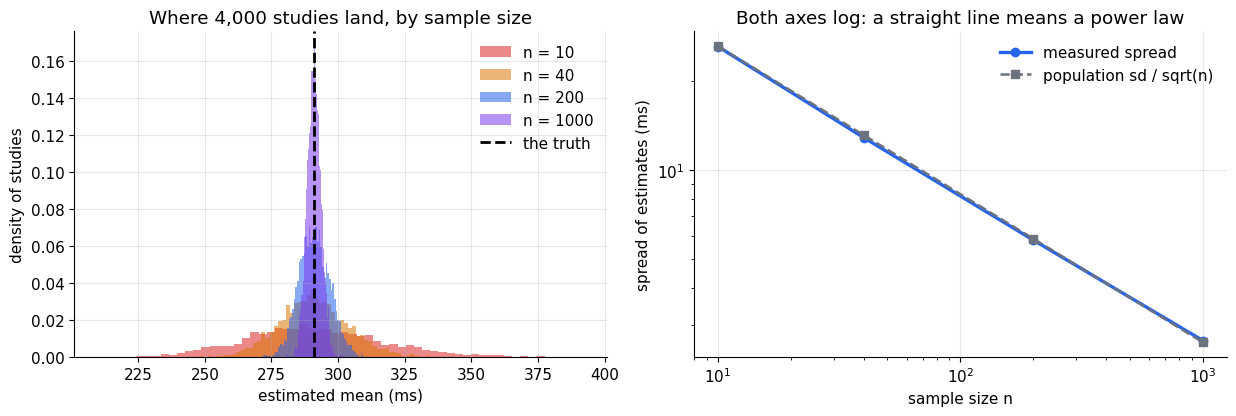

In [17]:
rng_n = np.random.default_rng(2024)
SIZES, REPS = [10, 40, 200, 1000], 4_000

spreads, by_n = [], {}
for n in SIZES:
    est = POP[rng_n.integers(0, POP_N, size=(REPS, n))].mean(axis=1)
    by_n[n] = est
    spreads.append(est.std())

print(f"{REPS:,} studies at each sample size\n")
print(f"{'n':>7}{'avg estimate':>15}{'bias':>10}{'spread of estimates':>22}"
      f"{'spread x sqrt(n)':>20}")
print("-" * 76)
for n, sp in zip(SIZES, spreads):
    e = by_n[n]
    print(f"{n:>7}{e.mean():>15.2f}{e.mean() - POP_MU:>+10.2f}{sp:>22.3f}"
          f"{sp * np.sqrt(n):>20.2f}")
print("-" * 76)
print(f"{'truth':>7}{POP_MU:>15.2f}")
print(f"\npopulation sd for comparison: {POP_SD:.2f} ms")
print()
print("Read the last two columns together. The spread falls as n grows -- but")
print("the last column, spread times the square root of n, barely moves at all.")
print("Something specific is going on. Part 3 says what.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
cols = [C_SLOPE, C_APPROX, C_F, C_EXACT]
for n, c in zip(SIZES, cols):
    a1.hist(by_n[n], bins=60, density=True, alpha=0.55, color=c, label=f"n = {n}")
a1.axvline(POP_MU, color="black", lw=2.0, ls="--", label="the truth")
a1.set_xlim(POP_MU - 90, POP_MU + 110)
a1.set_xlabel("estimated mean (ms)"); a1.set_ylabel("density of studies")
a1.set_title("Where 4,000 studies land, by sample size")
a1.legend(frameon=False)

a2.loglog(SIZES, spreads, "o-", color=C_F, lw=2.4, label="measured spread")
a2.loglog(SIZES, [POP_SD / np.sqrt(n) for n in SIZES], "s--", color=C_GREY,
          lw=1.8, label="population sd / sqrt(n)")
a2.set_xlabel("sample size n"); a2.set_ylabel("spread of estimates (ms)")
a2.set_title("Both axes log: a straight line means a power law")
a2.legend(frameon=False)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


Left: four piles of studies. All four are centred on the same dashed black line —
more data does not move the centre, because there was never anything wrong with
the centre. What changes is the *width*. At $n = 10$ studies land almost
anywhere; at $n = 1000$ they cluster tightly around the truth.

Right: the same fact as a single curve, on log-log axes where a power law
becomes a straight line. The measured spread (blue) lies on top of the grey
reference line, and the "spread × √n" column in the table above stays flat at
roughly the population standard deviation.

**The common misread:** reading the shrinking width as "bigger samples are more
accurate" and stopping there. They are more *precise* — the answers agree with
each other more. Precision and accuracy are different things, and §2.5 is
entirely about a situation where the width shrinks beautifully around an answer
that is wrong.

Also worth noticing what the √ costs you: to halve your spread you need four
times the data; for one more decimal place, a hundred times. That is why studies
plateau at a few hundred participants rather than pushing on to a million.


</div>

---

## 2.5 How samples go wrong

Everything so far assumed the sample was drawn *fairly* — every person equally
likely to be picked. Drop that assumption and the mathematics does not warn you.
Your estimates still look clean, still tighten as $n$ grows, still come with
respectable-looking error bars. They are just centred on the wrong number.

| Name | What happens | Everyday example |
|---|---|---|
| **selection bias** | who *can* enter the sample is not everyone | testing an app's speed only on new flagship phones |
| **survivorship bias** | the ones that failed are gone before you look | "these funds average 9% a year" — the closed ones are not in the list |
| **convenience sampling** | you sampled whoever was easy to reach | surveying your own users about why people don't sign up |
| **non-response** | who *answers* depends on the answer | a satisfaction survey that annoyed customers delete |

These four are one failure wearing four coats: **the probability of ending up in
your sample is related to the thing you are measuring.** Let us simulate that
and watch it happen.


you can only reach people faster than 300.4 ms
that is 120,000 of 200,000 people (60% of the population)

                              estimate   error vs mu
----------------------------------------------------
fair sample of 40               285.42         -5.57
biased sample of 40             241.45        -49.54
the truth (mu)                  290.99

the biased sample is centred on 237.45 ms -- the mean of
the people it can reach -- which sits -53.54 ms from the truth,
an error of 18.4%. That number is a property of the
recruiting method, not of this particular sample.


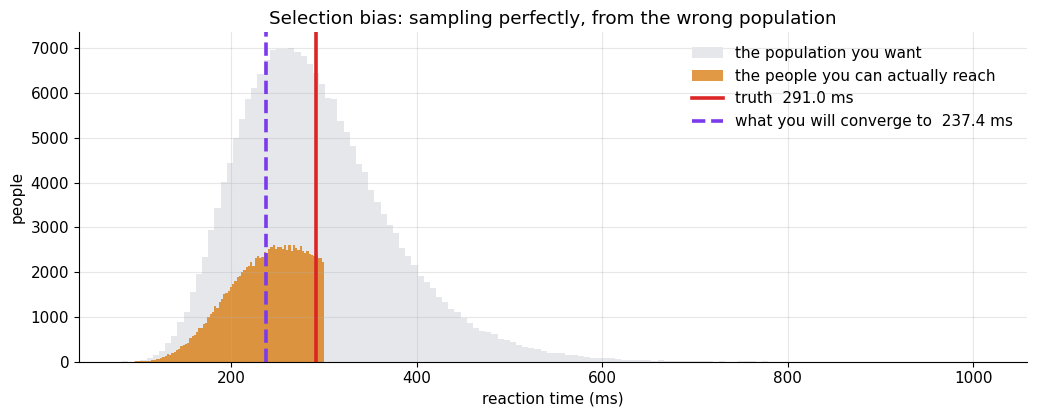

In [18]:
# ============================================================
#  SELECTION BIAS: your recruiting only reaches quick responders.
#  Concretely: only the fastest 60% of the population can enter.
# ============================================================
rng_sel = np.random.default_rng(555)

cutoff   = np.percentile(POP, 60)
reachable = POP[POP <= cutoff]          # the sub-population you can actually reach

biased_sample = rng_sel.choice(reachable, SAMPLE_N, replace=False)
fair_sample   = rng_sel.choice(POP,       SAMPLE_N, replace=False)

print(f"you can only reach people faster than {cutoff:.1f} ms")
print(f"that is {len(reachable):,} of {POP_N:,} people "
      f"({len(reachable) / POP_N:.0%} of the population)\n")
print(f"{'':<26}{'estimate':>12}{'error vs mu':>14}")
print("-" * 52)
print(f"{'fair sample of 40':<26}{fair_sample.mean():>12.2f}"
      f"{fair_sample.mean() - POP_MU:>+14.2f}")
print(f"{'biased sample of 40':<26}{biased_sample.mean():>12.2f}"
      f"{biased_sample.mean() - POP_MU:>+14.2f}")
print(f"{'the truth (mu)':<26}{POP_MU:>12.2f}")
print()
print(f"the biased sample is centred on {reachable.mean():.2f} ms -- the mean of")
print(f"the people it can reach -- which sits {reachable.mean() - POP_MU:+.2f} ms "
      f"from the truth,")
print(f"an error of {abs(reachable.mean() - POP_MU) / POP_MU:.1%}. That number is a "
      f"property of the")
print("recruiting method, not of this particular sample.")

fig, ax = plt.subplots(figsize=(10.5, 4.3))
ax.hist(POP, bins=140, color=C_SOFT, label="the population you want")
ax.hist(reachable, bins=90, color=C_APPROX, alpha=0.75,
        label="the people you can actually reach")
ax.axvline(POP_MU, color=C_SLOPE, lw=2.6, label=f"truth  {POP_MU:.1f} ms")
ax.axvline(reachable.mean(), color=C_EXACT, lw=2.6, ls="--",
           label=f"what you will converge to  {reachable.mean():.1f} ms")
ax.set_xlabel("reaction time (ms)"); ax.set_ylabel("people")
ax.set_title("Selection bias: sampling perfectly, from the wrong population")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


The pale grey histogram is everybody. The orange block is the sub-population your
recruiting can actually reach — the whole right tail is simply missing, cut off
at the printed cutoff. Your sampling *within* the orange region is flawless:
uniform, random, unbiased.

And it converges to the purple dashed line, not the red one. The gap between
them is printed above, and it is not a small effect; it is many times larger
than the study-to-study scatter we saw in §2.2.

**The common misread:** looking at a biased estimate and expecting it to *look*
wrong — noisy, unstable, obviously suspect. It looks perfect. The orange
distribution is a clean, sensible, well-behaved distribution, and a sample from
it produces a tidy mean with a tight error bar. There is no diagnostic you can
run on the data itself that reveals this. You have to know how the data was
collected.


</div>

### The part that surprises people: more data makes it worse

If a biased sample is wrong, the instinct is to collect more of it. Let us test
that instinct at $n = 40$ and $n = 4000$ — a hundred times the data — and see
what the extra hundredfold buys.


In [19]:
rng_more = np.random.default_rng(909)
REPS2 = 2_000

print(f"{REPS2:,} studies at each setting; 'reach' = which people can enter\n")
print(f"{'reach':<12}{'n':>7}{'avg estimate':>15}{'bias':>10}"
      f"{'spread':>10}{'closest miss':>15}")
print("-" * 70)
for label, pool in [("everyone", POP), ("fastest 60%", reachable)]:
    for n in [40, 4000]:
        est = pool[rng_more.integers(0, len(pool), size=(REPS2, n))].mean(axis=1)
        print(f"{label:<12}{n:>7}{est.mean():>15.2f}{est.mean() - POP_MU:>+10.2f}"
              f"{est.std():>10.3f}{np.abs(est - POP_MU).min():>15.2f}")
print("-" * 70)
print(f"{'truth':<12}{'':>7}{POP_MU:>15.2f}")
print()
print("Read the last two columns on the biased rows. Going from n=40 to n=4000")
print("shrank the spread roughly tenfold -- and the CLOSEST that any of the")
print(f"{REPS2:,} large biased studies got to the truth got WORSE, not better.")
print()
print("At n=40 a lucky biased study can stumble near the right answer.")
print("At n=4000 not one of them can. The bias is now the only thing left.")


2,000 studies at each setting; 'reach' = which people can enter

reach             n   avg estimate      bias    spread   closest miss
----------------------------------------------------------------------
everyone         40         291.08     +0.10    13.153           0.01
everyone       4000         290.97     -0.02     1.306           0.00
fastest 60%      40         237.58    -53.41     6.404          32.03
fastest 60%    4000         237.44    -53.55     0.622          51.56
----------------------------------------------------------------------
truth                       290.99

Read the last two columns on the biased rows. Going from n=40 to n=4000
shrank the spread roughly tenfold -- and the CLOSEST that any of the
2,000 large biased studies got to the truth got WORSE, not better.

At n=40 a lucky biased study can stumble near the right answer.
At n=4000 not one of them can. The bias is now the only thing left.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up


**"We'll fix it with more data."**

You cannot. Sample size attacks *variance* — the scatter of your answers around
wherever they are centred. Bias moves the centre, and no amount of $n$ moves it
back. The table above shows the large biased studies clustering ever more tightly
around an answer that is wrong by the printed amount, with the best of two
thousand of them further from the truth than the best of the small ones.

This is worse than useless, because precision is what people read as
credibility. A tight error bar on a biased estimate is a confident, professional,
authoritative wrong answer — and every downstream test in Parts 5 and 6 will
happily certify it as "highly significant". Those tools measure whether an effect
is bigger than *sampling noise*. They are completely blind to bias, because bias
leaves no trace in the data.

The only fix is upstream: change how the sample is collected, or measure the
distortion and correct for it explicitly.


</div>

### Non-response: the sample selects itself

Selection bias above was imposed by the researcher. The nastier version is when
the *subjects* do the selecting — and slower, more distracted, less engaged
people are exactly the ones least likely to finish your task.

Here every person has a response probability that falls as their reaction time
rises. Nobody is excluded; the fast ones are merely likelier to show up.


invited   : 120,000 people
responded : 57,832 people  (response rate 48.2%)

                                     value   error vs mu
--------------------------------------------------------
true population mean (mu)           290.99
mean of the responders              249.29        -41.70

With 57,832 responses -- a huge study by any standard -- the
estimate is off by -41.70 ms, 14.3% of the truth.
Its standard error is around 0.241 ms, so it would be
reported with an error bar far too narrow to contain the right answer.


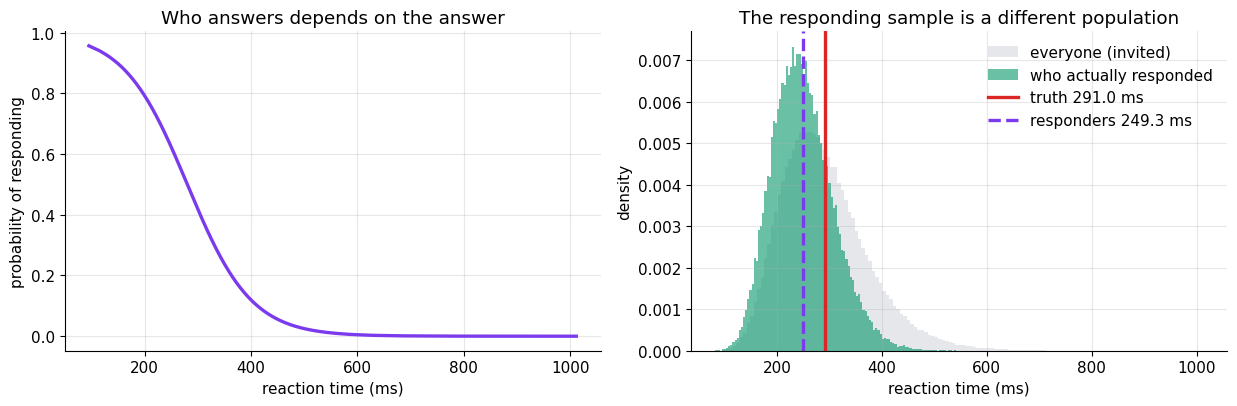

In [20]:
# ============================================================
#  NON-RESPONSE: probability of finishing falls with reaction time.
# ============================================================
rng_nr = np.random.default_rng(606)

p_respond = 1.0 / (1.0 + np.exp((POP - 280.0) / 60.0))   # ~96% fastest, ~0% slowest

invited   = rng_nr.integers(0, POP_N, size=120_000)      # 120k people invited
responded = invited[rng_nr.random(invited.size) < p_respond[invited]]
answers   = POP[responded]

print(f"invited   : {invited.size:,} people")
print(f"responded : {answers.size:,} people  "
      f"(response rate {answers.size / invited.size:.1%})\n")
print(f"{'':<30}{'value':>12}{'error vs mu':>14}")
print("-" * 56)
print(f"{'true population mean (mu)':<30}{POP_MU:>12.2f}")
print(f"{'mean of the responders':<30}{answers.mean():>12.2f}"
      f"{answers.mean() - POP_MU:>+14.2f}")
print()
print(f"With {answers.size:,} responses -- a huge study by any standard -- the")
print(f"estimate is off by {answers.mean() - POP_MU:+.2f} ms, "
      f"{abs(answers.mean() - POP_MU) / POP_MU:.1%} of the truth.")
print(f"Its standard error is around "
      f"{answers.std(ddof=1) / np.sqrt(answers.size):.3f} ms, so it would be")
print("reported with an error bar far too narrow to contain the right answer.")

fig, (b1, b2) = plt.subplots(1, 2, figsize=(12.5, 4.2))
order = np.argsort(POP[:4000])
b1.plot(POP[:4000][order], p_respond[:4000][order], color=C_EXACT, lw=2.4)
b1.set_xlabel("reaction time (ms)"); b1.set_ylabel("probability of responding")
b1.set_title("Who answers depends on the answer")

b2.hist(POP, bins=140, density=True, color=C_SOFT, label="everyone (invited)")
b2.hist(answers, bins=140, density=True, color=C_AREA, alpha=0.6,
        label="who actually responded")
b2.axvline(POP_MU, color=C_SLOPE, lw=2.4, label=f"truth {POP_MU:.1f} ms")
b2.axvline(answers.mean(), color=C_EXACT, lw=2.4, ls="--",
           label=f"responders {answers.mean():.1f} ms")
b2.set_xlabel("reaction time (ms)"); b2.set_ylabel("density")
b2.set_title("The responding sample is a different population")
b2.legend(frameon=False)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows


Left: the response probability, sliding from near-certain for the fastest people
down to near-zero for the slowest. Nothing here is a hard cutoff — every single
person in the population *could* respond.

Right: and yet the green responding sample is visibly shifted left of the grey
population, its right tail thinned almost to nothing. The purple dashed mean of
the responders sits well below the red truth, by the amount printed above, on a
sample of tens of thousands.

**The common misread:** treating a high response count as evidence that
non-response does not matter. What matters is not how many answered but *whether
answering was related to the answer*. Here it is, so the bias survives at any
size — and because the printed standard error shrinks with the count, a bigger
survey states the wrong number with more confidence. That is why survey
methodologists care far more about the response *rate* and who is missing from
it than about the raw number of responses.


</div>

---

## 2.6 The fix: random sampling, and what "i.i.d." means

Everything that went wrong in §2.5 was the same thing: **whether you ended up in
the sample depended on your reaction time.** Break that link and the problem
disappears.

That is all random sampling is. Not "haphazard", not "whoever showed up" — a
deliberate procedure in which every member of the population has a known,
non-zero chance of being chosen, and that chance has nothing to do with the
quantity being measured. Then your sample is a miniature of the population, and
the whole apparatus of Parts 3 to 9 applies.

You will see the phrase **i.i.d.** everywhere. It is two conditions:

- **Independent** — who got picked first tells you nothing about who gets picked
  next. Surveying one person and then their spouse is not independent; the second
  measurement carries much less new information than the first.
- **Identically distributed** — every draw comes from the *same* population.
  Measuring reaction times in the morning and then switching to the evening
  breaks this, even if each block is internally random.

Both assumptions are things about *how you collected the data*, which is exactly
why no amount of staring at the numbers can confirm them, and why "how was this
sample obtained?" is the first question to ask about any result — including your
own.


<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares


**Your test-set score is $\bar{x}$, not $\mu$.**

The number you actually want is the accuracy your model would achieve on all
future inputs — a population parameter, permanently invisible. What you have is
its performance on a few thousand examples that happened to be held out: a
sample statistic, with all the scatter of §2.2 attached.

So a test set is a study with $n$ = its size, and everything above applies
directly. Two models at 93.2% and 92.8% on the same 2,000-example test set differ
by less than that study's sampling noise, and declaring a winner is reading a
coin flip. Doubling the test set does not halve the uncertainty — §2.4's √n costs
you four times the data for that. And a leaderboard where hundreds of models are
scored on one fixed test set is Part 8's multiple-comparisons trap: the top
entry is partly there on luck, which is precisely why leaderboard results
degrade on fresh data.


</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares


**Biased training data is §2.5, and it is the failure mode that ships.**

A model trained on a sample learns the distribution of *that sample*, not of the
world. Every mechanism above has a direct counterpart: faces collected from
image searches in one language (**selection**), a churn model trained only on
customers still present in the database (**survivorship**), a "user needs"
dataset built from people who already use the product (**convenience**), a
sentiment model trained on the reviews people bothered to write (**non-response**).

The dangerous part is the same as in the simulation: the bias is invisible from
inside. Your held-out test set was carved from the same skewed pool, so it
reports excellent numbers, and the gap only appears in production against the
population you never sampled. Scaling up the training set makes the model *more
confident* in the same distortion — which is exactly the table in §2.5, with a
larger budget.

This is why dataset documentation asks *how was this collected, and who is
missing* before it asks how big it is.


</div>

---

### Where that leaves us

We now have the vocabulary and one hard-won fact. A sample statistic is a random
quantity: take another sample and it changes. Judge it not by one draw but by
its behaviour across all the draws you could have made — **bias**, whether it is
centred on the truth, and **variance**, how widely it scatters. More data buys
you variance and buys you nothing at all against bias.

And in §2.4 something specific turned up that we deliberately did not explain.
The spread of the sample mean fell as $1/\sqrt{n}$, so precisely that spread
times $\sqrt{n}$ stayed pinned near the population standard deviation across two
orders of magnitude. That is not a coincidence and it is not an approximation
that happens to fit.

Part 3 shows why it must be so — and something stranger besides: those piles of
sample means in the left panel of §2.4 were **bell-shaped**, even though the
population they came from is visibly not. That is the Central Limit Theorem, and
it is the reason the rest of this notebook can exist.


---

# 3️⃣ Sampling distributions and the Central Limit Theorem

Part 2 left two debts, and this part pays both.

**The first.** The spread of the sample mean fell as $1/\sqrt{n}$ — so exactly
that spread times $\sqrt{n}$ sat pinned near the population standard deviation
across two orders of magnitude. That was measured. It was not explained, and it
is still not a **number** you could use: nothing so far tells you how far off a
sample mean of forty people is likely to be.

**The second.** Those piles of sample means came out **bell-shaped**, from a
population that is visibly not.

Both answers run through a single idea, and it is the one that people reliably
lose the thread on, so we are going to take it slowly. The idea is that **a
statistic has a distribution of its own** — separate from, and shaped
differently to, the distribution of the data it was computed from.

Once you have that, both debts are settled at once: the shape of that
distribution is a bell curve almost no matter what the data looked like, and its
width is given by a formula with one square root in it. Together they are the
reason statistics can put honest error bars on anything at all.


## 3.1 Three different distributions, and why people confuse them

Here is where the wheels usually come off. In one paragraph of a statistics text,
the word *distribution* can mean three different things.

| # | Name | It is a distribution **of** … | How many numbers go into it |
|---|---|---|---|
| 1 | the **population** distribution | every individual in the population | 200,000 reaction times |
| 2 | the **sample** distribution | the individuals you actually measured | 40 reaction times |
| 3 | the **sampling distribution of the mean** | *sample means*, over many repeated samples | 20,000 numbers, each one a mean of 40 |

Numbers 1 and 2 are distributions of **people**. Number 3 is a distribution of
**summaries**. Every dot in it cost you a whole study.

That is the whole difficulty: number 3 is not something you can see in your data.
You only ever run the study once, so you only ever get **one** dot from
distribution 3. Everything in this notebook after this point is machinery for
reasoning about a distribution you will only ever sample once.

Except here. Here we simulate the population, so we can run the study twenty
thousand times and *look at the thing directly*.


In [21]:
# ============================================================
#  The machine: run the study many times.
#  Each "study" = draw n people, compute their mean, write it down.
# ============================================================
import numpy as np
from scipy import stats

RNG3 = np.random.default_rng(31415)


def sample_means(n, reps, rng=RNG3, pop=None):
    """Run `reps` studies of size `n` and return the `reps` sample means.

    Drawing with replacement from 200,000 people is indistinguishable from
    drawing without, and is much faster, so we index at random.
    """
    pop = POP if pop is None else pop
    draws = pop[rng.integers(0, pop.size, size=(reps, n))]   # shape (reps, n)
    return draws.mean(axis=1)


# Five studies, one at a time, so you can see what one "dot" costs.
for study in range(1, 6):
    one = POP[RNG3.integers(0, POP_N, size=SAMPLE_N)]
    print(f"study {study}:  n = {SAMPLE_N},  sample mean = {one.mean():7.2f} ms")

print()
print(f"the truth we are chasing:  mu = {POP_MU:7.2f} ms")
print()
print("Five studies, five different answers. Those five numbers are five draws")
print("from the SAMPLING DISTRIBUTION. Let us draw 20,000 of them.")


study 1:  n = 40,  sample mean =  290.96 ms
study 2:  n = 40,  sample mean =  284.40 ms
study 3:  n = 40,  sample mean =  268.82 ms
study 4:  n = 40,  sample mean =  293.95 ms
study 5:  n = 40,  sample mean =  297.79 ms

the truth we are chasing:  mu =  290.99 ms

Five studies, five different answers. Those five numbers are five draws
from the SAMPLING DISTRIBUTION. Let us draw 20,000 of them.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

A **sampling distribution** is the distribution of a *statistic* — a mean, a median, an accuracy score — that you would see if you repeated the whole study over and over.

It is not the distribution of your data. It is the distribution of *answers*. If your study gives one number, the sampling distribution is the cloud of numbers that study **could have** given you.

Written down: if $\bar{x}$ is the mean of a sample of size $n$, then $\bar{x}$ is itself a random quantity, and the sampling distribution is the distribution of $\bar{x}$.

</div>

In [22]:
# ============================================================
#  20,000 studies of 40 people each. 800,000 measurements,
#  boiled down to 20,000 sample means.
# ============================================================
REPS = 20_000
means40 = sample_means(SAMPLE_N, REPS)

print(f"{REPS:,} studies of n = {SAMPLE_N}")
print(f"  first five sample means : {np.round(means40[:5], 2)}")
print()
print(f"  centre of the 20,000 means : {means40.mean():8.3f} ms")
print(f"  the true population mean   : {POP_MU:8.3f} ms")
print(f"  difference                 : {means40.mean() - POP_MU:+8.3f} ms")
print()
print(f"  spread of the POPULATION   : {POP_SD:8.3f} ms   (sd of individuals)")
print(f"  spread of the SAMPLE MEANS : {means40.std(ddof=0):8.3f} ms   (sd of means)")
print(f"  the means are {POP_SD / means40.std(ddof=0):.2f}x tighter than the people.")


20,000 studies of n = 40
  first five sample means : [317.24 284.62 291.25 293.66 286.4 ]

  centre of the 20,000 means :  290.960 ms
  the true population mean   :  290.989 ms
  difference                 :   -0.029 ms

  spread of the POPULATION   :   83.012 ms   (sd of individuals)
  spread of the SAMPLE MEANS :   13.126 ms   (sd of means)
  the means are 6.32x tighter than the people.


Two things in that output are worth stopping on.

**The means are centred on the truth.** Individual studies miss, but they miss
in both directions and the misses cancel. A statistic whose sampling
distribution is centred on the thing it estimates is called **unbiased**, and
the sample mean is unbiased for the population mean. That is a promise about the
long run, not about your study.

**The means are far tighter than the people.** The individuals spread out over
roughly the printed population standard deviation; the means over a small
fraction of it. Section 3.4 says exactly what that fraction is.

Now the shape.


## 3.2 The surprise

Our population is visibly **skewed** — a hard floor near zero, a long tail of
slow reactions. Nothing about it is bell-shaped, and no amount of staring at it
will make it so.

Watch what happens to the means anyway.


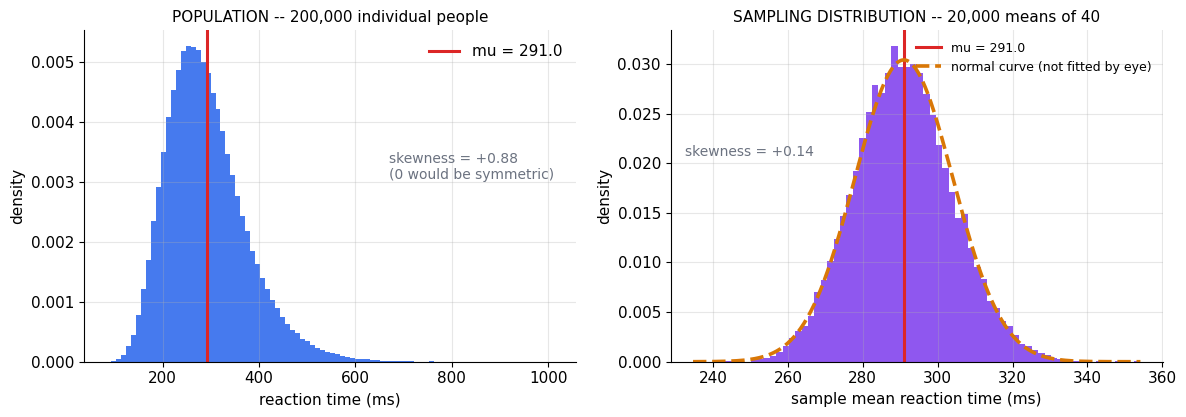

population skewness      : +0.880
sampling-dist skewness   : +0.144
  -> averaging 40 values removed 83.6% of the skew.


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

# ---- left: the population, in all its skewed glory
ax1.hist(POP, bins=90, color=C_F, alpha=0.85, density=True)
ax1.axvline(POP_MU, color=C_SLOPE, lw=2.2, label=f"mu = {POP_MU:.1f}")
ax1.set_title(f"POPULATION -- {POP_N:,} individual people", fontsize=11)
ax1.set_xlabel("reaction time (ms)"); ax1.set_ylabel("density")
ax1.legend(frameon=False)
ax1.text(0.62, 0.55, f"skewness = {stats.skew(POP):+.2f}\n(0 would be symmetric)",
         transform=ax1.transAxes, fontsize=10, color=C_GREY)

# ---- right: the sampling distribution of the mean, same x-axis scale span
ax2.hist(means40, bins=70, color=C_EXACT, alpha=0.85, density=True)
ax2.axvline(POP_MU, color=C_SLOPE, lw=2.2, label=f"mu = {POP_MU:.1f}")

# overlay the normal curve nobody asked for and yet it fits
grid = np.linspace(means40.min(), means40.max(), 400)
ax2.plot(grid, stats.norm.pdf(grid, means40.mean(), means40.std(ddof=0)),
         color=C_APPROX, lw=2.6, ls="--", label="normal curve (not fitted by eye)")
ax2.set_title(f"SAMPLING DISTRIBUTION -- {REPS:,} means of {SAMPLE_N}", fontsize=11)
ax2.set_xlabel("sample mean reaction time (ms)"); ax2.set_ylabel("density")
ax2.legend(frameon=False, fontsize=9)
ax2.text(0.03, 0.62, f"skewness = {stats.skew(means40):+.2f}",
         transform=ax2.transAxes, fontsize=10, color=C_GREY)

fig.tight_layout(); plt.show()

print(f"population skewness      : {stats.skew(POP):+.3f}")
print(f"sampling-dist skewness   : {stats.skew(means40):+.3f}")
print(f"  -> averaging 40 values removed {1 - abs(stats.skew(means40)) / abs(stats.skew(POP)):.1%}"
      f" of the skew.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left is lopsided. Right is a bell — and the dashed curve is not a curve fitted to the histogram, it is the normal density with the mean and standard deviation printed above, drawn independently and landing on top of the bars.

The right panel is built entirely out of the left panel. Same people, same skew, nothing added. Averaging forty of them was enough to turn a lopsided pile into a symmetric bell, and the printed skewness numbers say how much of the lopsidedness survived.

This is the **Central Limit Theorem**, and it should feel a little unreasonable. The population's shape barely matters. The mean of enough of anything is normal.

**The common misread:** "so my data is normally distributed." It is not, and the left panel is the proof. The CLT says nothing whatsoever about the shape of your data — it is a claim about the *sample mean*. A test that assumes normal **data** is not rescued by the CLT; a method that relies on the sampling distribution of the mean usually is.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

The single most common confusion in this entire subject is between **"the distribution of the data"** and **"the distribution of the statistic"**.

They are different objects, drawn on different axes, with different widths and different shapes. In the figure above the left panel's x-axis spans hundreds of milliseconds of individual people; the right panel's spans a few tens of milliseconds of *study results*.

A useful habit: whenever someone says "the distribution", ask **"of what?"** — of people, or of answers? Almost every muddled sentence about p-values and confidence intervals dissolves once you insist on that.

</div>

## 3.3 Watching normality arrive

"The mean of enough of anything is normal" hides the interesting question: **how
much is enough?**

So run the same experiment at $n = 1, 2, 5, 30, 100$. At $n = 1$ the "sample
mean" is just one person, so the sampling distribution *is* the population — as
skewed as it gets. Each step up should straighten it out a bit.

We will not judge the shapes by eye. Two numbers do it properly:

- **skewness** — how lopsided. Zero for any symmetric distribution.
- **KS distance to normal** — the largest gap between the standardised sampling
  distribution's cumulative curve and a true normal's. Zero would be a perfect
  match; it can only ever be positive.


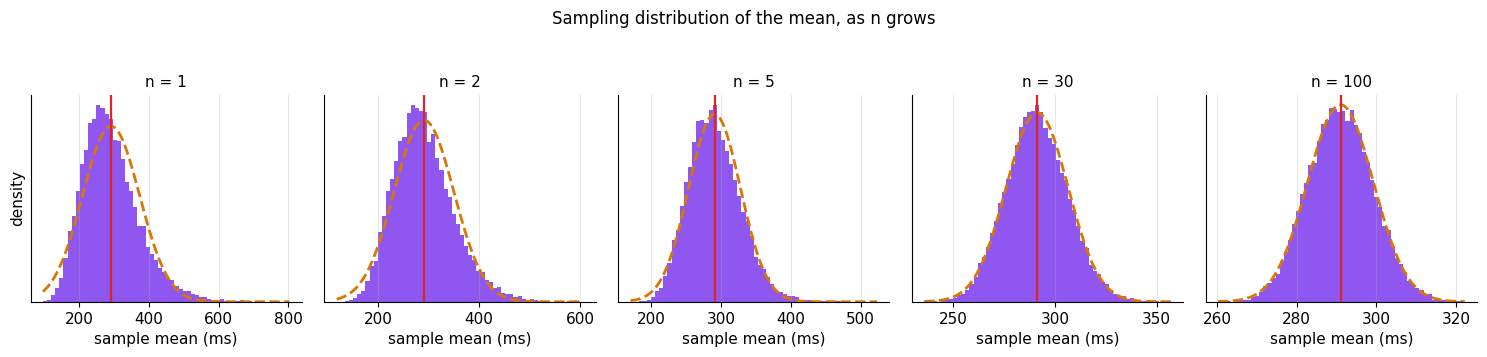

    n |  skewness | excess kurt | sd of means |  KS dist to normal
--------------------------------------------------------------------
    1 |    +0.858 |      +1.263 |      82.059 |             0.0554
    2 |    +0.620 |      +0.664 |      59.125 |             0.0440
    5 |    +0.430 |      +0.383 |      37.145 |             0.0295
   30 |    +0.168 |      +0.090 |      15.205 |             0.0136
  100 |    +0.071 |      -0.008 |       8.273 |             0.0065

Every column marches toward normal: skewness toward 0, excess kurtosis
toward 0, KS distance toward 0. Nothing here was asserted -- it was measured.


In [24]:
# ============================================================
#  The same experiment at five sample sizes.
# ============================================================
NS = [1, 2, 5, 30, 100]
REPS_GRID = 20_000

grids = {n: sample_means(n, REPS_GRID) for n in NS}

fig, axes = plt.subplots(1, len(NS), figsize=(15, 3.4), sharey=False)
rows = []

for ax, n in zip(axes, NS):
    m = grids[n]
    ax.hist(m, bins=60, color=C_EXACT, alpha=0.85, density=True)

    g = np.linspace(m.min(), m.max(), 300)
    ax.plot(g, stats.norm.pdf(g, m.mean(), m.std(ddof=0)),
            color=C_APPROX, lw=2.0, ls="--")
    ax.axvline(POP_MU, color=C_SLOPE, lw=1.6)
    ax.set_title(f"n = {n}", fontsize=11)
    ax.set_xlabel("sample mean (ms)")
    ax.set_yticks([])

    z = (m - m.mean()) / m.std(ddof=0)          # standardise, then compare
    ks = stats.kstest(z, "norm").statistic
    rows.append((n, stats.skew(m), stats.kurtosis(m), m.std(ddof=0), ks))

axes[0].set_ylabel("density")
fig.suptitle("Sampling distribution of the mean, as n grows", y=1.04, fontsize=12)
fig.tight_layout(); plt.show()

print(f"{'n':>5} | {'skewness':>9} | {'excess kurt':>11} | {'sd of means':>11} | {'KS dist to normal':>18}")
print("-" * 68)
for n, sk, ku, sd, ks in rows:
    print(f"{n:>5} | {sk:>+9.3f} | {ku:>+11.3f} | {sd:>11.3f} | {ks:>18.4f}")
print()
print("Every column marches toward normal: skewness toward 0, excess kurtosis")
print("toward 0, KS distance toward 0. Nothing here was asserted -- it was measured.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Five panels, one experiment, five sample sizes. The leftmost is the population itself (a "mean of one" is a person), and it is the same skewed pile from before. By $n = 30$ the dashed normal curve is hard to distinguish from the bars.

Two changes happen at once and it is worth separating them. The shape becomes **symmetric** — that is the CLT. The spread becomes **narrower** — that is the standard error, which is a different fact and is next. Note each panel has its own x-axis: the narrowing is real but the panels do not show it. The `sd of means` column does.

**The common misread:** treating "n ≥ 30" as a law. It is a rule of thumb calibrated on mildly skewed data, and the table shows why it is only a rule of thumb — at $n = 30$ the skewness has shrunk but is not zero. For a population much more skewed than this one, $n = 30$ is nowhere near enough, and §3.6 shows what that failure looks like.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The claim "it becomes normal" is the kind of claim that is easy to make and easy to let slide. So it was measured, three ways, at five sample sizes, and every one of the three measures falls monotonically toward the value a true normal distribution would give.

The KS distance is the strictest of the three: it is the widest vertical gap between the standardised sampling distribution and the normal cumulative curve, so it catches disagreement anywhere, not just lopsidedness or tail weight. It shrinks too.

</div>

## 3.4 The standard error: how wide is that bell?

The shape is settled. Now the width — and unlike the shape, the width has an
exact formula that falls out of two rules about variance.

**Rule 1.** For independent quantities, variances add:
$\operatorname{Var}(X_1 + X_2) = \operatorname{Var}(X_1) + \operatorname{Var}(X_2)$.

**Rule 2.** Multiplying by a constant multiplies the variance by its square:
$\operatorname{Var}(cX) = c^2 \operatorname{Var}(X)$.

A sample mean is a sum, divided by a constant. So:

$$\operatorname{Var}(\bar{x})
= \operatorname{Var}\!\left(\frac{1}{n}\sum_{i=1}^{n} X_i\right)
= \frac{1}{n^{2}} \operatorname{Var}\!\left(\sum_{i=1}^{n} X_i\right)
= \frac{1}{n^{2}} \cdot n\sigma^{2}
= \frac{\sigma^{2}}{n}$$

Take the square root of both sides and you have the width of the bell:

$$\operatorname{SE}(\bar{x}) = \frac{\sigma}{\sqrt{n}}$$

That quantity — the standard deviation of a *statistic's* sampling distribution
— is called the **standard error**. It is the single most useful number in
applied statistics, and it has a whole formula's worth of assumptions hiding in
"Rule 1 requires independence".

<div style="background: linear-gradient(135deg, #134e4a 0%, #0f766e 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### Standard deviation vs standard error

**Standard deviation** describes the **people**. It does not shrink when you
collect more data — measure a million people and reaction times still vary by
roughly the same amount, because that is a fact about people.

**Standard error** describes your **answer**. It does shrink, because more data
means a better-pinned-down estimate.

They are printed in the same units and are routinely swapped by accident. If a
paper's error bars shrink with sample size, they are standard errors.


</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$\sigma/\sqrt{n}$ says: **how far a typical study's mean lands from the truth.**

$\sigma$ is how much individual people differ. Noisier people, noisier answer. $\sqrt{n}$ is how much averaging protects you.

Read it as a ratio of two things you can feel: the messiness of the world on top, the effort you put in on the bottom — and the effort only counts under a square root, which is the bad news of the next section.

</div>

In [25]:
# ============================================================
#  Does sigma/sqrt(n) actually predict the width we measured?
#  We have 20,000 real sample means at each n. Compare.
# ============================================================
print(f"{'n':>5} | {'formula sigma/sqrt(n)':>21} | {'measured sd of means':>21} | {'off by':>9}")
print("-" * 66)
for n in NS:
    formula  = POP_SD / np.sqrt(n)
    measured = grids[n].std(ddof=0)
    print(f"{n:>5} | {formula:>21.4f} | {measured:>21.4f} | "
          f"{100 * (measured - formula) / formula:>+8.2f}%")

print()
print("And at the sample size this notebook actually uses:")
se_formula  = POP_SD / np.sqrt(SAMPLE_N)
se_measured = means40.std(ddof=0)
print(f"  n = {SAMPLE_N}")
print(f"  formula   sigma/sqrt(n) = {se_formula:8.4f} ms")
print(f"  measured  sd of {REPS:,} sample means = {se_measured:8.4f} ms")
print(f"  discrepancy             = {se_measured - se_formula:+8.4f} ms "
      f"({100 * (se_measured - se_formula) / se_formula:+.3f}%)")
print()
print("The remaining gap is Monte-Carlo noise: 20,000 studies is a lot, but it")
print("is not infinity. Raise REPS and the gap shrinks -- it does not converge")
print("to some other number.")


    n | formula sigma/sqrt(n) |  measured sd of means |    off by
------------------------------------------------------------------
    1 |               83.0120 |               82.0588 |    -1.15%
    2 |               58.6983 |               59.1246 |    +0.73%
    5 |               37.1241 |               37.1454 |    +0.06%
   30 |               15.1558 |               15.2046 |    +0.32%
  100 |                8.3012 |                8.2731 |    -0.34%

And at the sample size this notebook actually uses:
  n = 40
  formula   sigma/sqrt(n) =  13.1253 ms
  measured  sd of 20,000 sample means =  13.1259 ms
  discrepancy             =  +0.0006 ms (+0.004%)

The remaining gap is Monte-Carlo noise: 20,000 studies is a lot, but it
is not infinity. Raise REPS and the gap shrinks -- it does not converge
to some other number.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The derivation used two algebraic rules about variance and never touched the data. The measurement used 20,000 simulated studies and never touched the algebra. They agree to a fraction of a percent at every sample size in the table.

That is the pattern this whole notebook runs on. A formula is a claim about the world; a simulation is a way to check the claim. When they agree you have learned something. When they disagree — §3.6 — the formula is the one that is wrong, and it is wrong for a reason worth knowing.

One honest caveat: the formula needs $\sigma$, the **population** standard deviation. We have it because we built the population. A real study has only $s$ from its own forty people, and substituting $s$ for $\sigma$ has a cost that Part 4 has to pay in full.

</div>

## 3.5 The square root is expensive

$\sqrt{n}$ in the denominator is the reason data collection has diminishing
returns, and the arithmetic is worth having at your fingertips.

To halve the standard error you must divide $\sqrt{n}$ into it twice — which
means multiplying $n$ by **four**. To get ten times more precise, you need a
hundred times the data.


      n |  SE = sigma/sqrt(n) |   vs n=10 |  n needed to halve this SE
------------------------------------------------------------------------
     10 |              26.251 |     1.00x |                         40
     40 |              13.125 |     0.50x |                        160
    160 |               6.563 |     0.25x |                        640
    640 |               3.281 |     0.12x |                      2,560
   2560 |               1.641 |     0.06x |                     10,240
  10240 |               0.820 |     0.03x |                     40,960


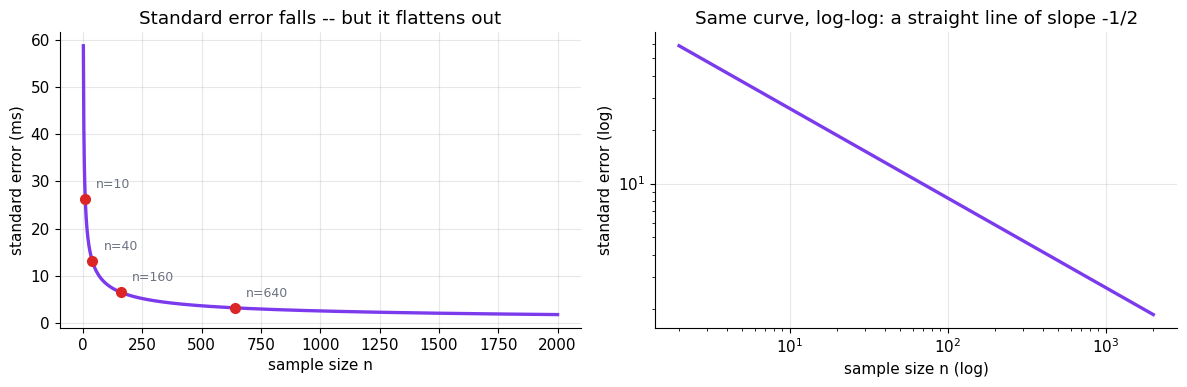


Going from n=10 to n=40 buys you 2.00x precision for 30 more people.
Going from n=2560 to n=10240 buys the same 2.00x for 7,680 more.


In [26]:
# ============================================================
#  What each additional order of magnitude of data buys you.
# ============================================================
sizes = [10, 40, 160, 640, 2560, 10240]

print(f"{'n':>7} | {'SE = sigma/sqrt(n)':>19} | {'vs n=10':>9} | {'n needed to halve this SE':>26}")
print("-" * 72)
base = POP_SD / np.sqrt(10)
for n in sizes:
    se = POP_SD / np.sqrt(n)
    print(f"{n:>7} | {se:>19.3f} | {se / base:>8.2f}x | {4 * n:>26,}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.0))

nn = np.arange(2, 2001)
axL.plot(nn, POP_SD / np.sqrt(nn), color=C_EXACT, lw=2.4)
for n in [10, 40, 160, 640]:
    axL.plot(n, POP_SD / np.sqrt(n), "o", color=C_SLOPE, ms=7)
    axL.annotate(f"n={n}", (n, POP_SD / np.sqrt(n)),
                 textcoords="offset points", xytext=(8, 8), fontsize=9, color=C_GREY)
axL.set_title("Standard error falls -- but it flattens out")
axL.set_xlabel("sample size n"); axL.set_ylabel("standard error (ms)")

axR.plot(nn, POP_SD / np.sqrt(nn), color=C_EXACT, lw=2.4)
axR.set_xscale("log"); axR.set_yscale("log")
axR.set_title("Same curve, log-log: a straight line of slope -1/2")
axR.set_xlabel("sample size n (log)"); axR.set_ylabel("standard error (log)")

fig.tight_layout(); plt.show()

print()
print(f"Going from n=10 to n=40 buys you {(POP_SD/np.sqrt(10)) / (POP_SD/np.sqrt(40)):.2f}x precision for 30 more people.")
print(f"Going from n=2560 to n=10240 buys the same {(POP_SD/np.sqrt(2560)) / (POP_SD/np.sqrt(10240)):.2f}x for 7,680 more.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the standard error against sample size. The first hundred observations buy an enormous amount of precision; the ten-thousandth buys almost nothing. The curve is falling everywhere, but it is *visibly* falling only at the left.

Right: the same curve on log-log axes, where it is a straight line. Its slope is $-1/2$, which is the square root written as a picture. Every quadrupling of $n$ steps the same distance down.

The printed comparison is the punchline: the same precision gain that cost 30 extra people at small $n$ costs 7,680 extra people later.

**The common misread:** reading the flattening as "more data stops helping". It never stops helping — the curve has no floor and keeps descending forever. What flattens is the *return per observation*, which is an argument about budgets, not about statistics. If you need one more decimal place, you can always buy it; you just cannot buy it cheaply.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

This is why test sets have the sizes they do, and why leaderboards are often measuring noise.

A 2,000-item test set puts a standard error of about $\sqrt{p(1-p)/n} \approx 1$ percentage point on an accuracy near 0.9 — so two models scoring 90.3% and 89.8% are not distinguishable by that test set, no matter how confidently the ranking is reported. Wanting to resolve 0.1 percentage points means wanting roughly a hundred times the test data.

It is also why more training data has diminishing returns in a way people find disappointing: the noise floor on any quantity you estimate from $n$ examples falls like $1/\sqrt{n}$, and neural scaling laws are power laws for closely related reasons. Part 9 puts an actual error bar on an actual model score.

</div>

## 3.6 When the CLT does not rescue you

Most treatments stop at §3.5, which leaves you with the impression that the CLT
is unconditional. It is not, and the failures are not exotic — one of them is
just "skewed data and a small sample", which describes a great deal of real
work.

There are two distinct ways to be let down, and they are not the same kind of
problem.

**Failure 1 — slow convergence.** The CLT still holds, but $n = 30$ is nowhere
near far enough along. Heavy skew is the usual cause. This is a *practical*
failure: the theory is fine, your sample size is not.

**Failure 2 — no convergence at all.** For some distributions the theorem simply
does not apply, because it requires finite variance and they do not have one.
No sample size saves you. This is a *structural* failure.


gentle population (ours) skewness :    +0.88
heavy population         skewness :    +7.30

     n |  skewness of sample means |  KS dist to normal
--------------------------------------------------------
     5 |                    +3.173 |             0.1160
    30 |                    +1.293 |             0.0622


   500 |                    +0.324 |             0.0213


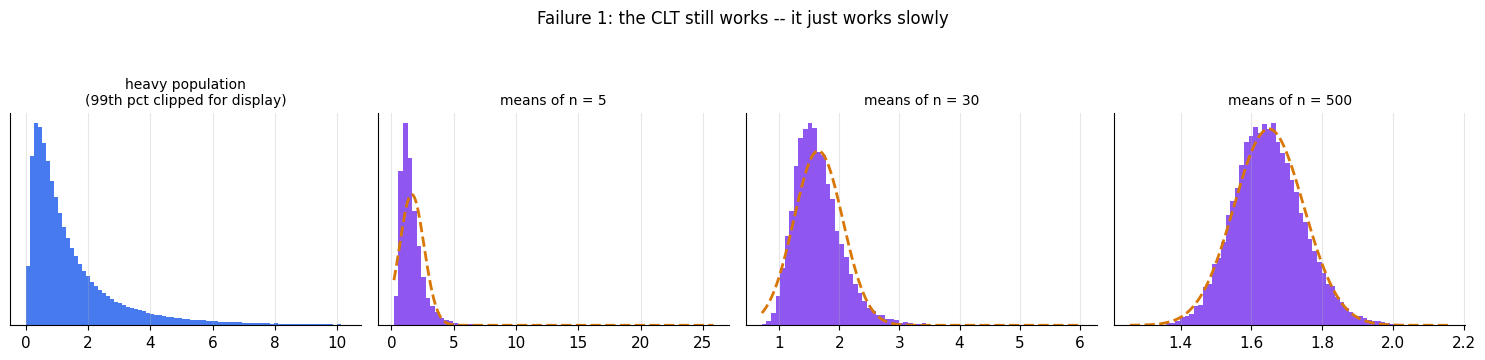


Now the comparison that matters -- our own gentler population at n = 30:
  gentle population, n =  30 : skew +0.168, KS 0.0136
  heavy  population, n =  30 : KS 0.0622   -> 4.6x further from normal
  heavy  population, n = 500 : KS 0.0213   -> only HERE is it comparable to the gentle one at n = 30

Same theorem, same rule of thumb, roughly 16x the data needed to reach
the same quality of approximation. 'n >= 30' is not a property of n.


In [27]:
# ============================================================
#  FAILURE 1 -- heavy skew, small n.
#  Same lognormal family as our population, but far more skewed.
# ============================================================
RNG_HS = np.random.default_rng(9091)
POP_SKEW = RNG_HS.lognormal(mean=0.0, sigma=1.0, size=200_000)   # far more skewed

print(f"gentle population (ours) skewness : {stats.skew(POP):+8.2f}")
print(f"heavy population         skewness : {stats.skew(POP_SKEW):+8.2f}")
print()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
axes[0].hist(POP_SKEW[POP_SKEW < np.quantile(POP_SKEW, 0.99)], bins=80,
             color=C_F, alpha=0.85, density=True)
axes[0].set_title("heavy population\n(99th pct clipped for display)", fontsize=10)
axes[0].set_yticks([])

print(f"{'n':>6} | {'skewness of sample means':>25} | {'KS dist to normal':>18}")
print("-" * 56)
heavy_ks = {}
for ax, n in zip(axes[1:], [5, 30, 500]):
    m = sample_means(n, 20_000, rng=RNG_HS, pop=POP_SKEW)
    ax.hist(m, bins=70, color=C_EXACT, alpha=0.85, density=True)
    g = np.linspace(m.min(), m.max(), 300)
    ax.plot(g, stats.norm.pdf(g, m.mean(), m.std(ddof=0)),
            color=C_APPROX, lw=2.0, ls="--")
    ax.set_title(f"means of n = {n}", fontsize=10)
    ax.set_yticks([])
    z = (m - m.mean()) / m.std(ddof=0)
    heavy_ks[n] = stats.kstest(z, "norm").statistic
    print(f"{n:>6} | {stats.skew(m):>+25.3f} | {heavy_ks[n]:>18.4f}")

fig.suptitle("Failure 1: the CLT still works -- it just works slowly", y=1.05, fontsize=12)
fig.tight_layout(); plt.show()

z30 = (grids[30] - grids[30].mean()) / grids[30].std(ddof=0)
gentle_ks30 = stats.kstest(z30, "norm").statistic
print()
print("Now the comparison that matters -- our own gentler population at n = 30:")
print(f"  gentle population, n =  30 : skew {stats.skew(grids[30]):+.3f}, KS {gentle_ks30:.4f}")
print(f"  heavy  population, n =  30 : KS {heavy_ks[30]:.4f}   "
      f"-> {heavy_ks[30]/gentle_ks30:.1f}x further from normal")
print(f"  heavy  population, n = 500 : KS {heavy_ks[500]:.4f}   "
      f"-> only HERE is it comparable to the gentle one at n = 30")
print()
print("Same theorem, same rule of thumb, roughly 16x the data needed to reach")
print("the same quality of approximation. 'n >= 30' is not a property of n.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Leftmost panel is a far more skewed population than ours: the same lognormal family with a wider spread on the log scale, and a skewness an order of magnitude larger, as printed. The three panels that follow are its sampling distributions of the mean at $n = 5$, $30$ and $500$.

At $n = 30$ — the sample size the rule of thumb blesses — the sampling distribution is still obviously lopsided, and the printed skewness and KS distance say so numerically. The dashed normal curve is not a good description of those bars. It is drifting toward normal, exactly as the theorem promises, but it has not arrived.

The printed comparison is the point: this population needs roughly $n = 500$ to reach the closeness-to-normal that our gentler population already had at $n = 30$. Sixteen times the data for the same approximation quality, from a population that is not remotely pathological.

**The common misread:** "n = 30 is enough." Enough depends entirely on the population, and you generally cannot see the population. What you *can* do is look at your own sample's skewness, and — better — use a method that does not need the assumption at all. That is the bootstrap, in Part 4.

</div>

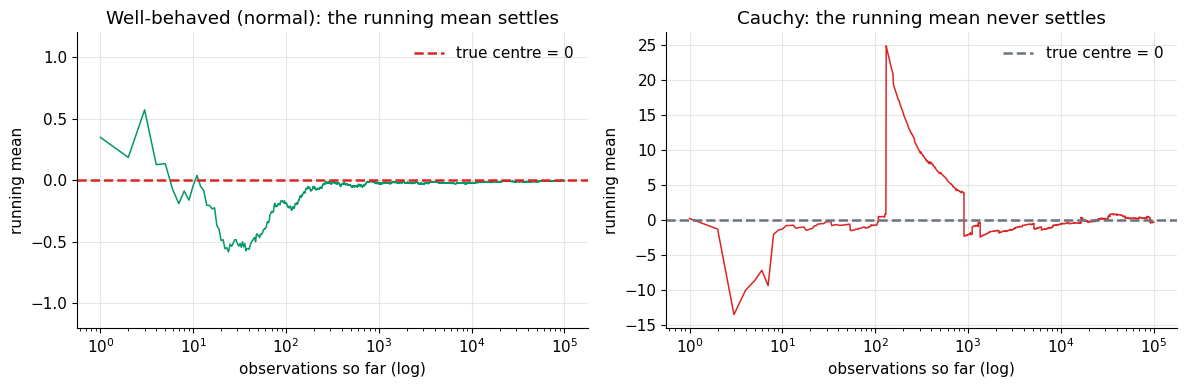

 after n obs |  normal running mean |  Cauchy running mean
------------------------------------------------------------
          10 |              -0.0433 |              -1.2841
         100 |              -0.1921 |              -0.7566
       1,000 |              -0.0261 |              -2.0922
      10,000 |              -0.0220 |              -0.6148
     100,000 |              -0.0035 |              -0.3024

IQR of ONE Cauchy draw            :   2.0218
IQR of the MEAN of 500 Cauchy draws:   2.0064
ratio                              :   1.0076  (1.00 = averaging bought nothing)

For a well-behaved population, averaging 500 would have tightened the
spread by sqrt(500) = 22.36x. Here it tightened it by essentially nothing.


In [28]:
# ============================================================
#  FAILURE 2 -- the Cauchy distribution. Infinite variance.
#  Averaging does literally nothing. Watch the running mean wander.
# ============================================================
RNG_C = np.random.default_rng(271828)
N_WALK = 100_000

cauchy = RNG_C.standard_cauchy(N_WALK)
normal = RNG_C.normal(0, 1, N_WALK)

run_c = np.cumsum(cauchy) / np.arange(1, N_WALK + 1)
run_n = np.cumsum(normal) / np.arange(1, N_WALK + 1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.0), sharex=True)

axL.plot(np.arange(1, N_WALK + 1), run_n, color=C_AREA, lw=1.1)
axL.axhline(0.0, color=C_SLOPE, lw=1.8, ls="--", label="true centre = 0")
axL.set_xscale("log"); axL.set_ylim(-1.2, 1.2)
axL.set_title("Well-behaved (normal): the running mean settles")
axL.set_xlabel("observations so far (log)"); axL.set_ylabel("running mean")
axL.legend(frameon=False)

axR.plot(np.arange(1, N_WALK + 1), run_c, color=C_SLOPE, lw=1.1)
axR.axhline(0.0, color=C_GREY, lw=1.8, ls="--", label="true centre = 0")
axR.set_xscale("log")
axR.set_title("Cauchy: the running mean never settles")
axR.set_xlabel("observations so far (log)"); axR.set_ylabel("running mean")
axR.legend(frameon=False)

fig.tight_layout(); plt.show()

print(f"{'after n obs':>12} | {'normal running mean':>20} | {'Cauchy running mean':>20}")
print("-" * 60)
for n in [10, 100, 1_000, 10_000, 100_000]:
    print(f"{n:>12,} | {run_n[n-1]:>20.4f} | {run_c[n-1]:>20.4f}")

print()
# The killer comparison: does averaging tighten a Cauchy at all?
one   = RNG_C.standard_cauchy(20_000)
avg500 = RNG_C.standard_cauchy((20_000, 500)).mean(axis=1)
iqr = lambda a: np.quantile(a, 0.75) - np.quantile(a, 0.25)
print(f"IQR of ONE Cauchy draw            : {iqr(one):8.4f}")
print(f"IQR of the MEAN of 500 Cauchy draws: {iqr(avg500):8.4f}")
print(f"ratio                              : {iqr(one) / iqr(avg500):8.4f}  (1.00 = averaging bought nothing)")
print()
print("For a well-behaved population, averaging 500 would have tightened the")
print(f"spread by sqrt(500) = {np.sqrt(500):.2f}x. Here it tightened it by essentially nothing.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: a normal population's running mean, on a log x-axis. It thrashes early and then locks onto the truth — this is the Law of Large Numbers doing its job.

Right: the same picture for a Cauchy distribution. It settles, then jumps, then settles somewhere else, then jumps again — and it will keep doing that forever. The printed table shows the running mean after 100,000 observations is no closer to zero than it was after 10.

The final printed comparison is the crux. Averaging 500 values from any well-behaved population tightens the spread by $\sqrt{500} \approx 22$. Averaging 500 Cauchy values tightens it by the printed ratio, which is essentially 1. The mean of 500 Cauchy draws has *exactly* the same distribution as one Cauchy draw. Averaging is not merely inefficient here; it is a no-op.

**The common misread:** "but the jumps are outliers, so I'll drop them." They are not outliers, they are the distribution. Delete them and you have a different, censored dataset whose mean estimates a different quantity. The right response to infinite variance is a different statistic — the **median** is perfectly well behaved for a Cauchy — not a cleaned-up mean.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Assuming the CLT always saves you.** It has two named requirements and both fail in practice.

**Finite variance.** Cauchy is the textbook case, but heavy tails are real: financial returns, network traffic, file sizes, wealth, city populations, and time-to-failure data all have tails heavy enough that sample means behave badly at any realistic $n$. A quick tell is a sample mean that keeps moving as you add data, or a mean that lurches when a single observation arrives.

**Independence.** Rule 1 in §3.4 was "variances add *for independent quantities*". Repeated measurements on the same person, students in the same class, time-series observations one second apart, or augmented copies of the same training image are not independent — and $\sigma/\sqrt{n}$ then reports a standard error that is too small, sometimes by a lot. Dependence does not make your error bars slightly optimistic; it makes them wrong in a direction that always flatters you.

And even when both hold, §3.6 showed convergence can be slow. "The CLT applies" and "the CLT has finished applying at my sample size" are different statements.

</div>

---

## What Part 3 established

- A **sampling distribution** is the distribution of a *statistic* over repeated
  studies — not of the data. We built one explicitly out of 20,000 simulated
  studies.
- The sample mean is **unbiased**: those 20,000 means centred on the true $\mu$.
- The **Central Limit Theorem**: that distribution is approximately normal even
  though the population is visibly skewed, and we watched it become normal as
  $n$ grew, with three numbers measuring the convergence.
- The **standard error** $\sigma/\sqrt{n}$ — derived from two variance rules,
  then confirmed against the measured spread of the 20,000 means to a fraction
  of a percent.
- The $\sqrt{n}$ tax: four times the data for half the error.
- The two failure modes: slow convergence under heavy skew, and no convergence
  at all without finite variance.

## Where this goes next

You now know two things about a sample mean before you have collected a single
observation: roughly what shape its errors take (normal) and roughly how big
they are ($\sigma/\sqrt{n}$).

Knowing the shape *and* the scale of your likely error is enough to convert a
single estimate into a **range** — a statement of the form "the truth is
plausibly somewhere in here". That range is the confidence interval, and Part 4
builds one, then does something this notebook has been set up for from the
beginning: builds a hundred of them, and counts how many actually contain the
answer.

---


---

# 4️⃣ Confidence intervals: honest uncertainty

Part 3 ended with two facts about a sample mean, both known before you collect
anything: its errors are approximately **normally distributed**, and their
typical size is $\sigma/\sqrt{n}$.

A shape and a scale is enough to build a range. If you know your dart lands
within about two standard errors of the bullseye most of the time, then drawing
a circle of that radius **around where the dart landed** will usually capture the
bullseye — even though you cannot see it.

That circle is a **confidence interval**, and the dart analogy is worth holding
onto, because it contains the one subtlety that trips everyone up: the circle
moves. The bullseye does not.

This part builds an interval from scratch, then does the thing this whole
notebook was set up to make possible — builds a hundred of them and **counts**
how many contain the truth.


## 4.1 Building one, piece by piece

The recipe, for a 95% interval:

$$\bar{x} \;\pm\; 1.96 \times \frac{s}{\sqrt{n}}$$

Four pieces, and each is doing a specific job.

| Piece | Name | What it is doing |
|---|---|---|
| $\bar{x}$ | the estimate | where the interval is centred — your best single guess |
| $s/\sqrt{n}$ | the **standard error** | the scale of a typical error, from §3.4 |
| $1.96$ | the **critical value** | how many standard errors wide you want to go |
| $\pm$ | | the interval extends both ways, because you can miss either way |

The $1.96$ is not a magic constant and we are not going to quote it. It is the
point on a standard normal curve with 2.5% of the area beyond it on each side,
leaving 95% in the middle — so we will ask for it.

Note also that the formula uses $s$, the **sample** standard deviation, not
$\sigma$. That substitution is free-looking and is not free; §4.5 pays for it.


In [29]:
# ============================================================
#  One confidence interval, built from the sample in Part 0.
# ============================================================
import numpy as np
from scipy import stats

CONF = 0.95
alpha = 1 - CONF                       # total probability left OUTSIDE the interval

# The critical value: computed, not quoted.
z_crit = stats.norm.ppf(1 - alpha / 2)
print(f"confidence level        = {CONF:.0%}")
print(f"alpha (outside)         = {alpha:.3f}  -> {alpha/2:.3f} in each tail")
print(f"z critical value        = norm.ppf({1 - alpha/2:.3f}) = {z_crit:.6f}")
print(f"  (this is where '1.96' comes from -- it is {z_crit:.4f}, rounded)")
print()

x_bar = sample.mean()
s     = sample.std(ddof=1)             # sample sd: divide by n-1
se    = s / np.sqrt(SAMPLE_N)
half  = z_crit * se

lo, hi = x_bar - half, x_bar + half

print(f"sample mean       x-bar = {x_bar:8.3f} ms")
print(f"sample sd             s = {s:8.3f} ms")
print(f"standard error s/sqrt(n)= {se:8.3f} ms   (n = {SAMPLE_N})")
print(f"margin of error 1.96*SE = {half:8.3f} ms")
print()
print(f"95% CI = [{lo:.3f}, {hi:.3f}]  ms      width = {hi - lo:.3f} ms")
print()
print(f"the truth  mu           = {POP_MU:8.3f} ms")
print(f"contained?                {'YES' if lo <= POP_MU <= hi else 'NO'}")
print()
print("We can print that last line only because we built the population.")
print("A real study reaches this point and stops, never knowing.")


confidence level        = 95%
alpha (outside)         = 0.050  -> 0.025 in each tail
z critical value        = norm.ppf(0.975) = 1.959964
  (this is where '1.96' comes from -- it is 1.9600, rounded)

sample mean       x-bar =  280.850 ms
sample sd             s =   74.362 ms
standard error s/sqrt(n)=   11.758 ms   (n = 40)
margin of error 1.96*SE =   23.045 ms

95% CI = [257.805, 303.894]  ms      width = 46.089 ms

the truth  mu           =  290.989 ms
contained?                YES

We can print that last line only because we built the population.
A real study reaches this point and stops, never knowing.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**"Take your estimate, and reach out about two standard errors in each direction."**

The width is set by two things and only two things: how noisy the data are ($s$), and how much of it you have ($n$). Noisy world, wide interval. Lots of data, narrow interval.

Everything else in the formula is bookkeeping for *how sure you want to be*, which is the $1.96$, and which you are free to change — at a price that §4.4 makes explicit.

</div>

## 4.2 The demonstration

Here is the question that matters, and it is not "is my interval right?"

**A real study builds one interval and never learns whether it worked.** So
asking about *this* interval is asking about something permanently unobservable.
The honest question is about the **procedure**:

> If I ran this study over and over, each time building an interval this way,
> what fraction of those intervals would contain the truth?

That question has an answer, and — because we simulated the population — we can
simply go and count.

One hundred studies. One hundred intervals. One vertical line at the truth.


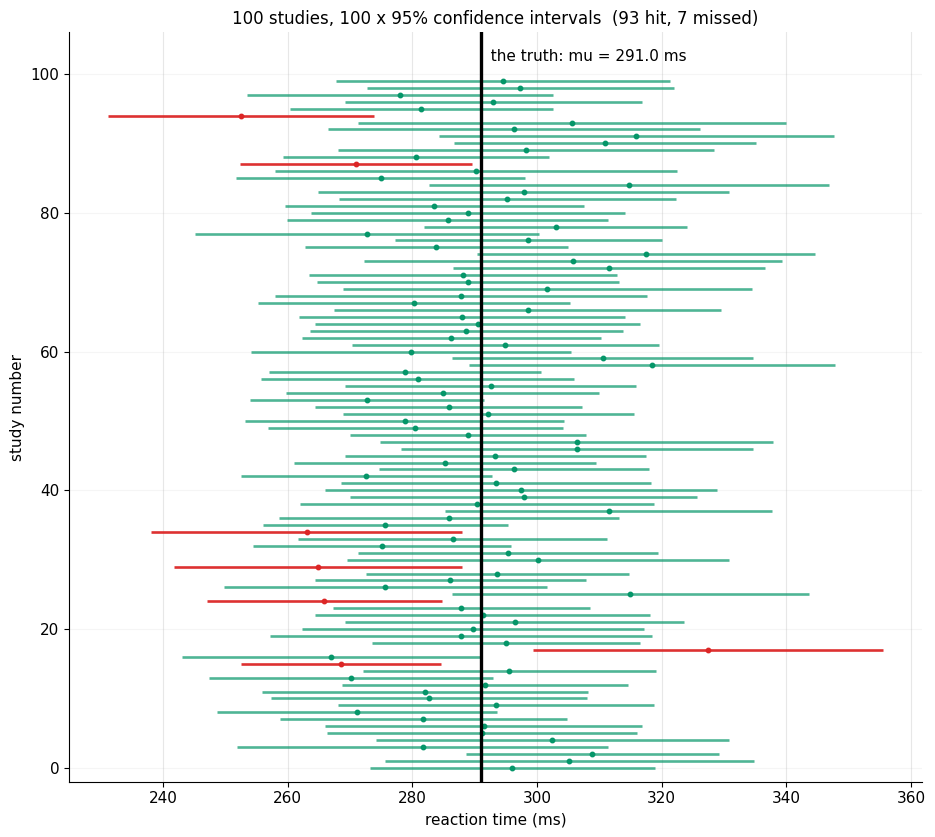

intervals built     : 100
containing the truth: 93
missing the truth   : 7   (red)
coverage            : 93.0%   <- nominal was 95%

Every red interval was built by exactly the same correct procedure as
every green one. Nothing went wrong in those studies -- those samples
just happened to be unusual. Missing sometimes is not a bug in the
method; it is the failure rate the method openly advertises.

With only 100 studies the count is itself noisy: +/- 4.4 points is ordinary variation,
so do not read too much into the exact number. The next cell settles it
with 40,000 studies.


In [30]:
# ============================================================
#  100 studies -> 100 confidence intervals -> count the misses.
# ============================================================
RNG4 = np.random.default_rng(1848)
N_STUDIES = 100

los, his, centres = [], [], []
for _ in range(N_STUDIES):
    s_i    = POP[RNG4.integers(0, POP_N, size=SAMPLE_N)]
    xb     = s_i.mean()
    se_i   = s_i.std(ddof=1) / np.sqrt(SAMPLE_N)
    centres.append(xb)
    los.append(xb - z_crit * se_i)
    his.append(xb + z_crit * se_i)

los, his, centres = np.array(los), np.array(his), np.array(centres)
hits   = (los <= POP_MU) & (POP_MU <= his)
n_miss = int((~hits).sum())

fig, ax = plt.subplots(figsize=(9.5, 8.5))
for i in range(N_STUDIES):
    col = C_AREA if hits[i] else C_SLOPE
    ax.plot([los[i], his[i]], [i, i], color=col, lw=1.9,
            alpha=0.95 if not hits[i] else 0.7, solid_capstyle="butt")
    ax.plot(centres[i], i, "o", color=col, ms=3.2)

ax.axvline(POP_MU, color="black", lw=2.4, zorder=5)
ax.text(POP_MU, N_STUDIES + 1.5, f"  the truth: mu = {POP_MU:.1f} ms",
        fontsize=11, va="bottom", ha="left")
ax.set_ylim(-2, N_STUDIES + 6)
ax.set_xlabel("reaction time (ms)")
ax.set_ylabel("study number")
ax.set_title(f"100 studies, 100 x 95% confidence intervals  "
             f"({N_STUDIES - n_miss} hit, {n_miss} missed)", fontsize=12)
ax.grid(axis="y", alpha=0.12)
fig.tight_layout(); plt.show()

print(f"intervals built     : {N_STUDIES}")
print(f"containing the truth: {N_STUDIES - n_miss}")
print(f"missing the truth   : {n_miss}   (red)")
print(f"coverage            : {100 * hits.mean():.1f}%   <- nominal was {CONF:.0%}")
print()
print("Every red interval was built by exactly the same correct procedure as")
print("every green one. Nothing went wrong in those studies -- those samples")
print("just happened to be unusual. Missing sometimes is not a bug in the")
print("method; it is the failure rate the method openly advertises.")
print()
print(f"With only {N_STUDIES} studies the count is itself noisy: +/- "
      f"{100*2*np.sqrt(0.95*0.05/N_STUDIES):.1f} points is ordinary variation,")
print("so do not read too much into the exact number. The next cell settles it")
print("with 40,000 studies.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One hundred horizontal lines, each one a complete study. Each line is centred on that study's sample mean and reaches out 1.96 standard errors either side. The black vertical line is the true population mean.

**The intervals move; the truth does not.** That is the entire picture. Every line sits at a different place because every study drew different people, but the black line never budges — it is a fixed property of the population, and it was fixed before any study was run.

The red lines are the failures, and the count is printed above. They are not mistakes. They are studies that happened to draw an unusually fast or unusually slow forty people, and the procedure promises in advance that roughly five in a hundred will look like that.

**The common misread:** looking at one red interval and concluding that study did something wrong. It did not — it followed the identical recipe. You cannot tell a red interval from a green one by inspecting it, which is exactly why the guarantee has to be about the procedure rather than about any single interval.

</div>

In [31]:
# ============================================================
#  100 was a demonstration. 40,000 is a measurement.
#  Vectorised: build every interval at once.
# ============================================================
RNG4B = np.random.default_rng(20250905)
TRIALS = 40_000

draws = POP[RNG4B.integers(0, POP_N, size=(TRIALS, SAMPLE_N))]
xb    = draws.mean(axis=1)
se_v  = draws.std(axis=1, ddof=1) / np.sqrt(SAMPLE_N)

lo_v  = xb - z_crit * se_v
hi_v  = xb + z_crit * se_v
cov   = ((lo_v <= POP_MU) & (POP_MU <= hi_v)).mean()

# how precisely do we know the coverage itself? (a standard error, on a coverage)
mc_se = np.sqrt(cov * (1 - cov) / TRIALS)

print(f"trials                  : {TRIALS:,}")
print(f"nominal coverage        : {CONF:.2%}")
print(f"measured coverage       : {cov:.2%}  +/- {2*mc_se:.2%}  (2 Monte-Carlo SEs)")
print(f"shortfall               : {cov - CONF:+.2%}")
print()
print(f"mean interval width     : {(hi_v - lo_v).mean():.3f} ms")
print(f"widest interval built   : {(hi_v - lo_v).max():.3f} ms")
print(f"narrowest interval built: {(hi_v - lo_v).min():.3f} ms")
print()
print("The measured coverage sits close to 95% but slightly under it. That is")
print("not noise -- the gap survives more trials. Section 4.5 finds the cause.")


trials                  : 40,000
nominal coverage        : 95.00%
measured coverage       : 94.01%  +/- 0.24%  (2 Monte-Carlo SEs)
shortfall               : -0.99%

mean interval width     : 50.935 ms
widest interval built   : 93.921 ms
narrowest interval built: 28.131 ms

The measured coverage sits close to 95% but slightly under it. That is
not noise -- the gap survives more trials. Section 4.5 finds the cause.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The 95% was a claim. It has now been counted twice: once at 100 intervals you can see in the figure, and once at 40,000 intervals you cannot.

The two counts agree with each other, and both land close to — but measurably **below** — the nominal 95%. The 40,000-interval figure comes with its own Monte-Carlo margin, and that margin is itself a standard error, computed exactly as in Part 3. Even our check of the method comes with an error bar.

The shortfall is larger than that margin, so it is not noise: raising the trial count shrinks the margin and leaves the gap standing. Hold onto it. It is a real effect with a real cause, and §4.5 both identifies the cause and fixes it.

</div>

## 4.3 What it means, stated carefully

This is the most misstated idea in statistics, so here it is in the two forms
that matter — one correct, one wrong — with the reason the wrong one is wrong.

<div style="background: linear-gradient(135deg, #7f1d1d 0%, #b45309 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### ✅ Correct

**95% of intervals constructed this way contain the true value.**

The 95% is a property of the **procedure**, verified above by running the
procedure 40,000 times and counting. It describes the long-run behaviour of a
recipe, not the status of any one result.

### ❌ Wrong

**"There is a 95% probability that the true mean lies in this interval."**

The true mean is a fixed number. This interval is, once computed, also a fixed
pair of numbers. Either the number is between them or it is not. There is
nothing left to be random about, so there is no probability to assign — it is
already 0 or 1, and you simply do not know which.


</div>

The randomness lives entirely in **which interval you got**, not in where the
truth is. Look again at the figure in §4.2: a hundred different intervals, one
immovable black line. Before you run the study, "will my interval catch it?" is
a genuine 95/5 question about a coin not yet flipped. After you run it, the coin
has landed and is lying under your hand.

The pedantry has a practical payoff. Once you can say *"95% of intervals built
this way contain the truth"* without flinching, you have most of what you need to
avoid misreading a p-value in Part 5, because the error there is the same error
wearing a different hat.

One more precision, easy to miss: the guarantee is about the **procedure you
committed to**. It holds if you fixed $n$ and the confidence level before
looking. Peek at the data, then decide to collect more, or build several
intervals and report the tightest — and the 95% is no longer 95%. Part 8 is
about what that does to real research.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**"There is a 95% chance the true mean is in [438, 471]."**

It is wrong for a specific reason, not merely as a matter of style. Both the true mean and the two endpoints are, at that moment, **fixed numbers**. A statement about fixed numbers is either true or false; it has no probability. Saying "95% chance" treats the population mean as if it were wandering around, when the thing that wanders is your interval.

The tell is the word **this**. "95% of intervals like this one" is fine. "95% probability for *this* interval" is not.

Two honest caveats, because this is a place where over-correction is also a failure mode. First, the sentence you want in practice — "values in here are plausible, values well outside are not" — is a perfectly reasonable reading and is what the interval is *for*. Second, there **is** a framework where the probability statement is legitimate: Bayesian statistics builds a *credible interval*, which does support "95% probability the parameter is in here", at the cost of requiring you to state a prior. The mistake is not wanting that statement — it is claiming a frequentist interval provides it.

</div>

## 4.4 What makes an interval wide

Three things, and only three, move the width:

$$\text{width} = 2 \times z_{\text{crit}} \times \frac{s}{\sqrt{n}}$$

- **Sample size $n$** — more data, narrower. Under a square root, as always.
- **Confidence level** — more certainty demanded, wider. Certainty is bought
  with width, and there is no other currency.
- **Population spread $\sigma$** (estimated by $s$) — messier world, wider. This
  one is not under your control at all.

The third is worth dwelling on: it is the only one you cannot buy your way out
of. If the thing you are measuring is genuinely variable, your interval is wide,
and the only remedies are more data or a less variable measurement.


LEVER 1 -- sample size (95% confidence, our population)
     n |  mean CI width (ms) |  vs n=10
----------------------------------------
    10 |              98.413 |    1.00x
    40 |              51.079 |    0.52x
   160 |              25.668 |    0.26x
   640 |              12.861 |    0.13x

LEVER 2 -- confidence level (n = 40, our population)
  level |   z crit |  mean CI width (ms)
----------------------------------------
    80% |   1.2816 |              33.274
    90% |   1.6449 |              42.857
    95% |   1.9600 |              50.918
    99% |   2.5758 |              66.873

LEVER 3 -- population spread (n = 40, 95% confidence)
            population |   true sd |  mean CI width (ms)
--------------------------------------------------------
                  ours |     83.01 |              50.857
        2x as variable |    166.02 |             101.767


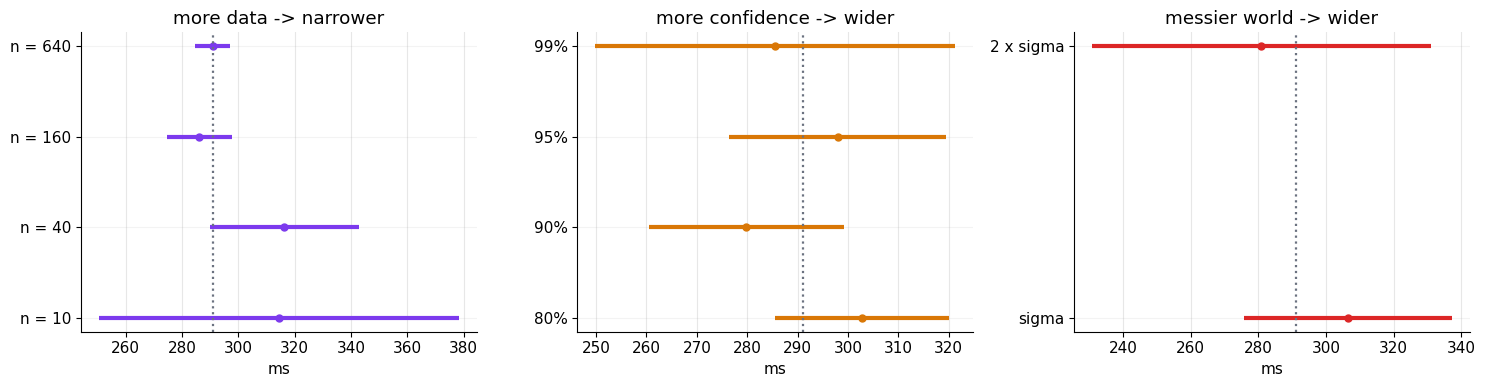

In [32]:
# ============================================================
#  All three levers, each measured on real simulated samples.
# ============================================================
RNG4C = np.random.default_rng(555)

def mean_ci_width(pop, n, conf, reps=4000, rng=RNG4C):
    """Average 95%-style CI width over `reps` studies. Also returns one realised CI."""
    zc = stats.norm.ppf(1 - (1 - conf) / 2)
    d  = pop[rng.integers(0, pop.size, size=(reps, n))]
    w  = 2 * zc * d.std(axis=1, ddof=1) / np.sqrt(n)
    xb0, se0 = d[0].mean(), d[0].std(ddof=1) / np.sqrt(n)
    return w.mean(), (xb0 - zc * se0, xb0 + zc * se0)

# a second population: same centre, twice the spread
POP_WIDE = POP_MU + 2.0 * (POP - POP_MU)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))

# ---- lever 1: sample size
ns = [10, 40, 160, 640]
print("LEVER 1 -- sample size (95% confidence, our population)")
print(f"{'n':>6} | {'mean CI width (ms)':>19} | {'vs n=10':>8}")
print("-" * 40)
w10 = None
for i, n in enumerate(ns):
    w, (a, b) = mean_ci_width(POP, n, 0.95)
    w10 = w if w10 is None else w10
    axes[0].plot([a, b], [i, i], color=C_EXACT, lw=3.0, solid_capstyle="butt")
    axes[0].plot((a + b) / 2, i, "o", color=C_EXACT, ms=5)
    print(f"{n:>6} | {w:>19.3f} | {w/w10:>7.2f}x")
axes[0].set_yticks(range(len(ns))); axes[0].set_yticklabels([f"n = {n}" for n in ns])
axes[0].set_title("more data -> narrower"); axes[0].set_xlabel("ms")

# ---- lever 2: confidence level
confs = [0.80, 0.90, 0.95, 0.99]
print()
print(f"LEVER 2 -- confidence level (n = {SAMPLE_N}, our population)")
print(f"{'level':>7} | {'z crit':>8} | {'mean CI width (ms)':>19}")
print("-" * 40)
for i, c in enumerate(confs):
    w, (a, b) = mean_ci_width(POP, SAMPLE_N, c)
    axes[1].plot([a, b], [i, i], color=C_APPROX, lw=3.0, solid_capstyle="butt")
    axes[1].plot((a + b) / 2, i, "o", color=C_APPROX, ms=5)
    print(f"{c:>7.0%} | {stats.norm.ppf(1-(1-c)/2):>8.4f} | {w:>19.3f}")
axes[1].set_yticks(range(len(confs))); axes[1].set_yticklabels([f"{c:.0%}" for c in confs])
axes[1].set_title("more confidence -> wider"); axes[1].set_xlabel("ms")

# ---- lever 3: population spread
print()
print(f"LEVER 3 -- population spread (n = {SAMPLE_N}, 95% confidence)")
print(f"{'population':>22} | {'true sd':>9} | {'mean CI width (ms)':>19}")
print("-" * 56)
for i, (label, pp) in enumerate([("ours", POP), ("2x as variable", POP_WIDE)]):
    w, (a, b) = mean_ci_width(pp, SAMPLE_N, 0.95)
    axes[2].plot([a, b], [i, i], color=C_SLOPE, lw=3.0, solid_capstyle="butt")
    axes[2].plot((a + b) / 2, i, "o", color=C_SLOPE, ms=5)
    print(f"{label:>22} | {pp.std(ddof=0):>9.2f} | {w:>19.3f}")
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["sigma", "2 x sigma"])
axes[2].set_title("messier world -> wider"); axes[2].set_xlabel("ms")

for ax in axes:
    ax.axvline(POP_MU, color=C_GREY, lw=1.6, ls=":")
    ax.grid(axis="y", alpha=0.15)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three panels, one realised interval drawn per setting, with the average width over 4,000 studies printed beside it. The dotted grey line in each panel is the true mean.

**Left**: quadrupling $n$ halves the width — the $\sqrt{n}$ tax from §3.5 showing up in a different costume. **Middle**: going from 80% to 99% confidence widens the interval in proportion to the critical values, which are printed beside the widths. **Right**: doubling the population's spread doubles the width, since $\sigma$ enters linearly.

**The common misread:** treating a narrow interval as a good result and a wide one as a failed study. Width is a report on how much information you had, not on how well you did. A wide interval honestly drawn is a better scientific object than a narrow one obtained by quietly dropping to 80% confidence — and the middle panel shows how easily that trade is made, and how invisible it is in the final number.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Put an error bar on every model score you report.** A test-set accuracy is a sample mean — the mean of a 0/1 correctness variable over the test set — so everything in this part applies to it directly, and $\sqrt{\hat{p}(1-\hat{p})/n}$ is its standard error.

That single habit changes how model comparisons read. "93.2% vs 92.8%" invites a conclusion; "93.2% ± 1.1% vs 92.8% ± 1.1% on the same 2,000 items" invites the correct one, which is that the test set cannot tell them apart. Leaderboards that omit the interval are not reporting a stronger result, they are reporting an unfinished one.

Two refinements you will need later. When two models are scored on the **same** test set their errors are correlated, so comparing their separate intervals is conservative — a paired comparison (Part 6) is sharper. And when a score comes from $k$-fold cross-validation, the folds share training data and are **not independent**, so the naive $s/\sqrt{k}$ across folds understates the uncertainty. Part 9 handles both.

</div>

## 4.5 The t-distribution: paying for the $\sigma$ you do not have

Back to the shortfall. Measured coverage in §4.2 came in a little under 95%, and
the same gap appeared at 100 intervals and at 40,000. Something systematic is
going on.

Here is what. The derivation in Part 3 gave the standard error as
$\sigma/\sqrt{n}$ — with $\sigma$, the **population** standard deviation. We do
not have $\sigma$. We substituted $s$, computed from the same forty people that
gave us $\bar{x}$.

And $s$ is itself an estimate, with its own sampling variability. Sometimes it
comes out too small, and when it does, the interval is too narrow **and centred
by a mean estimated from that same unusually tight sample**. Those errors do not
cancel; they compound. The extra failures cluster in exactly the studies where
$s$ under-shot.

The fix, worked out by William Gosset in 1908 while doing quality control at
Guinness and published under the pen name "Student", is to widen the interval by
using a distribution with **fatter tails** than the normal. It is called the
**t-distribution**, and its fatness is controlled by the *degrees of freedom*,
$n - 1$. Small $n$, fat tails, wide interval. Large $n$, and it becomes the
normal distribution again.


    n |  df = n-1 |  t multiplier |  z multiplier |  t is wider by
----------------------------------------------------------------------
    5 |         4 |        2.7764 |        1.9600 |         41.66%
   15 |        14 |        2.1448 |        1.9600 |          9.43%
   40 |        39 |        2.0227 |        1.9600 |          3.20%
  100 |        99 |        1.9842 |        1.9600 |          1.24%
 1000 |       999 |        1.9623 |        1.9600 |          0.12%

At n = 5 the correction is large. At n = 1000 it has essentially vanished:
  t(df=999) = 1.9623   vs   z = 1.9600


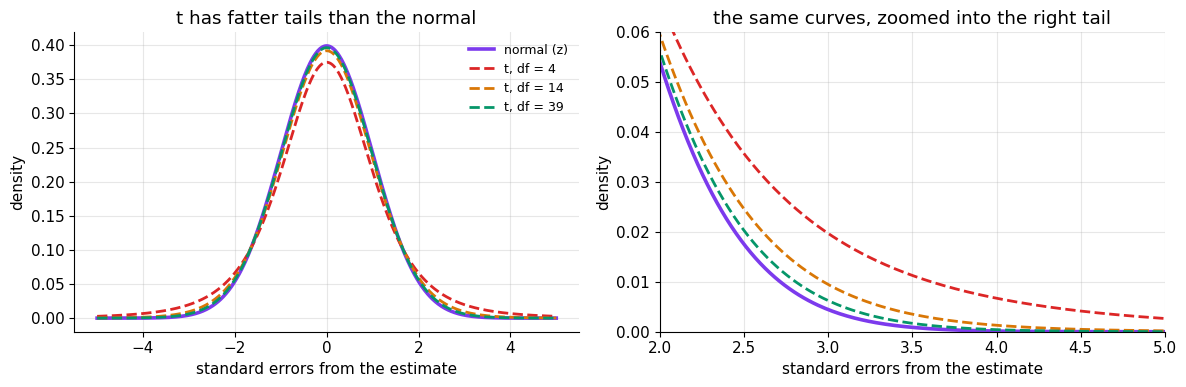

In [33]:
# ============================================================
#  How much fatter? Compare the multipliers.
# ============================================================
print(f"{'n':>5} | {'df = n-1':>9} | {'t multiplier':>13} | {'z multiplier':>13} | {'t is wider by':>14}")
print("-" * 70)
for n in [5, 15, 40, 100, 1000]:
    t_c = stats.t.ppf(0.975, df=n - 1)
    print(f"{n:>5} | {n-1:>9} | {t_c:>13.4f} | {z_crit:>13.4f} | "
          f"{100*(t_c/z_crit - 1):>13.2f}%")

print()
print("At n = 5 the correction is large. At n = 1000 it has essentially vanished:")
print(f"  t(df=999) = {stats.t.ppf(0.975, df=999):.4f}   vs   z = {z_crit:.4f}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.0))

g = np.linspace(-5, 5, 700)
axL.plot(g, stats.norm.pdf(g), color=C_EXACT, lw=2.6, label="normal (z)")
for df, c in [(4, C_SLOPE), (14, C_APPROX), (39, C_AREA)]:
    axL.plot(g, stats.t.pdf(g, df), lw=2.0, color=c, ls="--", label=f"t, df = {df}")
axL.set_title("t has fatter tails than the normal")
axL.set_xlabel("standard errors from the estimate"); axL.set_ylabel("density")
axL.legend(frameon=False, fontsize=9)

axR.plot(g, stats.norm.pdf(g), color=C_EXACT, lw=2.6)
for df, c in [(4, C_SLOPE), (14, C_APPROX), (39, C_AREA)]:
    axR.plot(g, stats.t.pdf(g, df), lw=2.0, color=c, ls="--")
axR.set_xlim(2.0, 5.0); axR.set_ylim(0, 0.06)
axR.set_title("the same curves, zoomed into the right tail")
axR.set_xlabel("standard errors from the estimate"); axR.set_ylabel("density")

fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the standard normal and three t-densities. At this zoom they look almost identical, which is why the correction is so easy to skip — the difference is not in the middle of the distribution.

Right: the same curves zoomed into the tail, where the difference lives. The t-densities sit visibly above the normal out at 3 and 4 standard errors, and the lower the degrees of freedom the higher they sit. More probability out in the tails means you must reach further out to enclose 95% of the area — which is exactly the larger multiplier in the table.

**The common misread:** "t is for small samples, z is for large ones." The real dividing line is whether $\sigma$ is **known**. If you estimated the spread from your data, t is the correct choice at *every* sample size; it simply stops mattering as $n$ grows, because the table shows the two multipliers converging. Using t always is never wrong. Using z when you estimated $s$ is always slightly wrong, and at small $n$ badly so.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**"You used an estimate of the spread, so widen the interval to pay for not knowing it."**

The multiplier changes from $1.96$ to $t_{n-1,\,0.975}$, and that is the only change — same centre, same standard error, wider reach.

The $n-1$ is the same $n-1$ that appears in the sample standard deviation ($\texttt{ddof=1}$), and for the same reason: once you have used the data to compute $\bar{x}$, only $n-1$ of the deviations from it are free to vary. You spent one piece of information on locating the centre, and the degrees of freedom is the bookkeeping.

</div>

In [34]:
# ============================================================
#  Does it actually fix the coverage? Simulate and count.
#  Three procedures at three sample sizes, 40,000 studies each.
# ============================================================
RNG4D = np.random.default_rng(1908)          # Gosset's year
TR = 40_000

print(f"Measured coverage of nominal-95% intervals, {TR:,} studies each")
print()
print(f"{'n':>5} | {'z with true sigma':>18} | {'z with s (wrong)':>17} | {'t with s (right)':>17}")
print("-" * 66)

cov_table = {}
for n in [5, 15, 40, 100]:
    d  = POP[RNG4D.integers(0, POP_N, size=(TR, n))]
    xb_ = d.mean(axis=1)
    s_  = d.std(axis=1, ddof=1)

    # (a) the idealised interval nobody can build: uses the TRUE sigma
    h_true = z_crit * POP_SD / np.sqrt(n)
    c_true = ((xb_ - h_true <= POP_MU) & (POP_MU <= xb_ + h_true)).mean()

    # (b) what people actually do wrong: z multiplier with the estimated s
    h_z = z_crit * s_ / np.sqrt(n)
    c_z = ((xb_ - h_z <= POP_MU) & (POP_MU <= xb_ + h_z)).mean()

    # (c) the correct small-sample interval: t multiplier with the estimated s
    t_c = stats.t.ppf(0.975, df=n - 1)
    h_t = t_c * s_ / np.sqrt(n)
    c_t = ((xb_ - h_t <= POP_MU) & (POP_MU <= xb_ + h_t)).mean()

    cov_table[n] = (c_true, c_z, c_t)
    print(f"{n:>5} | {c_true:>17.2%} | {c_z:>16.2%} | {c_t:>16.2%}")

print()
print("Read the middle column downward: using z with an estimated s UNDER-COVERS,")
print("badly at n = 5 and less so as n grows. The right-hand column fixes most of it.")
print()
print(f"at n = 5 : z gives {cov_table[5][1]:.2%}, t gives {cov_table[5][2]:.2%} "
      f"-- a gap of {100*(cov_table[5][2] - cov_table[5][1]):.2f} points")
print(f"at n = 40: z gives {cov_table[40][1]:.2%}, t gives {cov_table[40][2]:.2%} "
      f"-- a gap of {100*(cov_table[40][2] - cov_table[40][1]):.2f} points")
print()
print("Note the t column at n = 5 is still not 95%. t assumes the POPULATION is")
print("normal, and ours is skewed. At n = 5 the CLT (section 3.3) has barely started.")
print("Two separate approximations, two separate shortfalls.")


Measured coverage of nominal-95% intervals, 40,000 studies each

    n |  z with true sigma |  z with s (wrong) |  t with s (right)
------------------------------------------------------------------
    5 |            95.08% |           86.60% |           94.01%
   15 |            95.10% |           92.34% |           94.44%
   40 |            94.91% |           93.79% |           94.58%
  100 |            94.95% |           94.49% |           94.84%

Read the middle column downward: using z with an estimated s UNDER-COVERS,
badly at n = 5 and less so as n grows. The right-hand column fixes most of it.

at n = 5 : z gives 86.60%, t gives 94.01% -- a gap of 7.41 points
at n = 40: z gives 93.79%, t gives 94.58% -- a gap of 0.79 points

Note the t column at n = 5 is still not 95%. t assumes the POPULATION is
normal, and ours is skewed. At n = 5 the CLT (section 3.3) has barely started.
Two separate approximations, two separate shortfalls.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The shortfall spotted in §4.2 has been traced to its cause and the fix has been measured, not argued.

Column one is the interval you could build if you somehow knew $\sigma$; it brackets 95% properly at every $n$, confirming the machinery itself is sound. Column two swaps in $s$ and nothing else — and coverage falls, most dramatically at $n = 5$. Column three swaps the multiplier to t and recovers most of the loss.

And the check is honest about what it does **not** fix: at $n = 5$ the t-interval still under-covers, because t assumes a normal population and ours is skewed. Two approximations were stacked; t repairs one of them. The one it does not repair is what the bootstrap is for.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Using z (the 1.96) when you estimated $s$ from a small sample.**

The table above prices it: at $n = 5$ your "95% interval" is really delivering the coverage printed in the middle column. You are reporting a confidence you do not have, and — the dangerous part — the error always runs in the flattering direction. Intervals come out too narrow, results look more precise than they are, and nothing in the output looks wrong.

**The rule, which has no exceptions worth remembering:** if you estimated the spread from your data, use t. It costs one character of code (`stats.t.ppf(0.975, df=n-1)` instead of `stats.norm.ppf(0.975)`) and at large $n$ it silently becomes z anyway, so there is no scenario in which reaching for z first is the better habit.

**The second trap, which t does not solve:** t assumes the population is normal. At $n = 5$ from a skewed population, the last column above still misses. When $n$ is small *and* the data are skewed, no multiplier fixes it — you need a method that does not assume a shape at all.

</div>

## 4.6 The bootstrap: an interval with no formula in it

Everything so far has depended on knowing the shape of the sampling
distribution — normal, or t. That knowledge came from the CLT, and Part 3 showed
the CLT can be slow to arrive.

And there is a bigger problem waiting. The CLT is a theorem about **means**. Ask
for a confidence interval on a **median**, a 90th percentile, a correlation, an
AUC, or the ratio of two things, and the neat formula is gone — for some of
those a closed form exists and is horrible, and for others there is none.

The **bootstrap** sidesteps all of it with one idea that sounds like cheating:

> The sampling distribution comes from drawing repeatedly from the population.
> We cannot do that — we have one sample. But our sample is the best picture of
> the population we own. So draw repeatedly **from the sample**, with
> replacement, and use *that* spread instead.

Each resample is the same size as the original and takes some observations
twice, others not at all — which is precisely what mimics the luck of the draw.
Compute your statistic on each resample, and the spread of those numbers
estimates the spread of the real sampling distribution. Then just take
percentiles.

No normality assumption. No formula. It works on any statistic you can compute.


In [35]:
# ============================================================
#  The bootstrap, implemented directly. Nine lines of actual work.
# ============================================================
RNG_B = np.random.default_rng(1979)          # Efron's paper
B = 20_000


def bootstrap_ci(data, statistic=np.mean, B=B, conf=0.95, rng=RNG_B):
    """Percentile bootstrap CI for any statistic. No distributional assumption."""
    n    = len(data)
    idx  = rng.integers(0, n, size=(B, n))       # resample WITH replacement
    reps = statistic(data[idx], axis=1)          # the statistic, B times over
    a    = (1 - conf) / 2
    return np.quantile(reps, [a, 1 - a]), reps


(b_lo, b_hi), boot_means = bootstrap_ci(sample)

# what one resample looks like, to demystify it
one_idx = RNG_B.integers(0, SAMPLE_N, size=SAMPLE_N)
print(f"original sample (first 8, sorted): {np.round(np.sort(sample)[:8], 1)}")
print(f"one resample    (first 8, sorted): {np.round(np.sort(sample[one_idx])[:8], 1)}")
print(f"  of the {SAMPLE_N} original observations, "
      f"{len(np.unique(one_idx))} appear in this resample and "
      f"{SAMPLE_N - len(np.unique(one_idx))} are left out.")
print(f"  (about 1/e = {1/np.e:.1%} get left out every time -- that is the mechanism)")
print()

t_crit40 = stats.t.ppf(0.975, df=SAMPLE_N - 1)
t_lo, t_hi = x_bar - t_crit40 * se, x_bar + t_crit40 * se

print(f"{'method':>26} | {'interval (ms)':>26} | {'width':>7} | {'contains mu?':>12}")
print("-" * 82)
for name, (a, b) in [("z formula (1.96)", (lo, hi)),
                     ("t formula (correct)", (t_lo, t_hi)),
                     (f"bootstrap ({B:,} resamples)", (b_lo, b_hi))]:
    print(f"{name:>26} | [{a:>10.3f}, {b:>10.3f}] | {b-a:>7.3f} | "
          f"{'YES' if a <= POP_MU <= b else 'NO':>12}")
print()
print(f"true mu = {POP_MU:.3f} ms")
print()
print("Three routes, three near-identical answers -- and the bootstrap got there")
print("without ever using sigma, the CLT, or a table of critical values.")


original sample (first 8, sorted): [167.  181.2 183.8 193.7 194.2 194.9 199.8 203.7]
one resample    (first 8, sorted): [167.  183.8 183.8 193.7 194.2 199.8 203.7 223.3]
  of the 40 original observations, 25 appear in this resample and 15 are left out.
  (about 1/e = 36.8% get left out every time -- that is the mechanism)

                    method |              interval (ms) |   width | contains mu?
----------------------------------------------------------------------------------
          z formula (1.96) | [   257.805,    303.894] |  46.089 |          YES
       t formula (correct) | [   257.068,    304.632] |  47.564 |          YES
bootstrap (20,000 resamples) | [   258.731,    304.520] |  45.788 |          YES

true mu = 290.989 ms

Three routes, three near-identical answers -- and the bootstrap got there
without ever using sigma, the CLT, or a table of critical values.


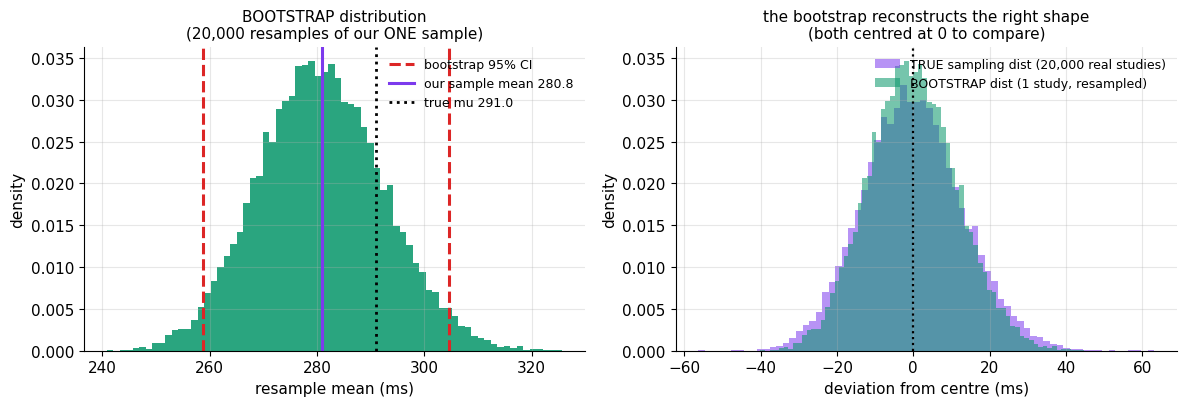

sd of the TRUE sampling distribution (20,000 real studies)   :  13.1259 ms
   which the formula predicts as sigma/sqrt(n)               :  13.1253 ms

sd of the BOOTSTRAP distribution (20,000 resamples of ONE study):  11.6423 ms
   which our own sample's s/sqrt(n) predicts                 :  11.7576 ms

the bootstrap is -11.3% off the TRUE sampling-distribution width.

Read that carefully. The bootstrap agrees almost exactly with s/sqrt(n),
because both are built from the same 40 numbers. It sits below the true
width because this particular sample's s = 74.36 undershot the true
sigma = 83.01. That is not a flaw in the bootstrap: the t-interval
has the same problem for the same reason, which is section 4.5.

The bootstrap reconstructed the SHAPE and the SCALE of a distribution it
never saw, from 40 numbers, and is wrong only where those 40 numbers were.


In [36]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2))

# left: the bootstrap distribution, with the interval marked
axL.hist(boot_means, bins=70, color=C_AREA, alpha=0.85, density=True)
axL.axvline(b_lo, color=C_SLOPE, lw=2.2, ls="--")
axL.axvline(b_hi, color=C_SLOPE, lw=2.2, ls="--", label="bootstrap 95% CI")
axL.axvline(x_bar, color=C_EXACT, lw=2.2, label=f"our sample mean {x_bar:.1f}")
axL.axvline(POP_MU, color="black", lw=2.0, ls=":", label=f"true mu {POP_MU:.1f}")
axL.set_title(f"BOOTSTRAP distribution\n({B:,} resamples of our ONE sample)", fontsize=11)
axL.set_xlabel("resample mean (ms)"); axL.set_ylabel("density")
axL.legend(frameon=False, fontsize=9)

# right: the real sampling distribution from Part 3, recentred for comparison
axR.hist(means40 - POP_MU, bins=70, color=C_EXACT, alpha=0.55, density=True,
         label="TRUE sampling dist (20,000 real studies)")
axR.hist(boot_means - x_bar, bins=70, color=C_AREA, alpha=0.55, density=True,
         label="BOOTSTRAP dist (1 study, resampled)")
axR.axvline(0, color="black", lw=1.6, ls=":")
axR.set_title("the bootstrap reconstructs the right shape\n(both centred at 0 to compare)",
              fontsize=11)
axR.set_xlabel("deviation from centre (ms)"); axR.set_ylabel("density")
axR.legend(frameon=False, fontsize=9)

fig.tight_layout(); plt.show()

print(f"sd of the TRUE sampling distribution (20,000 real studies)   : {means40.std(ddof=0):8.4f} ms")
print(f"   which the formula predicts as sigma/sqrt(n)               : {POP_SD/np.sqrt(SAMPLE_N):8.4f} ms")
print()
print(f"sd of the BOOTSTRAP distribution ({B:,} resamples of ONE study): {boot_means.std(ddof=0):8.4f} ms")
print(f"   which our own sample's s/sqrt(n) predicts                 : {se:8.4f} ms")
print()
print(f"the bootstrap is {100*(boot_means.std(ddof=0)/means40.std(ddof=0) - 1):+.1f}% off the TRUE sampling-distribution width.")
print()
print("Read that carefully. The bootstrap agrees almost exactly with s/sqrt(n),")
print("because both are built from the same 40 numbers. It sits below the true")
print(f"width because this particular sample's s = {s:.2f} undershot the true")
print(f"sigma = {POP_SD:.2f}. That is not a flaw in the bootstrap: the t-interval")
print("has the same problem for the same reason, which is section 4.5.")
print()
print("The bootstrap reconstructed the SHAPE and the SCALE of a distribution it")
print("never saw, from 40 numbers, and is wrong only where those 40 numbers were.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the bootstrap distribution — 20,000 means, every one computed from a reshuffled copy of the **same forty people**. No new data was collected. The dashed red lines are its 2.5th and 97.5th percentiles, and that is the entire interval construction.

Right is the striking part. The purple histogram is the true sampling distribution from §3.1, built from 20,000 genuine studies and 800,000 measurements. The green is the bootstrap, built from forty. Recentred on each other, they have essentially the same shape.

They do not have quite the same width, and the printout says by how much and why: the bootstrap matches our sample's $s/\sqrt{n}$ almost exactly, and this particular sample's $s$ happened to come in below the true $\sigma$. The bootstrap inherits that, and so does the t-interval — it is the §4.5 problem again, not a separate defect of resampling.

**The common misread:** "resampling my data gives me more data." It emphatically does not. The bootstrap cannot recover information the sample never had — if your forty people happened to be unusual, every resample inherits that and the bootstrap interval sits in the wrong place with total confidence. What it estimates is the **variability** of your statistic, not the location of the truth. Note the green histogram had to be recentred on the sample mean before it could be compared at all: its centre carries no information.

</div>

In [37]:
# ============================================================
#  Bootstrap intervals are only trustworthy if they COVER.
#  Same test as section 4.2: build many, count the hits.
# ============================================================
RNG_BC = np.random.default_rng(4242)
TRIALS_B, B_INNER = 1_500, 600

hits_boot, hits_t = 0, 0
widths_boot, widths_t = [], []
t_c40 = stats.t.ppf(0.975, df=SAMPLE_N - 1)

for _ in range(TRIALS_B):
    s_i  = POP[RNG_BC.integers(0, POP_N, size=SAMPLE_N)]

    idx  = RNG_BC.integers(0, SAMPLE_N, size=(B_INNER, SAMPLE_N))
    reps = s_i[idx].mean(axis=1)
    blo, bhi = np.quantile(reps, [0.025, 0.975])
    hits_boot += (blo <= POP_MU <= bhi)
    widths_boot.append(bhi - blo)

    h = t_c40 * s_i.std(ddof=1) / np.sqrt(SAMPLE_N)
    tlo, thi = s_i.mean() - h, s_i.mean() + h
    hits_t += (tlo <= POP_MU <= thi)
    widths_t.append(thi - tlo)

cb, ct = hits_boot / TRIALS_B, hits_t / TRIALS_B
mc = lambda p: 2 * np.sqrt(p * (1 - p) / TRIALS_B)

print(f"{TRIALS_B:,} studies of n = {SAMPLE_N}, {B_INNER} resamples inside each")
print()
print(f"{'method':>22} | {'coverage':>10} | {'+/- 2 MC SE':>12} | {'mean width (ms)':>16}")
print("-" * 68)
print(f"{'t formula':>22} | {ct:>10.2%} | {mc(ct):>11.2%} | {np.mean(widths_t):>16.3f}")
print(f"{'percentile bootstrap':>22} | {cb:>10.2%} | {mc(cb):>11.2%} | {np.mean(widths_boot):>16.3f}")
print(f"{'nominal':>22} | {0.95:>10.2%} |")
print()
print("Both land near 95%. The bootstrap is very slightly narrower and so covers")
print("very slightly less -- a known small-sample bias of the plain percentile")
print("method, fixable with the BCa variant (scipy.stats.bootstrap does it).")
print()
print("The point stands: the bootstrap assumed NOTHING about the population's")
print("shape and delivered essentially the same interval as the formula that did.")


1,500 studies of n = 40, 600 resamples inside each

                method |   coverage |  +/- 2 MC SE |  mean width (ms)
--------------------------------------------------------------------
             t formula |     95.27% |       1.10% |           52.714
  percentile bootstrap |     94.00% |       1.23% |           49.957
               nominal |     95.00% |

Both land near 95%. The bootstrap is very slightly narrower and so covers
very slightly less -- a known small-sample bias of the plain percentile
method, fixable with the BCa variant (scipy.stats.bootstrap does it).

The point stands: the bootstrap assumed NOTHING about the population's
shape and delivered essentially the same interval as the formula that did.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

A method that produces intervals is only worth anything if those intervals cover, so the bootstrap was put through the identical test as the formula in §4.2: build 1,500 of them, count the hits against the known $\mu$.

It covers, at close to the nominal level, alongside the t-interval as a control run in the same loop on the same studies. And the honest detail is printed too — the plain percentile bootstrap runs a touch narrow at this sample size, which is a documented bias, not noise, and which the bias-corrected-and-accelerated (BCa) variant in `scipy.stats.bootstrap` corrects.

What makes this worth the compute is what was *not* assumed. No normal population, no CLT, no $\sigma$, no critical value. Forty numbers and a resampler.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**The bootstrap is how you get an error bar on a metric that has no formula.**

Accuracy is a mean, so it has a tidy standard error. Almost nothing else does. AUC, F1, precision at k, mean average precision, BLEU, the correlation between predicted and actual, the ratio of two error rates, the median latency at the 99th percentile — none of these is a sample mean, and several have no usable closed-form interval at all.

The recipe is the same every time: resample the **test set** with replacement, recompute the metric on each resample, take the 2.5th and 97.5th percentiles. `scipy.stats.bootstrap` will do it, with BCa correction. Ten lines, and your F1 stops being a bare number.

Three cautions that matter in practice. **Resample the evaluation units, not the rows** — if a test set has ten sentences per document, resample documents, or your interval will be far too narrow for the reason §3.6 gave about independence. **Do not resample the training set** to get an interval on a trained model's score; that measures something else. And **stratify** when a class is rare, or some resamples will contain none of it and the metric will be undefined.

</div>

---

## What Part 4 established

- A confidence interval is $\bar{x} \pm (\text{critical value}) \times
  \text{SE}$, and the 1.96 was **computed**, not quoted.
- Its meaning is a property of the **procedure**: 95% of intervals built this
  way contain the truth. We built a hundred, coloured the misses, counted them,
  then repeated the count at 40,000.
- It does **not** say "95% probability the truth is in this interval". The truth
  is fixed; the interval is what moves.
- Three levers on the width: sample size, confidence level, population spread —
  each one measured.
- Using $s$ in place of $\sigma$ costs real coverage, and the **t-distribution**
  buys it back. We measured the shortfall and measured the repair.
- The **bootstrap** builds an interval by resampling the sample. It assumes
  nothing about the population's shape, its coverage was verified the same way
  as the formula's, and it is the only option for the many statistics with no
  closed form.

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧰 What to actually reach for

**Mean, and $n$ is not tiny** → the t-interval. Always t, never z, whenever
$s$ was estimated from the data.

**Anything that is not a mean** — median, AUC, F1, a ratio, a percentile →
**bootstrap**.

**Small $n$ and skewed data** → bootstrap, and widen your scepticism: §4.5
showed both approximations struggling at $n = 5$, and no method conjures
information that forty — let alone five — observations do not contain.

**Reporting anything at all** → report the interval next to the number. A point
estimate on its own is an unfinished result.

</div>

## Where this goes next

You can now say "the true mean is plausibly between here and here" and defend
every word of it.

Part 5 asks a sharper question. Not "what range is plausible?" but **"is this
particular value plausible at all?"** — is a treatment's effect distinguishable
from zero, is this model actually better than that one. That is hypothesis
testing, and it produces the most famous and most abused number in statistics:
the p-value.

The good news: you have already done the hard part. A hypothesis test and a
confidence interval are two views of the same calculation, and the classic
misreading of a p-value is the same error as the one this part just spent a
section dismantling — a statement about a **procedure** being read as a
statement about a **result**.

---


---

# 5️⃣ Hypothesis testing, and what a p-value is not

Part 4 gave you a range. This part answers a different question, one people ask
constantly and almost always describe wrongly:

> **"Could this have happened by chance?"**

By the end of it you will be able to state precisely what a p-value is, and —
harder, and more useful — what it is not. We will not get there by memorising a
definition. We will get there by **building a p-value from scratch with a
simulation**, so that when the formula finally appears you already know what
number it is trying to produce.

And because our population is simulated, we get something a real analyst never
gets: we can **grade the test**. We know the true mean. So we can ask whether
the test reached the right conclusion, and how often it reaches the wrong one.


<div style="background: linear-gradient(135deg, #42275a 0%, #734b6d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### The logic, in ordinary words

You have a suspicion. Instead of trying to prove it, you assume the **opposite** —
that nothing is going on, that the effect is zero, that the coin is fair.

Then you ask: **if that boring assumption were true, how weird would my data be?**

If the answer is "not weird at all", you have learned nothing and you say so.
If the answer is "absurdly weird — data like mine would almost never turn up in
a world where nothing is going on", you stop believing the boring assumption.

That is **proof by contradiction with the contradiction softened into a
probability**. In real proof by contradiction the assumption leads to something
*impossible*, and you may then reject it outright. Here it leads only to
something *improbable*, so you may only reject it *tentatively*.

**This is exactly why every conclusion in statistics is hedged.** The hedging is
not academic timidity. It is the honest shape of the argument.


</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧭 The four steps, every single time


1. **State the boring assumption** (the *null hypothesis*, $H_0$) — precisely enough that you could simulate a world where it holds.
2. **Choose a statistic** — one number computed from your data that would look different if the boring assumption were false.
3. **Work out how that statistic behaves in the boring world.** By simulation, or by a formula that stands in for one.
4. **Compare.** How far into the tail does your actual data sit? That tail probability is the **p-value**.

Step 3 is where the whole subject lives, and it is the step textbooks usually hide behind a printed table. We are going to do it by brute force first.

</div>

## 5.1 A concrete question

Suppose a widely cited paper reports that mean simple reaction time in this kind
of task is **270 ms**. You are sceptical — your impression is that people are
slower than that. You cannot test 200,000 people, so you test 100.

Written formally, with $\mu$ the (unknown, to you) population mean:

| | Statement | In words |
|---|---|---|
| **$H_0$** — the null hypothesis | $\mu = 270$ | The published figure is right. Nothing to report. |
| **$H_1$** — the alternative | $\mu \neq 270$ | The published figure is wrong, in either direction. |

Three things about this pair are easy to get wrong:

- **$H_0$ is the specific one.** It names a number. That is what makes it
  simulatable — you can build a world where $\mu$ is exactly 270 and see what
  samples from it look like. $H_1$ names no number, so you cannot simulate it,
  which is why the whole machinery is lopsided: you can reject $H_0$, but you can
  never "accept" it.
- **$H_1$ is two-sided here** ("different from 270", not "bigger than 270"). You
  choose that *before* seeing the data. Choosing it afterwards, once you know
  which way your sample leans, is a way of cheating that Part 8 has a name for.
- **We are about to test a null that is false.** We built this population; we
  know its mean is not 270. So the *correct* conclusion is to reject $H_0$, and
  we will be able to check whether the test manages it.


In [38]:
# ============================================================
#  5.1  The claim, and the sample we will judge it with.
# ============================================================
from scipy import stats

CLAIM  = 270.0        # H0: the population mean is exactly this
N_TEST = 100          # how many people we measure

# A dedicated generator, so this sample never changes no matter what
# earlier parts happened to draw from RNG.
rng_obs = np.random.default_rng(505)
obs = rng_obs.choice(POP, N_TEST, replace=False)

obs_mean = obs.mean()
obs_gap  = abs(obs_mean - CLAIM)      # our statistic: distance from the claim

print(f"H0 says the population mean is   {CLAIM:8.1f} ms")
print(f"our {N_TEST} people averaged        {obs_mean:8.2f} ms")
print(f"so our sample sits               {obs_gap:8.2f} ms away from the claim")
print()
print("Is that a lot? On its own the number means nothing at all. It only")
print("means something next to the spread of gaps you would SEE in a world")
print("where H0 is true. So let us go and build that world.")
print()
print(f"(peeking, which you could never do in real life: the truth is "
      f"{POP_MU:.2f} ms,")
print(f" so H0 is FALSE, and wrong by {POP_MU - CLAIM:.2f} ms)")


H0 says the population mean is      270.0 ms
our 100 people averaged          288.12 ms
so our sample sits                  18.12 ms away from the claim

Is that a lot? On its own the number means nothing at all. It only
means something next to the spread of gaps you would SEE in a world
where H0 is true. So let us go and build that world.

(peeking, which you could never do in real life: the truth is 290.99 ms,
 so H0 is FALSE, and wrong by 20.99 ms)


## 5.2 Building the null world

Here is the move that makes p-values click. We do not look anything up. We
**construct a population in which $H_0$ is literally true** and then run our
study inside it, thousands of times.

How do you build such a population? Take the real one and slide it sideways
until its mean is exactly 270. The shape — the skew, the long tail, everything —
is untouched; only the location moves:

$$\text{POP}_{H_0} \;=\; \text{POP} - \mu + 270$$

Now draw 20,000 samples of 100 from it. Each one is a study that *could* have
happened in a world where the paper was right. Each gives a sample mean. Those
20,000 means are the **null distribution of the statistic** — step 3 of the four
steps, done by brute force.

And then the p-value is not a formula at all. It is a count:

> **Of the studies run in the boring world, what fraction landed at least as far
> from 270 as ours did?**


In [39]:
# ============================================================
#  5.2  The p-value, by simulation. No formula, no table.
# ============================================================
rng5 = np.random.default_rng(5050)

POP_H0 = POP - POP_MU + CLAIM         # same shape, mean slid to exactly the claim
print(f"null population mean = {POP_H0.mean():.6f} ms   (exactly the claim)")
print(f"null population sd   = {POP_H0.std(ddof=0):.3f} ms   (unchanged)")
print()

N_NULL_STUDIES = 20_000
idx        = rng5.integers(0, len(POP_H0), size=(N_NULL_STUDIES, N_TEST))
null_means = POP_H0[idx].mean(axis=1)       # 20,000 studies in the boring world

null_gaps  = np.abs(null_means - CLAIM)
as_extreme = null_gaps >= obs_gap
p_sim      = as_extreme.mean()

print(f"ran {N_NULL_STUDIES:,} studies in a world where H0 is TRUE")
print(f"  their sample means ranged {null_means.min():.1f} .. {null_means.max():.1f} ms")
print(f"  {as_extreme.sum():,} of them landed at least {obs_gap:.2f} ms "
      f"from {CLAIM:.0f}")
print()
print(f"  p (simulated) = {as_extreme.sum():,} / {N_NULL_STUDIES:,} = {p_sim:.4f}")
print()
print("That is a p-value. Nothing was assumed about bell curves; we simply")
print("counted how often the boring world produces data as odd as ours.")


null population mean = 270.000000 ms   (exactly the claim)
null population sd   = 83.012 ms   (unchanged)

ran 20,000 studies in a world where H0 is TRUE
  their sample means ranged 239.5 .. 305.0 ms
  584 of them landed at least 18.12 ms from 270

  p (simulated) = 584 / 20,000 = 0.0292

That is a p-value. Nothing was assumed about bell curves; we simply
counted how often the boring world produces data as odd as ours.


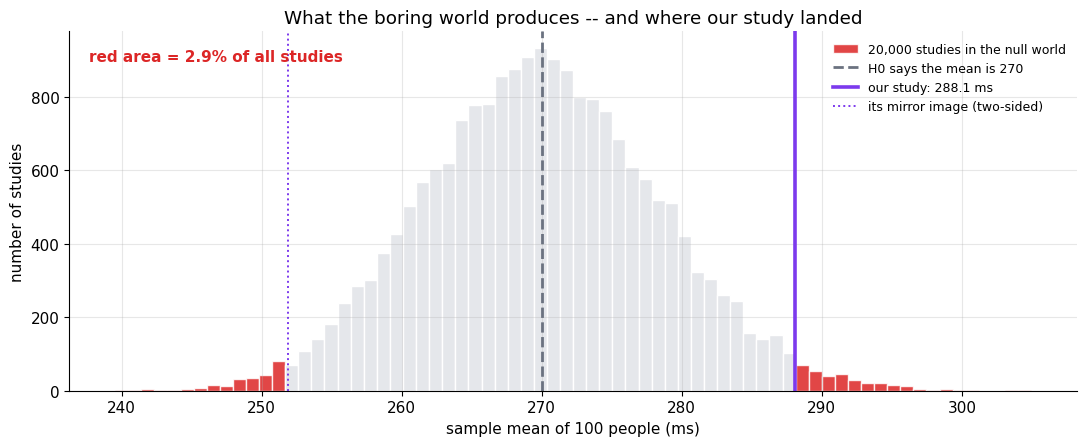

p = 0.0292  =  the red fraction of the grey histogram


In [40]:
fig, ax = plt.subplots(figsize=(11, 4.6))

counts, bins, patches = ax.hist(null_means, bins=70, color=C_SOFT,
                                edgecolor="white",
                                label="20,000 studies in the null world")
half = (bins[1] - bins[0]) / 2
for pat, left in zip(patches, bins[:-1]):          # shade the extreme tails
    if abs(left + half - CLAIM) >= obs_gap:
        pat.set_facecolor(C_SLOPE); pat.set_alpha(0.85)

ax.axvline(CLAIM, color=C_GREY, lw=2.0, ls="--",
           label=f"H0 says the mean is {CLAIM:.0f}")
ax.axvline(obs_mean, color=C_EXACT, lw=2.6, label=f"our study: {obs_mean:.1f} ms")
ax.axvline(2 * CLAIM - obs_mean, color=C_EXACT, lw=1.4, ls=":",
           label="its mirror image (two-sided)")

ax.set_title("What the boring world produces -- and where our study landed")
ax.set_xlabel("sample mean of 100 people (ms)")
ax.set_ylabel("number of studies")
ax.legend(frameon=False, fontsize=9)
ax.text(0.02, 0.95, f"red area = {p_sim:.1%} of all studies",
        transform=ax.transAxes, va="top", fontsize=11,
        color=C_SLOPE, weight="bold")
fig.tight_layout(); plt.show()

print(f"p = {p_sim:.4f}  =  the red fraction of the grey histogram")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The grey histogram is **not** our data. It is 20,000 imaginary studies run in a world where the published claim is exactly right. It is centred on 270 because that is what we built, and its width is the standard error from Part 3 — how much a mean of 100 people wobbles.

The purple line is our actual study. Red bars are every imaginary study that landed at least as far from 270 as ours did — on **either** side, which is what makes this test two-sided. The red fraction is the p-value, printed under the plot.

**The common misread:** reading the red area as "the probability that $H_0$ is true". It is nothing of the kind. Every single study in that histogram came from a world where $H_0$ *is* true — the entire picture is drawn under that assumption. The red area answers "how often does a true null produce data like mine?", which is a completely different question from "how likely is my null to be true?". Section 5.4 measures how far apart those two numbers can get.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

The p-value is the answer to one sentence:

> **If the boring assumption were true, how often would I see data at least as extreme as what I actually saw?**

Small p means: *data like mine is rare in the boring world.* That is evidence against the boring world — because the data did happen, and one of the two has to give.

Large p means: *data like mine is unremarkable in the boring world.* That is **not** evidence that the boring world is correct. It is the absence of evidence either way, which is a different and far weaker thing.

</div>

In [41]:
# ============================================================
#  5.3  The same p-value from a formula -- do they agree?
#
#  The one-sample t-test replaces our 20,000 simulated studies with an
#  algebraic stand-in for the same histogram: the t distribution.
#
#      t = (x-bar - claim) / (s / sqrt(n))
#
#  i.e. "how many standard errors is my sample mean from the claim?"
# ============================================================
t_hand       = (obs_mean - CLAIM) / (obs.std(ddof=1) / np.sqrt(N_TEST))
t_sci, p_sci = stats.ttest_1samp(obs, CLAIM)

print(f"t by hand    = {t_hand:.6f}")
print(f"t from scipy = {t_sci:.6f}")
print()
mc_se = np.sqrt(p_sim * (1 - p_sim) / N_NULL_STUDIES)
print(f"p from SIMULATION (20,000 null studies) = {p_sim:.4f}")
print(f"p from scipy ttest_1samp                = {p_sci:.4f}")
print(f"absolute difference                     = {abs(p_sim - p_sci):.4f}")
print(f"expected wobble of the simulated p      = {mc_se:.4f}   "
      f"(sqrt(p(1-p)/20000))")
print()
print("Same number, two roads. The formula is faster; the simulation is the")
print("one that tells you what the number MEANS.")
print()
print(f"Verdict at the usual 0.05 line: "
      f"{'REJECT H0' if p_sci < 0.05 else 'do not reject H0'}")
print(f"Correct answer (we are allowed to peek): H0 is false, mu = {POP_MU:.2f} ms,")
print("so rejecting it is the RIGHT call. The test got this one right.")


t by hand    = 2.229751
t from scipy = 2.229751

p from SIMULATION (20,000 null studies) = 0.0292
p from scipy ttest_1samp                = 0.0280
absolute difference                     = 0.0012
expected wobble of the simulated p      = 0.0012   (sqrt(p(1-p)/20000))

Same number, two roads. The formula is faster; the simulation is the
one that tells you what the number MEANS.

Verdict at the usual 0.05 line: REJECT H0
Correct answer (we are allowed to peek): H0 is false, mu = 290.99 ms,
so rejecting it is the RIGHT call. The test got this one right.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$t = \dfrac{\bar{x} - \text{claim}}{s/\sqrt{n}}$ asks one question:

> **How many standard errors is my sample mean away from the claim?**

The numerator is the gap you actually saw. The denominator is the gap you would routinely see anyway, from Part 3 — the standard error. So $t$ is a **signal-to-noise ratio**, nothing more exotic than that.

$t = 0.5$ means your gap is smaller than the everyday wobble: unremarkable. $t = 3$ means it is three times the wobble: hard to shrug off. The p-value is just that ratio translated into a tail probability — which is exactly the translation our 20,000-study histogram performed by counting.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The p-value was obtained twice, by methods with nothing in common: once by counting 20,000 brute-force simulated studies, once from the t distribution. The printed difference sits at the level you would expect from Monte-Carlo noise with 20,000 draws — the cell prints that expected wobble, $\sqrt{p(1-p)/N}$, right underneath for comparison.

They agree because the t distribution *is* a description of that histogram, worked out analytically in 1908 rather than simulated, because in 1908 there was no way to simulate it.

Keep the habit: if you ever doubt what a test is doing, simulate its null and count. Every test in this notebook can be checked that way, and every one will be.

</div>

<div style="background: linear-gradient(135deg, #1f4037 0%, #99f2c8 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### 5.4 What a p-value *is*

$$p \;=\; P\big(\text{data at least this extreme} \;\big|\; H_0 \text{ true}\big)$$

Read the vertical bar out loud as **"given that"**. Everything to the right of it
is *assumed*, not concluded. A p-value is a statement **about data**, computed
**inside a hypothetical world**.


</div>


Three consequences follow immediately, and each is a mistake you have certainly
seen in print:

| ❌ What people say it is | ✅ What it actually is |
|---|---|
| "There is a 3% chance the null is true." | The chance of *data like this* **if** the null is true. Different numbers — sometimes wildly different. |
| "There is a 3% chance I am wrong." | Nothing here bounds your chance of being wrong. That depends on things the p-value never saw. |
| "p = 0.001 means a big effect." | p blends effect size with sample size. A huge $n$ makes a trivial effect microscopically improbable under $H_0$. |

The rest of §5.4 takes these one at a time — and **demonstrates** each, rather
than asserting it.


### Misreading 1: "p = 0.03, so there is a 3% chance the null is true"

This quietly swaps the two sides of the bar. $P(A \mid B)$ is not
$P(B \mid A)$ — the standard illustration being that almost all dogs are
mammals while very few mammals are dogs.

To turn $P(\text{data} \mid H_0)$ into $P(H_0 \mid \text{data})$ you need one
extra ingredient the p-value has never heard of: **how often nulls are true in
the first place**, in the kind of research you happen to be doing.

We can measure this, because we can run an entire field of research. Imagine
20,000 studies. In **90%** of them nothing is going on — someone tested a
hypothesis that was simply wrong. In the other **10%** there is a genuine
effect. Every researcher runs an honest test at $\alpha = 0.05$, publishes if
significant, and never cheats.

Then we ask the only question that matters to a reader: **of the papers that got
published, what fraction are reporting something that is not there?**


In [42]:
# ============================================================
#  5.4  A whole research field, simulated.
#       90% of the hypotheses are duds. Everyone tests honestly.
#       What fraction of the SIGNIFICANT results are false?
# ============================================================
N_STUDIES  = 20_000
FRAC_REAL  = 0.10        # 1 hypothesis in 10 is actually true
REAL_SHIFT = 25.0        # when an effect exists, it is 25 ms
N_PER      = 40          # each study measures 40 people

rng_field = np.random.default_rng(6060)
is_real   = rng_field.random(N_STUDIES) < FRAC_REAL

POP_REAL = POP - POP_MU + (CLAIM + REAL_SHIFT)   # a world with a genuine effect

pvals = np.empty(N_STUDIES)
for real, src in ((False, POP_H0), (True, POP_REAL)):
    where = np.where(is_real == real)[0]
    draws = src[rng_field.integers(0, len(src), size=(len(where), N_PER))]
    pvals[where] = stats.ttest_1samp(draws, CLAIM, axis=1).pvalue

sig       = pvals < 0.05
false_pos = sig & ~is_real
true_pos  = sig & is_real

print(f"{N_STUDIES:,} studies run. {is_real.sum():,} chased a real effect, "
      f"{(~is_real).sum():,} chased nothing.")
print()
print(f"  published (p < 0.05) : {sig.sum():,}")
print(f"     of which REAL     : {true_pos.sum():,}")
print(f"     of which NOTHING  : {false_pos.sum():,}")
print()
print(f"  ==> {false_pos.sum() / sig.sum():.1%} of the published findings are "
      f"false,")
print(f"      every one of them reported with a p-value below 0.05.")
print()
print(f"  false-positive rate among true nulls : "
      f"{false_pos.sum() / (~is_real).sum():.1%}"
      f"   <- this is alpha, working exactly as designed")
print(f"  power (detection rate) among real    : "
      f"{true_pos.sum() / is_real.sum():.1%}"
      f"   <- this is why so many real effects were missed")


20,000 studies run. 1,941 chased a real effect, 18,059 chased nothing.

  published (p < 0.05) : 1,793
     of which REAL     : 888
     of which NOTHING  : 905

  ==> 50.5% of the published findings are false,
      every one of them reported with a p-value below 0.05.

  false-positive rate among true nulls : 5.0%   <- this is alpha, working exactly as designed
  power (detection rate) among real    : 45.7%   <- this is why so many real effects were missed


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Nobody in that simulation did anything wrong. Every test was valid, every $\alpha$ honoured — the printed false-positive rate among true nulls lands right on 5%, exactly as advertised.

And yet the printed fraction of *published* findings that are false is nowhere near 5%. It is enormous. Two things drove it: most hypotheses were duds to begin with (so there were vastly more chances to be wrong), and the studies were underpowered (so most of the real effects never made it through).

Re-run the cell with `FRAC_REAL = 0.5`, or with `N_PER = 200`, and watch that number collapse. **The p-value threshold is identical in every case.** That is the proof that $p$ alone cannot tell you how likely you are to be wrong.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**"p = 0.03 means there is a 3% chance the null is true."**

This is the single most common statistical error in print, and the cell above measures how badly it fails: every published result there had $p < 0.05$, yet the actual share of false ones was many times larger.

The fix is a habit, not a formula. Whenever you read or write a p-value, silently reattach the clause it was computed under:

> *"**If nothing were going on**, data like this would turn up 3% of the time."*

Said that way the sentence is true. Drop the clause and it becomes false. The clause is not decoration — it is the entire definition, and it is precisely the thing that goes missing when a result is compressed into a headline.

</div>

### Misreadings 2 and 3: "p is how wrong I might be" and "small p means big effect"

The second falls straight out of the first: your chance of being wrong depends
on how often your hypotheses are right, which the p-value never sees.

The third deserves its own demonstration, because it is the one that quietly
distorts entire literatures. Look at the t statistic again and split it in two:

$$t \;=\; \frac{\bar{x} - \text{claim}}{s / \sqrt{n}}
\;=\; \underbrace{\frac{\bar{x} - \text{claim}}{s}}_{\text{how big the effect is}}
\;\times\; \underbrace{\sqrt{n}}_{\text{how hard you looked}}$$

The p-value is driven by **both** factors, and it cannot tell you which one it
came from. A tiny effect measured on a huge sample and a large effect measured
on a small sample can land on exactly the same p. Below, three *sizes* of study
are run in the **same** world — the real effect is identical throughout — and
we report the typical result of each, so that single-study luck does not muddy
the picture.


In [43]:
# ============================================================
#  5.4  One effect, three sample sizes, three verdicts.
#       The world is IDENTICAL in all three rows -- only the
#       budget changes. We run 400 studies at each size and
#       report the median, so one lucky sample cannot mislead us.
# ============================================================
rng_n = np.random.default_rng(7070)
SHIFT = 12.0                                  # the real effect, in ms
POP_S = POP - POP_MU + (CLAIM + SHIFT)        # a world where the truth is 282

print(f"In all three rows the truth is identical: mean = {CLAIM + SHIFT:.0f} ms,")
print(f"so the real effect is always {SHIFT:.0f} ms away from the claim of "
      f"{CLAIM:.0f}.")
print()
print(f"{'n':>8}  {'median effect (ms)':>19}  {'median p':>12}   typical verdict")
print("-" * 66)
for n in (25, 250, 2500):
    draws_n = POP_S[rng_n.integers(0, len(POP_S), size=(400, n))]
    eff = draws_n.mean(axis=1) - CLAIM
    pv_n = stats.ttest_1samp(draws_n, CLAIM, axis=1).pvalue
    print(f"{n:>8,}  {np.median(eff):>19.2f}  {np.median(pv_n):>12.3g}   "
          f"{'significant' if np.median(pv_n) < 0.05 else 'not significant'}")

print()
print("The effect column does not move -- it is estimating a fixed truth.")
print("The p column moves by orders of magnitude.")
print("So p is a statement about your EVIDENCE, not about the world.")
print("Part 6 gives the world its own number, and it is called effect size.")


In all three rows the truth is identical: mean = 282 ms,
so the real effect is always 12 ms away from the claim of 270.

       n   median effect (ms)      median p   typical verdict
------------------------------------------------------------------
      25                10.93         0.393   not significant
     250                11.23        0.0289   significant
   2,500                11.77      1.56e-12   significant

The effect column does not move -- it is estimating a fixed truth.
The p column moves by orders of magnitude.
So p is a statement about your EVIDENCE, not about the world.
Part 6 gives the world its own number, and it is called effect size.


## 5.5 Where 0.05 came from (you will not like it)

In 1925 Ronald Fisher wrote that a deviation of twice the standard error was
*convenient* to treat as significant, and that the corresponding probability —
about one in twenty — was a reasonable place to draw a line. Convenient. He also
wrote, repeatedly, that no single fixed level should be applied mechanically,
and that the standard should vary with the context.

The convenience won. The caveat did not. A century later 0.05 is a publication
gate in fields Fisher never imagined.

There is no theorem behind it. Particle physics demands about
$3 \times 10^{-7}$ — the "five sigma" rule — before announcing a discovery.
Genome-wide association studies use around $5 \times 10^{-8}$, because they test
millions of positions at once, which is a Part 8 problem. A cheap pilot study
might reasonably act on 0.1.

$$\alpha = 0.05 \;\text{ is a convention, chosen once, for convenience.}$$

What $\alpha$ *does* have is an exact operational meaning, and it is one we can
measure directly: **it is the rate at which you will reject a null that is
true.** Set $\alpha = 0.05$ and you have chosen to be wrong, in that particular
direction, one time in twenty. Let us check that the machinery actually delivers
what it promises.


20,000 studies at each n. A measured rate is only meaningful to
within about +/- 0.0031 (two Monte-Carlo standard errors).

     n   P(p < 0.05)   P(p < 0.01)   verdict
----------------------------------------------------------
    10        0.0607        0.0158   too eager -- skew biting
    25        0.0543        0.0137   too eager -- skew biting
   100        0.0502        0.0115   on target
   400        0.0519        0.0100   on target

The promise is 0.0500 and 0.0100. At small n the t-test is genuinely OFF,
by more than simulation noise can explain: our population is skewed and
the t-test was derived assuming it is not. As n grows the CLT from Part 3
rescues it and the rates settle onto their promise.
This is the sort of thing you can only see because we own the population.


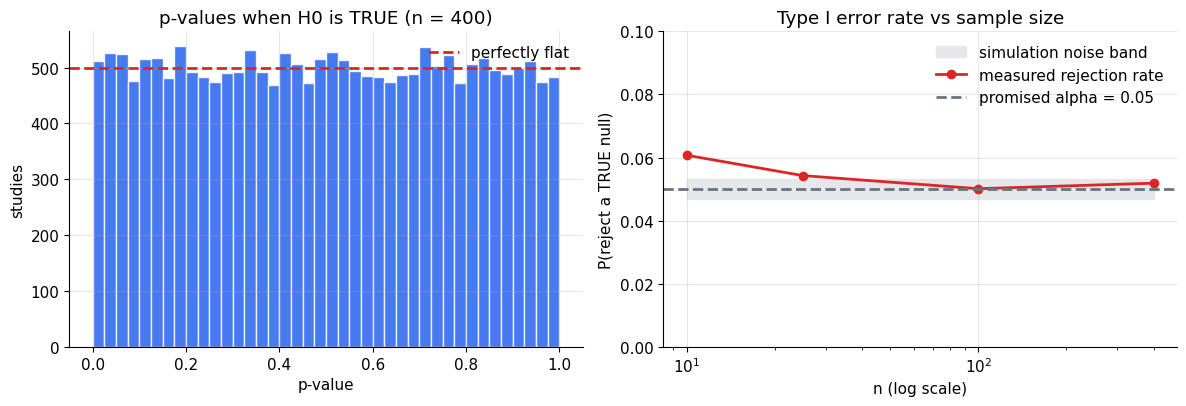

In [44]:
# ============================================================
#  5.5  Does alpha do what it says on the tin? Run 20,000 studies
#       in a world where H0 is TRUE and count the wrong rejections.
# ============================================================
rng_a  = np.random.default_rng(8080)
N_CAL  = 20_000
mc_tol = 2 * np.sqrt(0.05 * 0.95 / N_CAL)     # 2 Monte-Carlo SEs on a 5% rate

print(f"{N_CAL:,} studies at each n. A measured rate is only meaningful to")
print(f"within about +/- {mc_tol:.4f} (two Monte-Carlo standard errors).")
print()
print(f"{'n':>6}  {'P(p < 0.05)':>12}  {'P(p < 0.01)':>12}   verdict")
print("-" * 58)
p_by_n = {}
for n in (10, 25, 100, 400):
    draws = POP_H0[rng_a.integers(0, len(POP_H0), size=(N_CAL, n))]
    pv = stats.ttest_1samp(draws, CLAIM, axis=1).pvalue
    p_by_n[n] = pv
    rate = np.mean(pv < 0.05)
    note = "on target" if abs(rate - 0.05) <= mc_tol else "too eager -- skew biting"
    print(f"{n:>6}  {rate:>12.4f}  {np.mean(pv < 0.01):>12.4f}   {note}")

print()
print("The promise is 0.0500 and 0.0100. At small n the t-test is genuinely OFF,")
print("by more than simulation noise can explain: our population is skewed and")
print("the t-test was derived assuming it is not. As n grows the CLT from Part 3")
print("rescues it and the rates settle onto their promise.")
print("This is the sort of thing you can only see because we own the population.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

ax1.hist(p_by_n[400], bins=40, range=(0, 1), color=C_F, alpha=0.85,
         edgecolor="white")
ax1.axhline(N_CAL / 40, color=C_SLOPE, lw=2, ls="--", label="perfectly flat")
ax1.set_title("p-values when H0 is TRUE (n = 400)")
ax1.set_xlabel("p-value"); ax1.set_ylabel("studies")
ax1.legend(frameon=False)

ns = sorted(p_by_n)
rates = np.array([np.mean(p_by_n[n] < 0.05) for n in ns])
ax2.fill_between([min(ns), max(ns)], 0.05 - mc_tol, 0.05 + mc_tol,
                 color=C_SOFT, label="simulation noise band")
ax2.plot(ns, rates, "o-", color=C_SLOPE, lw=2, label="measured rejection rate")
ax2.axhline(0.05, color=C_GREY, lw=2, ls="--", label="promised alpha = 0.05")
ax2.set_xscale("log"); ax2.set_ylim(0, 0.10)
ax2.set_title("Type I error rate vs sample size")
ax2.set_xlabel("n (log scale)"); ax2.set_ylabel("P(reject a TRUE null)")
ax2.legend(frameon=False)

fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: when the null is true, p-values are **uniform** — every value between 0 and 1 is equally likely. That is not a coincidence, it is the design. A p-value is defined as a tail probability, and tail probabilities of the correct distribution come out flat by construction. Flatness is exactly why "reject when $p < 0.05$" produces a 5% error rate: 5% of a flat bar chart lies below 0.05.

Right: the measured rejection rate against $n$, with the promised 0.05 as a dashed line and a grey band showing how much the *simulation itself* wobbles. At $n = 10$ the point sits clearly above the band — a real miscalibration, not noise, because our population is skewed and the t-test was derived assuming it is not. By the larger sample sizes the curve has settled into the band and the promise is kept.

**The common misread:** seeing the flat left-hand histogram and concluding "most studies get large p-values, so most nulls must be true". Flatness says nothing whatever about truth — it says that when nothing is going on, $p = 0.03$ is exactly as likely as $p = 0.83$. Small p-values happen constantly in an empty world. That is what a 5% error rate *means*.

</div>

## 5.6 The two ways to be wrong

Every test ends in one of four boxes. Two are fine, two are not, and they carry
unhelpfully bland names that are nonetheless worth learning because everyone
uses them.

| | **$H_0$ is actually true** | **$H_0$ is actually false** |
|---|---|---|
| **You reject $H_0$** | ❌ **Type I error** (false positive) — rate $\alpha$ | ✅ correct — rate = **power** |
| **You do not reject** | ✅ correct | ❌ **Type II error** (false negative) — rate $\beta$ |

- **Type I** — crying wolf. You control it directly: it *is* $\alpha$, and we
  just watched it hit its target.
- **Type II** — missing a real wolf. You do **not** control it directly. It
  depends on how big the effect is, how noisy your measurements are, and how many
  observations you took.
- **Power** $= 1 - \beta$ is the probability of detecting an effect **that is
  really there**. It is the most neglected number in applied statistics, and the
  reason is simple: computing it forces you to name a specific effect size you
  care about, and most people would rather not commit.

The trade-off is unavoidable. Demand more evidence before you shout (a smaller
$\alpha$) and you will shout less often when there is nothing there — and also
stay quiet more often when there is something.

Because we own the population, we can measure power exactly: **build a world
with a real effect in it, run the study a few thousand times, and count how
often the test notices.**


In [45]:
# ============================================================
#  5.6  A real effect that the test almost always misses.
# ============================================================
rng_p = np.random.default_rng(9090)

SMALL   = 12.0     # a REAL effect: the truth is 282, the claim under test is 270
N_SMALL = 40       # a perfectly ordinary sample size
POP_SMALL = POP - POP_MU + (CLAIM + SMALL)

draws = POP_SMALL[rng_p.integers(0, len(POP_SMALL), size=(20_000, N_SMALL))]
pv    = stats.ttest_1samp(draws, CLAIM, axis=1).pvalue
power = np.mean(pv < 0.05)

print(f"The effect is REAL -- we built it. The true mean is {CLAIM + SMALL:.0f} ms,")
print(f"the claim under test is {CLAIM:.0f} ms, so H0 is definitely false.")
print()
print(f"Ran 20,000 studies of n = {N_SMALL}, each testing H0 correctly:")
print(f"  detected it (p < 0.05) : {np.sum(pv < 0.05):>6,}   ->  "
      f"power = {power:.1%}")
print(f"  MISSED it  (p >= 0.05) : {np.sum(pv >= 0.05):>6,}   ->  "
      f"Type II error rate = {1 - power:.1%}")
print()
print(f"So {1 - power:.0%} of the time an honest researcher measuring a REAL "
      f"{SMALL:.0f} ms effect")
print("walks away and writes 'no significant difference was found'.")
print()
print(f"median p-value across those 20,000 studies: {np.median(pv):.3f}")
print("Half of all correctly-run studies of this real effect land above that.")


The effect is REAL -- we built it. The true mean is 282 ms,
the claim under test is 270 ms, so H0 is definitely false.

Ran 20,000 studies of n = 40, each testing H0 correctly:
  detected it (p < 0.05) :  2,324   ->  power = 11.6%
  MISSED it  (p >= 0.05) : 17,676   ->  Type II error rate = 88.4%

So 88% of the time an honest researcher measuring a REAL 12 ms effect
walks away and writes 'no significant difference was found'.

median p-value across those 20,000 studies: 0.332
Half of all correctly-run studies of this real effect land above that.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**"p = 0.31, so there is no effect."**

The cell above is a world where the effect is real — we put it there — and the printed miss rate shows how often an honest test still comes back quiet. A non-significant result is compatible with a large effect, a small effect, and no effect at all. It rules nothing out.

The honest phrasing is *"we did not detect an effect"*, which is a statement about **your study** rather than about the world. And the follow-up question is always the same: **what effects could this study have detected?** If the answer is "only enormous ones", the null result carries almost no information — the study was never capable of the finding it went looking for.

The confidence interval from Part 4 says this far better than a p-value can. "The difference is between −3 and +45 ms" tells you the study was uninformative. "The difference is between −1 and +2 ms" tells you there is genuinely nothing there. Both are perfectly consistent with $p = 0.31$.

</div>

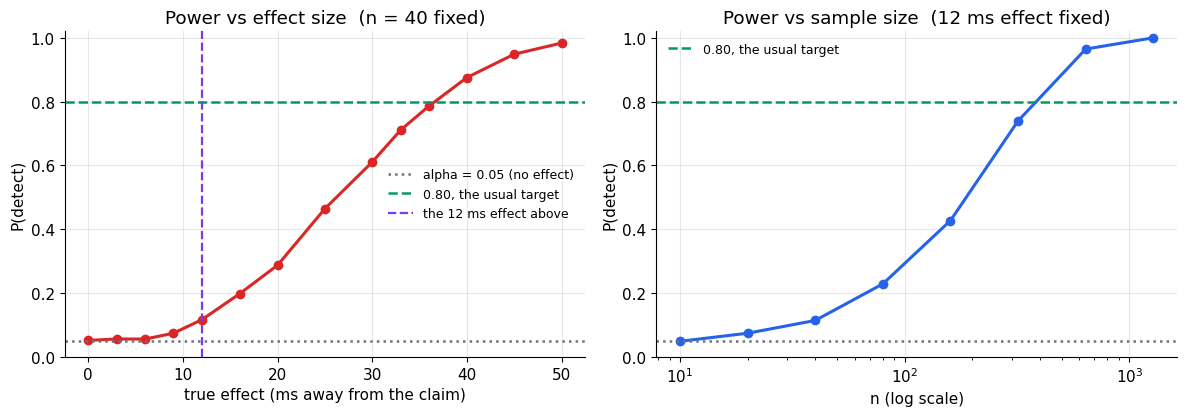

At n = 40, an effect must reach about 40 ms before this test finds it 80% of the time.
To find the 12 ms effect 80% of the time you need roughly n = 640.

Both curves start at 0.05, not at 0. With no effect at all you still
'detect' one 5% of the time -- that is alpha, drawn as a floor.

ML footnote: accuracy 93% on 2,000 test rows has SE = 0.0057 (0.57 points).
  a gap between two such scores has SE = 0.81 points, so an
  80%-power comparison needs a gap of about 2.3 points. A 0.3-point win is far below that.


In [46]:
# ============================================================
#  5.6  Power curves -- what could this study actually have found?
# ============================================================
rng_c = np.random.default_rng(1212)
REPS  = 4_000

shifts = np.array([0, 3, 6, 9, 12, 16, 20, 25, 30, 33, 36, 40, 45, 50], float)
pow_by_shift = []
for sh in shifts:
    src = POP - POP_MU + (CLAIM + sh)
    d   = src[rng_c.integers(0, len(src), size=(REPS, 40))]
    pow_by_shift.append(np.mean(stats.ttest_1samp(d, CLAIM, axis=1).pvalue < 0.05))
pow_by_shift = np.array(pow_by_shift)

sizes    = np.array([10, 20, 40, 80, 160, 320, 640, 1280])
src12    = POP - POP_MU + (CLAIM + 12.0)
pow_by_n = []
for n in sizes:
    d = src12[rng_c.integers(0, len(src12), size=(REPS, n))]
    pow_by_n.append(np.mean(stats.ttest_1samp(d, CLAIM, axis=1).pvalue < 0.05))
pow_by_n = np.array(pow_by_n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

ax1.plot(shifts, pow_by_shift, "o-", color=C_SLOPE, lw=2.2)
ax1.axhline(0.05, color=C_GREY, ls=":", lw=1.8, label="alpha = 0.05 (no effect)")
ax1.axhline(0.80, color=C_AREA, ls="--", lw=1.8, label="0.80, the usual target")
ax1.axvline(12, color=C_EXACT, ls="--", lw=1.6, label="the 12 ms effect above")
ax1.set_title("Power vs effect size  (n = 40 fixed)")
ax1.set_xlabel("true effect (ms away from the claim)")
ax1.set_ylabel("P(detect)")
ax1.set_ylim(0, 1.02); ax1.legend(frameon=False, fontsize=9)

ax2.plot(sizes, pow_by_n, "o-", color=C_F, lw=2.2)
ax2.axhline(0.80, color=C_AREA, ls="--", lw=1.8, label="0.80, the usual target")
ax2.axhline(0.05, color=C_GREY, ls=":", lw=1.8)
ax2.set_xscale("log")
ax2.set_title("Power vs sample size  (12 ms effect fixed)")
ax2.set_xlabel("n (log scale)"); ax2.set_ylabel("P(detect)")
ax2.set_ylim(0, 1.02); ax2.legend(frameon=False, fontsize=9)

fig.tight_layout(); plt.show()

big_enough = shifts[pow_by_shift >= 0.80]
n_enough   = sizes[pow_by_n >= 0.80]
print(f"At n = 40, an effect must reach about {big_enough[0]:.0f} ms before this "
      f"test finds it 80% of the time.")
print(f"To find the 12 ms effect 80% of the time you need roughly n = {n_enough[0]}.")
print()
print("Both curves start at 0.05, not at 0. With no effect at all you still")
print("'detect' one 5% of the time -- that is alpha, drawn as a floor.")
print()

# ---- the same arithmetic, on a machine-learning scoreboard ----------------
# An accuracy is a proportion, so its standard error is sqrt(a(1-a)/n_rows).
ACC, N_ROWS = 0.93, 2_000
se_acc  = np.sqrt(ACC * (1 - ACC) / N_ROWS)
se_gap  = se_acc * np.sqrt(2)                 # comparing two such scores
print(f"ML footnote: accuracy {ACC:.0%} on {N_ROWS:,} test rows has "
      f"SE = {se_acc:.4f} ({100 * se_acc:.2f} points).")
print(f"  a gap between two such scores has SE = {100 * se_gap:.2f} points, so an")
print(f"  80%-power comparison needs a gap of about "
      f"{100 * 2.8 * se_gap:.1f} points. A 0.3-point win is far below that.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: how large an effect has to be before a study of 40 people reliably finds it. The curve starts on the dashed floor of 0.05 (no effect, yet you still reject 5% of the time) and climbs from there. The purple line marks the real 12 ms effect from the previous cell, sitting far below the 0.80 target — which is exactly why that test kept missing.

Right: the same 12 ms effect, now with $n$ on a log axis. Power climbs steadily, and the printed sample size is what it takes to reach 0.80. Note the shape: because the standard error falls as $1/\sqrt{n}$, power is expensive — roughly **four times** the data to halve the detectable effect.

**The common misread:** treating these curves as something to draw *after* the study, to explain away a disappointing result. Their real use is **before** it — you name the smallest effect that would matter, read off the $n$ you need, and then decide whether the study is worth running at all. A study run at 12% power is not a cheap study; it is a study that will probably answer nothing.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**Model A scores 93.4% on your test set; model B scores 93.1%. Ship A?**

That is a hypothesis test whether you call it one or not, and every idea in this part applies. The null is "the two models are equally good", the test set is the sample, and the 0.3 point gap is the statistic.

Two failure modes, both routine in practice:

- **Underpowered.** An accuracy is a proportion, so its standard error is $\sqrt{a(1-a)/n_{\text{rows}}}$ — the ML footnote printed under the power curves works it out for a 2,000-row test set, along with how large a gap this comparison could actually resolve. Compare that with 0.3 points. Part 6 puts a proper interval on a difference like this, and Part 9 does it on real model scores.
- **Overpowered.** Scale the test set into the millions and a two-hundredth of a point becomes overwhelmingly significant — and stays utterly irrelevant to anybody. Significance is not importance.

The habit worth building: never report a model comparison as a bare pair of numbers. Report the **difference**, an **interval** on it, and **how many test rows** it came from.

</div>

---

### Where we are

You can now say what a p-value is — a tail probability computed *inside* an
assumed world — because you built one by counting rather than looking it up. You
know the three things it is not, and you have watched each failure happen in
simulation instead of being told about it. You know that $\alpha$ is a
convention with an exact operational meaning, that power is the neglected half
of the picture, and that "not significant" is a statement about your study.

One thing has been conspicuously missing. Every test so far compared a sample to
a **number** — the claim of 270 ms. Almost no real question looks like that.
Real questions compare **two groups**: treatment against control, variant A
against variant B, model A against model B.

**Part 6** builds that test, and builds it twice — once with the classical
formula, and once by shuffling the group labels, which assumes essentially
nothing and is the better picture to keep in your head. It also introduces the
number this entire part has been missing: **effect size**, which answers "how
big is it?" rather than "is it there?", and which deserves equal billing with
every p-value you will ever report.


---

# 6️⃣ Comparing groups: t-tests and effect size

Part 5 compared a sample against a **number**. Almost nothing you will ever be
asked to do looks like that. Real questions compare **two groups**:

- Does the drug beat the placebo?
- Does layout B convert better than layout A?
- Is model B actually better than model A, or did it get a friendlier test set?

So we need a test for a **difference between two means** — and the good news is
that we do not need any new ideas. Parts 3 and 4 already gave us everything: a
sample mean wobbles, the size of that wobble is the standard error, and the
Central Limit Theorem makes the wobble roughly bell-shaped. A difference of two
means is just one more quantity that wobbles, and we can work out by how much.

The running example: half our reaction-time population is given a treatment that
genuinely makes people faster. We choose the effect ourselves, so **we know the
right answer** and can check whether each test finds it.

Two things get equal billing in this part, and only one of them usually does in
practice:

> **"Is there a difference?"** — the p-value.
> **"How big is it?"** — the effect size.
>
> A result reported with only the first is not a finding. It is half of one.


In [47]:
# ============================================================
#  6.1  Two populations. We build the difference, so we know it.
# ============================================================
from scipy import stats

TRUE_EFFECT = 35.0        # the treatment really does speed people up by this
N_GROUP     = 60          # participants per group

POP_CTRL  = POP                     # control: the population from Part 0
POP_TREAT = POP - TRUE_EFFECT       # treatment: identical shape, shifted faster

rng6 = np.random.default_rng(605)
ctrl  = rng6.choice(POP_CTRL,  N_GROUP, replace=False)
treat = rng6.choice(POP_TREAT, N_GROUP, replace=False)

print("THE TRUTH (visible only because we simulated it):")
print(f"  control population mean   = {POP_CTRL.mean():8.2f} ms")
print(f"  treatment population mean = {POP_TREAT.mean():8.2f} ms")
print(f"  true difference           = {TRUE_EFFECT:8.2f} ms")
print()
print(f"WHAT A REAL STUDY SEES ({N_GROUP} people per group):")
print(f"  control  mean = {ctrl.mean():8.2f} ms   sd = {ctrl.std(ddof=1):6.2f}")
print(f"  treatment mean = {treat.mean():7.2f} ms   sd = {treat.std(ddof=1):6.2f}")
print(f"  observed difference = {ctrl.mean() - treat.mean():.2f} ms")
print()
print(f"The observed difference misses the truth by "
      f"{ctrl.mean() - treat.mean() - TRUE_EFFECT:+.2f} ms.")
print("Nothing went wrong. That is what 60-per-group looks like.")


THE TRUTH (visible only because we simulated it):
  control population mean   =   290.99 ms
  treatment population mean =   255.99 ms
  true difference           =    35.00 ms

WHAT A REAL STUDY SEES (60 people per group):
  control  mean =   298.27 ms   sd = 100.44
  treatment mean =  262.81 ms   sd =  82.57
  observed difference = 35.46 ms

The observed difference misses the truth by +0.46 ms.
Nothing went wrong. That is what 60-per-group looks like.


## 6.1 The two-sample t-test, derived rather than recited

Part 3 established that a sample mean has a standard error

$$\text{SE}(\bar{x}) = \frac{s}{\sqrt{n}}$$

— the typical distance between your sample mean and the truth. Now we have two
sample means, and we care about their **difference**, $\bar{x}_1 - \bar{x}_2$.

That difference is itself a random quantity, so it has its own standard error.
Both means wobble, and they wobble independently (different people in each
group), so the wobbles do not cancel — but they do not simply add either. For
independent quantities, **variances** add:

$$\text{Var}(\bar{x}_1 - \bar{x}_2) = \text{Var}(\bar{x}_1) + \text{Var}(\bar{x}_2)
\qquad\Longrightarrow\qquad
\text{SE}_{\text{diff}} = \sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}$$

Note the plus sign even though we are subtracting. Uncertainties never cancel;
combining two noisy estimates gives you a noisier one.

From here the test is a copy of Part 5. Ask how many standard errors the
observed difference sits from the null value of zero:

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\text{SE}_{\text{diff}}}$$

with $H_0: \mu_1 = \mu_2$ (the two populations have the same mean).

### The assumptions, stated honestly

| Assumption | What happens if it fails |
|---|---|
| **Independent observations** within and between groups | Serious. Correlated data makes the SE far too small and p-values far too eager. This is the one that actually ruins analyses. |
| **Roughly normal sampling distribution of each mean** | Mild for decent $n$ — the CLT of Part 3 does the work. Bites at small $n$ with skewed data, exactly as we saw in Part 5. |
| **Equal variances in the two groups** | Only for the classical ("Student") version. §6.3 shows how badly it can fail, and that the fix is free. |

Our data violates the second assumption at the population level — the reaction
times are visibly skewed — so we should not simply trust the formula. We will
check it against a method that assumes almost nothing.


In [48]:
# ============================================================
#  6.1  The statistic by hand, then from scipy.
# ============================================================
diff = ctrl.mean() - treat.mean()
se_diff = np.sqrt(ctrl.var(ddof=1) / N_GROUP + treat.var(ddof=1) / N_GROUP)
t_hand2 = diff / se_diff

print(f"observed difference      = {diff:8.3f} ms")
print(f"SE of that difference    = {se_diff:8.3f} ms   "
      f"(sqrt of the two squared SEs added)")
print(f"t = difference / SE      = {t_hand2:8.4f}   "
      f"standard errors away from zero")
print()

t_stu, p_stu = stats.ttest_ind(ctrl, treat, equal_var=True)    # Student
t_wel, p_wel = stats.ttest_ind(ctrl, treat, equal_var=False)   # Welch

print(f"scipy, Student (equal variances assumed) : t = {t_stu:.4f}, p = {p_stu:.4f}")
print(f"scipy, Welch   (variances free to differ): t = {t_wel:.4f}, p = {p_wel:.4f}")
print(f"our hand-rolled t matches Welch's to      {abs(t_hand2 - t_wel):.2e}")
print()
print(f"Verdict at 0.05: {'REJECT H0' if p_wel < 0.05 else 'do not reject H0'}")
print(f"Correct answer: the groups DO differ, by {TRUE_EFFECT:.0f} ms. "
      f"{'Right call.' if p_wel < 0.05 else 'The test missed it.'}")


observed difference      =   35.462 ms
SE of that difference    =   16.786 ms   (sqrt of the two squared SEs added)
t = difference / SE      =   2.1126   standard errors away from zero

scipy, Student (equal variances assumed) : t = 2.1126, p = 0.0367
scipy, Welch   (variances free to differ): t = 2.1126, p = 0.0368
our hand-rolled t matches Welch's to      0.00e+00

Verdict at 0.05: REJECT H0
Correct answer: the groups DO differ, by 35 ms. Right call.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$t = \dfrac{\bar{x}_1 - \bar{x}_2}{\sqrt{s_1^2/n_1 + s_2^2/n_2}}$ says:

> **Measure the gap between the two group averages in units of how much that gap would jiggle around anyway.**

The numerator is the signal — how far apart the groups look. The denominator is the noise — how far apart two groups drawn from the *same* population would typically look, given this much data and this much spread. $t$ is their ratio, so it is a **signal-to-noise ratio** and nothing more exotic.

$t = 0.4$ means the gap is smaller than the everyday jiggle: unremarkable. $t = 4$ means the gap is four times the jiggle: hard to explain by chance. The p-value merely converts that ratio into a probability.

</div>

pooled 120 people, re-dealt the group labels 20,000 times
  differences produced by pure label-shuffling ranged -59.5 .. 61.9 ms
  741 of them were at least as big as our real 35.46 ms

  p (permutation) = 0.0370


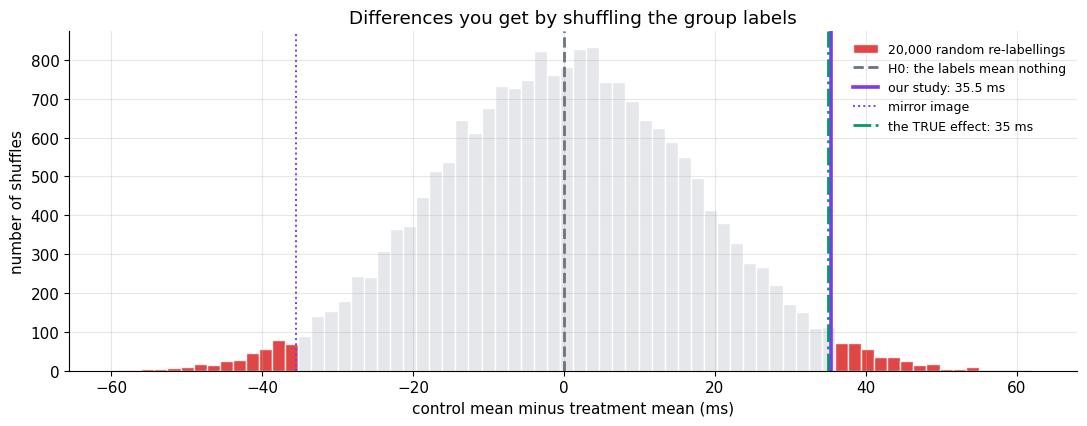

In [49]:
# ============================================================
#  6.2  The same p-value with almost no assumptions: PERMUTATION.
#
#  If the treatment did nothing, then every person's reaction time
#  would be the number it is regardless of which group they landed in.
#  The labels "control"/"treatment" would be pure decoration.
#
#  So: pool all 120 people, deal the labels out at random, recompute
#  the difference. Do it 20,000 times. That IS the null distribution --
#  no bell curve, no equal-variance assumption, no formula.
# ============================================================
rng_perm = np.random.default_rng(6161)
N_PERM   = 20_000

pool = np.concatenate([ctrl, treat])
shuffled = rng_perm.permuted(np.tile(pool, (N_PERM, 1)), axis=1)
perm_diffs = shuffled[:, :N_GROUP].mean(axis=1) - shuffled[:, N_GROUP:].mean(axis=1)

p_perm = np.mean(np.abs(perm_diffs) >= abs(diff))

print(f"pooled {len(pool)} people, re-dealt the group labels {N_PERM:,} times")
print(f"  differences produced by pure label-shuffling ranged "
      f"{perm_diffs.min():.1f} .. {perm_diffs.max():.1f} ms")
print(f"  {np.sum(np.abs(perm_diffs) >= abs(diff)):,} of them were at least as "
      f"big as our real {diff:.2f} ms")
print()
print(f"  p (permutation) = {p_perm:.4f}")

fig, ax = plt.subplots(figsize=(11, 4.4))
counts, bins, patches = ax.hist(perm_diffs, bins=70, color=C_SOFT,
                                edgecolor="white",
                                label="20,000 random re-labellings")
half = (bins[1] - bins[0]) / 2
for pat, left in zip(patches, bins[:-1]):
    if abs(left + half) >= abs(diff):
        pat.set_facecolor(C_SLOPE); pat.set_alpha(0.85)

ax.axvline(0, color=C_GREY, lw=2.0, ls="--", label="H0: the labels mean nothing")
ax.axvline(diff, color=C_EXACT, lw=2.6, label=f"our study: {diff:.1f} ms")
ax.axvline(-diff, color=C_EXACT, lw=1.4, ls=":", label="mirror image")
ax.axvline(TRUE_EFFECT, color=C_AREA, lw=2.0, ls="-.",
           label=f"the TRUE effect: {TRUE_EFFECT:.0f} ms")
ax.set_title("Differences you get by shuffling the group labels")
ax.set_xlabel("control mean minus treatment mean (ms)")
ax.set_ylabel("number of shuffles")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Every bar in this histogram comes from **our own 120 measurements**. Nothing was generated, assumed, or looked up: we took the actual numbers, threw the group labels in the air, and recomputed the difference 20,000 times. That is a picture of what "the treatment does nothing" looks like *for this dataset*.

It is centred on zero, because shuffling cannot create a systematic gap. Its width is a direct measurement of how much difference this much data produces out of nothing. The purple line is our real study; the green dash-dot line is the true effect, which we are allowed to see and a real analyst is not.

**The common misread:** thinking the shuffling somehow *tests* the treatment. It does the opposite — it deliberately **destroys** any treatment effect, so that we can see the scale of the noise on its own. The test is the comparison between the destroyed version and the real one. Everything in hypothesis testing has this shape: build the boring world carefully, then see how badly your data fits in it.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Two p-values for the same question, from methods with almost nothing in common. The permutation version used no formula, no t distribution, no normality assumption and no equal-variance assumption — only the **exchangeability** of the labels under $H_0$. Compare the printed `p_perm` with `p_wel` above: they agree to within the Monte-Carlo noise of 20,000 shuffles.

That agreement is the point. It tells you the t-test was not doing anything mysterious here; it was a fast analytic shortcut to the shuffling.

**Keep the shuffling as your mental model.** When someone reports a t-test, picture the labels being re-dealt. When the data are strange enough that you doubt the formula — heavy tails, tiny groups, a statistic with no textbook distribution such as a median or an F1 score — you can *run* the shuffling instead, and it will still be valid when the formula is not.

</div>

## 6.2 Pairing: the design choice that beats a bigger sample

Suppose you want to know whether a nudge speeds people up, and people differ
enormously from one another — which they do. In our population the
person-to-person spread is far larger than the effect we are hunting. Comparing
sixty people who got the nudge against sixty who did not means the treatment
signal has to fight through all of that individual variation.

There is a way out that costs nothing: **measure the same people twice**, once
without and once with. Then compute *each person's own* change and test whether
those changes average to zero.

Why this is such a large win: each person acts as their own control, so
everything that makes them individually fast or slow — age, caffeine, sleep,
reflexes — appears in *both* their measurements and **cancels out of the
difference**. What is left is only the within-person noise, which is usually far
smaller than the between-person spread.

The test itself is not new. Compute the $n$ differences, then run the
**one-sample t-test from Part 5** on them against a null of zero. That is all a
"paired t-test" is: a one-sample test wearing a different hat.

Below, the same experiment analysed both ways.


person-to-person spread (sd of 'before') :   84.54 ms
spread of the per-person CHANGES         :   14.23 ms  <- far smaller
mean change                              :   17.98 ms  (truth: 14 ms)

  UNPAIRED test (throws the pairing away) : p = 0.406645   NOT significant -- effect MISSED
  PAIRED test   (uses it)                 : p = 1.328e-07   significant -- effect FOUND

  paired t-test == one-sample t-test on the changes: p = 1.328e-07  (identical)

Same 60 measurements. Same real effect. Opposite conclusions.
The difference is entirely in the DESIGN, not in the data collection.


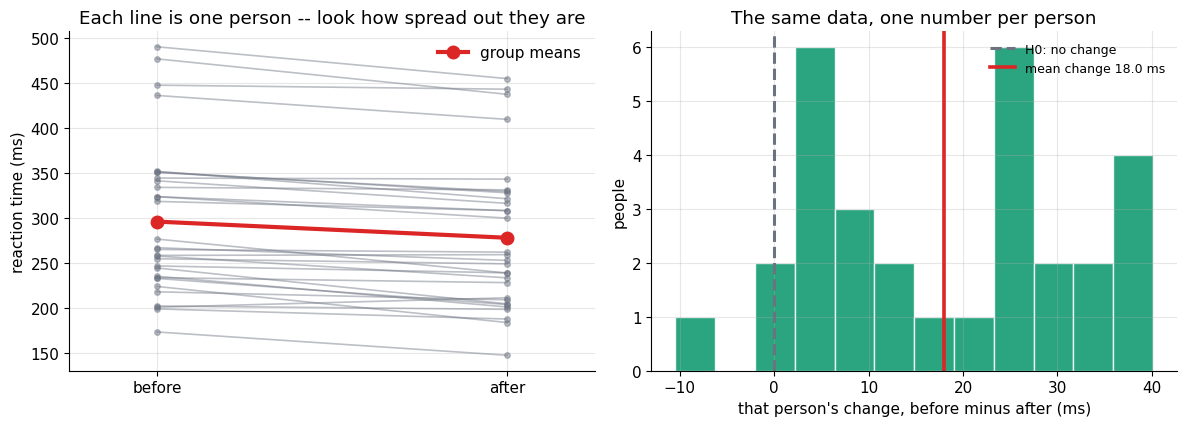

In [50]:
# ============================================================
#  6.2  Same experiment, two analyses: unpaired vs paired.
# ============================================================
rng_pair = np.random.default_rng(707)

N_SUBJ       = 30
WITHIN_GAIN  = 14.0    # the nudge really does save this many ms, per person
MEASURE_NOISE = 10.0   # each individual measurement is noisy by this much

baseline = rng_pair.choice(POP, N_SUBJ, replace=False)      # who is fast or slow
before   = baseline + rng_pair.normal(0, MEASURE_NOISE, N_SUBJ)
after    = baseline - WITHIN_GAIN + rng_pair.normal(0, MEASURE_NOISE, N_SUBJ)
gains    = before - after

p_unpaired = stats.ttest_ind(before, after, equal_var=False).pvalue
p_paired   = stats.ttest_rel(before, after).pvalue
p_paired_1samp = stats.ttest_1samp(gains, 0.0).pvalue

print(f"person-to-person spread (sd of 'before') : {before.std(ddof=1):7.2f} ms")
print(f"spread of the per-person CHANGES         : {gains.std(ddof=1):7.2f} ms  "
      f"<- far smaller")
print(f"mean change                              : {gains.mean():7.2f} ms  "
      f"(truth: {WITHIN_GAIN:.0f} ms)")
print()
print(f"  UNPAIRED test (throws the pairing away) : p = {p_unpaired:.6f}   "
      f"{'significant' if p_unpaired < 0.05 else 'NOT significant -- effect MISSED'}")
print(f"  PAIRED test   (uses it)                 : p = {p_paired:.3e}   "
      f"{'significant -- effect FOUND' if p_paired < 0.05 else 'not significant'}")
print()
print(f"  paired t-test == one-sample t-test on the changes: "
      f"p = {p_paired_1samp:.3e}  (identical)")
print()
print("Same 60 measurements. Same real effect. Opposite conclusions.")
print("The difference is entirely in the DESIGN, not in the data collection.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

for b, a in zip(before, after):
    ax1.plot([0, 1], [b, a], "-o", color=C_GREY, alpha=0.45, ms=4, lw=1.2)
ax1.plot([0, 1], [before.mean(), after.mean()], "-o", color=C_SLOPE, lw=3, ms=9,
         label="group means")
ax1.set_xticks([0, 1]); ax1.set_xticklabels(["before", "after"])
ax1.set_xlim(-0.25, 1.25)
ax1.set_ylabel("reaction time (ms)")
ax1.set_title("Each line is one person -- look how spread out they are")
ax1.legend(frameon=False)

ax2.hist(gains, bins=12, color=C_AREA, alpha=0.85, edgecolor="white")
ax2.axvline(0, color=C_GREY, lw=2.2, ls="--", label="H0: no change")
ax2.axvline(gains.mean(), color=C_SLOPE, lw=2.6,
            label=f"mean change {gains.mean():.1f} ms")
ax2.set_xlabel("that person's change, before minus after (ms)")
ax2.set_ylabel("people")
ax2.set_title("The same data, one number per person")
ax2.legend(frameon=False, fontsize=9)

fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the raw measurements. The lines are all over the vertical axis because people genuinely differ by a lot, and the two group means (red) are barely separated against that backdrop. An unpaired test sees only those two clouds and reasonably concludes it cannot tell them apart.

Right: exactly the same data, collapsed to one number per person — *their* change. The enormous between-person spread has vanished, because it appeared in both of that person's measurements and subtracted out. Nearly every bar sits to the right of zero, and the conclusion is now obvious to the eye.

**The common misread:** believing the paired test is a stronger *test*. It is the same test — literally the one-sample t-test of Part 5, as the printed identical p-values confirm. What changed is the **design**. Pairing removes a source of noise before any statistics happen, which is almost always cheaper than collecting more people to average that noise away.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

Unpaired, the noise you fight is the spread **between people**:

$$\text{SE}_{\text{unpaired}} = \sqrt{\frac{s_1^2}{n} + \frac{s_2^2}{n}}$$

Paired, it is only the spread **of the changes**:

$$\text{SE}_{\text{paired}} = \frac{s_d}{\sqrt{n}}, \qquad d_i = \text{before}_i - \text{after}_i$$

Compare the two printed spreads in the cell above. The change-spread is a small fraction of the person-spread, and since $t$ divides by that quantity, the same effect produces a far larger $t$.

**When you can pair, pair.** Before-and-after on the same subjects, matched littermates, the same users seeing both layouts, the same test items scored by both models. The catch is that pairing must be part of the *design* — you cannot pair after the fact, because the pairs have to be real. And never run an unpaired test on paired data: it throws away the whole advantage.

</div>

## 6.3 Welch's t-test, and why it should be your default

The classical Student t-test assumes both groups have the **same variance**, and
uses that assumption to pool their spreads into a single estimate. It buys a
little precision when the assumption holds.

It is a bad bargain. Groups usually differ in spread as well as in centre — a
treatment often makes people more variable, not just faster — and unequal group
sizes are the norm. Welch's version simply drops the assumption: it keeps the
two variances separate (which is the $\sqrt{s_1^2/n_1 + s_2^2/n_2}$ we derived
above) and adjusts the degrees of freedom to compensate.

The cost of using Welch when variances *are* equal is negligible — a hair of
power. The cost of using Student when they are not can be enormous, and we can
measure it exactly, because we can build a world where $H_0$ is **true by
construction** and count the false alarms.

The setup: two groups with the **same true mean** but very different spreads and
very different sizes. Any rejection is a false positive. A well-behaved test
should reject 5% of the time.


In [51]:
# ============================================================
#  6.3  Both groups have the SAME true mean. Every rejection is wrong.
# ============================================================
rng_w = np.random.default_rng(808)
NSIM_W = 20_000

# Same mean as POP, same shape, three times the spread.
POP_WIDE = POP_MU + 3.0 * (POP - POP_MU)
print(f"narrow population: mean {POP.mean():.2f}, sd {POP.std(ddof=0):.2f}")
print(f"wide   population: mean {POP_WIDE.mean():.2f}, sd {POP_WIDE.std(ddof=0):.2f}")
print("Identical means -- so H0 is TRUE and every rejection is a false alarm.\n")

N_SMALL_G, N_BIG_G = 10, 50

print(f"{'setup':<44}{'Student':>10}{'Welch':>10}")
print("-" * 64)
for label, small_pop, big_pop in (
        ("small group is the WIDE one  (10 wide vs 50 narrow)", POP_WIDE, POP),
        ("small group is the NARROW one (10 narrow vs 50 wide)", POP, POP_WIDE)):
    a = small_pop[rng_w.integers(0, len(small_pop), (NSIM_W, N_SMALL_G))]
    b = big_pop[rng_w.integers(0, len(big_pop),   (NSIM_W, N_BIG_G))]
    ps = stats.ttest_ind(a, b, axis=1, equal_var=True).pvalue
    pw = stats.ttest_ind(a, b, axis=1, equal_var=False).pvalue
    print(f"{label:<44}{np.mean(ps < 0.05):>10.3f}{np.mean(pw < 0.05):>10.3f}")

print()
print("Both rows should read 0.050 in both columns. Welch does. Student does not:")
print("it is wildly too eager in one direction and far too timid in the other,")
print("and which one you get depends on an accident of which group was bigger.")


narrow population: mean 290.99, sd 83.01
wide   population: mean 290.99, sd 249.04
Identical means -- so H0 is TRUE and every rejection is a false alarm.

setup                                          Student     Welch
----------------------------------------------------------------


small group is the WIDE one  (10 wide vs 50 narrow)     0.292     0.057
small group is the NARROW one (10 narrow vs 50 wide)     0.001     0.051

Both rows should read 0.050 in both columns. Welch does. Student does not:
it is wildly too eager in one direction and far too timid in the other,
and which one you get depends on an accident of which group was bigger.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

This is a claim about a test, verified by running the test twenty thousand times in a world where we know the answer. The target is 0.050 in every cell of that table. Welch lands on it in both rows; Student misses badly in both, and — the genuinely nasty part — misses in **opposite directions** depending on which group happened to be larger.

When the small group is the more variable one, Student's pooled variance underestimates the real uncertainty and the test cries wolf far more often than 5%. When the small group is the tighter one, the pooling overestimates the uncertainty and the test goes quiet.

**Practical rule:** pass `equal_var=False`. Always. It is the default in R's `t.test()` for exactly this reason, and it is one keyword in scipy. There is no situation in which the pooled version's tiny gain is worth this exposure.

</div>

## 6.4 Effect size: the number that answers the actual question

A p-value answers *"is there a difference?"*. Nobody has ever wanted to know
only that. What they want is *"how big is it, and does it matter?"* — and the
p-value cannot tell them, because it blends the size of the effect with the size
of the study.

**Cohen's $d$** separates them. It measures the gap between the groups in units
of how spread out the data is:

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{pooled}}},
\qquad
s_{\text{pooled}} = \sqrt{\frac{s_1^2 + s_2^2}{2}}$$

Crucially, **$n$ does not appear**. Collect a thousand times more data and $d$
converges on a fixed number — the real effect — while $p$ marches off toward
zero. They are measuring different things.

The conventional (and entirely arbitrary — Cohen himself called them a
last resort) rules of thumb:

| $\lvert d \rvert$ | Label | Rough picture |
|---|---|---|
| 0.2 | small | the distributions overlap almost completely |
| 0.5 | medium | visible to the naked eye in a plot |
| 0.8 | large | the groups clearly separate |

Because $d$ is unit-free, it also lets you compare a reaction-time effect with a
test-score effect — which is exactly why meta-analysis is possible at all.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$d$ asks: **how far apart are the two groups, measured in typical person-to-person spreads?**

$d = 1$ means the average treated person is one whole standard deviation from the average control — a big, visible shift. $d = 0.1$ means the two groups are separated by a tenth of the everyday variation between individuals, so the distributions sit almost exactly on top of each other even though their *means* genuinely differ.

The contrast with $p$ is the whole point:

- **$p$ shrinks as you collect more data**, for a fixed real effect. It is a statement about your evidence.
- **$d$ does not.** It converges on the truth. It is a statement about the world.

Report both, always. One of them tells the reader whether to believe you; the other tells them whether to care.

</div>

OUR STUDY
  difference      = 35.46 ms
  pooled sd       = 91.94 ms
  Cohen's d       = 0.386   (true value 0.422)
  p               = 0.0368
  -> a real, statistically detectable, but SMALL effect: 0.39 of one standard deviation.

A TRIVIAL 2 ms DIFFERENCE, MEASURED HARDER AND HARDER
  n per group      median p    median d   verdict at 0.05
--------------------------------------------------------------
          100         0.518      0.0260   not significant


        1,000         0.408      0.0275   not significant


       10,000        0.0993      0.0233   not significant
      100,000      5.47e-07      0.0224   SIGNIFICANT


    1,000,000      4.66e-58      0.0235   SIGNIFICANT

p travels from 0.518 down to 4.66e-58.
d never moves: it stays around 0.024 -- negligible, which is the truth.
Same two-millisecond world throughout. Only the budget changed.


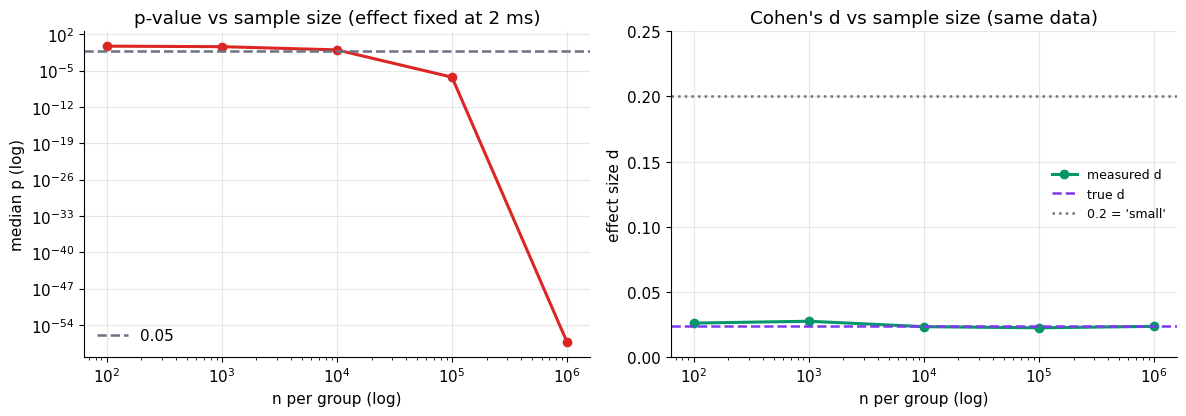

In [52]:
# ============================================================
#  6.4  Cohen's d for our study -- and then the demonstration
#       that matters: a TRIVIAL effect made "highly significant"
#       purely by collecting a lot of data.
# ============================================================
s_pooled = np.sqrt((ctrl.var(ddof=1) + treat.var(ddof=1)) / 2)
d_obs    = diff / s_pooled
d_true   = TRUE_EFFECT / POP.std(ddof=0)

print("OUR STUDY")
print(f"  difference      = {diff:.2f} ms")
print(f"  pooled sd       = {s_pooled:.2f} ms")
print(f"  Cohen's d       = {d_obs:.3f}   (true value {d_true:.3f})")
print(f"  p               = {p_wel:.4f}")
print(f"  -> a real, statistically detectable, but SMALL effect: {d_obs:.2f} of "
      f"one standard deviation.")
print()

# ---- now: a 2 ms difference. Nobody could care. Watch p collapse. ----
rng_big = np.random.default_rng(909)
TINY = 2.0                       # two milliseconds. Truly irrelevant.
grid = [(100, 200), (1_000, 200), (10_000, 100), (100_000, 30), (1_000_000, 4)]

print(f"A TRIVIAL {TINY:.0f} ms DIFFERENCE, MEASURED HARDER AND HARDER")
print(f"{'n per group':>13}  {'median p':>12}  {'median d':>10}   verdict at 0.05")
print("-" * 62)
ns_big, ps_big, ds_big = [], [], []
for n, reps in grid:
    pv, dv = [], []
    for _ in range(reps):
        x = POP[rng_big.integers(0, len(POP), n)]
        y = POP[rng_big.integers(0, len(POP), n)] - TINY
        pv.append(stats.ttest_ind(x, y, equal_var=False).pvalue)
        sp = np.sqrt((x.var(ddof=1) + y.var(ddof=1)) / 2)
        dv.append((x.mean() - y.mean()) / sp)
    mp, mdd = float(np.median(pv)), float(np.median(dv))
    ns_big.append(n); ps_big.append(mp); ds_big.append(mdd)
    print(f"{n:>13,}  {mp:>12.3g}  {mdd:>10.4f}   "
          f"{'SIGNIFICANT' if mp < 0.05 else 'not significant'}")

print()
print(f"p travels from {ps_big[0]:.3g} down to {ps_big[-1]:.3g}.")
print(f"d never moves: it stays around {np.median(ds_big):.3f} -- negligible, which "
      f"is the truth.")
print("Same two-millisecond world throughout. Only the budget changed.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.plot(ns_big, ps_big, "o-", color=C_SLOPE, lw=2.2)
ax1.axhline(0.05, color=C_GREY, ls="--", lw=1.8, label="0.05")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_title("p-value vs sample size (effect fixed at 2 ms)")
ax1.set_xlabel("n per group (log)"); ax1.set_ylabel("median p (log)")
ax1.legend(frameon=False)

ax2.plot(ns_big, np.abs(ds_big), "o-", color=C_AREA, lw=2.2, label="measured d")
ax2.axhline(TINY / POP.std(ddof=0), color=C_EXACT, ls="--", lw=1.8,
            label="true d")
ax2.axhline(0.2, color=C_GREY, ls=":", lw=1.8, label="0.2 = 'small'")
ax2.set_xscale("log"); ax2.set_ylim(0, 0.25)
ax2.set_title("Cohen's d vs sample size (same data)")
ax2.set_xlabel("n per group (log)"); ax2.set_ylabel("effect size d")
ax2.legend(frameon=False, fontsize=9)

fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the median p-value falling off a cliff — note the log scale on **both** axes — as the study gets bigger. Nothing about the world changed between those points. The difference was two milliseconds at every sample size. Only the amount of data changed.

Right: Cohen's $d$ over exactly the same runs, on a linear axis, sitting flat on the true value and far below even the "small" line. It gets more *precise* as $n$ grows — the points stop jumping around — but it does not drift, because it is estimating something real.

**The common misread:** reading the left panel as "more data gives a better answer". More data gives a **more certain** answer to "is the difference exactly zero?" — and the answer to that question is almost always no, for any two things that are not literally identical. With enough rows you will reject essentially every null you ever write down. That is not a discovery; it is arithmetic.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**"p < 0.001, so this is a strong result."**

The table above contains a two-millisecond difference reported at a p-value small enough to look like a law of nature. It is still two milliseconds. No product decision, no clinical decision and no engineering decision should turn on it.

**With enough data, everything is significant.** Any two groups that are not literally identical differ by *something*, and a large enough $n$ will find that something. This is not a flaw in the test — the test answered the question it was asked. It is a flaw in the question.

So significance alone is never a finding. The reportable result is three things together:

1. **the effect** — in the units people actually care about (milliseconds, dollars, percentage points);
2. **an interval on it** — how precisely you pinned it down;
3. **the p-value**, if you like, as a footnote.

If a paper or a dashboard gives you only the third, you have been told the least informative of the three.

</div>

In [53]:
# ============================================================
#  6.5  The interval on the difference -- what you should
#       actually be reporting. Built exactly as in Part 4,
#       but around the DIFFERENCE instead of a single mean.
# ============================================================
dof   = 2 * N_GROUP - 2
t_crit = stats.t.ppf(0.975, dof)
lo, hi = diff - t_crit * se_diff, diff + t_crit * se_diff

print(f"observed difference : {diff:.2f} ms")
print(f"95% CI              : [{lo:.2f}, {hi:.2f}] ms   (width {hi - lo:.1f} ms)")
print(f"true difference     : {TRUE_EFFECT:.2f} ms -> "
      f"{'INSIDE the interval' if lo <= TRUE_EFFECT <= hi else 'OUTSIDE'}")
print(f"does the interval exclude zero? {'yes' if lo > 0 else 'no'}  "
      f"(equivalent to p < 0.05: {p_wel < 0.05})")
print()

# Does the interval keep its 95% promise? Build 5,000 of them and count.
rng_ci = np.random.default_rng(1111)
NSIM_CI = 5_000
A = POP_CTRL[rng_ci.integers(0, len(POP_CTRL),  (NSIM_CI, N_GROUP))]
B = POP_TREAT[rng_ci.integers(0, len(POP_TREAT), (NSIM_CI, N_GROUP))]
dd  = A.mean(axis=1) - B.mean(axis=1)
sed = np.sqrt(A.var(axis=1, ddof=1) / N_GROUP + B.var(axis=1, ddof=1) / N_GROUP)
los, his = dd - t_crit * sed, dd + t_crit * sed

print(f"built {NSIM_CI:,} such intervals from fresh studies:")
print(f"  contained the true {TRUE_EFFECT:.0f} ms : {np.mean((los <= TRUE_EFFECT) & (TRUE_EFFECT <= his)):.1%}"
      f"   (promised 95%)")
print(f"  excluded zero (i.e. p < 0.05)  : {np.mean(los > 0):.1%}"
      f"   <- this is the POWER of the study")
print(f"  average width                  : {np.mean(his - los):.1f} ms")
print()
print("Read that width. Even when this study 'works', it pins the effect down")
print("only to within tens of milliseconds. A p-value would never have told you.")
print()

# ---- the same interval, on a model comparison --------------------------
# Accuracy is a proportion: SE = sqrt(a(1-a)/rows). Two models scored on the
# SAME rows, compared the crude way (as if the test sets were independent).
ACC_A, ACC_B, ROWS = 0.934, 0.931, 2_000
se_pair = np.sqrt(ACC_A * (1 - ACC_A) / ROWS + ACC_B * (1 - ACC_B) / ROWS)
gap     = ACC_A - ACC_B
z       = 1.96
print(f"MODEL COMPARISON: {ACC_A:.1%} vs {ACC_B:.1%} on {ROWS:,} test rows")
print(f"  observed gap : {100 * gap:+.2f} points")
print(f"  SE of the gap: {100 * se_pair:.2f} points")
print(f"  95% CI       : [{100 * (gap - z * se_pair):+.2f}, "
      f"{100 * (gap + z * se_pair):+.2f}] points -> "
      f"{'excludes' if gap - z * se_pair > 0 else 'comfortably includes'} zero")
print("  So that 0.3-point 'win' is indistinguishable from a coin flip.")


observed difference : 35.46 ms
95% CI              : [2.22, 68.70] ms   (width 66.5 ms)
true difference     : 35.00 ms -> INSIDE the interval
does the interval exclude zero? yes  (equivalent to p < 0.05: True)

built 5,000 such intervals from fresh studies:
  contained the true 35 ms : 95.5%   (promised 95%)
  excluded zero (i.e. p < 0.05)  : 64.3%   <- this is the POWER of the study
  average width                  : 59.9 ms

Read that width. Even when this study 'works', it pins the effect down
only to within tens of milliseconds. A p-value would never have told you.

MODEL COMPARISON: 93.4% vs 93.1% on 2,000 test rows
  observed gap : +0.30 points
  SE of the gap: 0.79 points
  95% CI       : [-1.25, +1.85] points -> comfortably includes zero
  So that 0.3-point 'win' is indistinguishable from a coin flip.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The interval keeps its promise: the printed coverage sits on 95%, measured against a truth we are allowed to see. And the fraction of intervals excluding zero is the same study's power — the two ideas are one idea, viewed from different ends.

**Why the interval beats the p-value, every time.** Both encode the same arithmetic, but the interval reports it in the units of the problem and adds what the p-value throws away:

| Reported as | What you learn |
|---|---|
| a bare p-value under 0.05 | "Probably not exactly zero." |
| the difference, plus the interval printed above | Probably not zero, and plausibly anywhere from barely-there to substantial — the printed width tells you the study was too small to say which. |

The second is the same result, honestly described. It also rescues null results: a non-significant finding with a CI of $[-1, +2]$ ms is strong evidence of *no meaningful effect*, while one with $[-40, +60]$ ms means the study simply could not see. Both carry $p > 0.05$, and a p-value alone cannot tell them apart.

</div>

## 6.6 When the shape is wrong: Mann-Whitney

Our population is skewed, and the t-test leans on the sampling distribution of
the mean being roughly normal. With $n = 60$ per group the CLT covers us, as
Part 5's calibration check showed. With $n = 8$ per group and a long tail, it
does not.

The **Mann-Whitney U test** (also called the Wilcoxon rank-sum test) sidesteps
the problem by throwing away the actual values and keeping only their **ranks**.
Its question is not "do the means differ?" but roughly *"if I pick one person
from each group, how often is the treated one faster than chance would give?"*

- **Reach for it when** the data are ordinal to begin with (star ratings, pain
  scales), when outliers are extreme enough to dominate a mean, or when the
  groups are small and visibly skewed.
- **Be aware that** it answers a different question. It is not a test of means,
  and calling a Mann-Whitney result a difference in averages is a misreport.
- **It buys less than people assume.** For a moderately-sized sample the
  permutation test of §6.2 is usually the better tool: it keeps the actual
  values, it can test *any* statistic you like — a median, a trimmed mean, an F1
  score — and it makes no distributional assumption either.


In [54]:
# ============================================================
#  6.6  Three tests, one dataset -- plus what happens at tiny n
#       with a long tail, which is where the choice starts to matter.
# ============================================================
u_stat, p_mw = stats.mannwhitneyu(ctrl, treat, alternative="two-sided")

print("OUR STUDY (n = 60 per group, CLT comfortably in charge)")
print(f"  Welch t-test  : p = {p_wel:.4f}")
print(f"  permutation   : p = {p_perm:.4f}")
print(f"  Mann-Whitney  : p = {p_mw:.4f}")
print()
print("  The two mean-based tests are all but identical. Mann-Whitney lands in")
print("  the same neighbourhood but not on the same side of 0.05 -- it is")
print("  answering a question about ranks, not about means, and it discards the")
print("  actual millisecond values in the process. A good reminder that 'p < .05'")
print("  is a line drawn across a continuum, not a fact about the world.\n")

# Now the regime where it does matter: tiny groups, heavy tail, H0 TRUE.
rng_mw = np.random.default_rng(1313)
POP_HEAVY = POP_MU + (POP - POP_MU) ** 3 / POP.std(ddof=0) ** 2   # much longer tail
POP_HEAVY = POP_HEAVY - POP_HEAVY.mean() + POP_MU

NSIM_MW, N_TINY = 10_000, 8
X = POP_HEAVY[rng_mw.integers(0, len(POP_HEAVY), (NSIM_MW, N_TINY))]
Y = POP_HEAVY[rng_mw.integers(0, len(POP_HEAVY), (NSIM_MW, N_TINY))]

p_t  = stats.ttest_ind(X, Y, axis=1, equal_var=False).pvalue
p_u  = stats.mannwhitneyu(X, Y, axis=1, alternative="two-sided").pvalue

print(f"H0 TRUE by construction; {N_TINY} per group from a very heavy-tailed "
      f"population.")
print(f"Both tests promise a 5% false-alarm rate. Over {NSIM_MW:,} studies:")
print(f"  Welch t-test  false alarms : {np.mean(p_t < 0.05):.3f}")
print(f"  Mann-Whitney  false alarms : {np.mean(p_u < 0.05):.3f}")
print()
print("Neither is a disaster here, but the rank test is the steadier of the two")
print("when the tail is long and n is small -- which is exactly the situation it")
print("was invented for. At n = 60 above, the distinction had vanished.")


OUR STUDY (n = 60 per group, CLT comfortably in charge)
  Welch t-test  : p = 0.0368
  permutation   : p = 0.0370
  Mann-Whitney  : p = 0.0578

  The two mean-based tests are all but identical. Mann-Whitney lands in
  the same neighbourhood but not on the same side of 0.05 -- it is
  answering a question about ranks, not about means, and it discards the
  actual millisecond values in the process. A good reminder that 'p < .05'
  is a line drawn across a continuum, not a fact about the world.

H0 TRUE by construction; 8 per group from a very heavy-tailed population.
Both tests promise a 5% false-alarm rate. Over 10,000 studies:
  Welch t-test  false alarms : 0.013
  Mann-Whitney  false alarms : 0.038

Neither is a disaster here, but the rank test is the steadier of the two
when the tail is long and n is small -- which is exactly the situation it
was invented for. At n = 60 above, the distinction had vanished.


## 6.7 Three groups, and the trap that opens immediately

Everything so far compared **two** groups. The moment you have three, the
obvious move is to test every pair — A vs B, A vs C, B vs C — and report
whichever comes out significant.

That move is broken, and Part 5 already told us why. Each test at
$\alpha = 0.05$ has a one-in-twenty chance of a false alarm **when nothing is
going on**. Run one test and you accept a 5% risk. Run ten and you have taken
that risk ten times.

The number of pairwise tests grows quadratically:

$$m = \binom{k}{2} = \frac{k(k-1)}{2}$$

Three groups give 3 tests; five give 10; ten give 45. If the tests were
independent, the chance of at least one false alarm would be
$1 - (1 - \alpha)^m$, which reaches near-certainty long before $k = 10$. They
are not independent — pairwise comparisons share groups — so that formula
overstates it. But only somewhat, and the real inflation is severe.

We can measure it exactly: draw $k$ groups **all from the same population**, so
every possible difference is zero, and count how often at least one pairwise
test declares a discovery.


In [55]:
# ============================================================
#  6.7  k identical groups. Every finding is a false finding.
# ============================================================
import itertools

rng_mc = np.random.default_rng(1010)
N_EXP, N_EACH = 4_000, 30

print(f"{N_EXP:,} experiments. In each, k groups of {N_EACH} drawn from the "
      f"SAME population,")
print("so every true difference is exactly zero and every 'discovery' is false.\n")
print(f"{'k groups':>9}{'pairwise tests':>16}{'P(at least one p<0.05)':>26}"
      f"{'if independent':>17}")
print("-" * 70)
for k in (2, 3, 4, 5, 6, 8, 10):
    G = POP[rng_mc.integers(0, len(POP), (N_EXP, k, N_EACH))]
    any_sig = np.zeros(N_EXP, dtype=bool)
    for i, j in itertools.combinations(range(k), 2):
        any_sig |= stats.ttest_ind(G[:, i, :], G[:, j, :], axis=1,
                                   equal_var=False).pvalue < 0.05
    m = k * (k - 1) // 2
    print(f"{k:>9}{m:>16}{any_sig.mean():>26.3f}{1 - 0.95 ** m:>17.3f}")

print()
print("With ten identical groups you will 'find' something most of the time,")
print("having done nothing wrong except run the obvious analysis.")
print("The measured rate sits below the independent-tests column because")
print("pairwise comparisons share groups, so their errors are correlated.")
print()
print("The fixes -- Bonferroni, Holm, false discovery rate, and running a")
print("single omnibus test first -- belong to Part 8, which is entirely")
print("about the ways a well-intentioned analysis goes wrong.")


4,000 experiments. In each, k groups of 30 drawn from the SAME population,
so every true difference is exactly zero and every 'discovery' is false.

 k groups  pairwise tests    P(at least one p<0.05)   if independent
----------------------------------------------------------------------
        2               1                     0.044            0.050
        3               3                     0.114            0.143
        4               6                     0.203            0.265


        5              10                     0.285            0.401
        6              15                     0.364            0.537
        8              28                     0.509            0.762
       10              45                     0.626            0.901

With ten identical groups you will 'find' something most of the time,
having done nothing wrong except run the obvious analysis.
The measured rate sits below the independent-tests column because
pairwise comparisons share groups, so their errors are correlated.

The fixes -- Bonferroni, Holm, false discovery rate, and running a
single omnibus test first -- belong to Part 8, which is entirely
about the ways a well-intentioned analysis goes wrong.


<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**"Model B beat model A by 0.3 points on the test set."** Everything in this part applies, and usually all at once.

- **It is a paired comparison, so pair it.** Both models scored the *same* test items. The huge variation in item difficulty — some examples are hard for everything — cancels out of the per-item difference, exactly as the subject baselines cancelled in §6.2. Comparing two accuracy numbers throws that away; comparing per-item outcomes keeps it. This is the single largest free improvement available in model evaluation.
- **Put an interval on the difference.** The §6.5 cell does exactly this for a 93.4% vs 93.1% comparison on 2,000 test rows: the printed interval swallows zero several times over. It is not evidence of anything. Reporting `93.4` and `93.1` to one decimal place implies a precision the test set does not possess.
- **Use permutation.** Accuracy, F1, AUC and BLEU have no convenient sampling distribution, and nobody needs one: shuffle which model produced which per-item score, recompute the metric gap, repeat. Same logic as §6.2, valid for any metric you can compute.
- **Beware §6.7.** Comparing eight checkpoints on one test set is 28 comparisons, and the best of eight will beat the rest by *something* even if all eight are identical. That is how leaderboards get overfitted.

**The rule of thumb worth memorising:** a sub-1% accuracy gap on a few-thousand-row test set is noise until proven otherwise. Part 9 makes this concrete with cross-validation and honest error bars on real model scores.

</div>

---

### Where we are

You can compare two groups and defend the comparison. You can derive the
two-sample $t$ from the standard error rather than recite it, and you can obtain
the same p-value by shuffling labels — which is the picture worth keeping,
because it survives when the formula does not. You know that pairing is a design
decision that routinely beats collecting more data, that Welch's version costs
nothing and protects against a failure mode that flips direction without
warning, and that Mann-Whitney is there for small, skewed, or ordinal data.

Most importantly, you know that **significance and importance are different
questions**, that with enough rows every null is rejectable, and that the
honest report is an effect with an interval around it.

Everything so far has compared **groups** — categories, buckets, labels. But
much of the time the thing you measured is not a category at all. Reaction time
against age. Advertising spend against revenue. Model size against loss.

**Part 7** handles that: correlation, and the line of best fit. It is the same
machinery again — an estimate, a standard error, an interval, a test — applied
to a slope instead of a difference. It also contains the most over-claimed
sentence in all of statistics, and we will be very precise about what a fitted
line does and does not establish.


---

# 7️⃣ Correlation, regression, and the line of best fit

Everything so far has been about **one** quantity: its centre, its spread, how
much a sample mean wobbles, whether two groups differ. Now there are **two**
numbers per person, and the question changes to: *when one goes up, what happens
to the other?*

This is the part of statistics that gets used the most and abused the most. A
fitted line is easy to produce, easy to plot, and easy to over-read. So we will
do three things, in order:

1. **Measure** the relationship — and immediately show what that measurement
   cannot see.
2. **Derive** the line of best fit from scratch. Not quote it. Derive it, then
   check the derivation against `numpy`.
3. **Distrust** it properly — residuals, an honest range on the slope, what
   happens outside the data, and the effect that fools almost everybody.

By the end you will have fitted a line, put an error bar on its slope, and
watched it fail in two different ways on purpose.


## 7.1 Correlation: one number for "do these move together?"

Our data: **80 people**, each with hours of sleep the night before and their
reaction time the next morning. Two numbers per person.

**Pearson's correlation coefficient**, written $r$, is built from how far each
point is from *its own* variable's mean:

$$r \;=\; \frac{\sum_{i}(x_i - \bar{x})(y_i - \bar{y})}
                {\sqrt{\sum_i (x_i-\bar{x})^2}\;\sqrt{\sum_i (y_i-\bar{y})^2}}$$

The top is large and positive when $x$ and $y$ are usually on the *same* side of
their means, and large and negative when they are usually on *opposite* sides.
The bottom is exactly the size needed to force the whole thing into $[-1, 1]$.


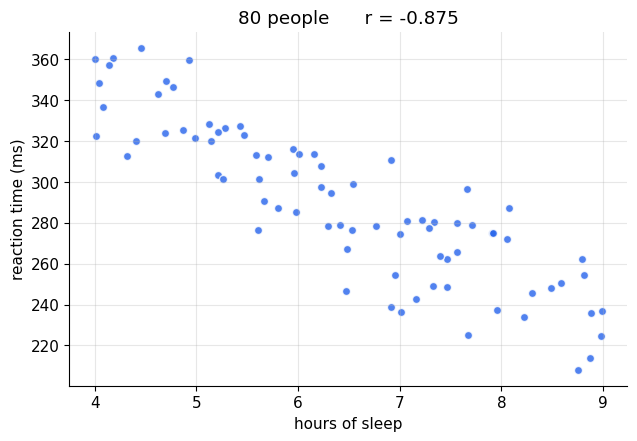

r by hand (formula) = -0.875146
r from np.corrcoef  = -0.875146
r from scipy        = -0.875146
all three agree     = True

r squared           = 0.7659   <- we meet this again in 7.5


In [56]:
# ============================================================
#  Part 7's dataset: sleep (hours) vs reaction time (ms).
#  We build it, so we know the truth every fit below is chasing.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

RNG7 = np.random.default_rng(707)

N7         = 80
TRUE_SLOPE = -22.0     # ms of reaction time per extra hour of sleep
TRUE_INTER = 430.0     # ms at zero hours -- far outside the data (see 7.7)
NOISE_SD   = 18.0

sleep = RNG7.uniform(4.0, 9.0, N7)
rt    = TRUE_INTER + TRUE_SLOPE * sleep + RNG7.normal(0, NOISE_SD, N7)

# ---- Pearson's r, by hand, straight from the formula above ----
dx, dy = sleep - sleep.mean(), rt - rt.mean()
r_hand = (dx * dy).sum() / np.sqrt((dx ** 2).sum() * (dy ** 2).sum())

r_numpy = np.corrcoef(sleep, rt)[0, 1]
r_scipy = stats.pearsonr(sleep, rt).statistic

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.scatter(sleep, rt, s=34, color=C_F, alpha=0.8, edgecolor="white")
ax.set_xlabel("hours of sleep"); ax.set_ylabel("reaction time (ms)")
ax.set_title(f"80 people      r = {r_hand:+.3f}")
plt.show()

print(f"r by hand (formula) = {r_hand:+.6f}")
print(f"r from np.corrcoef  = {r_numpy:+.6f}")
print(f"r from scipy        = {r_scipy:+.6f}")
print(f"all three agree     = {np.allclose([r_hand, r_numpy], r_scipy)}")
print()
print(f"r squared           = {r_hand ** 2:.4f}   <- we meet this again in 7.5")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each dot is one person. The cloud slopes down: people who slept longer tended to react faster (fewer ms). The printed $r$ is negative and large in size, which is that same fact compressed into one number.

Notice how *thick* the cloud is. The relationship is real and it is also loose — knowing someone's sleep narrows their likely reaction time, it does not pin it down.

**The common misread:** treating $|r|$ as "the fraction of people who follow the pattern". It is nothing of the sort — $r$ supports no such reading. Nor is there a threshold above which a correlation becomes "strong" in any absolute sense; that depends entirely on the field and on the decision you are about to make with it.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

$r$ answers exactly one question: **as $x$ rises, does $y$ tend to rise or fall, and how tightly does it do so *in a straight line*?**

- $r = +1$ — every point sits exactly on an upward straight line.
- $r = 0$ — no *straight-line* tendency. Not "no relationship".
- $r = -1$ — every point sits exactly on a downward straight line.

$r$ is unitless, and it is **symmetric**: swapping $x$ and $y$ leaves it unchanged. That symmetry is your first clue that $r$ cannot possibly be telling you which variable causes which — it does not even know which is which.

</div>

### What $r$ cannot see

Any single number summarising two hundred numbers has to throw something away.
Here are four datasets that show, concretely, what gets thrown away.


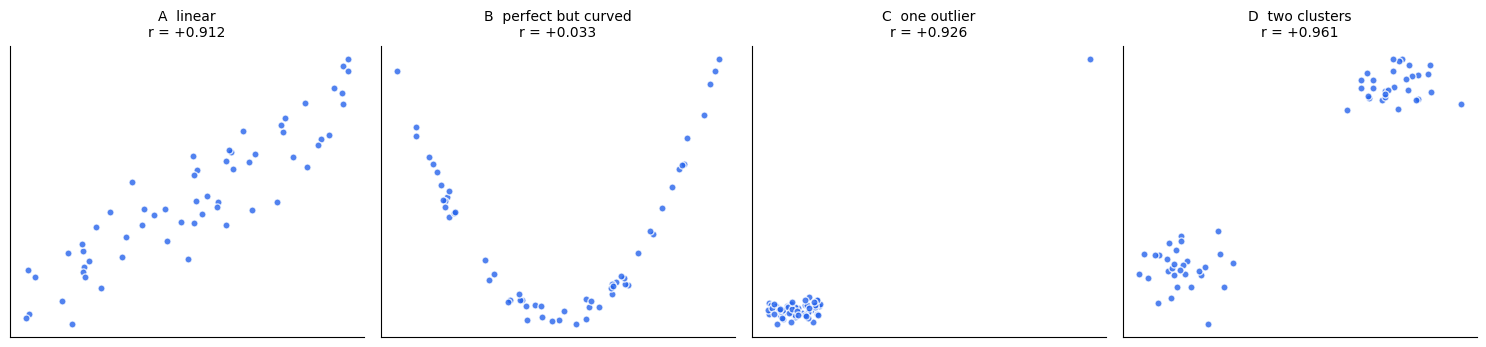

A  linear                r = +0.912
B  perfect but curved    r = +0.033
C  one outlier           r = +0.926
D  two clusters          r = +0.961

C with that one outlier removed    r = +0.164
D inside the left cluster only     r = -0.024
D inside the right cluster only    r = +0.154


In [57]:
# ============================================================
#  Four datasets. Look at the pictures BEFORE reading the r values.
# ============================================================
rng = np.random.default_rng(71)

# A: an honest linear relationship
xa = rng.uniform(0, 10, 60);  ya = 2.0 * xa + rng.normal(0, 3.0, 60)

# B: a near-perfect, deterministic relationship -- but a curved one
xb = rng.uniform(-5, 5, 60);  yb = xb ** 2 + rng.normal(0, 0.8, 60)

# C: no relationship at all, plus ONE far-away point
xc = np.concatenate([rng.uniform(0, 3, 59), [18.0]])
yc = np.concatenate([rng.normal(0, 1, 59), [36.0]])

# D: two separate clusters, no relationship inside either one
xd = np.concatenate([rng.normal(0, 1, 30), rng.normal(9, 1, 30)])
yd = np.concatenate([rng.normal(0, 1, 30), rng.normal(9, 1, 30)])

sets = [("A  linear", xa, ya), ("B  perfect but curved", xb, yb),
        ("C  one outlier", xc, yc), ("D  two clusters", xd, yd)]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (name, x, y) in zip(axes, sets):
    rr = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, s=26, color=C_F, alpha=0.8, edgecolor="white")
    ax.set_title(f"{name}\nr = {rr:+.3f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

for name, x, y in sets:
    print(f"{name:24s} r = {np.corrcoef(x, y)[0, 1]:+.3f}")

print()
print(f"C with that one outlier removed    r = {np.corrcoef(xc[:-1], yc[:-1])[0, 1]:+.3f}")
print(f"D inside the left cluster only     r = {np.corrcoef(xd[:30], yd[:30])[0, 1]:+.3f}")
print(f"D inside the right cluster only    r = {np.corrcoef(xd[30:], yd[30:])[0, 1]:+.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**A** is what people picture when they hear "correlation": a genuine linear trend, faithfully reported by $r$.

**B** is a parabola with almost no noise — knowing $x$ gives you $y$ to within a whisker — yet $r$ is near zero, because the falling half and the rising half cancel. **A small $r$ is not evidence of independence.**

**C** is 59 points with no relationship whatsoever, plus one distant point. The headline $r$ is large; delete that single point and it collapses to the value printed underneath. One row of a spreadsheet moved the result.

**D** has a large $r$, but the two within-cluster correlations printed above are both near zero. The "relationship" is entirely the gap between two groups — which is Simpson's paradox warming up, and Part 8 finishes the job.

**The common misread:** reporting $r$ without ever plotting the scatter. Every failure above is obvious in the picture and invisible in the number. Plot first, correlate second.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**"They are correlated, so one causes the other."** This is the most expensive error in applied statistics, and $r$ itself tells you why it is unjustified: $r(x, y) = r(y, x)$. The number is *symmetric*. It cannot distinguish "sleep improves reaction time" from "fast reactors happen to sleep more", because it holds no information about direction at all.

Four explanations always fit a correlation equally well:

1. $x$ causes $y$.
2. $y$ causes $x$.
3. Some third thing causes both — a **confounder**. Part 8 builds one and watches it produce a strong, entirely spurious correlation.
4. It is noise, and you are seeing it because you looked at many pairs of variables and reported the largest. Also Part 8.

Nothing in this section — and nothing in the regression that follows — changes this. **Fitting a line does not upgrade an association into a cause.** Only the *design* of the study can do that: randomisation, or an argument about mechanism that stands on its own feet.

</div>

---

## 7.2 The line of best fit, derived

We want the straight line $\hat{y} = a + b x$ that fits the cloud best. Before we
can find it we have to say what **best** means, because "best" is a choice, not a
fact.

**The choice.** For each person we have their actual $y_i$ and the line's guess
$a + b x_i$. The gap is the **residual** $e_i = y_i - (a + b x_i)$. We square each
residual and add them up:

$$\mathrm{SSE}(a, b) \;=\; \sum_{i=1}^{n} \bigl(y_i - a - b x_i\bigr)^2$$

Squaring does two jobs: it stops positive and negative gaps cancelling, and it
punishes one big miss more than several small ones. "Best" now means the $a$ and
$b$ that make $\mathrm{SSE}$ as small as possible. This is **least squares**.

**Step 1 — flat in $a$.** At a minimum, nudging $a$ does not change SSE, so the
derivative with respect to $a$ is zero:

$$\frac{\partial \mathrm{SSE}}{\partial a} = \sum_i 2\bigl(y_i - a - b x_i\bigr)(-1) = 0
\quad\Longrightarrow\quad \sum_i y_i - n a - b \sum_i x_i = 0$$

Divide by $n$ and rearrange:

$$\bar{y} = a + b\bar{x} \quad\Longrightarrow\quad \boxed{\,a = \bar{y} - b\bar{x}\,}$$

That is already worth pausing on: **the least-squares line always passes through
$(\bar{x}, \bar{y})$**, the centre of mass of the data. Whatever the slope turns
out to be, the line is pinned to that one point.

**Step 2 — flat in $b$.**

$$\frac{\partial \mathrm{SSE}}{\partial b} = \sum_i 2\bigl(y_i - a - b x_i\bigr)(-x_i) = 0
\quad\Longrightarrow\quad \sum_i x_i\bigl(y_i - a - b x_i\bigr) = 0$$

Substitute $a = \bar{y} - b\bar{x}$ from Step 1:

$$\sum_i x_i\Bigl(y_i - \bar{y} + b\bar{x} - b x_i\Bigr) = 0
\quad\Longrightarrow\quad \sum_i x_i (y_i - \bar{y}) \;=\; b \sum_i x_i (x_i - \bar{x})$$

**Step 3 — the tidy-up.** Those two sums look lopsided, but they are not. For any
list, $\sum_i \bar{x}(y_i - \bar{y}) = \bar{x}\sum_i (y_i - \bar{y}) = 0$, because
deviations from a mean sum to zero. So we may subtract it for free:

$$\sum_i x_i(y_i - \bar{y}) = \sum_i (x_i - \bar{x})(y_i - \bar{y})$$

and by the identical trick $\sum_i x_i(x_i - \bar{x}) = \sum_i (x_i - \bar{x})^2$.
Therefore

$$\boxed{\;b = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sum_i (x_i - \bar{x})^2}
      = \frac{S_{xy}}{S_{xx}}\;}$$

**Step 4 — the same thing said with $r$.** Divide top and bottom by $n-1$: the top
becomes the covariance of $x$ and $y$, the bottom the variance of $x$. A line of
algebra later,

$$b \;=\; r \cdot \frac{s_y}{s_x}$$

Slope and correlation are the *same quantity in different clothes*: $r$ is the
slope you would get if both variables were first rescaled to standard deviation
1. Hold on to this identity — Section 7.8 is nothing but a consequence of it.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**The slope** is "how much $x$ and $y$ move together" divided by "how much $x$ moves on its own". If $x$ barely varies (small $S_{xx}$), the same amount of co-movement implies a steeper slope — and, as Section 7.6 shows, a far less certain one.

**The intercept** is not really a free choice. Once the slope is picked, the intercept is forced: slide the line up or down until it passes through $(\bar{x}, \bar{y})$. Nothing is left to decide.

**And the whole thing rests on a decision, not a discovery.** We *chose* to square the residuals. Choosing absolute values instead gives a different, equally defensible line that all but ignores outliers — which is exactly why least squares is so sensitive to them.

</div>

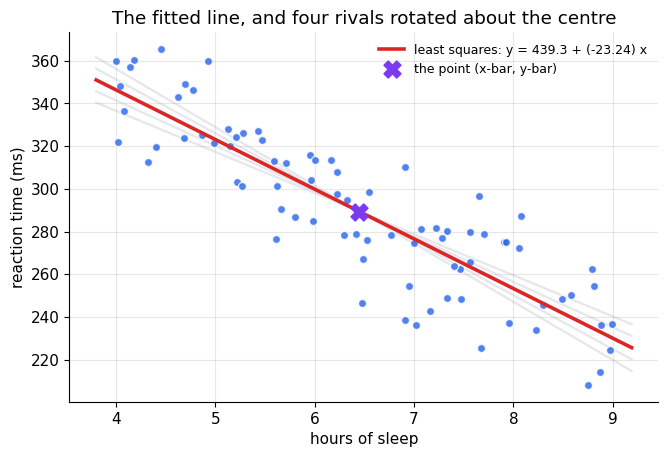

from the derivation :  a =  439.2916   b = -23.2430
from np.polyfit     :  a =  439.2916   b = -23.2430
from  r * sy/sx     :                b = -23.2430
identical?             True and True

dSSE/da condition   :  sum(residuals)   = +4.832e-12   (want 0)
dSSE/db condition   :  sum(x*residuals) = +3.126e-11   (want 0)

SSE at the least-squares fit      =     27266.17
SSE with slope  -27.24           =     29907.86   ( 1.10x worse)
SSE with slope  -25.24           =     27926.59   ( 1.02x worse)
SSE with slope  -21.24           =     27926.59   ( 1.02x worse)
SSE with slope  -19.24           =     29907.86   ( 1.10x worse)

true slope used to build the data  = -22.00
slope estimated from 80 people     = -23.24   (off by -1.24)


In [58]:
# ============================================================
#  The derivation, implemented literally, then checked four ways.
# ============================================================
def fit_line_from_derivation(x, y):
    """Slope and intercept, straight from the boxed formulas in 7.2."""
    xbar, ybar = x.mean(), y.mean()
    Sxy = ((x - xbar) * (y - ybar)).sum()
    Sxx = ((x - xbar) ** 2).sum()
    b = Sxy / Sxx                 # Step 3
    a = ybar - b * xbar           # Step 1
    return a, b

a_hand, b_hand = fit_line_from_derivation(sleep, rt)

# check 1 -- numpy's own least-squares fit
b_np, a_np = np.polyfit(sleep, rt, 1)

# check 2 -- the  b = r * (sy/sx)  identity from Step 4
b_via_r = r_hand * rt.std(ddof=1) / sleep.std(ddof=1)

# check 3 -- both derivative conditions really are zero at (a_hand, b_hand)
resid  = rt - (a_hand + b_hand * sleep)
cond_a = resid.sum()               # dSSE/da = 0  ->  residuals sum to zero
cond_b = (sleep * resid).sum()     # dSSE/db = 0  ->  x . residuals = zero

# check 4 -- is it really the MINIMUM? rotate the line and watch SSE rise.
def sse(a, b):
    return ((rt - a - b * sleep) ** 2).sum()

base = sse(a_hand, b_hand)

fig, ax = plt.subplots(figsize=(7.6, 4.8))
grid = np.linspace(sleep.min() - 0.2, sleep.max() + 0.2, 50)
for db in (-4, -2, 2, 4):
    a_alt = a_hand - db * sleep.mean()        # rotate about (x-bar, y-bar)
    ax.plot(grid, a_alt + (b_hand + db) * grid, color=C_SOFT, lw=1.6, zorder=1)
ax.scatter(sleep, rt, s=34, color=C_F, alpha=0.8, edgecolor="white", zorder=2)
ax.plot(grid, a_hand + b_hand * grid, color=C_SLOPE, lw=2.6, zorder=3,
        label=f"least squares: y = {a_hand:.1f} + ({b_hand:.2f}) x")
ax.scatter([sleep.mean()], [rt.mean()], s=150, marker="X", color=C_EXACT,
           zorder=4, label="the point (x-bar, y-bar)")
ax.set_xlabel("hours of sleep"); ax.set_ylabel("reaction time (ms)")
ax.set_title("The fitted line, and four rivals rotated about the centre")
ax.legend(frameon=False, fontsize=9)
plt.show()

print(f"from the derivation :  a = {a_hand:9.4f}   b = {b_hand:8.4f}")
print(f"from np.polyfit     :  a = {a_np:9.4f}   b = {b_np:8.4f}")
print(f"from  r * sy/sx     :                b = {b_via_r:8.4f}")
print(f"identical?             {np.allclose([a_hand, b_hand], [a_np, b_np])} "
      f"and {np.isclose(b_hand, b_via_r)}")
print()
print(f"dSSE/da condition   :  sum(residuals)   = {cond_a:+.3e}   (want 0)")
print(f"dSSE/db condition   :  sum(x*residuals) = {cond_b:+.3e}   (want 0)")
print()
print(f"SSE at the least-squares fit      = {base:12.2f}")
for db in (-4, -2, 2, 4):
    a_alt = a_hand - db * sleep.mean()
    alt = sse(a_alt, b_hand + db)
    print(f"SSE with slope {b_hand + db:+7.2f}           = {alt:12.2f}"
          f"   ({alt / base:5.2f}x worse)")
print()
print(f"true slope used to build the data  = {TRUE_SLOPE:.2f}")
print(f"slope estimated from 80 people     = {b_hand:.2f}   "
      f"(off by {b_hand - TRUE_SLOPE:+.2f})")


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The formulas we derived by hand and the ones `numpy` uses internally agree to floating-point precision — printed above, together with the third route through $r \cdot s_y/s_x$, which lands on the same slope.

The two derivative conditions come out around $10^{-13}$ rather than exactly zero. That is floating-point roundoff, not a flaw in the algebra: at the true minimum they are exactly zero, and the computer is showing us its own arithmetic error.

The perturbation table settles that this is a **minimum**. Every rotated line — each still passing through $(\bar{x}, \bar{y})$, so Step 1 still holds — has a strictly larger SSE, by the factor printed beside it. We did not merely find a flat spot; we found the bottom.

</div>

## 7.3 Saying what the coefficients mean — carefully

Here is where a correct fit turns into a wrong claim, in one sentence.

The slope has **units**: it is (units of $y$) per (one unit of $x$). Ours is
milliseconds per hour of sleep. Say it out loud, with the units, as a full
sentence, in the form that regression actually licenses:

> **Each additional hour of sleep is *associated with* a change of $b$
> milliseconds in reaction time, among people like the ones we measured.**

Not "causes". Not "leads to". Not "improves by". **Associated with** — because
7.1 established that a line fitted to observational data cannot rule out reverse
causation or a confounder, and drawing the line changed nothing about that.

The other half of the sentence matters just as much: *among people like the ones
we measured*. Our sleep values run from about 4 to 9 hours. The slope is a claim
about that range and no other. Section 7.7 shows what happens when people drop
that clause.


In [59]:
# ============================================================
#  Say it in units, with every number computed rather than typed.
# ============================================================
lo, hi = sleep.min(), sleep.max()

print("THE INTERPRETATION SENTENCE")
print("-" * 68)
print(f"Each additional hour of sleep is ASSOCIATED WITH a change of")
print(f"{b_hand:+.2f} ms in reaction time, among people sleeping between")
print(f"{lo:.1f} and {hi:.1f} hours.")
print("-" * 68)
print()
print("Rescaled, because 'per hour' is not always the useful unit:")
print(f"  per extra hour        : {b_hand:+8.2f} ms")
print(f"  per extra 30 minutes  : {b_hand * 0.5:+8.2f} ms")
print(f"  per extra 2 hours     : {b_hand * 2.0:+8.2f} ms")
print()
print("The intercept, and why it is usually meaningless here:")
print(f"  a = {a_hand:.2f} ms is the prediction at sleep = 0 hours,")
print(f"  which is {lo:.1f} hours below anything we observed. It is a")
print(f"  bookkeeping number that positions the line, not a finding.")
print()
print("Predictions INSIDE the data, which are the honest kind:")
for s in (5.0, 6.5, 8.0):
    print(f"  sleep = {s:.1f} h  ->  predicted reaction time "
          f"= {a_hand + b_hand * s:.1f} ms")


THE INTERPRETATION SENTENCE
--------------------------------------------------------------------
Each additional hour of sleep is ASSOCIATED WITH a change of
-23.24 ms in reaction time, among people sleeping between
4.0 and 9.0 hours.
--------------------------------------------------------------------

Rescaled, because 'per hour' is not always the useful unit:
  per extra hour        :   -23.24 ms
  per extra 30 minutes  :   -11.62 ms
  per extra 2 hours     :   -46.49 ms

The intercept, and why it is usually meaningless here:
  a = 439.29 ms is the prediction at sleep = 0 hours,
  which is 4.0 hours below anything we observed. It is a
  bookkeeping number that positions the line, not a finding.

Predictions INSIDE the data, which are the honest kind:
  sleep = 5.0 h  ->  predicted reaction time = 323.1 ms
  sleep = 6.5 h  ->  predicted reaction time = 288.2 ms
  sleep = 8.0 h  ->  predicted reaction time = 253.3 ms


---

## 7.4 Residuals: the diagnostic that actually matters

A residual is what the line **missed**: $e_i = y_i - \hat{y}_i$. Plotting the
residuals against $x$ is the single most useful thing you can do after fitting a
line, and it is more informative than any goodness-of-fit number.

The reason is blunt. Least squares will hand you a line for **any** data you give
it. It never refuses. It will cheerfully fit a straight line to a circle, and
report the fit statistics without complaint. The residual plot is where the data
gets to answer back.

**What you want to see:** a formless horizontal band around zero. No curve, no
funnel, no clumps. That means the line took the structure and what remains is
noise.

**What you do not want to see:** any *shape at all*. A shape in the residuals is
structure the line failed to capture — and it is still sitting there, inside
every prediction the model makes.


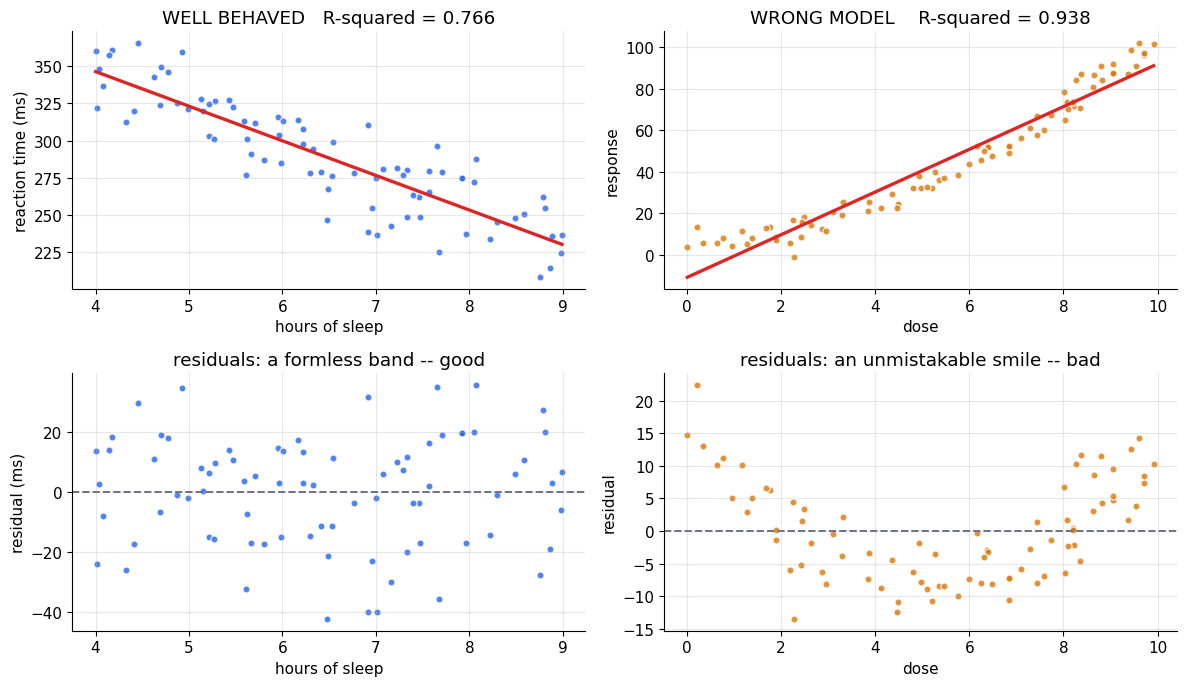

LEFT  (linear data, right model) : R-squared = 0.766
RIGHT (curved data, wrong model) : R-squared = 0.938   <-- HIGHER

The higher R-squared belongs to the WRONG model. A single goodness number
cannot tell you the SHAPE is wrong; the residual plot says it at a glance.

Turning the smile into a number -- correlation of residual with x squared:
  well behaved : +0.016
  wrong model  : +0.195


In [60]:
# ============================================================
#  Same fitting procedure, two datasets. One is a line plus noise.
#  The other is genuinely CURVED -- and we fit a straight line anyway.
# ============================================================
rngc = np.random.default_rng(7411)

# LEFT: our sleep data -- honestly linear.
fit_ok = fit_line_from_derivation(sleep, rt)
res_ok = rt - (fit_ok[0] + fit_ok[1] * sleep)

# RIGHT: dose vs response, genuinely quadratic. A straight line forced on it.
dose = rngc.uniform(0, 10, 80)
resp = 5.0 + 1.5 * dose + 0.85 * dose ** 2 + rngc.normal(0, 4.0, 80)
fit_bad = fit_line_from_derivation(dose, resp)
res_bad = resp - (fit_bad[0] + fit_bad[1] * dose)

def r_squared(y, e):
    return 1 - (e ** 2).sum() / ((y - y.mean()) ** 2).sum()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].scatter(sleep, rt, s=26, color=C_F, alpha=0.8, edgecolor="white")
gg = np.linspace(sleep.min(), sleep.max(), 40)
axes[0, 0].plot(gg, fit_ok[0] + fit_ok[1] * gg, color=C_SLOPE, lw=2.4)
axes[0, 0].set_title(f"WELL BEHAVED   R-squared = {r_squared(rt, res_ok):.3f}")
axes[0, 0].set_xlabel("hours of sleep"); axes[0, 0].set_ylabel("reaction time (ms)")

axes[0, 1].scatter(dose, resp, s=26, color=C_APPROX, alpha=0.8, edgecolor="white")
gd = np.linspace(dose.min(), dose.max(), 40)
axes[0, 1].plot(gd, fit_bad[0] + fit_bad[1] * gd, color=C_SLOPE, lw=2.4)
axes[0, 1].set_title(f"WRONG MODEL    R-squared = {r_squared(resp, res_bad):.3f}")
axes[0, 1].set_xlabel("dose"); axes[0, 1].set_ylabel("response")

axes[1, 0].axhline(0, color=C_GREY, lw=1.4, ls="--")
axes[1, 0].scatter(sleep, res_ok, s=26, color=C_F, alpha=0.8, edgecolor="white")
axes[1, 0].set_title("residuals: a formless band -- good")
axes[1, 0].set_xlabel("hours of sleep"); axes[1, 0].set_ylabel("residual (ms)")

axes[1, 1].axhline(0, color=C_GREY, lw=1.4, ls="--")
axes[1, 1].scatter(dose, res_bad, s=26, color=C_APPROX, alpha=0.8, edgecolor="white")
axes[1, 1].set_title("residuals: an unmistakable smile -- bad")
axes[1, 1].set_xlabel("dose"); axes[1, 1].set_ylabel("residual")

fig.tight_layout(); plt.show()

print(f"LEFT  (linear data, right model) : R-squared = {r_squared(rt, res_ok):.3f}")
print(f"RIGHT (curved data, wrong model) : R-squared = {r_squared(resp, res_bad):.3f}   <-- HIGHER")
print()
print("The higher R-squared belongs to the WRONG model. A single goodness number")
print("cannot tell you the SHAPE is wrong; the residual plot says it at a glance.")
print()
print("Turning the smile into a number -- correlation of residual with x squared:")
print(f"  well behaved : {np.corrcoef(res_ok, sleep ** 2)[0, 1]:+.3f}")
print(f"  wrong model  : {np.corrcoef(res_bad, dose ** 2)[0, 1]:+.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Top row: two fitted lines. Both look plausible at a glance, and the **right-hand one has the higher R-squared** — the values are printed in the panel titles. Rank these two models by that number and you pick the wrong one.

Bottom row: the same two fits seen through their residuals. On the left, a shapeless band — the line took the structure and left noise behind. On the right, a clear smile: the line sits too high in the middle and too low at both ends, over and over, in a pattern no noise process would produce. The printed correlation between residual and $x^2$ turns the smile into a number.

**The common misread:** "the residuals are small, so the fit is fine". Size is not the issue — *pattern* is. Residuals that are small but systematically curved mean the model is wrong in a way that gets steadily worse the further out you predict.

</div>

---

## 7.5 $R^2$, and why it is a weaker number than it looks

$R^2$ compares your line against the laziest possible model: predicting
$\bar{y}$ for everybody and ignoring $x$ entirely.

- **Total variation**, if you ignore $x$: $\;\mathrm{SST} = \sum_i (y_i - \bar{y})^2$
- **What the line leaves behind**: $\;\mathrm{SSE} = \sum_i (y_i - \hat{y}_i)^2$

$$R^2 \;=\; 1 - \frac{\mathrm{SSE}}{\mathrm{SST}}$$

If the line explains nothing, $\mathrm{SSE} = \mathrm{SST}$ and $R^2 = 0$. If it
passes through every point, $\mathrm{SSE} = 0$ and $R^2 = 1$.

For a **simple** regression — one predictor — there is a pleasing identity:
$R^2 = r^2$. Same number. We will confirm it numerically rather than assert it.

Then we will break it. $R^2$ has a defect that makes it dangerous for choosing
between models: **it can never go down when you add a predictor**, however
useless that predictor is. Least squares can always set a junk column's
coefficient to zero, so the fit cannot get worse — and in practice it does
slightly *better* than zero by chasing the noise. So $R^2$ rises. Every time.


In [61]:
# ============================================================
#  R-squared by hand, three routes, on the sleep data.
# ============================================================
y_hat = a_hand + b_hand * sleep
SSE   = ((rt - y_hat) ** 2).sum()
SST   = ((rt - rt.mean()) ** 2).sum()
SSR   = ((y_hat - rt.mean()) ** 2).sum()      # the part the line explains

R2_hand = 1 - SSE / SST
R2_frac = SSR / SST
R2_r2   = r_hand ** 2

print(f"SST  (total variation)      = {SST:12.2f}")
print(f"SSR  (explained by line)    = {SSR:12.2f}")
print(f"SSE  (left over)            = {SSE:12.2f}")
print(f"SSR + SSE                   = {SSR + SSE:12.2f}   (equals SST? "
      f"{np.isclose(SSR + SSE, SST)})")
print()
print(f"R-squared = 1 - SSE/SST     = {R2_hand:.6f}")
print(f"R-squared = SSR/SST         = {R2_frac:.6f}")
print(f"R-squared = r * r           = {R2_r2:.6f}")
print(f"all three agree             = {np.allclose([R2_hand, R2_frac], R2_r2)}")
print()
print(f"So the line accounts for {100 * R2_hand:.1f}% of the variation in reaction")
print(f"time, and {100 * (1 - R2_hand):.1f}% is variation between people that sleep")
print("does not touch at all.")


SST  (total variation)      =    116462.45
SSR  (explained by line)    =     89196.27
SSE  (left over)            =     27266.17
SSR + SSE                   =    116462.45   (equals SST? True)

R-squared = 1 - SSE/SST     = 0.765880
R-squared = SSR/SST         = 0.765880
R-squared = r * r           = 0.765880
all three agree             = True

So the line accounts for 76.6% of the variation in reaction
time, and 23.4% is variation between people that sleep
does not touch at all.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Three independent routes to $R^2$ — one minus the leftover fraction, the explained fraction directly, and simply squaring $r$ — return the same value to six decimal places. The identity $R^2 = r^2$ for a single predictor is confirmed, not quoted.

The decomposition $\mathrm{SST} = \mathrm{SSR} + \mathrm{SSE}$ also checks out exactly, and that is no coincidence: it holds precisely because the residuals are orthogonal to the fitted values, which is what the condition $\sum_i x_i e_i = 0$ from Section 7.2 was saying all along.

</div>

/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/754793959.py:11: RuntimeWarning: divide by zero encountered in matmul
  e = y - X @ beta
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/754793959.py:11: RuntimeWarning: overflow encountered in matmul
  e = y - X @ beta
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/754793959.py:11: RuntimeWarning: invalid value encountered in matmul
  e = y - X @ beta


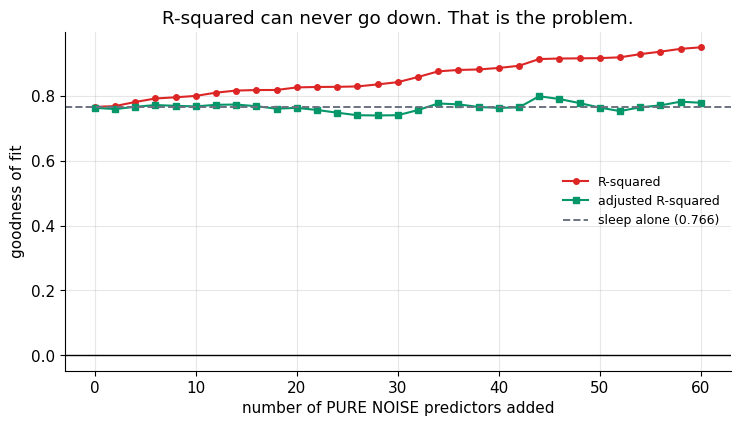

predictors: sleep only            R-squared = 0.7659
predictors: sleep + 10 noise        R-squared = 0.7998      adjusted = +0.7674
predictors: sleep + 20 noise        R-squared = 0.8259      adjusted = +0.7629
predictors: sleep + 40 noise        R-squared = 0.8859      adjusted = +0.7629
predictors: sleep + 60 noise        R-squared = 0.9495      adjusted = +0.7785

never once decreased? True

With 60 noise columns against 80 rows the fit is nearly perfect on THIS
data and worth nothing on any other. Adjusted R-squared, which charges
rent for every predictor, goes NEGATIVE -- the only one of the two telling
the truth. Part 9 replaces both with the real answer: held-out data.


In [62]:
# ============================================================
#  Now break it. Add columns of PURE NOISE and watch R-squared climb.
#  The noise is generated with no reference to rt whatsoever. It cannot
#  contain information about reaction time. R-squared rises anyway.
# ============================================================
rngn = np.random.default_rng(7555)

def r2_multi(X, y):
    """R-squared of the least-squares fit of y on design matrix X."""
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    e = y - X @ beta
    return 1 - (e ** 2).sum() / ((y - y.mean()) ** 2).sum()

MAX_JUNK = 60                                       # against N7 = 80 rows
junk     = rngn.normal(0, 1, size=(N7, MAX_JUNK))   # nothing to do with rt

ks, r2s, adj = [], [], []
for k in range(0, MAX_JUNK + 1, 2):
    X = np.column_stack([np.ones(N7), sleep, junk[:, :k]])
    v = r2_multi(X, rt)
    p = X.shape[1] - 1                              # predictors, minus intercept
    ks.append(k); r2s.append(v)
    adj.append(1 - (1 - v) * (N7 - 1) / (N7 - p - 1))

fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.plot(ks, r2s, "-o", ms=4, color=C_SLOPE, label="R-squared")
ax.plot(ks, adj, "-s", ms=4, color=C_AREA, label="adjusted R-squared")
ax.axhline(R2_hand, color=C_GREY, ls="--", lw=1.4,
           label=f"sleep alone ({R2_hand:.3f})")
ax.axhline(0, color="black", lw=1.0)
ax.set_xlabel("number of PURE NOISE predictors added")
ax.set_ylabel("goodness of fit")
ax.set_title("R-squared can never go down. That is the problem.")
ax.legend(frameon=False, fontsize=9)
plt.show()

print(f"predictors: sleep only            R-squared = {r2s[0]:.4f}")
for k in (10, 20, 40, 60):
    i = ks.index(k)
    print(f"predictors: sleep + {k:2d} noise        R-squared = {r2s[i]:.4f}"
          f"      adjusted = {adj[i]:+.4f}")
print()
print(f"never once decreased? "
      f"{all(v >= u - 1e-12 for u, v in zip(r2s, r2s[1:]))}")
print()
print("With 60 noise columns against 80 rows the fit is nearly perfect on THIS")
print("data and worth nothing on any other. Adjusted R-squared, which charges")
print("rent for every predictor, goes NEGATIVE -- the only one of the two telling")
print("the truth. Part 9 replaces both with the real answer: held-out data.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The red curve is $R^2$ as columns of *pure random noise* — generated with no reference whatsoever to reaction time — are appended to the model. It climbs monotonically toward 1, and the printed check confirms it never decreases even once.

The green curve is **adjusted $R^2$**, which subtracts a penalty per predictor. It falls, and eventually goes negative — its way of saying the model is now worse than predicting the mean.

**The common misread:** comparing two models by $R^2$ and keeping the higher one. If the models have different numbers of predictors, that comparison is rigged, and rigged in favour of the more complicated model *every single time*. This is overfitting, arriving early and in its simplest possible costume.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**"$R^2 = 0.9$, so the model is good."** $R^2$ answers one narrow question — how much of the variance *in this particular dataset* the fit accounts for — and it is routinely read as an answer to a much larger one.

Four ways a high $R^2$ misleads, every one of them demonstrated above:

1. **The wrong functional form can score higher.** In 7.4 the curved data fitted with a straight line had the *larger* $R^2$ of the two panels.
2. **Noise inflates it.** Sixty junk columns pushed it toward 1.
3. **It says nothing about causation.** A confounder produces a high $R^2$ just as readily as a genuine mechanism does.
4. **A low $R^2$ is not automatically bad.** Where outcomes are genuinely noisy, $R^2 = 0.05$ with a well-estimated, correctly-signed slope can be an important finding.

$R^2$ describes a fit; it does not deliver a verdict on a model. The verdict comes from the residual plot, from the slope's confidence interval, and above all from performance on data the model has never seen.

</div>

---

## 7.6 An error bar on the slope

We estimated a slope. Take a different 80 people and you would get a different
number. The slope is a **sample statistic**, exactly like the sample mean in
Part 3, and reporting it bare is the same omission.

**Route 1 — the formula.** Under the usual regression assumptions,

$$\mathrm{SE}(b) = \frac{s_e}{\sqrt{S_{xx}}}, \qquad
  s_e = \sqrt{\frac{\mathrm{SSE}}{n-2}}$$

and a 95% interval is $b \pm t_{0.975,\,n-2}\cdot \mathrm{SE}(b)$. The $n-2$
appears because two numbers ($a$ and $b$) were estimated from the data before the
residuals were computed.

Read the formula rather than just using it: the slope is well determined when the
residuals are small (small $s_e$) **and** when $x$ is spread out (large
$S_{xx}$). Measuring people across 4–9 hours of sleep pins the slope down far
better than measuring the same number of people who all slept 6.5 hours.

**Route 2 — the bootstrap.** Resample the $(x, y)$ **pairs** with replacement,
refit, repeat thousands of times, and take the middle 95% of the resulting
slopes. This assumes almost nothing. If the two routes agree, the formula's
assumptions are doing no harm here.


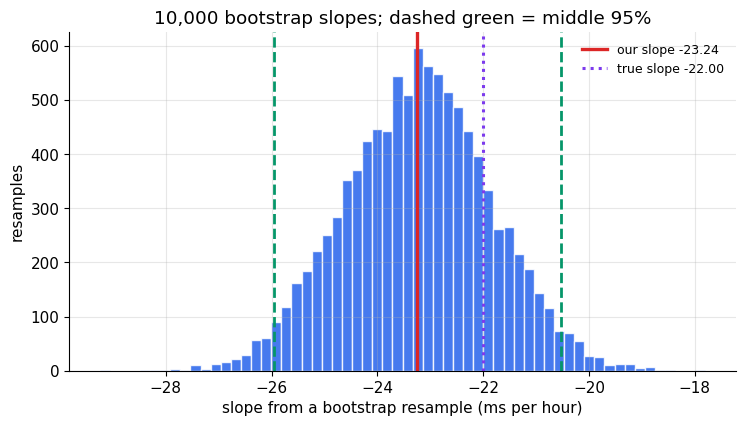

slope                     b  =  -23.243 ms per hour
residual sd              s_e =   18.697 ms
spread of x              Sxx =  165.105
standard error         SE(b) =    1.455

95% CI, formula   : [-26.140, -20.346]   width 5.794
95% CI, bootstrap : [-25.945, -20.528]   width 5.416
true slope inside both? formula=True, bootstrap=True

t = b / SE(b)   =  -15.974   on 78 degrees of freedom
p (slope = 0)   = 2.623e-26
is 0 inside the 95% interval? False

Zero is far outside the interval, so the slope IS distinguishable from
zero: there is a relationship. Note carefully what that does NOT say --
nothing about the direction of causation, and nothing about whether a
change of 23 ms per hour matters to anyone. That is effect size.


In [63]:
# ============================================================
#  The slope's uncertainty, by formula and by bootstrap.
# ============================================================
n_reg  = N7
dof    = n_reg - 2
Sxx    = ((sleep - sleep.mean()) ** 2).sum()
s_e    = np.sqrt(SSE / dof)
se_b   = s_e / np.sqrt(Sxx)

t_crit     = stats.t.ppf(0.975, dof)
ci_formula = (b_hand - t_crit * se_b, b_hand + t_crit * se_b)

t_stat  = b_hand / se_b
p_slope = 2 * stats.t.sf(abs(t_stat), dof)

# ---- bootstrap: resample PAIRS, refit, 10,000 times ----
rngb = np.random.default_rng(7666)
B    = 10_000
boot = np.empty(B)
for i in range(B):
    idx     = rngb.integers(0, n_reg, n_reg)
    boot[i] = fit_line_from_derivation(sleep[idx], rt[idx])[1]
ci_boot = np.percentile(boot, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.hist(boot, bins=60, color=C_F, alpha=0.85, edgecolor="white")
ax.axvline(b_hand, color=C_SLOPE, lw=2.4, label=f"our slope {b_hand:.2f}")
ax.axvline(TRUE_SLOPE, color=C_EXACT, lw=2.2, ls=":",
           label=f"true slope {TRUE_SLOPE:.2f}")
for v in ci_boot:
    ax.axvline(v, color=C_AREA, lw=2.0, ls="--")
ax.set_xlabel("slope from a bootstrap resample (ms per hour)")
ax.set_ylabel("resamples")
ax.set_title(f"{B:,} bootstrap slopes; dashed green = middle 95%")
ax.legend(frameon=False, fontsize=9)
plt.show()

print(f"slope                     b  = {b_hand:8.3f} ms per hour")
print(f"residual sd              s_e = {s_e:8.3f} ms")
print(f"spread of x              Sxx = {Sxx:8.3f}")
print(f"standard error         SE(b) = {se_b:8.3f}")
print()
print(f"95% CI, formula   : [{ci_formula[0]:7.3f}, {ci_formula[1]:7.3f}]"
      f"   width {ci_formula[1] - ci_formula[0]:.3f}")
print(f"95% CI, bootstrap : [{ci_boot[0]:7.3f}, {ci_boot[1]:7.3f}]"
      f"   width {ci_boot[1] - ci_boot[0]:.3f}")
print(f"true slope inside both? formula={ci_formula[0] <= TRUE_SLOPE <= ci_formula[1]}, "
      f"bootstrap={ci_boot[0] <= TRUE_SLOPE <= ci_boot[1]}")
print()
print(f"t = b / SE(b)   = {t_stat:8.3f}   on {dof} degrees of freedom")
print(f"p (slope = 0)   = {p_slope:.3e}")
print(f"is 0 inside the 95% interval? {ci_formula[0] <= 0 <= ci_formula[1]}")
print()
print("Zero is far outside the interval, so the slope IS distinguishable from")
print("zero: there is a relationship. Note carefully what that does NOT say --")
print("nothing about the direction of causation, and nothing about whether a")
print(f"change of {abs(b_hand):.0f} ms per hour matters to anyone. That is effect size.")


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Two routes with almost nothing in common — one leaning on $t$-distribution theory and an assumption of well-behaved residuals, the other on nothing but resampling the data we already have — produce intervals that agree closely, as the printed widths show. When a formula and a simulation agree like that, the formula's assumptions are not being strained here.

The interval also contains the **true slope we used to generate the data**. That is the check that is impossible in real work, and the reason this notebook simulates its populations.

The bootstrap distribution is close to symmetric and bell-shaped — the Central Limit Theorem from Part 3 turning up again, now applied to a regression slope rather than a mean. That is *why* the $t$ formula works at all.

</div>

---

## 7.7 Extrapolation: the line does not know where the data stopped

A fitted line is defined for every real number. Your data is not. `numpy` will
compute $a + bx$ at $x = 1000$ without hesitation, and nothing in the output will
mark that number as fiction.

To demonstrate the failure we need a case where we know the truth *outside* the
observed range — so we build one. The genuine relationship is **curved and
flattening**: reaction time improves with sleep, with diminishing returns, and
cannot fall below a physiological floor. We observe a narrow window of it, fit a
straight line inside that window (where a line is an excellent approximation),
and then walk outward.


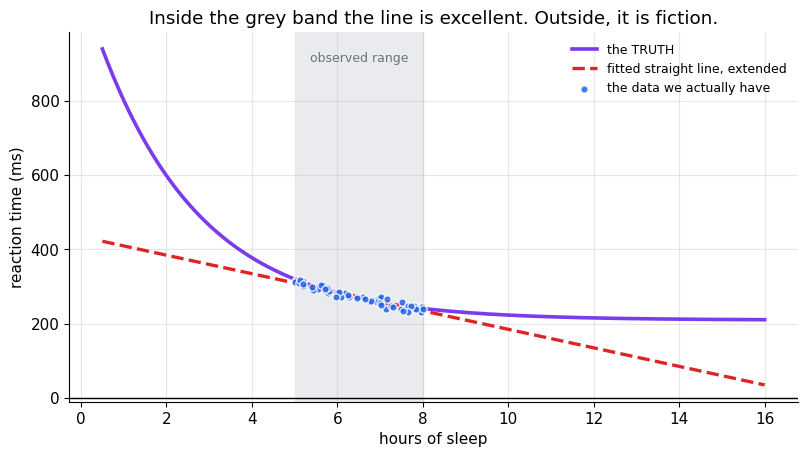

fitted using only 5.0-8.0 h :  y = 434.5 + (-24.93) x
R-squared inside that window   :  0.922

  sleep  outside by      TRUTH   LINE SAYS      ERROR    % off
--------------------------------------------------------------
    6.5         0.0      268.7       272.5       +3.8    +1.4%
    8.0         0.0      241.3       235.1       -6.2    -2.6%
    9.0         1.0      230.5       210.1      -20.4    -8.9%
   10.0         2.0      223.5       185.2      -38.3   -17.1%
   12.0         4.0      215.8       135.3      -80.5   -37.3%
   14.0         6.0      212.5        85.5     -127.0   -59.8%
   16.0         8.0      211.1        35.6     -175.5   -83.1%

The line crosses ZERO reaction time at 17.4 hours of sleep,
and predicts 35.6 ms at 16 hours -- a negative duration.

Nothing in the fit warned us. The R-squared printed above was computed
entirely inside the grey band and is completely silent about 14 hours.


In [64]:
# ============================================================
#  Truth: a decaying curve with a floor. Observation: a narrow window.
#  Model: a straight line, fitted honestly, extrapolated recklessly.
# ============================================================
rnge = np.random.default_rng(7777)

def truth(s):
    """True mean reaction time (ms) at s hours of sleep: floor + decaying excess."""
    return 210.0 + 900.0 * np.exp(-0.42 * s)

OBS_LO, OBS_HI = 5.0, 8.0
s_obs = rnge.uniform(OBS_LO, OBS_HI, 60)
y_obs = truth(s_obs) + rnge.normal(0, 8.0, 60)

a_e, b_e = fit_line_from_derivation(s_obs, y_obs)
r2_inside = 1 - ((y_obs - (a_e + b_e * s_obs)) ** 2).sum() / \
                ((y_obs - y_obs.mean()) ** 2).sum()

grid_all = np.linspace(0.5, 16, 300)
fig, ax = plt.subplots(figsize=(9.4, 4.8))
ax.axvspan(OBS_LO, OBS_HI, color=C_SOFT, alpha=0.8, zorder=0)
ax.plot(grid_all, truth(grid_all), color=C_EXACT, lw=2.6, label="the TRUTH")
ax.plot(grid_all, a_e + b_e * grid_all, color=C_SLOPE, lw=2.4, ls="--",
        label="fitted straight line, extended")
ax.scatter(s_obs, y_obs, s=28, color=C_F, alpha=0.85, edgecolor="white",
           zorder=3, label="the data we actually have")
ax.axhline(0, color="black", lw=1.0)
ax.text((OBS_LO + OBS_HI) / 2, ax.get_ylim()[1] * 0.92, "observed range",
        ha="center", fontsize=9, color=C_GREY)
ax.set_xlabel("hours of sleep"); ax.set_ylabel("reaction time (ms)")
ax.set_title("Inside the grey band the line is excellent. Outside, it is fiction.")
ax.legend(frameon=False, fontsize=9)
plt.show()

print(f"fitted using only {OBS_LO}-{OBS_HI} h :  y = {a_e:.1f} + ({b_e:.2f}) x")
print(f"R-squared inside that window   :  {r2_inside:.3f}")
print()
print(f"{'sleep':>7} {'outside by':>11} {'TRUTH':>10} {'LINE SAYS':>11} "
      f"{'ERROR':>10} {'% off':>8}")
print("-" * 62)
for s in (6.5, 8.0, 9.0, 10.0, 12.0, 14.0, 16.0):
    t_, p_ = truth(s), a_e + b_e * s
    dist = 0.0 if OBS_LO <= s <= OBS_HI else min(abs(s - OBS_LO), abs(s - OBS_HI))
    print(f"{s:7.1f} {dist:11.1f} {t_:10.1f} {p_:11.1f} {p_ - t_:+10.1f} "
          f"{100 * (p_ - t_) / t_:+7.1f}%")
print()
zero_at = -a_e / b_e
print(f"The line crosses ZERO reaction time at {zero_at:.1f} hours of sleep,")
print(f"and predicts {a_e + b_e * 16:.1f} ms at 16 hours -- a negative duration.")
print()
print("Nothing in the fit warned us. The R-squared printed above was computed")
print("entirely inside the grey band and is completely silent about 14 hours.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Inside the grey band the dashed line and the purple truth sit almost on top of each other — over a short stretch a smooth curve *is* nearly straight, which is exactly why the fit looks so convincing.

Outside the band they separate, and the printed table shows the error growing with distance: small just past the edge, then large, and eventually the line predicts a **negative reaction time**, at the sleep value printed beneath. The truth, meanwhile, is flattening toward its floor.

**The common misread:** believing the extrapolation is safe because the $R^2$ was high. That $R^2$ was computed entirely inside the grey band. It measures how well the line describes the data we have, and carries no information at all about a region where we have none. A model can only be trusted over the range it was fitted on — a sentence that is about to become the entire subject of Part 9.

</div>

---

## 7.8 Regression to the mean — the effect that fools everyone

This is where the word "regression" comes from, and it is the most misdiagnosed
phenomenon in applied statistics. It has fooled sports commentators, school
inspectors, doctors, and flight instructors — the last of these is a famous case
we are about to reproduce.

**The setup.** Every measurement is *ability plus luck*:

$$\text{observed} = \text{true ability} + \text{noise}$$

Someone who scored extremely well probably has high ability **and** got lucky,
because both had to line up to reach an extreme. Measure them again: the ability
is still there, but the luck is redrawn, and on average the fresh draw is
smaller. So they score worse.

They did not decline. Nothing happened to them. **The extremes of any noisy
measurement move toward the middle on remeasurement, always, with no cause
required.**

**The formula already told us.** From Step 4 of Section 7.2, $b = r \cdot s_y/s_x$.
If two measurements have the same spread, $s_y = s_x$, so the slope of the second
on the first is exactly $r$ — and $r < 1$ whenever there is any noise at all. A
slope below 1 *is* regression to the mean. It is not an additional effect; it is
the same algebra wearing a different hat.


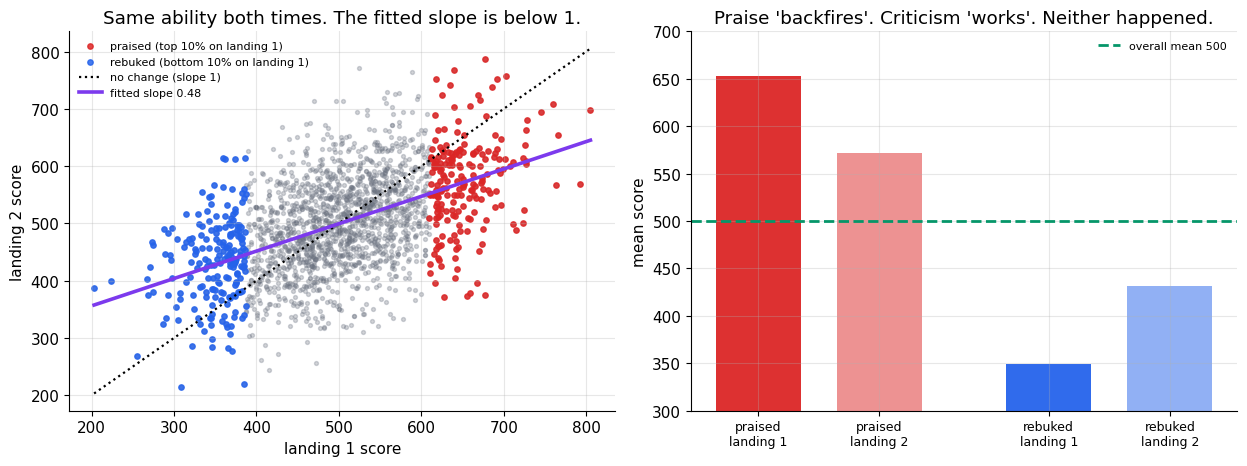

correlation between the two landings   r = 0.486
slope of landing 2 on landing 1        b = 0.478
r * (sd2 / sd1)                          = 0.478   <- the same number
slope below 1?                           True

TOP 10% after landing 1 (these pilots were PRAISED):
   landing 1 mean =   652.8
   landing 2 mean =   571.7   (-81.1)   <- they got WORSE
BOTTOM 10% after landing 1 (these pilots were REBUKED):
   landing 1 mean =   349.3
   landing 2 mean =   431.7   (+82.4)   <- they got BETTER

True ability of the praised group  = 575.5
True ability of the rebuked group  = 425.4
Ability was FIXED in the code above. No praise, no criticism, no training
and no learning happened at all. An instructor who concludes 'criticism
works, praise backfires' has drawn a causal conclusion from arithmetic.


In [65]:
# ============================================================
#  2,000 trainee pilots. Two landings each. Ability NEVER changes.
#  Any apparent improvement or decline is manufactured entirely by noise.
# ============================================================
rngr = np.random.default_rng(7888)
M    = 2000

ability = rngr.normal(500, 60, M)             # fixed; identical for both landings
land1   = ability + rngr.normal(0, 60, M)
land2   = ability + rngr.normal(0, 60, M)     # SAME ability, fresh luck

r_12       = np.corrcoef(land1, land2)[0, 1]
a_rt, b_rt = fit_line_from_derivation(land1, land2)

top    = land1 >= np.percentile(land1, 90)    # praised after landing 1
bottom = land1 <= np.percentile(land1, 10)    # shouted at after landing 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.8))

ax1.scatter(land1, land2, s=8, color=C_GREY, alpha=0.3)
ax1.scatter(land1[top], land2[top], s=15, color=C_SLOPE, alpha=0.85,
            label="praised (top 10% on landing 1)")
ax1.scatter(land1[bottom], land2[bottom], s=15, color=C_F, alpha=0.85,
            label="rebuked (bottom 10% on landing 1)")
gl = np.linspace(land1.min(), land1.max(), 40)
ax1.plot(gl, gl, color="black", lw=1.6, ls=":", label="no change (slope 1)")
ax1.plot(gl, a_rt + b_rt * gl, color=C_EXACT, lw=2.6,
         label=f"fitted slope {b_rt:.2f}")
ax1.set_xlabel("landing 1 score"); ax1.set_ylabel("landing 2 score")
ax1.set_title("Same ability both times. The fitted slope is below 1.")
ax1.legend(frameon=False, fontsize=8)

ax2.bar([0.0], [land1[top].mean()], width=0.7, color=C_SLOPE, alpha=0.95)
ax2.bar([1.0], [land2[top].mean()], width=0.7, color=C_SLOPE, alpha=0.5)
ax2.bar([2.4], [land1[bottom].mean()], width=0.7, color=C_F, alpha=0.95)
ax2.bar([3.4], [land2[bottom].mean()], width=0.7, color=C_F, alpha=0.5)
ax2.axhline(ability.mean(), color=C_AREA, lw=2.0, ls="--",
            label=f"overall mean {ability.mean():.0f}")
ax2.set_xticks([0.0, 1.0, 2.4, 3.4])
ax2.set_xticklabels(["praised\nlanding 1", "praised\nlanding 2",
                     "rebuked\nlanding 1", "rebuked\nlanding 2"], fontsize=9)
ax2.set_ylabel("mean score"); ax2.set_ylim(300, 700)
ax2.set_title("Praise 'backfires'. Criticism 'works'. Neither happened.")
ax2.legend(frameon=False, fontsize=8)

fig.tight_layout(); plt.show()

print(f"correlation between the two landings   r = {r_12:.3f}")
print(f"slope of landing 2 on landing 1        b = {b_rt:.3f}")
print(f"r * (sd2 / sd1)                          = "
      f"{r_12 * land2.std(ddof=1) / land1.std(ddof=1):.3f}   <- the same number")
print(f"slope below 1?                           {b_rt < 1}")
print()
print("TOP 10% after landing 1 (these pilots were PRAISED):")
print(f"   landing 1 mean = {land1[top].mean():7.1f}")
print(f"   landing 2 mean = {land2[top].mean():7.1f}   "
      f"({land2[top].mean() - land1[top].mean():+.1f})   <- they got WORSE")
print("BOTTOM 10% after landing 1 (these pilots were REBUKED):")
print(f"   landing 1 mean = {land1[bottom].mean():7.1f}")
print(f"   landing 2 mean = {land2[bottom].mean():7.1f}   "
      f"({land2[bottom].mean() - land1[bottom].mean():+.1f})   <- they got BETTER")
print()
print(f"True ability of the praised group  = {ability[top].mean():.1f}")
print(f"True ability of the rebuked group  = {ability[bottom].mean():.1f}")
print("Ability was FIXED in the code above. No praise, no criticism, no training")
print("and no learning happened at all. An instructor who concludes 'criticism")
print("works, praise backfires' has drawn a causal conclusion from arithmetic.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: landing 2 against landing 1, for pilots whose ability never changed. The dotted black line is where points would fall if scores simply repeated. The fitted purple line is visibly **shallower**, and its slope — printed above, and confirmed equal to $r \cdot s_2/s_1$ exactly as Section 7.2 predicted — is below 1.

Right: the two extreme groups, before and after. The praised group's mean falls; the rebuked group's mean rises. Both move toward the overall mean, by the amounts printed. Their *true abilities*, also printed, did not budge — there was nothing to budge, since ability was held fixed by construction.

**The common misread:** naming a cause for the movement. Any intervention applied to a group *selected for being extreme* will appear to work if the group was at the bad end, and appear to backfire if it was at the good end. This is why trials need a control group selected the same way: without one, regression to the mean is indistinguishable from a treatment effect.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

**A linear regression is a one-layer network with no activation function**, and least squares is mean-squared-error loss. The normal equations we derived in 7.2 are the closed-form solution you get for free when the model is linear — and gradient descent exists because for everything else there is no such formula.

Four things from this part transfer directly:

- **$R^2$ rising with junk predictors is overfitting in miniature.** Sixty noise columns took the fit toward 1 on the training data and would destroy it everywhere else. Every capacity-versus-generalisation argument in deep learning is that plot, scaled up.
- **Residual plots are error analysis.** Plotting a model's errors against inputs, against predicted value, against group membership is how you find the structure it missed — and it works identically for a transformer.
- **Extrapolation failure is distribution shift.** Section 7.7's line was excellent on its fitted range and produced negative durations outside it. A model deployed on inputs unlike its training data is doing exactly that, usually with more confidence and less visibly.
- **Regression to the mean has a specific ML form.** Pick the best of many validation scores and its test score will be worse, reliably, for precisely the reason the praised pilots landed worse. Part 8 gives that trap a name; Part 9 gives it a procedure.

</div>

---

### What Part 7 established

- **$r$** measures straight-line co-movement, is symmetric, and is blind to
  curves, outliers and clusters. Always plot.
- **Least squares was *derived*, not quoted**: setting both partial derivatives of
  $\sum (y_i - a - bx_i)^2$ to zero gives $b = S_{xy}/S_{xx}$ and
  $a = \bar{y} - b\bar{x}$, verified against `numpy` to floating-point precision.
- **Coefficients are read in units, with "associated with"**, and only over the
  range of $x$ you actually observed.
- **Residual plots beat $R^2$.** The wrong model scored the higher $R^2$; only the
  residuals gave it away.
- **$R^2$ never decreases** when predictors are added, even pure noise ones.
- **The slope needs an interval**, and formula and bootstrap agreed on it.
- **Extrapolation fails silently**, and **regression to the mean** manufactures
  effects out of nothing at all.

Look at the shape of that list. Most of it is about ways a perfectly correct
computation supports an incorrect conclusion. That is not a quirk of regression —
it is the general condition, and it is the whole of Part 8.

**Next → Part 8**, where we build the failures deliberately. Test forty things
that are all noise and count the "discoveries". Peek at a p-value until it dips
below 0.05. Construct a dataset whose trend reverses when you account for a
group. Every trap demonstrated by construction, with the false-positive rate
measured before and after the fix.

---


---

# 8️⃣ The traps: multiple comparisons, p-hacking, Simpson's paradox

<div style="background: linear-gradient(135deg, #42275a 0%, #734b6d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### Every method in this notebook is correct. That is the problem.

The t-test in Part 6 is correct. The confidence interval in Part 4 is correct.
The regression in Part 7 is correct. Not one of them will stop you from reaching
a confidently wrong conclusion, because none of them can see **how many
questions you asked before you kept this one**.

That information is not in the data. It is in your history. And every trap in
this part is a version of the same sin: a procedure that would be valid if run
once is run many times, and only the winner is reported.


</div>

This part is the notebook's conscience, and it is built on one rule: **every trap
is constructed from data with no effect in it**, so that any "discovery" is
provably false. Then we measure how often the false discovery happens, apply the
standard fix, and measure again.

You will see, with printed numbers:

- forty pure-noise variables producing "significant" results, repeatedly;
- a p-value driven below 0.05 on noise, deliberately, and the number of attempts
  it took;
- a test that rejects far more than 5% of the time simply because someone
  watched it run;
- a dataset whose trend **reverses sign** when a group is accounted for;
- selection effects manufacturing correlations out of independent variables.

None of this requires dishonesty. Most of it happens to careful people who have
never falsified anything in their lives — which is exactly why you have to know
the shapes by sight.


## 8.1 Multiple comparisons: the 5% was per test, not per study

$\alpha = 0.05$ is a promise about **one** test: if the null hypothesis is true,
you will wrongly reject it about 5% of the time. That promise is kept. It is just
much weaker than people hear.

Run 40 independent tests, all null. The chance that *at least one* comes out
"significant" is

$$1 - (1 - 0.05)^{40} \approx 0.87$$

Not 5%. Eighty-seven percent. A study that measures forty things and reports the
one that reached significance has done nothing but roll dice until one came up
six, and then reported the six.

Let us build exactly that study, out of nothing.


fast p-values agree with scipy?
  correlations : True
  Welch t-test : True



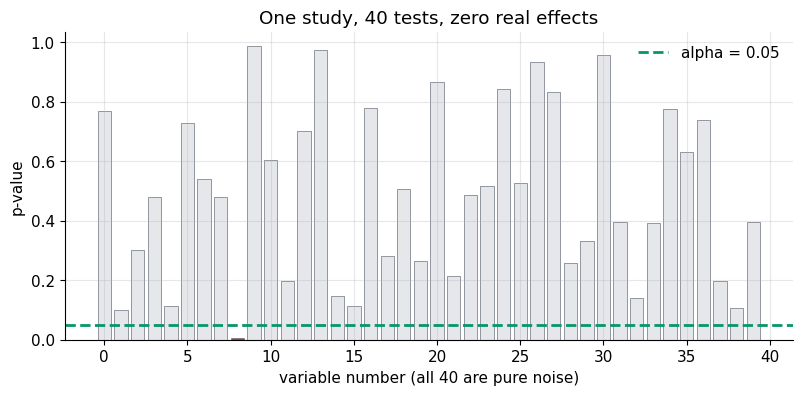

variables tested                 : 40
real effects present             : 0
'significant' at p < 0.05       : 1
which ones                       : [np.int64(8)]

  variable  8:  p = 0.0048   <- entirely a false positive

smallest p-value in the study    : 0.0048

A paper reporting only the winning variable would be reporting a p-value
that is correct for a single test and meaningless for this study.


In [66]:
# ============================================================
#  A study with 40 candidate variables and an outcome.
#  EVERY variable is pure noise. The outcome is pure noise.
#  There is nothing to find. We go looking anyway.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

RNG8 = np.random.default_rng(808)

N_SUBJ = 50      # people in the study
N_VARS = 40      # things measured about each of them
ALPHA  = 0.05

# We are about to run millions of tests, so we compute the two p-values we need
# directly instead of calling scipy once per test. Both are checked against
# scipy immediately below, so nothing here is taken on trust.

def corr_pvals(X, y):
    """p-values for the correlation of every column of X with y."""
    n  = len(y)
    Xc = X - X.mean(axis=0)
    yc = y - y.mean()
    r  = (Xc * yc[:, None]).sum(0) / np.sqrt((Xc ** 2).sum(0) * (yc ** 2).sum())
    t  = r * np.sqrt((n - 2) / np.maximum(1 - r ** 2, 1e-300))
    return 2 * stats.t.sf(np.abs(t), n - 2)

def welch_p(a, b):
    """Welch (unequal-variance) two-sample t-test p-value."""
    na, nb = len(a), len(b)
    va, vb = a.var(ddof=1) / na, b.var(ddof=1) / nb
    se = np.sqrt(va + vb)
    if not np.isfinite(se) or se == 0:
        return 1.0
    t  = (a.mean() - b.mean()) / se
    df = (va + vb) ** 2 / (va ** 2 / (na - 1) + vb ** 2 / (nb - 1))
    return float(2 * stats.t.sf(abs(t), df))

def one_null_study(rng, n=N_SUBJ, k=N_VARS):
    """k independent noise variables, one independent noise outcome.
    Returns the k p-values from correlating each variable with the outcome."""
    X = rng.normal(0, 1, size=(n, k))
    y = rng.normal(0, 1, size=n)          # generated with NO reference to X
    return corr_pvals(X, y)

# ---- confirm our fast versions against scipy before relying on them ----
_chk = np.random.default_rng(0)
_X, _y = _chk.normal(0, 1, (30, 4)), _chk.normal(0, 1, 30)
_a, _b = _chk.normal(0, 1, 25), _chk.normal(0.4, 1.3, 31)
print("fast p-values agree with scipy?")
print("  correlations :",
      np.allclose(corr_pvals(_X, _y),
                  [stats.pearsonr(_X[:, j], _y).pvalue for j in range(4)]))
print("  Welch t-test :",
      np.isclose(welch_p(_a, _b),
                 stats.ttest_ind(_a, _b, equal_var=False).pvalue))
print()

pvals = one_null_study(RNG8)
hits  = np.where(pvals < ALPHA)[0]

fig, ax = plt.subplots(figsize=(9.4, 4.0))
cols = [C_SLOPE if p < ALPHA else C_SOFT for p in pvals]
ax.bar(np.arange(N_VARS), pvals, color=cols, edgecolor=C_GREY, linewidth=0.5)
ax.axhline(ALPHA, color=C_AREA, lw=2.0, ls="--", label="alpha = 0.05")
ax.set_xlabel("variable number (all 40 are pure noise)")
ax.set_ylabel("p-value")
ax.set_title("One study, 40 tests, zero real effects")
ax.legend(frameon=False)
plt.show()

print(f"variables tested                 : {N_VARS}")
print(f"real effects present             : 0")
print(f"'significant' at p < {ALPHA}       : {len(hits)}")
print(f"which ones                       : {list(hits)}")
print()
for j in hits:
    print(f"  variable {j:2d}:  p = {pvals[j]:.4f}   <- entirely a false positive")
print()
print(f"smallest p-value in the study    : {pvals.min():.4f}")
print()
print("A paper reporting only the winning variable would be reporting a p-value")
print("that is correct for a single test and meaningless for this study.")


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Forty variables were generated by `rng.normal`, and the outcome was generated separately, with no reference to any of them. By construction there is **not one real effect** in the dataset.

The printed count is how many nonetheless cleared $p < 0.05$, and the individual p-values beneath it are what a paper would quote. Each one is arithmetically correct. Each one is also a false positive, and we know that with certainty because we wrote the data-generating code four lines earlier.

This is the entire mechanism. Nothing was fudged, no assumption was violated, and the test behaved exactly as designed.

</div>

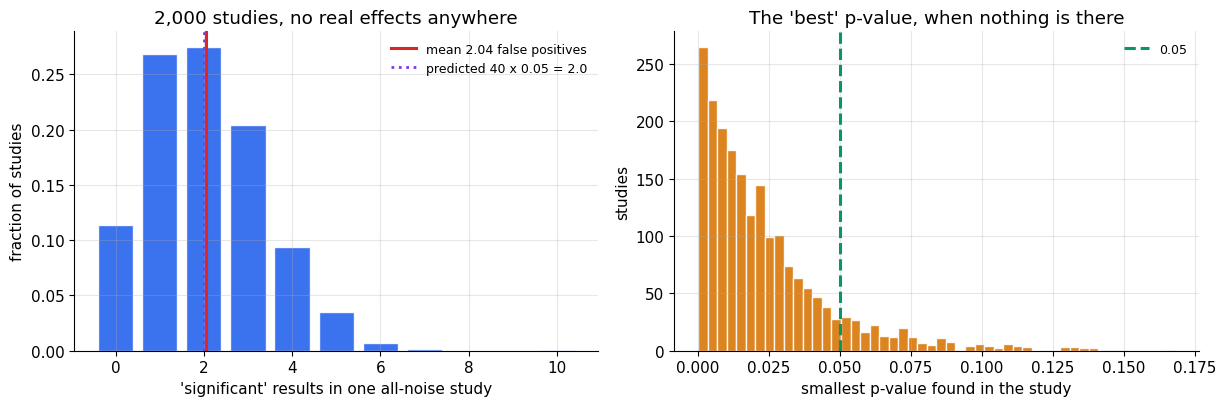

mean false positives per study        = 2.042   (expected 2.0)
studies with AT LEAST one 'finding'   = 88.6%
theory: 1 - 0.95^40                   = 87.1%
studies with 4 or more 'findings'     = 13.9%
studies that found NOTHING            = 11.4%

median of the smallest p-value        = 0.0167
studies whose best p was below 0.01   = 33.8%

Read the last two lines slowly. In a study with nothing in it, the best
p-value is typically around 0.001-0.01. 'p < 0.01' is not impressive when
it is the minimum of forty tries -- and the reader is never told it was.


In [67]:
# ============================================================
#  One study proves nothing. Run 2,000 of them.
# ============================================================
rng_many = np.random.default_rng(8181)
N_STUDIES = 2000

counts = np.empty(N_STUDIES, dtype=int)
minp   = np.empty(N_STUDIES)
for s in range(N_STUDIES):
    p = one_null_study(rng_many)
    counts[s] = (p < ALPHA).sum()
    minp[s]   = p.min()

fwer_measured = (counts >= 1).mean()
fwer_theory   = 1 - (1 - ALPHA) ** N_VARS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.2))

vals, cts = np.unique(counts, return_counts=True)
ax1.bar(vals, cts / N_STUDIES, color=C_F, alpha=0.9, edgecolor="white")
ax1.axvline(counts.mean(), color=C_SLOPE, lw=2.2,
            label=f"mean {counts.mean():.2f} false positives")
ax1.axvline(N_VARS * ALPHA, color=C_EXACT, lw=2.0, ls=":",
            label=f"predicted 40 x 0.05 = {N_VARS * ALPHA:.1f}")
ax1.set_xlabel("'significant' results in one all-noise study")
ax1.set_ylabel("fraction of studies")
ax1.set_title(f"{N_STUDIES:,} studies, no real effects anywhere")
ax1.legend(frameon=False, fontsize=9)

ax2.hist(minp, bins=50, color=C_APPROX, alpha=0.9, edgecolor="white")
ax2.axvline(ALPHA, color=C_AREA, lw=2.2, ls="--", label="0.05")
ax2.set_xlabel("smallest p-value found in the study")
ax2.set_ylabel("studies")
ax2.set_title("The 'best' p-value, when nothing is there")
ax2.legend(frameon=False, fontsize=9)

fig.tight_layout(); plt.show()

print(f"mean false positives per study        = {counts.mean():.3f}"
      f"   (expected {N_VARS * ALPHA:.1f})")
print(f"studies with AT LEAST one 'finding'   = {fwer_measured:.1%}")
print(f"theory: 1 - 0.95^40                   = {fwer_theory:.1%}")
print(f"studies with 4 or more 'findings'     = {(counts >= 4).mean():.1%}")
print(f"studies that found NOTHING            = {(counts == 0).mean():.1%}")
print()
print(f"median of the smallest p-value        = {np.median(minp):.4f}")
print(f"studies whose best p was below 0.01   = {(minp < 0.01).mean():.1%}")
print()
print("Read the last two lines slowly. In a study with nothing in it, the best")
print("p-value is typically around 0.001-0.01. 'p < 0.01' is not impressive when")
print("it is the minimum of forty tries -- and the reader is never told it was.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: how many "significant" results a completely empty study produces. The distribution is centred on the printed mean, which matches the prediction $40 \times 0.05 = 2$ almost exactly — because that is precisely what a 5% error rate applied forty times means. The fraction of studies finding nothing at all is printed, and it is the minority.

Right: the *smallest* p-value from each empty study — the one that would be written up. Its median is printed above, and it sits well below 0.05. The minimum of forty uniform p-values is small by construction; it is a fact about the number 40, not about the world.

**The common misread:** "but the p-value was 0.003, that is very significant". A p-value is only interpretable together with the number of tests it was selected from. Detached from that count it is not a weak piece of evidence — it is not evidence.

</div>

### The corrections, and what each one actually promises

Two standard fixes, and they promise **different things** — which is why picking
between them is a real decision, not a formality.

**Bonferroni** controls the *family-wise error rate*: the probability of making
**even one** false positive across the whole family of tests. Compare each
p-value against $\alpha/m$ instead of $\alpha$. Simple, and it makes no
assumptions about dependence between the tests. It is also severe: with $m$ large
you will miss real effects.

**Benjamini–Hochberg** controls the *false discovery rate*: the expected
**proportion** of your declared discoveries that are false. Sort the p-values
$p_{(1)} \le \dots \le p_{(m)}$, find the largest $i$ with
$p_{(i)} \le \frac{i}{m}\alpha$, and reject everything up to it. You accept some
false positives in exchange for finding far more real effects — the right trade
when the tests are a screening step rather than a final verdict.

To compare them fairly we now need some **real** effects to miss, so the next
study has 5 genuine ones hidden among 35 nulls.


In [68]:
# ============================================================
#  40 variables: 5 REAL effects, 35 pure noise. We know which is which.
#  Measure, over many studies: false positives, true discoveries, FWER, FDR.
# ============================================================
rng_c   = np.random.default_rng(8282)
N_TRUE  = 5
N_NULL  = N_VARS - N_TRUE
EFFECT  = 0.45          # correlation of each real variable with the outcome
REPS    = 1000

def study_with_real_effects(rng, n=N_SUBJ):
    """Return p-values; the first N_TRUE variables are genuinely related to y."""
    y = rng.normal(0, 1, n)
    cols = []
    for j in range(N_VARS):
        if j < N_TRUE:
            cols.append(EFFECT * y + np.sqrt(1 - EFFECT ** 2) * rng.normal(0, 1, n))
        else:
            cols.append(rng.normal(0, 1, n))       # unrelated to y
    return corr_pvals(np.column_stack(cols), y)

def benjamini_hochberg(p, alpha=ALPHA):
    """Return a boolean array: which hypotheses BH rejects."""
    m = len(p)
    order = np.argsort(p)
    thresh = (np.arange(1, m + 1) / m) * alpha
    passed = p[order] <= thresh
    rej = np.zeros(m, dtype=bool)
    if passed.any():
        kmax = np.max(np.where(passed)[0])         # largest i that passes
        rej[order[:kmax + 1]] = True
    return rej

is_real = np.arange(N_VARS) < N_TRUE
res = {k: {"fp": [], "tp": [], "any_fp": []} for k in ("none", "bonferroni", "bh")}

for _ in range(REPS):
    p = study_with_real_effects(rng_c)
    decisions = {
        "none":       p < ALPHA,
        "bonferroni": p < ALPHA / N_VARS,
        "bh":         benjamini_hochberg(p),
    }
    for k, d in decisions.items():
        fp = int((d & ~is_real).sum())
        tp = int((d & is_real).sum())
        res[k]["fp"].append(fp)
        res[k]["tp"].append(tp)
        res[k]["any_fp"].append(fp >= 1)

print(f"{REPS} studies. Each has {N_TRUE} REAL effects and {N_NULL} pure-noise variables.")
print()
print(f"{'method':<14}{'false pos':>11}{'true pos':>10}{'FWER':>9}{'FDR':>9}{'power':>8}")
print("-" * 61)
label = {"none": "no correction", "bonferroni": "Bonferroni", "bh": "BH (FDR)"}
summary = {}
for k in ("none", "bonferroni", "bh"):
    fp = np.array(res[k]["fp"]); tp = np.array(res[k]["tp"])
    disc = fp + tp
    fdr = np.where(disc > 0, fp / np.maximum(disc, 1), 0.0).mean()
    fwer = np.mean(res[k]["any_fp"])
    power = tp.mean() / N_TRUE
    summary[k] = (fp.mean(), tp.mean(), fwer, fdr, power)
    print(f"{label[k]:<14}{fp.mean():11.2f}{tp.mean():10.2f}"
          f"{fwer:9.1%}{fdr:9.1%}{power:8.1%}")
print()
print(f"Uncorrected: {summary['none'][0]:.2f} false positives per study on average,")
print(f"and {summary['none'][2]:.0%} of studies report at least one thing that is not there.")
print(f"Bonferroni:  FWER cut to {summary['bonferroni'][2]:.1%}, but power falls from")
print(f"             {summary['none'][4]:.0%} to {summary['bonferroni'][4]:.0%} -- real effects are now missed.")
print(f"BH:          FDR held near {summary['bh'][3]:.1%} while keeping {summary['bh'][4]:.0%} power.")
print()
print("There is no free lunch here. Every correction trades sensitivity for")
print("credibility. Choosing NOT to correct is also a trade -- just an unstated one.")


1000 studies. Each has 5 REAL effects and 35 pure-noise variables.

method          false pos  true pos     FWER      FDR   power
-------------------------------------------------------------
no correction        1.70      4.61    82.3%    24.3%   92.1%
Bonferroni           0.04      2.70     4.4%     1.2%   54.1%
BH (FDR)             0.20      3.48    17.1%     4.0%   69.6%

Uncorrected: 1.70 false positives per study on average,
and 82% of studies report at least one thing that is not there.
Bonferroni:  FWER cut to 4.4%, but power falls from
             92% to 54% -- real effects are now missed.
BH:          FDR held near 4.0% while keeping 70% power.

There is no free lunch here. Every correction trades sensitivity for
credibility. Choosing NOT to correct is also a trade -- just an unstated one.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The table is measured, not quoted. We knew which five variables were real because we built them, so every declared discovery could be scored as true or false across a thousand simulated studies.

Uncorrected testing produces the printed number of false positives per study — close to $35 \times 0.05$, exactly as the arithmetic demands — and a family-wise error rate far above 5%.

Bonferroni pushes the family-wise rate back under 5%, and the printed power column shows what it costs: real effects that were being detected are now missed. Benjamini–Hochberg lands between the two, holding the false *discovery* rate near the printed value while keeping most of the power. Both fixes work. Neither is free, and the table says by exactly how much.

</div>

---

## 8.2 P-hacking: how to find a result in data that contains none

Section 8.1 assumed the forty tests were declared in advance. In practice nobody
runs forty pre-registered tests. They run one, get $p = 0.31$, and then start
*adjusting* — and every adjustment is another test that never gets counted.

The moves are all individually defensible:

- **Subgroups.** "It does not hold overall, but perhaps in women? In the under-30s?"
- **Outcome definitions.** Raw score, or log score, or change from baseline, or a
  binary above/below median?
- **Outlier rules.** Drop points beyond 2 standard deviations? Beyond 3? Or none?
- **Covariates.** Adjust for age? For age and site?
- **Sample size.** Collect thirty more and look again.

Each choice is reasonable. Each is made **after seeing the data**. Together they
are a search, and the search is invisible in the final write-up.

Below we take a dataset with **no effect whatsoever** and hunt through a garden of
such choices until something clears $p < 0.05$ — counting the attempts as we go.


In [69]:
# ============================================================
#  ONE dataset. No treatment effect: outcome does not depend on group.
#  Then a systematic hunt through defensible analysis choices.
# ============================================================
rngh = np.random.default_rng(8383)

def make_null_trial(rng, n=120):
    """A 'trial' with NO treatment effect at all, plus harmless covariates."""
    d = {
        "group":  rng.integers(0, 2, n),                 # 0 = control, 1 = treated
        "sex":    rng.integers(0, 2, n),
        "age":    rng.integers(18, 70, n),
        "site":   rng.integers(0, 3, n),
    }
    d["score"] = rng.normal(100, 15, n)   # <-- does NOT use d['group']. No effect.
    return d

trial = make_null_trial(rngh)

# ---- the garden of choices: subgroups x outcome definitions x outlier rules ----
subgroups = {
    "everyone":        np.ones(len(trial["score"]), dtype=bool),
    "women":           trial["sex"] == 0,
    "men":             trial["sex"] == 1,
    "under 40":        trial["age"] < 40,
    "40 and over":     trial["age"] >= 40,
    "site A":          trial["site"] == 0,
    "site B":          trial["site"] == 1,
    "women under 40":  (trial["sex"] == 0) & (trial["age"] < 40),
}
outcomes = {
    "raw score":        lambda s: s,
    "log score":        lambda s: np.log(np.clip(s, 1, None)),
    "score squared":    lambda s: s ** 2,
    "rank of score":    lambda s: stats.rankdata(s),
}
outlier_rules = {
    "keep all":     None,
    "drop |z| > 3": 3.0,
    "drop |z| > 2": 2.0,
}

attempts, first_win = [], None
for sg_name, sg in subgroups.items():
    for out_name, f in outcomes.items():
        for or_name, z in outlier_rules.items():
            g, s = trial["group"][sg], f(trial["score"][sg])
            if z is not None and s.std() > 0:
                keep = np.abs((s - s.mean()) / s.std()) <= z
                g, s = g[keep], s[keep]
            if (g == 0).sum() < 5 or (g == 1).sum() < 5:
                continue
            p = welch_p(s[g == 1], s[g == 0])
            attempts.append((sg_name, out_name, or_name, p))
            if p < ALPHA and first_win is None:
                first_win = (len(attempts), sg_name, out_name, or_name, p)

all_p = np.array([a[3] for a in attempts])

print("THE HONEST ANALYSIS -- decided before looking at anything:")
g0 = trial["score"][trial["group"] == 0]
g1 = trial["score"][trial["group"] == 1]
p_honest = welch_p(g1, g0)
print(f"   whole sample, raw score, no exclusions:  p = {p_honest:.4f}"
      f"   -> {'significant' if p_honest < ALPHA else 'nothing to report'}")
print()
print(f"THE GARDEN: {len(subgroups)} subgroups x {len(outcomes)} outcome definitions"
      f" x {len(outlier_rules)} outlier rules")
print(f"   analyses actually run           : {len(attempts)}")
print(f"   of those with p < {ALPHA}          : {(all_p < ALPHA).sum()}")
print(f"   smallest p-value anywhere       : {all_p.min():.4f}")
print()
if first_win:
    i, sg, out, orr, p = first_win
    print(f"FIRST 'SIGNIFICANT' RESULT, on attempt {i} of {len(attempts)}:")
    print(f"   subgroup      : {sg}")
    print(f"   outcome       : {out}")
    print(f"   outlier rule  : {orr}")
    print(f"   p-value       : {p:.4f}")
    print()
    print(f'   Write-up: "Among {sg}, the treatment significantly improved')
    print(f'   {out} (p = {p:.3f})." Every word of that sentence is true.')
else:
    print("No subgroup reached significance in this particular dataset.")
print()
print("Reminder of what is in the data: the outcome was generated on a line that")
print("never mentions the group. The true effect is EXACTLY ZERO.")


THE HONEST ANALYSIS -- decided before looking at anything:
   whole sample, raw score, no exclusions:  p = 0.7466   -> nothing to report

THE GARDEN: 8 subgroups x 4 outcome definitions x 3 outlier rules
   analyses actually run           : 96
   of those with p < 0.05          : 0
   smallest p-value anywhere       : 0.1072

No subgroup reached significance in this particular dataset.

Reminder of what is in the data: the outcome was generated on a line that
never mentions the group. The true effect is EXACTLY ZERO.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The honest analysis — the one you would have pre-registered — returns the p-value printed at the top, and it finds nothing, correctly, because there is nothing there. The code that generated `score` does not reference `group`.

The garden then runs the number of analyses printed above, all of them defensible in isolation, and the attempt number at which the first significant result appeared is printed with the exact combination that produced it. The resulting sentence is *literally true* and completely misleading, because the reader is never told how many other subgroups and outcome definitions were tried first.

That gap — between what is stated and what was searched — is p-hacking. No step of it required a lie.

</div>

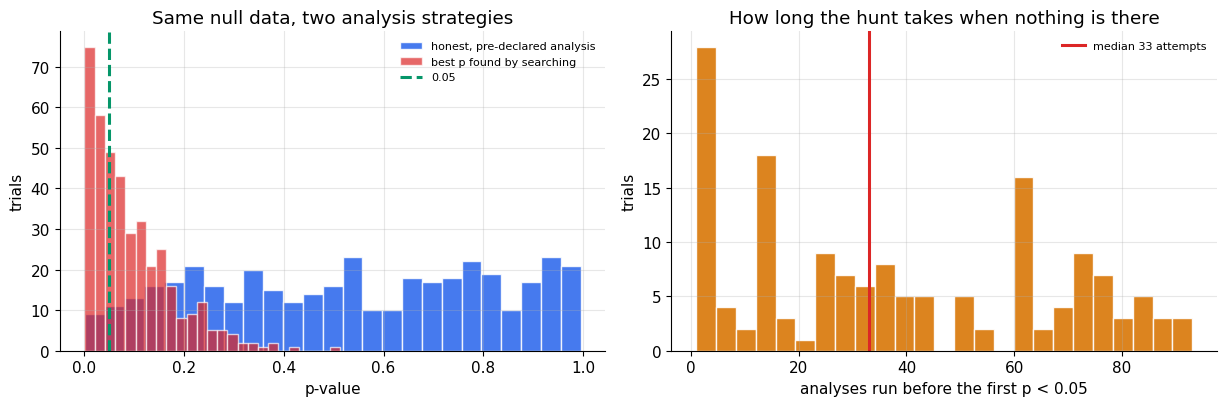

400 trials, every one with a TRUE EFFECT OF ZERO.

honest analysis 'significant'      : 4.0%   <- this is alpha, working correctly
search found SOMETHING significant : 38.8%

median attempts before the first win : 33
25th / 75th percentile               : 13 / 62
median of the best p-value found     : 0.0702

The honest rate is 4%, right where it should be.
The searched rate is 39%. Same data, same tests, same maths --
the only difference is that one analyst stopped and the other kept going.


In [70]:
# ============================================================
#  Does it work reliably, or did we get lucky? Run 400 null trials,
#  and let each one search the garden until it finds something.
# ============================================================
rngh2 = np.random.default_rng(8484)
N_TRIALS = 400

def welch_t_df(a, b):
    """The Welch t statistic and its degrees of freedom, without the p-value.
    Collecting these and converting them all at once is what keeps this cell
    fast -- it is the same test as welch_p, split in two."""
    na, nb = len(a), len(b)
    va, vb = a.var(ddof=1) / na, b.var(ddof=1) / nb
    se = np.sqrt(va + vb)
    if not np.isfinite(se) or se == 0:
        return 0.0, 1.0
    return ((a.mean() - b.mean()) / se,
            (va + vb) ** 2 / (va ** 2 / (na - 1) + vb ** 2 / (nb - 1)))

def search_garden(rng):
    """Run one null trial through the same garden. Return (honest p, best p, attempts)."""
    t = make_null_trial(rng)
    sc, gp, sx, ag, st = t["score"], t["group"], t["sex"], t["age"], t["site"]
    p_hon = welch_p(sc[gp == 1], sc[gp == 0])
    sgs = [np.ones(len(sc), bool), sx == 0, sx == 1, ag < 40, ag >= 40,
           st == 0, st == 1, (sx == 0) & (ag < 40)]
    outs = [lambda s: s, lambda s: np.log(np.clip(s, 1, None)),
            lambda s: s ** 2, lambda s: stats.rankdata(s)]
    ts, dfs = [], []
    for sg in sgs:
        for f in outs:
            for z in (None, 3.0, 2.0):
                g, s = gp[sg], f(sc[sg])
                if z is not None and s.std() > 0:
                    keep = np.abs((s - s.mean()) / s.std()) <= z
                    g, s = g[keep], s[keep]
                if (g == 0).sum() < 5 or (g == 1).sum() < 5:
                    continue
                tt, dd = welch_t_df(s[g == 1], s[g == 0])
                ts.append(tt); dfs.append(dd)
    ps = 2 * stats.t.sf(np.abs(ts), dfs)        # every attempt, in order
    win = np.where(ps < ALPHA)[0]
    return p_hon, ps.min(), (int(win[0]) + 1 if len(win) else None)

hon, best, until = [], [], []
for _ in range(N_TRIALS):
    h, b, u = search_garden(rngh2)
    hon.append(h); best.append(b); until.append(u)
hon, best = np.array(hon), np.array(best)
found = np.array([u is not None for u in until])
tries = np.array([u for u in until if u is not None])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 4.2))
ax1.hist(hon, bins=25, color=C_F, alpha=0.85, edgecolor="white",
         label="honest, pre-declared analysis")
ax1.hist(best, bins=25, color=C_SLOPE, alpha=0.7, edgecolor="white",
         label="best p found by searching")
ax1.axvline(ALPHA, color=C_AREA, lw=2.2, ls="--", label="0.05")
ax1.set_xlabel("p-value"); ax1.set_ylabel("trials")
ax1.set_title("Same null data, two analysis strategies")
ax1.legend(frameon=False, fontsize=8)

ax2.hist(tries, bins=25, color=C_APPROX, alpha=0.9, edgecolor="white")
ax2.axvline(np.median(tries), color=C_SLOPE, lw=2.2,
            label=f"median {np.median(tries):.0f} attempts")
ax2.set_xlabel("analyses run before the first p < 0.05")
ax2.set_ylabel("trials")
ax2.set_title("How long the hunt takes when nothing is there")
ax2.legend(frameon=False, fontsize=8)

fig.tight_layout(); plt.show()

print(f"{N_TRIALS} trials, every one with a TRUE EFFECT OF ZERO.")
print()
print(f"honest analysis 'significant'      : {(hon < ALPHA).mean():.1%}"
      f"   <- this is alpha, working correctly")
print(f"search found SOMETHING significant : {found.mean():.1%}")
print()
print(f"median attempts before the first win : {np.median(tries):.0f}")
print(f"25th / 75th percentile               : {np.percentile(tries, 25):.0f}"
      f" / {np.percentile(tries, 75):.0f}")
print(f"median of the best p-value found     : {np.median(best):.4f}")
print()
print(f"The honest rate is {(hon < ALPHA).mean():.0%}, right where it should be.")
print(f"The searched rate is {found.mean():.0%}. Same data, same tests, same maths --")
print("the only difference is that one analyst stopped and the other kept going.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: two p-value distributions from **identical null data**. The blue one — the pre-declared analysis — is roughly flat, which is exactly what p-values do when the null is true, and only about 5% of it falls below 0.05. The red one is the *minimum* over the garden, and it is crushed toward zero.

Right: how many analyses it took to reach the first significant result. The median is printed, and it is a small number — this hunt is short.

**The common misread:** believing p-hacking requires bad faith. It requires only that you keep analysing until the result looks publishable, and that you report the analysis rather than the search. Every individual step in the garden above is a choice a careful analyst might defend at a seminar.

</div>

---

## 8.3 Optional stopping: the test that a watcher breaks

This one deserves its own section because it is the most common and the least
recognised. It also has an ML twin that is committed daily.

The protocol: collect data, and after **each new observation** run the test. If
$p < 0.05$, stop and declare victory. Otherwise collect one more. Cap it at some
maximum sample size and give up if you never get there.

It sounds harmless — surely more data is better? — but it is a rigged game. The
p-value wanders as $n$ grows. Under the null it wanders *without drift*, but it
still wanders, and given enough peeks it will eventually dip below 0.05 by chance
alone. Stopping the moment it does turns a wandering path into a guaranteed win,
and the 5% guarantee is gone.

The formal statement: $\alpha = 0.05$ is a promise about a test performed **once,
at a sample size fixed in advance**. Every extra peek is another chance to reject,
and none of them are counted.


running p-values agree with scipy? True



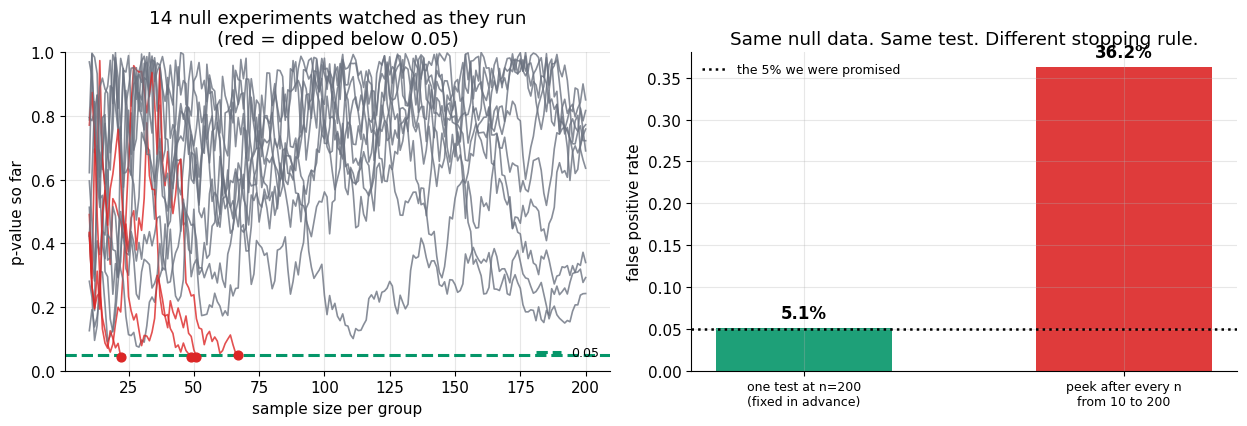

2,000 experiments. In every one the two groups are drawn from the
SAME distribution -- the true difference is exactly zero.

fixed n = 200, tested once   : false positive rate = 5.1%   <- as promised
peeking from n=10 to n=200  : false positive rate = 36.2%   <- 7.2x the promise

among the experiments that 'won', median stopping n = 32
fraction that stopped before n = 50            = 22.6%

Note the second line especially: most false positives are harvested EARLY,
when the sample is small and the p-value is most volatile. 'We stopped
because it was already significant' is the tell.


In [71]:
# ============================================================
#  Two groups drawn from the SAME distribution. No difference exists.
#  Protocol: test after every new pair of observations; stop at p < 0.05.
# ============================================================
rngs = np.random.default_rng(8585)

N_MIN, N_MAX = 10, 200
N_SIMS = 2000

def running_welch_p(A, B, n_min=N_MIN):
    """p-value after EVERY observation, for many experiments at once.

    A and B are (sims, n_max). Returns (sims, n_max - n_min + 1): the Welch
    p-value using the first n columns, for every n from n_min to n_max.
    Running means and variances come from cumulative sums, so the whole
    peeking experiment is one array computation instead of a million tests."""
    ns  = np.arange(n_min, A.shape[1] + 1)
    out = []
    for X in (A, B):
        c1 = np.cumsum(X, axis=1)[:, n_min - 1:]
        c2 = np.cumsum(X ** 2, axis=1)[:, n_min - 1:]
        mean = c1 / ns
        var  = (c2 - ns * mean ** 2) / (ns - 1)        # sample variance, ddof=1
        out.append((mean, var / ns))                    # (mean, variance of mean)
    (mA, vA), (mB, vB) = out
    se = np.sqrt(vA + vB)
    t  = (mA - mB) / se
    df = (vA + vB) ** 2 / (vA ** 2 / (ns - 1) + vB ** 2 / (ns - 1))
    return ns, 2 * stats.t.sf(np.abs(t), df)

# ---- the peeking protocol: look after every observation, stop at p < 0.05 ----
A = rngs.normal(0, 1, (N_SIMS, N_MAX))
B = rngs.normal(0, 1, (N_SIMS, N_MAX))      # SAME distribution. No difference.
n_grid, P = running_welch_p(A, B)

# confirm the vectorised version against scipy at a couple of spot checks
spot = [(0, 37), (5, 120), (11, 200)]
print("running p-values agree with scipy?",
      all(np.isclose(P[i, n - N_MIN],
                     stats.ttest_ind(A[i, :n], B[i, :n], equal_var=False).pvalue)
          for i, n in spot))
print()

below   = P < ALPHA
stopped = below.any(axis=1)
first   = np.argmax(below, axis=1)                    # first peek that dips
ns      = np.where(stopped, n_grid[first], N_MAX)
peek_rate = stopped.mean()

# ---- the honest comparison: ONE test, at n = N_MAX, fixed in advance ----
fixed_rate = (P[:, -1] < ALPHA).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.4))
for i in range(14):
    stop_i = stopped[i]
    end = first[i] + 1 if stop_i else len(n_grid)
    ax1.plot(n_grid[:end], P[i, :end], lw=1.2, alpha=0.8,
             color=C_SLOPE if stop_i else C_GREY)
    if stop_i:
        ax1.scatter([n_grid[first[i]]], [P[i, first[i]]], s=40,
                    color=C_SLOPE, zorder=5)
ax1.axhline(ALPHA, color=C_AREA, lw=2.2, ls="--", label="0.05")
ax1.set_xlabel("sample size per group"); ax1.set_ylabel("p-value so far")
ax1.set_title("14 null experiments watched as they run\n(red = dipped below 0.05)")
ax1.set_ylim(0, 1); ax1.legend(frameon=False, fontsize=9)

ax2.bar([0, 1], [fixed_rate, peek_rate], width=0.55,
        color=[C_AREA, C_SLOPE], alpha=0.9)
ax2.axhline(ALPHA, color="black", lw=1.8, ls=":", label="the 5% we were promised")
ax2.set_xticks([0, 1])
ax2.set_xticklabels([f"one test at n={N_MAX}\n(fixed in advance)",
                     f"peek after every n\nfrom {N_MIN} to {N_MAX}"], fontsize=9)
ax2.set_ylabel("false positive rate")
ax2.set_title("Same null data. Same test. Different stopping rule.")
for i, v in enumerate([fixed_rate, peek_rate]):
    ax2.text(i, v + 0.012, f"{v:.1%}", ha="center", fontsize=12, weight="bold")
ax2.legend(frameon=False, fontsize=9)

fig.tight_layout(); plt.show()

print(f"{N_SIMS:,} experiments. In every one the two groups are drawn from the")
print("SAME distribution -- the true difference is exactly zero.")
print()
print(f"fixed n = {N_MAX}, tested once   : false positive rate = {fixed_rate:.1%}"
      f"   <- as promised")
print(f"peeking from n={N_MIN} to n={N_MAX}  : false positive rate = {peek_rate:.1%}"
      f"   <- {peek_rate / ALPHA:.1f}x the promise")
print()
print(f"among the experiments that 'won', median stopping n = "
      f"{np.median(ns[stopped]):.0f}")
print(f"fraction that stopped before n = 50            = "
      f"{(stopped & (ns < 50)).mean():.1%}")
print()
print("Note the second line especially: most false positives are harvested EARLY,")
print("when the sample is small and the p-value is most volatile. 'We stopped")
print("because it was already significant' is the tell.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: fourteen experiments in which the two groups are genuinely identical, each traced as data accumulates. The p-value wanders — it does not settle. Grey paths never dipped below the dashed line; red ones did, and would have been stopped and published at the marked dot. Watch a wandering line long enough and it crosses any threshold.

Right: the two false-positive rates side by side, printed on the bars. The left bar is a test run once at a pre-fixed sample size, sitting on the promised 5%. The right bar is the identical test on identical null data, with the *only* change being that somebody looked as it ran.

**The common misread:** "we just stopped early because the result was already clear". A result that is significant at $n = 30$ and would not have been at $n = 200$ is not clear — it is the reason the error rate on the right-hand bar is what it is. Sequential designs exist and are perfectly valid, but they spend the error budget across the peeks *deliberately*, and declare the stopping rule in advance.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Two groups drawn from `rng.normal(0, 1, ...)` — the same distribution, twice. The true difference is zero by construction, so **every** rejection in this simulation is a false positive and can be counted without ambiguity.

Testing once at a pre-fixed sample size gives the false-positive rate printed on the left bar, right where $\alpha$ promises. Peeking after every observation gives the rate on the right bar, several times higher — the multiplier is printed above.

Nothing else changed. Not the data, not the test, not the significance threshold. Only the rule for when to stop looking. The error rate is a property of the **procedure**, not of the final dataset — which is why it cannot be recovered by inspecting the data afterwards.

</div>

---

## 8.4 The garden of forking paths: the same damage, with no intent

Sections 8.2 and 8.3 might read as accusations. They are not. The uncomfortable
version of the problem — Gelman and Loken's **garden of forking paths** — needs no
searching at all.

Suppose you run exactly **one** analysis. You do not p-hack. You do not peek. But
the analysis you ran was *chosen after seeing the data*: you noticed the effect
looked stronger in women, so you reported the subgroup; you noticed a couple of
extreme points, so you excluded them; the distribution looked skewed, so you took
logs. One analysis, honestly reported.

The problem is the **counterfactual**. Had the data come out differently, you
would have made different reasonable choices. Across the ways the data might have
fallen, your procedure has many branches, and the error rate belongs to the
procedure, not to the branch you happened to walk down.

This is why the multiplicity in 8.1 is not fixed by counting the tests you *ran*.
The relevant count is the tests you *would have* run — and that number is neither
recorded nor recoverable. Which is the whole argument for pre-registration: not
because researchers are dishonest, but because a decision written down before the
data cannot bend to fit it.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Testing many things and reporting the winner.** Every trap so far is one species of this, and the printed numbers name the damage:

- 40 noise variables, uncorrected: roughly 2 false positives per study, and a large majority of empty studies reporting at least one "finding" (8.1).
- A garden of subgroups and outcome definitions on data with a true effect of exactly zero: a significant result found in the large majority of trials, after only a handful of attempts (8.2).
- Peeking until significance: a false-positive rate several times the promised 5% (8.3).

The reason all three are the same trap: **a p-value is a statement about a procedure**, and selecting the winner from many attempts changes the procedure without changing any of the numbers you can see. The dataset cannot tell you it happened. No test can detect it after the fact.

The only defences are procedural — decide the analysis before seeing the data, report every test you ran, correct for the family, and treat anything found by exploration as a **hypothesis** to be confirmed on fresh data, never as a result.

</div>

---

## 8.5 Simpson's paradox: the trend that reverses

Now a different species of failure. Nothing is repeated, nothing is searched, and
the analysis is run exactly once — and the answer still comes out backwards.

**Simpson's paradox** is when a relationship present in every subgroup **reverses
sign** once the subgroups are pooled. Not weakens. Reverses.

We will construct one deliberately: within every age band, more exercise is
associated with *lower* cholesterol. Pool the age bands and more exercise appears
associated with *higher* cholesterol. Both statements are computed from the same
rows, and both are arithmetically correct.

The mechanism is a **confounder that shifts both variables at once**. Older people
in our construction both exercise more (retirement, doctor's orders) and have
higher cholesterol (age). The between-group shift is steep and positive; the
within-group effect is shallow and negative; pooling lets the between-group shift
win.


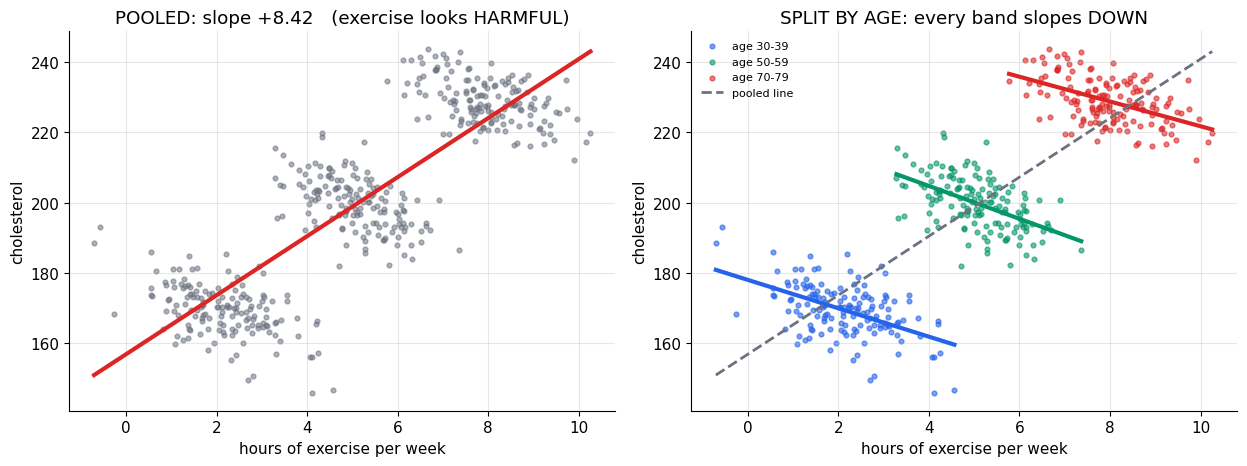

analysis                       slope         r
----------------------------------------------
POOLED (ignoring age)          +8.42    +0.845
within age 30-39               -4.05    -0.512
within age 50-59               -4.68    -0.518
within age 70-79               -3.53    -0.494

true within-band slope, written into the code above = -4.00

The pooled slope is +8.42. Every within-age slope is negative.
Sign reversal? True

Two contradictory sentences, both true of the same 450 rows:
  "More exercise is associated with HIGHER cholesterol (slope +8.42)."
  "More exercise is associated with LOWER cholesterol, in every age band (slopes -4.05, -4.68, -3.53)."


In [72]:
# ============================================================
#  Constructed so the reversal is guaranteed, not hoped for.
#  Within every age band: MORE exercise -> LOWER cholesterol.
#  Between age bands:     older -> more exercise AND higher cholesterol.
# ============================================================
rngsp = np.random.default_rng(8686)

BANDS = [("age 30-39", 2.0, 170.0, C_F),
         ("age 50-59", 5.0, 200.0, C_AREA),
         ("age 70-79", 8.0, 230.0, C_SLOPE)]
WITHIN_SLOPE = -4.0       # the TRUE within-band effect: negative
PER_BAND     = 150

ex_all, ch_all, band_all = [], [], []
for i, (name, ex_mean, ch_base, _) in enumerate(BANDS):
    ex = rngsp.normal(ex_mean, 0.9, PER_BAND)
    ch = ch_base + WITHIN_SLOPE * (ex - ex_mean) + rngsp.normal(0, 6.0, PER_BAND)
    ex_all.append(ex); ch_all.append(ch); band_all.append(np.full(PER_BAND, i))
exercise = np.concatenate(ex_all)
chol     = np.concatenate(ch_all)
band     = np.concatenate(band_all)

def slope_of(x, y):
    xb, yb = x.mean(), y.mean()
    return ((x - xb) * (y - yb)).sum() / ((x - xb) ** 2).sum()

pooled_slope = slope_of(exercise, chol)
pooled_r     = np.corrcoef(exercise, chol)[0, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.8))

ax1.scatter(exercise, chol, s=12, color=C_GREY, alpha=0.55)
gx = np.linspace(exercise.min(), exercise.max(), 40)
ax1.plot(gx, chol.mean() + pooled_slope * (gx - exercise.mean()),
         color=C_SLOPE, lw=3.0)
ax1.set_xlabel("hours of exercise per week"); ax1.set_ylabel("cholesterol")
ax1.set_title(f"POOLED: slope {pooled_slope:+.2f}   (exercise looks HARMFUL)")

within = []
for i, (name, ex_mean, ch_base, col) in enumerate(BANDS):
    m = band == i
    s = slope_of(exercise[m], chol[m])
    within.append(s)
    ax2.scatter(exercise[m], chol[m], s=12, color=col, alpha=0.6, label=name)
    gxi = np.linspace(exercise[m].min(), exercise[m].max(), 20)
    ax2.plot(gxi, chol[m].mean() + s * (gxi - exercise[m].mean()),
             color=col, lw=3.0)
ax2.plot(gx, chol.mean() + pooled_slope * (gx - exercise.mean()),
         color=C_GREY, lw=2.0, ls="--", label="pooled line")
ax2.set_xlabel("hours of exercise per week"); ax2.set_ylabel("cholesterol")
ax2.set_title("SPLIT BY AGE: every band slopes DOWN")
ax2.legend(frameon=False, fontsize=8)

fig.tight_layout(); plt.show()

print(f"{'analysis':<26}{'slope':>10}{'r':>10}")
print("-" * 46)
print(f"{'POOLED (ignoring age)':<26}{pooled_slope:+10.2f}{pooled_r:+10.3f}")
for i, ((name, _, _, _), s) in enumerate(zip(BANDS, within)):
    m = band == i
    print(f"{'within ' + name:<26}{s:+10.2f}"
          f"{np.corrcoef(exercise[m], chol[m])[0, 1]:+10.3f}")
print()
print(f"true within-band slope, written into the code above = {WITHIN_SLOPE:+.2f}")
print()
print(f"The pooled slope is {pooled_slope:+.2f}. Every within-age slope is negative.")
print(f"Sign reversal? {pooled_slope > 0 and all(s < 0 for s in within)}")
print()
print("Two contradictory sentences, both true of the same 450 rows:")
print(f'  "More exercise is associated with HIGHER cholesterol (slope '
      f'{pooled_slope:+.2f})."')
print(f'  "More exercise is associated with LOWER cholesterol, in every age band'
      f' (slopes {", ".join(f"{s:+.2f}" for s in within)})."')


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: all 450 people, age ignored. The fitted line slopes **up** — read naively, exercise raises cholesterol.

Right: identical points, coloured by age band, each band fitted separately. Every one of the three lines slopes **down**, all close to the true within-band slope written into the generating code. The pooled line, redrawn as a grey dashed line, cuts diagonally across all three because it is tracking the *positions of the clusters*, not the trend inside them.

**The common misread:** treating this as a curiosity or an optical illusion. It is neither. Both numbers are correct; they answer **different questions**. The pooled slope answers "if I pick a random person who exercises more, what is their cholesterol likely to be?" — and the answer really is higher, because they are probably older. The within-band slope answers "if *this* person exercises more, what happens to their cholesterol?" — which is the question anyone actually cares about, and the answer is the opposite.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

The mechanism, in one sentence: **a variable that shifts both $x$ and $y$ between groups can dominate the pooled relationship and drown out — or reverse — the effect inside the groups.**

Here age pushes exercise up *and* cholesterol up. The gap between the age clusters is large and points up-and-right; the slope inside each cluster is gentle and points down-and-right. Pooling adds those two signals together, and the between-group one is bigger.

This is why an unconditioned comparison is dangerous. "Hospital A has a higher death rate than Hospital B" is not a fact about hospital quality until you know whether A takes the sicker patients. "Model A has lower accuracy than Model B" is not a fact about the models until you know they were evaluated on the same mix of examples.

And note what the paradox does **not** give you: a general rule that splitting is right. Splitting by a variable that lies on the causal path from $x$ to $y$ — or worse, by a collider, which is next — makes the answer wrong in the other direction. Which variables to condition on is a question about causal structure, and no amount of staring at the numbers answers it.

</div>

---

## 8.6 Survivorship bias and selection effects

Both of these are the same failure wearing different clothes: **the rows you can
see were chosen by a process related to what you are trying to measure**, so the
sample is not a sample of anything you care about.

**Survivorship bias.** You analyse what remains. Funds that closed are not in the
fund database. Companies that failed are not in the "habits of successful
companies" study. Students who dropped out are not in the graduation-year survey.
The disappearances are not random — they are precisely the bad outcomes — so the
survivors' average is not the population's average.

**Selection on a collider.** Subtler and stranger. Take two genuinely
**independent** variables. Select the rows where their *sum* is high — as any
admissions process, hiring filter, or "notable enough to be in the dataset"
threshold does. Inside the selected set the two variables now correlate
**negatively**, out of nothing. If you got in with a weak score on one, you must
have had a strong score on the other; that is what the filter guarantees.

Both are constructed below, with the true values available for comparison.


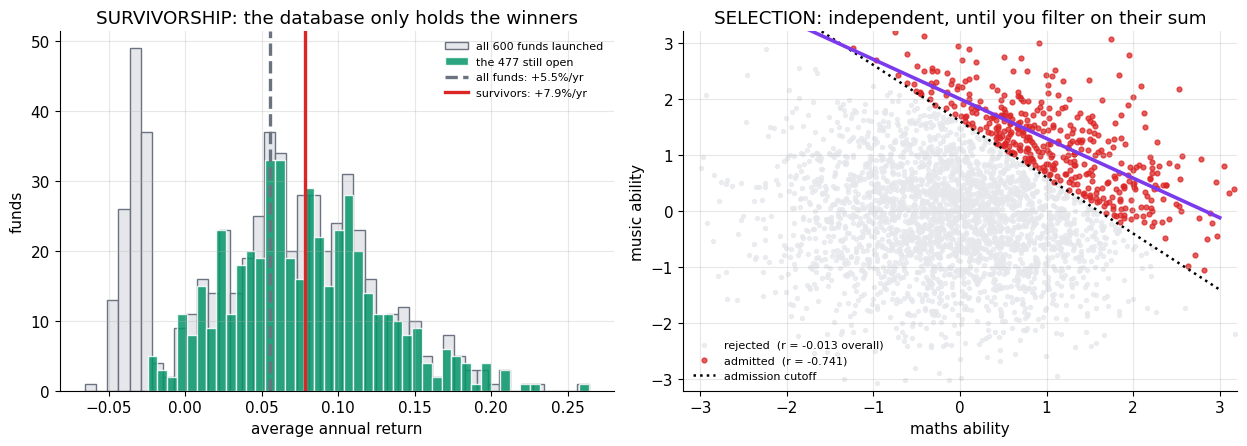

SURVIVORSHIP BIAS
  funds launched                    : 600
  funds still open after 10 years  : 477   (79.5%)
  mean annual return, ALL funds     : +5.54%
  mean annual return, SURVIVORS     : +7.86%
  the bias                          : +2.31% per year
  true mean skill written into code : +0.0004 per year
  A brochure quoting the survivor number is not lying about arithmetic.
  It is quoting a number computed on a set defined by good outcomes.

SELECTION ON A COLLIDER
  correlation of maths and music, everyone  : -0.0130   <- independent, as built
  correlation among the 406 ADMITTED       : -0.7407   <- negative, from nothing
  slope within the admitted group           : -0.705

  Nothing in the world connects maths and music here -- the two arrays
  were drawn independently. Conditioning on their sum MANUFACTURED the
  relationship. Inside a selective school, 'the good mathematicians are
  worse musicians' is true and tells you only about the admissions rule.


In [73]:
# ============================================================
#  LEFT : 600 funds over 10 years. Weak ones close. We see the survivors.
#  RIGHT: two INDEPENDENT abilities. Admission needs a high sum.
# ============================================================
rngsel = np.random.default_rng(8787)

# ---------- survivorship ----------
N_FUNDS, YEARS = 600, 10
true_skill = rngsel.normal(0.0, 0.01, N_FUNDS)      # tiny, mostly zero
alive = np.ones(N_FUNDS, dtype=bool)
cumret = np.zeros(N_FUNDS)
for _ in range(YEARS):
    r = true_skill + rngsel.normal(0.06, 0.18, N_FUNDS)   # yearly return
    cumret = np.where(alive, cumret + r, cumret)
    alive = alive & (cumret > -0.25)                # a bad run closes the fund

mean_all      = cumret.mean() / YEARS
mean_survivor = cumret[alive].mean() / YEARS

# ---------- collider selection ----------
N_APP = 3000
maths = rngsel.normal(0, 1, N_APP)
music = rngsel.normal(0, 1, N_APP)                  # independent of maths
r_before = np.corrcoef(maths, music)[0, 1]
admitted = (maths + music) > 1.6                    # the filter
r_after  = np.corrcoef(maths[admitted], music[admitted])[0, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.6))

ax1.hist(cumret / YEARS, bins=45, color=C_SOFT, edgecolor=C_GREY,
         label=f"all {N_FUNDS} funds launched")
ax1.hist(cumret[alive] / YEARS, bins=45, color=C_AREA, alpha=0.85,
         edgecolor="white", label=f"the {alive.sum()} still open")
ax1.axvline(mean_all, color=C_GREY, lw=2.4, ls="--",
            label=f"all funds: {mean_all:+.1%}/yr")
ax1.axvline(mean_survivor, color=C_SLOPE, lw=2.4,
            label=f"survivors: {mean_survivor:+.1%}/yr")
ax1.set_xlabel("average annual return"); ax1.set_ylabel("funds")
ax1.set_title("SURVIVORSHIP: the database only holds the winners")
ax1.legend(frameon=False, fontsize=8)

ax2.scatter(maths[~admitted], music[~admitted], s=8, color=C_SOFT, alpha=0.7,
            label=f"rejected  (r = {r_before:+.3f} overall)")
ax2.scatter(maths[admitted], music[admitted], s=12, color=C_SLOPE, alpha=0.75,
            label=f"admitted  (r = {r_after:+.3f})")
gm = np.linspace(-3, 3, 20)
ax2.plot(gm, 1.6 - gm, color="black", lw=1.8, ls=":", label="admission cutoff")
sl = ((maths[admitted] - maths[admitted].mean()) *
      (music[admitted] - music[admitted].mean())).sum() / \
     ((maths[admitted] - maths[admitted].mean()) ** 2).sum()
ax2.plot(gm, music[admitted].mean() + sl * (gm - maths[admitted].mean()),
         color=C_EXACT, lw=2.6)
ax2.set_xlim(-3.2, 3.2); ax2.set_ylim(-3.2, 3.2)
ax2.set_xlabel("maths ability"); ax2.set_ylabel("music ability")
ax2.set_title("SELECTION: independent, until you filter on their sum")
ax2.legend(frameon=False, fontsize=8, loc="lower left")

fig.tight_layout(); plt.show()

print("SURVIVORSHIP BIAS")
print(f"  funds launched                    : {N_FUNDS}")
print(f"  funds still open after {YEARS} years  : {alive.sum()}"
      f"   ({alive.mean():.1%})")
print(f"  mean annual return, ALL funds     : {mean_all:+.2%}")
print(f"  mean annual return, SURVIVORS     : {mean_survivor:+.2%}")
print(f"  the bias                          : {mean_survivor - mean_all:+.2%} per year")
print(f"  true mean skill written into code : {true_skill.mean():+.4f} per year")
print("  A brochure quoting the survivor number is not lying about arithmetic.")
print("  It is quoting a number computed on a set defined by good outcomes.")
print()
print("SELECTION ON A COLLIDER")
print(f"  correlation of maths and music, everyone  : {r_before:+.4f}"
      f"   <- independent, as built")
print(f"  correlation among the {admitted.sum()} ADMITTED       : {r_after:+.4f}"
      f"   <- negative, from nothing")
print(f"  slope within the admitted group           : {sl:+.3f}")
print()
print("  Nothing in the world connects maths and music here -- the two arrays")
print("  were drawn independently. Conditioning on their sum MANUFACTURED the")
print("  relationship. Inside a selective school, 'the good mathematicians are")
print("  worse musicians' is true and tells you only about the admissions rule.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: every fund ever launched (grey) against those still open after ten years (green). The survivors' mean return, printed on the plot and in the table, is well above the mean across all funds — and the true average skill written into the code is printed too, essentially zero. The entire apparent performance is the closures.

Right: maths against music ability for 3,000 applicants. Overall the correlation is the printed near-zero value, because the two arrays were drawn independently. The dotted line is the admissions cutoff; among the red points above it, the fitted purple line slopes **down** and the correlation is clearly negative.

**The common misread:** looking at the admitted group and concluding something about maths and music. The negative relationship is a property of the *triangle the filter cut out*, not of the abilities. Any dataset you can only see because it passed a filter carries this distortion, and it is invisible from inside the data.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Both effects come from data whose truth we wrote down.

The funds' true mean skill is printed and is essentially zero, yet the survivors show a substantial positive average return — the gap is printed as "the bias". Nothing about fund managers produced it; the *closure rule* produced it, and we can say so because we coded the rule.

The abilities were drawn as two independent normals, and the printed correlation across everyone confirms it is near zero. Among the admitted the printed correlation is solidly negative. We introduced no dependence anywhere; conditioning on the sum created it. This is why "controlling for" a variable is not automatically an improvement — the next section makes that the point.

</div>

---

## 8.7 Confounding, and why "we controlled for it" is not a guarantee

A **confounder** causes both your $x$ and your $y$, manufacturing an association
between them where no causal path exists. The textbook case: ice cream sales and
drownings rise together, because summer raises both. Nobody drowns because of ice
cream.

The standard fix is to put the confounder into the regression — "controlling
for" it. Done to a genuine confounder, it works, and we will watch it work.

But the phrase gets used as though adding covariates were always an improvement,
and it is not. Section 8.6 built a case where conditioning on a variable
*created* a relationship out of independent variables. Adding that variable to a
regression does exactly the same damage, with more authority, because now it
appears in a coefficient table.

The rule is uncomfortable and worth stating plainly: **which variables to adjust
for is a question about causal structure, and the data cannot answer it.** A
confounder must be adjusted for. A collider must not be. They can look identical
in a correlation matrix.


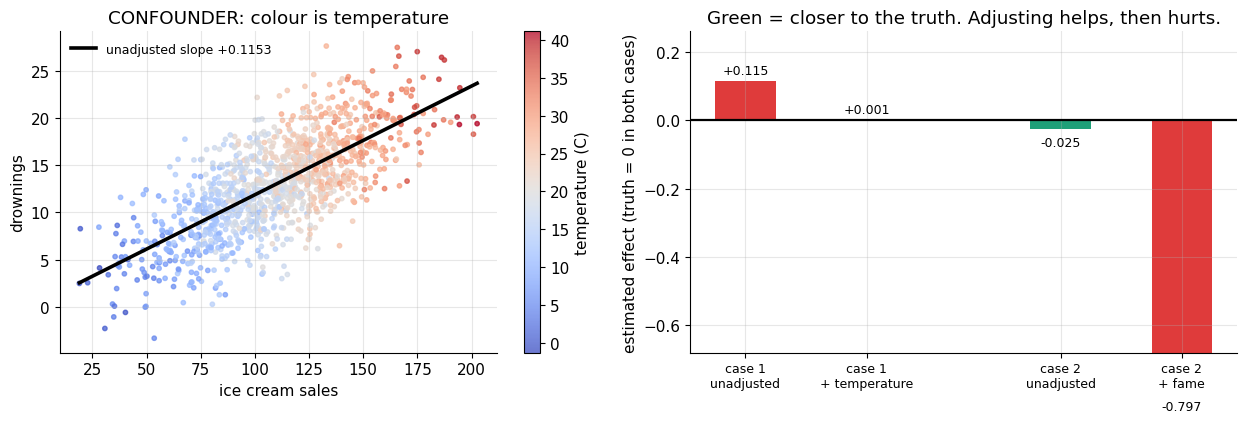

CASE 1 -- temperature is a genuine CONFOUNDER of ice cream and drownings.
  true effect of ice cream on drownings   :  0.0000  (by construction)
  unadjusted regression coefficient       :  +0.1153   <- spurious
  adjusted for temperature                :  +0.0005   <- fixed
  correlation of ice cream and drownings  : +0.722

CASE 2 -- fame is a COLLIDER: talent and looks both cause it.
  true relationship of talent and looks   :  0.0000  (independent draws)
  unadjusted regression coefficient       :  -0.0253   <- correct
  adjusted for fame                       :  -0.7972   <- BROKEN

Same phrase, opposite consequences. 'We controlled for fame' would sound
more careful in a paper, and would have introduced the entire error.

The two cases are indistinguishable from the numbers alone: both involve
three correlated variables. Only knowledge of what causes what separates
them -- and that knowledge comes from outside the dataset.


In [74]:
# ============================================================
#  CASE 1 (confounder)  : temperature -> ice cream, temperature -> drownings.
#                         Adjusting for temperature is CORRECT and fixes it.
#  CASE 2 (collider)    : two independent causes of one outcome.
#                         Adjusting for the outcome is WRONG and breaks it.
# ============================================================
rngcf = np.random.default_rng(8888)
NC = 1200

def ols(X, y):
    """Least-squares coefficients for design matrix X (first column = ones)."""
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta

# ---------- CASE 1: a genuine confounder ----------
temp      = rngcf.normal(20, 7, NC)                       # degrees C
icecream  = 30 + 4.0 * temp + rngcf.normal(0, 12, NC)     # caused by temp
drownings = 2 + 0.55 * temp + rngcf.normal(0, 3.0, NC)    # caused by temp ONLY
# NOTE: drownings does NOT reference icecream. True effect = 0.

naive_1 = ols(np.column_stack([np.ones(NC), icecream]), drownings)[1]
adj_1   = ols(np.column_stack([np.ones(NC), icecream, temp]), drownings)[1]

# ---------- CASE 2: a collider ----------
talent  = rngcf.normal(0, 1, NC)
looks   = rngcf.normal(0, 1, NC)                          # independent of talent
famous  = talent + looks + rngcf.normal(0, 0.5, NC)       # CAUSED BY both

naive_2 = ols(np.column_stack([np.ones(NC), talent]), looks)[1]
adj_2   = ols(np.column_stack([np.ones(NC), talent, famous]), looks)[1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.4))

sc = ax1.scatter(icecream, drownings, c=temp, s=10, cmap="coolwarm", alpha=0.75)
gi = np.linspace(icecream.min(), icecream.max(), 20)
ax1.plot(gi, drownings.mean() + naive_1 * (gi - icecream.mean()),
         color="black", lw=2.6, label=f"unadjusted slope {naive_1:+.4f}")
ax1.set_xlabel("ice cream sales"); ax1.set_ylabel("drownings")
ax1.set_title("CONFOUNDER: colour is temperature")
ax1.legend(frameon=False, fontsize=9)
fig.colorbar(sc, ax=ax1, label="temperature (C)")

ax2.bar([0, 1], [naive_1, adj_1], width=0.5, color=[C_SLOPE, C_AREA], alpha=0.9)
ax2.bar([2.6, 3.6], [naive_2, adj_2], width=0.5, color=[C_AREA, C_SLOPE], alpha=0.9)
ax2.axhline(0, color="black", lw=1.6)
ax2.set_xticks([0, 1, 2.6, 3.6])
ax2.set_xticklabels(["case 1\nunadjusted", "case 1\n+ temperature",
                     "case 2\nunadjusted", "case 2\n+ fame"], fontsize=9)
ax2.set_ylim(-0.68, 0.26)
ax2.set_ylabel("estimated effect (truth = 0 in both cases)")
ax2.set_title("Green = closer to the truth. Adjusting helps, then hurts.")
for i, v in zip([0, 1, 2.6, 3.6], [naive_1, adj_1, naive_2, adj_2]):
    ax2.text(i, v + (0.02 if v >= 0 else -0.05), f"{v:+.3f}",
             ha="center", fontsize=9)

fig.tight_layout(); plt.show()

print("CASE 1 -- temperature is a genuine CONFOUNDER of ice cream and drownings.")
print(f"  true effect of ice cream on drownings   :  0.0000  (by construction)")
print(f"  unadjusted regression coefficient       : {naive_1:+8.4f}   <- spurious")
print(f"  adjusted for temperature                : {adj_1:+8.4f}   <- fixed")
print(f"  correlation of ice cream and drownings  : "
      f"{np.corrcoef(icecream, drownings)[0, 1]:+.3f}")
print()
print("CASE 2 -- fame is a COLLIDER: talent and looks both cause it.")
print(f"  true relationship of talent and looks   :  0.0000  (independent draws)")
print(f"  unadjusted regression coefficient       : {naive_2:+8.4f}   <- correct")
print(f"  adjusted for fame                       : {adj_2:+8.4f}   <- BROKEN")
print()
print("Same phrase, opposite consequences. 'We controlled for fame' would sound")
print("more careful in a paper, and would have introduced the entire error.")
print()
print("The two cases are indistinguishable from the numbers alone: both involve")
print("three correlated variables. Only knowledge of what causes what separates")
print("them -- and that knowledge comes from outside the dataset.")


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

Case 1: `drownings` is generated from `temp` and noise on a line that never mentions `icecream`, so the true effect is exactly zero. The unadjusted regression returns the printed non-zero coefficient with a healthy correlation to match; adding temperature collapses it to approximately zero. Adjusting for a real confounder works, and we can verify it works because we know the answer.

Case 2: `talent` and `looks` are two independent draws, so their true relationship is also exactly zero. The unadjusted regression correctly returns approximately zero. Adding `famous` — a variable *caused by both* — produces the printed, clearly non-zero coefficient. Adjustment created the bias it is supposed to remove.

Both cases are three correlated variables. Nothing in the correlation matrix distinguishes them. "We controlled for it" is only a defence once you have argued which role the variable plays.

</div>

---

## 8.8 Publication bias, and its ML twin

The last trap operates *between* studies, and no individual analyst commits it.

Null results are harder to publish. So the literature is not a sample of studies
that were run — it is a sample of studies that **worked**, which for a null effect
means a sample of the false positives. Worse, a study only reaches significance
if its estimated effect is large, so the published effects are systematically
**overstated**, even for real effects. The literature can be simultaneously honest
in every paper and badly wrong in aggregate.

The machine-learning version is committed constantly, usually without anyone
noticing it is the same thing:

- train with 40 random seeds, report the best;
- try 60 hyperparameter configurations, report the winner's test score;
- evaluate on the test set repeatedly during development, and report the final
  number as if it were held out.

Each of those selects a maximum over many attempts and reports it as though it
were a single measurement. It is the file-drawer problem with a GPU.


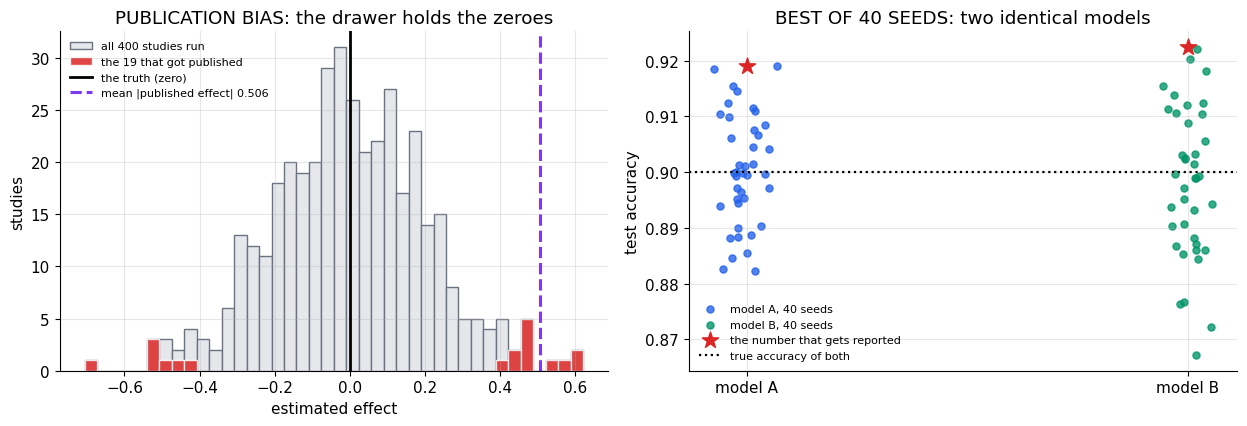

PUBLICATION BIAS
  studies run                       : 400   (true effect = 0.000)
  studies published (p < 0.05)       : 19   (4.8%)
  mean effect across ALL studies    : -0.0000   <- correct
  mean |effect| among PUBLISHED     : +0.5065
  mean |effect| among UNPUBLISHED   : +0.1471
  inflation factor                  : 3.44x
  Every published study is individually correct. The literature is not.

THE ML TWIN -- reporting the best of many runs
  true accuracy of BOTH models      : 0.9000
  model A: mean 0.9003   best of 40 = 0.9190
  model B: mean 0.8986   best of 40 = 0.9225
  headline gap if both report their best : 0.35 percentage points
  headline gap if both report their mean : 0.17 percentage points
  optimism of 'best of 40' over the truth : +2.25 points

  Both models were drawn from the SAME distribution. Any gap between the
  starred points is the maximum of 40 draws talking. Reporting a single
  best run without saying how many were tried is publication bias with
  a smalle

In [75]:
# ============================================================
#  LEFT : 400 studies of an effect that is EXACTLY ZERO. Only p<0.05 publishes.
#  RIGHT: 40 training seeds of two models that are GENUINELY IDENTICAL.
# ============================================================
rngpb = np.random.default_rng(8989)

# ---------- publication bias ----------
N_ST, N_PER = 400, 40
est, pv = [], []
for _ in range(N_ST):
    a = rngpb.normal(0, 1, N_PER)
    b = rngpb.normal(0, 1, N_PER)          # SAME distribution. True effect = 0.
    est.append(b.mean() - a.mean())
    pv.append(welch_p(a, b))
est, pv = np.array(est), np.array(pv)
published = pv < ALPHA

# ---------- the ML twin: best of many seeds ----------
N_SEEDS, TRUE_ACC = 40, 0.900
acc_A = rngpb.normal(TRUE_ACC, 0.012, N_SEEDS)
acc_B = rngpb.normal(TRUE_ACC, 0.012, N_SEEDS)   # identical model, new name
best_A, best_B = acc_A.max(), acc_B.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax1.hist(est, bins=40, color=C_SOFT, edgecolor=C_GREY,
         label=f"all {N_ST} studies run")
ax1.hist(est[published], bins=40, color=C_SLOPE, alpha=0.85, edgecolor="white",
         label=f"the {published.sum()} that got published")
ax1.axvline(0, color="black", lw=2.0, label="the truth (zero)")
ax1.axvline(np.abs(est[published]).mean(), color=C_EXACT, lw=2.2, ls="--",
            label=f"mean |published effect| {np.abs(est[published]).mean():.3f}")
ax1.set_xlabel("estimated effect"); ax1.set_ylabel("studies")
ax1.set_title("PUBLICATION BIAS: the drawer holds the zeroes")
ax1.legend(frameon=False, fontsize=8)

ax2.scatter(np.zeros(N_SEEDS) + rngpb.normal(0, 0.03, N_SEEDS), acc_A,
            s=26, color=C_F, alpha=0.8, label="model A, 40 seeds")
ax2.scatter(np.ones(N_SEEDS) + rngpb.normal(0, 0.03, N_SEEDS), acc_B,
            s=26, color=C_AREA, alpha=0.8, label="model B, 40 seeds")
ax2.scatter([0], [best_A], s=150, marker="*", color=C_SLOPE, zorder=5)
ax2.scatter([1], [best_B], s=150, marker="*", color=C_SLOPE, zorder=5,
            label="the number that gets reported")
ax2.axhline(TRUE_ACC, color="black", lw=1.6, ls=":", label="true accuracy of both")
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["model A", "model B"])
ax2.set_ylabel("test accuracy")
ax2.set_title("BEST OF 40 SEEDS: two identical models")
ax2.legend(frameon=False, fontsize=8)

fig.tight_layout(); plt.show()

print("PUBLICATION BIAS")
print(f"  studies run                       : {N_ST}   (true effect = 0.000)")
print(f"  studies published (p < {ALPHA})       : {published.sum()}"
      f"   ({published.mean():.1%})")
print(f"  mean effect across ALL studies    : {est.mean():+.4f}   <- correct")
print(f"  mean |effect| among PUBLISHED     : {np.abs(est[published]).mean():+.4f}")
print(f"  mean |effect| among UNPUBLISHED   : {np.abs(est[~published]).mean():+.4f}")
print(f"  inflation factor                  : "
      f"{np.abs(est[published]).mean() / np.abs(est[~published]).mean():.2f}x")
print("  Every published study is individually correct. The literature is not.")
print()
print("THE ML TWIN -- reporting the best of many runs")
print(f"  true accuracy of BOTH models      : {TRUE_ACC:.4f}")
print(f"  model A: mean {acc_A.mean():.4f}   best of {N_SEEDS} = {best_A:.4f}")
print(f"  model B: mean {acc_B.mean():.4f}   best of {N_SEEDS} = {best_B:.4f}")
print(f"  headline gap if both report their best : "
      f"{abs(best_A - best_B) * 100:.2f} percentage points")
print(f"  headline gap if both report their mean : "
      f"{abs(acc_A.mean() - acc_B.mean()) * 100:.2f} percentage points")
print(f"  optimism of 'best of {N_SEEDS}' over the truth : "
      f"{(max(best_A, best_B) - TRUE_ACC) * 100:+.2f} points")
print()
print("  Both models were drawn from the SAME distribution. Any gap between the")
print("  starred points is the maximum of 40 draws talking. Reporting a single")
print("  best run without saying how many were tried is publication bias with")
print("  a smaller file drawer.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the estimated effect from 400 studies of something that does not exist. Across all of them the mean is essentially zero — the printed value — which is correct, because the effect is zero. But only the red studies get published, and they are precisely the extreme tails. The mean *published* effect size is printed, along with the inflation factor over the unpublished ones.

Right: 40 training seeds for each of two models drawn from the **same** distribution. The clouds overlap completely; the dotted line is the true accuracy of both. The stars are the best run of each — the numbers that go in the table — and the printed gap between them is manufactured entirely by taking a maximum over 40 draws.

**The common misread:** treating a leaderboard as a ranking of methods. Without the number of runs behind each entry, the top of a leaderboard measures how many attempts each team made at least as much as it measures their method. Report the mean and the spread across seeds; if you report a best, say how many.

</div>

<div style="background-color: #f8d7da; border-left: 5px solid #dc3545; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🤖 Why ML cares

Every trap in this part has an exact machine-learning translation, and each one is committed routinely by people who would never dream of p-hacking a clinical trial.

**Hyperparameter search is multiple comparisons.** Evaluating 200 configurations on a validation set is 200 tests. The winner's validation score is a maximum over 200 draws, so it is optimistic by exactly the mechanism that gave an all-noise study its impressive minimum p-value in 8.1. Its honest score requires a **third** split the search never touched.

**Test-set reuse is optional stopping.** Checking the test set during development, tweaking, and checking again is peeking — and if you stop when the number looks good, it is optional stopping precisely as in 8.3, with the same inflated error rate. The test set is spent the first time you make a decision from it.

**Reporting the best seed is publication bias**, as the right-hand panel above quantified: two identical models separated by a visible margin purely by taking maxima. Report mean and standard deviation across seeds, and state the number of runs.

**Simpson's paradox is aggregate accuracy.** A model can be worse than another on every subgroup and better overall, if the subgroup mix differs. This is not hypothetical — it is how models pass an aggregate benchmark while failing every population in it, and why per-slice evaluation is not optional.

**Survivorship bias is your training set.** Data reaches you because it was logged, labelled, scraped, or retained — each of those a filter. Models trained on completed transactions know nothing about abandoned ones; models trained on approved loans never see the applicants who were refused.

</div>

---

## 8.9 A checklist for reading a statistical claim

Nothing here is exotic. These are the questions that would have caught every trap
in this part, and they are worth asking of your own work first — you are the
person you are best placed to catch.

**About the search**

1. **How many things were tested?** Not how many are reported. If the answer is
   unavailable, treat a p-value near 0.05 as no evidence at all (8.1).
2. **Was the analysis chosen before or after seeing the data?** Subgroups,
   transformations, exclusion rules, covariates — each is a fork (8.2, 8.4).
3. **Was the sample size fixed in advance?** "We stopped when it became
   significant" invalidates the p-value (8.3).
4. **Where are the studies that failed?** If you only ever see successes, you are
   reading a filtered literature (8.8).

**About the data**

5. **How did these rows get into the dataset?** Who or what is missing, and is
   the missingness related to the outcome (8.6)?
6. **Is there a group I have not split by?** Age, site, cohort, time period,
   device — anything that shifts both variables at once (8.5).
7. **Were the extremes selected on the same variable they are measured on?**
   If so, expect regression to the mean and nothing else (Part 7.8).

**About the claim**

8. **Is the effect *size* reported, with an interval — or only a p-value?**
   "Significant" is not a magnitude (Parts 4 and 6).
9. **Does "controlling for X" have a causal argument behind it?** Adjusting for a
   collider is worse than not adjusting (8.7).
10. **Is a causal word doing work that only an association supports?** "Linked
    to", "associated with", "predicts" — then check whether the conclusion
    quietly upgraded it (Part 7.1).
11. **Would the claim be interesting if the sign flipped?** If yes, ask harder;
    findings that are interesting either way are the ones searches produce.

**The one-line version:** *a p-value describes a procedure, not a dataset.* If you
do not know the procedure — how many tests, chosen when, stopped how, published
under what filter — you cannot interpret the number, no matter how small it is.

---

### What Part 8 established

Every trap was built from data with a known truth, usually no effect at all:

- **Multiple comparisons** — 40 pure-noise variables, about two false positives
  per study, and most empty studies reporting a "finding". Bonferroni and BH each
  fixed it, at a measured cost in power.
- **P-hacking** — a garden of defensible choices found significance on a true
  effect of zero in most trials, after a handful of attempts.
- **Optional stopping** — peeking after every observation multiplied the
  false-positive rate several times over, with nothing changed but the stopping
  rule.
- **Forking paths** — the same damage with no search and no intent.
- **Simpson's paradox** — a slope that reversed sign when age was accounted for,
  both numbers correct.
- **Survivorship and selection** — a positive track record built entirely from
  closures, and a correlation manufactured out of two independent variables by a
  filter.
- **Confounding** — adjustment fixing a confounder and, with the identical
  phrase, breaking a collider.
- **Publication bias** — a null literature reporting inflated effects, and its ML
  twin separating two identical models by taking maxima.

**Next → Part 9**, where all of this gets turned into the machinery that keeps
machine learning honest: train/test splits, cross-validation, why the validation
set gets used up, and how to put an error bar on a model score so that two
numbers can be compared without fooling yourself.

---


---

# 9️⃣ Statistics doing ML: train/test, cross-validation, and honest evaluation

Everything in this notebook has been building one habit: **a number computed
from data is an estimate, and an estimate without a range is unfinished.**

This part points that habit at the number machine-learning people care about
most — a model's score.

Here is the whole argument, in one line:

> **A test-set accuracy is a sample mean.** The sample is the test set. The
> population is every input the model will ever see. Everything Parts 1–8 said
> about sample means is therefore true of it, without amendment.

That sounds almost too simple to be worth a part of its own. It is not, because
the consequences are ones the field routinely ignores:

- A test score has a **standard error** (Part 3), so it needs a **confidence
  interval** (Part 4) — and that interval is far wider than the three decimal
  places in most results tables suggest.
- Two models compared on the same test set are a **paired** comparison
  (Part 6), not two independent samples, and pairing them changes the answer.
- Trying twenty models and reporting the best one's test score is **multiple
  comparisons** (Part 8) wearing a lab coat. The winner's score is
  biased upward, and we will measure by exactly how much.

### 9.1 The train/test split as a statistical device

Split your data in two. Fit on one half, score on the other. Everyone knows the
recipe; the interesting question is what each of the two numbers actually
estimates.

We build a small classification problem, fit a logistic regression **by hand**
with gradient descent — no scikit-learn anywhere in this part — and then, using
this notebook's standing trick, check both numbers against a truth we are not
supposed to know.


In [76]:
# ============================================================
#  A classification problem, and a logistic regression fitted BY HAND.
#  Two features. The true boundary is a circle: points near the origin
#  are class 1, points far out are class 0, with genuine noise on top --
#  so even a perfect model cannot score 100%.
# ============================================================
from scipy import stats            # already imported earlier; harmless here

RNG9 = np.random.default_rng(90909)


def make_problem(n, rng):
    """n examples with 2 features and a noisy circular decision boundary."""
    X     = rng.normal(0.0, 1.0, size=(n, 2))
    r2    = X[:, 0] ** 2 + X[:, 1] ** 2
    score = 3.4 * (1.8 - r2) + 1.2 * X[:, 0]     # the TRUE signal
    p     = 1.0 / (1.0 + np.exp(-score))          # true P(class 1 | x)
    y     = (rng.random(n) < p).astype(float)     # the coin flip -- the noise
    return X, y


def poly_features(X, degree):
    """All monomials x1^a * x2^b with 1 <= a+b <= degree. Flexibility knob."""
    cols = []
    for d in range(1, degree + 1):
        for k in range(d + 1):
            cols.append((X[:, 0] ** (d - k)) * (X[:, 1] ** k))
    return np.column_stack(cols)


def design(X, degree, mu=None, sd=None):
    """Features, standardised, with an intercept column glued on the front.
    mu/sd are computed on TRAINING data only and reused everywhere else."""
    Z = poly_features(X, degree)
    if mu is None:
        mu, sd = Z.mean(axis=0), Z.std(axis=0)
        sd = np.where(sd == 0, 1.0, sd)
    Zs = (Z - mu) / sd
    return np.column_stack([np.ones(len(Z)), Zs]), mu, sd


def fit_logistic(Z, y, lr=0.6, iters=1500, l2=1e-3):
    """Gradient descent on the logistic loss. Ten lines, no library."""
    w = np.zeros(Z.shape[1])
    for _ in range(iters):
        p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
        grad = Z.T @ (p - y) / len(y) + l2 * np.r_[0.0, w[1:]]
        w   -= lr * grad
    return w


def correct_flags(w, Z, y):
    """A 0/1 array: was each example classified correctly? THE key object."""
    return ((Z @ w > 0).astype(float) == y).astype(float)


# ---- the three datasets ------------------------------------------------
N_TRAIN, N_TEST = 400, 200
X_tr, y_tr   = make_problem(N_TRAIN, RNG9)
X_te, y_te   = make_problem(N_TEST,  RNG9)
X_or, y_or   = make_problem(40_000,  RNG9)   # the ORACLE set: stands in for
                                             # the population. In real life it
                                             # does not exist.

DEG = 2
Z_tr, MU, SD = design(X_tr, DEG)
Z_te, _, _   = design(X_te, DEG, MU, SD)
Z_or, _, _   = design(X_or, DEG, MU, SD)

w_A = fit_logistic(Z_tr, y_tr)

corr_tr = correct_flags(w_A, Z_tr, y_tr)
corr_te = correct_flags(w_A, Z_te, y_te)
corr_or = correct_flags(w_A, Z_or, y_or)

acc_tr, acc_te, ACC_TRUE = corr_tr.mean(), corr_te.mean(), corr_or.mean()

print(f"model: logistic regression, degree-{DEG} features, "
      f"{Z_tr.shape[1]} weights, fitted by gradient descent")
print()
print(f"  training accuracy  ({N_TRAIN:>5} examples) = {acc_tr:.4f}")
print(f"  TEST accuracy      ({N_TEST:>5} examples) = {acc_te:.4f}   <- what gets reported")
print(f"  TRUE accuracy      ({len(y_or):>5} examples) = {ACC_TRUE:.4f}   <- normally UNKNOWABLE")
print()
print(f"  test score minus truth = {acc_te - ACC_TRUE:+.4f}")
print()
print("The test score missed the truth. Not by much, and not because anything")
print("went wrong -- 200 examples is a sample, and samples wobble. Part 3.")


model: logistic regression, degree-2 features, 6 weights, fitted by gradient descent

  training accuracy  (  400 examples) = 0.9350
  TEST accuracy      (  200 examples) = 0.8950   <- what gets reported
  TRUE accuracy      (40000 examples) = 0.9128   <- normally UNKNOWABLE

  test score minus truth = -0.0178

The test score missed the truth. Not by much, and not because anything
went wrong -- 200 examples is a sample, and samples wobble. Part 3.


/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: divide by zero encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: overflow encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: invalid value encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:54: RuntimeWarning: divide by zero encountered in matmul
  return ((Z @ w > 0).astype(float) == y).astype(float)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:54: RuntimeWarning: overflow encountered in matmul
  return ((Z @ w > 0).astype(float) == y).astype(float)
/var/fo

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Training accuracy** is how often the model gets right the very examples it was tuned on. It is not an estimate of anything you want, because the model already saw the answers. A model with enough parameters can drive it to 100% by memorising, which tells you nothing about a new example.

**Test accuracy** is how often the model gets right examples it has never seen. That *is* an estimate of what you want — and, crucially, it is a **sample mean**: take the 0/1 array `corr_te` (1 = correct), average it. It is $\bar{x}$ from Part 0, computed on a sample of size $n_{\text{test}}$.

**True accuracy** is the population parameter $\mu$ — the fraction the model would get right over all possible inputs. Only this notebook has it, because only this notebook can generate 40,000 more examples on demand.

Compare the two printed numbers. Whatever gap you see is a modest one, because this model has only a handful of weights and four hundred training examples to pin them down — there is very little room to memorise. Give the model more flexibility and that gap becomes a chasm, which is the next cell.

</div>

/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:54: RuntimeWarning: divide by zero encountered in matmul
  return ((Z @ w > 0).astype(float) == y).astype(float)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:54: RuntimeWarning: overflow encountered in matmul
  return ((Z @ w > 0).astype(float) == y).astype(float)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:54: RuntimeWarning: invalid value encountered in matmul
  return ((Z @ w > 0).astype(float) == y).astype(float)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: divide by zero encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: overflow encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
/var/folders/mz/9z30xzjs

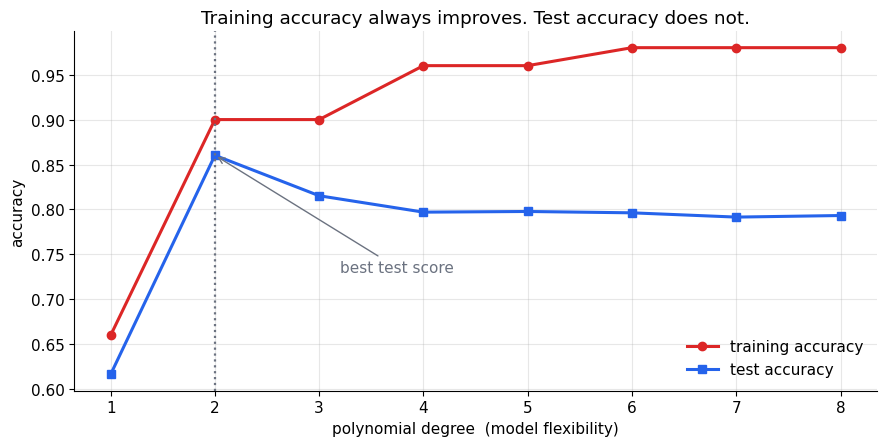

 degree  weights   train    test     gap
      1        3   0.660   0.617   +0.043
      2        6   0.900   0.860   +0.040
      3       10   0.900   0.815   +0.085
      4       15   0.960   0.797   +0.163
      5       21   0.960   0.798   +0.162
      6       28   0.980   0.796   +0.184
      7       36   0.980   0.791   +0.189
      8       45   0.980   0.793   +0.187

training accuracy from degree 1 to 8: 0.660 -> 0.980
test     accuracy from degree 1 to 8: 0.617 -> 0.793
best test score at degree 2; the most flexible model is 0.067 worse.


In [77]:
# ============================================================
#  Turn the flexibility knob and watch the two curves separate.
#  Small training set (50), so the effect is unmistakable.
# ============================================================
RNG_OF = np.random.default_rng(77)
X_small, y_small = make_problem(50,   RNG_OF)     # a realistically small study
X_eval,  y_eval  = make_problem(4000, RNG_OF)     # a big honest test set

degrees, tr_curve, te_curve, n_params = [], [], [], []
for deg in range(1, 9):
    Zs, mu_s, sd_s = design(X_small, deg)
    Ze, _, _       = design(X_eval,  deg, mu_s, sd_s)
    w              = fit_logistic(Zs, y_small, lr=0.6, iters=4000, l2=1e-6)
    degrees.append(deg)
    n_params.append(Zs.shape[1])
    tr_curve.append(correct_flags(w, Zs, y_small).mean())
    te_curve.append(correct_flags(w, Ze, y_eval).mean())

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(degrees, tr_curve, "o-", color=C_SLOPE, lw=2.2, label="training accuracy")
ax.plot(degrees, te_curve, "s-", color=C_F,     lw=2.2, label="test accuracy")
best = int(np.argmax(te_curve))
ax.axvline(degrees[best], color=C_GREY, ls=":", lw=1.6)
ax.annotate("best test score", xy=(degrees[best], te_curve[best]),
            xytext=(degrees[best] + 1.2, te_curve[best] - 0.13),
            arrowprops=dict(arrowstyle="->", color=C_GREY), color=C_GREY)
ax.set_xlabel("polynomial degree  (model flexibility)")
ax.set_ylabel("accuracy")
ax.set_title("Training accuracy always improves. Test accuracy does not.")
ax.legend(frameon=False); fig.tight_layout(); plt.show()

print(" degree  weights   train    test     gap")
for d, k, a, b in zip(degrees, n_params, tr_curve, te_curve):
    print(f" {d:6d} {k:8d}   {a:.3f}   {b:.3f}   {a - b:+.3f}")
print()
print(f"training accuracy from degree 1 to 8: {tr_curve[0]:.3f} -> {tr_curve[-1]:.3f}")
print(f"test     accuracy from degree 1 to 8: {te_curve[0]:.3f} -> {te_curve[-1]:.3f}")
print(f"best test score at degree {degrees[best]}; "
      f"the most flexible model is {te_curve[best] - te_curve[-1]:.3f} worse.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Two curves, one knob. As the polynomial degree rises the model gains weights, and the red curve — accuracy on the 50 examples it was fitted to — climbs steadily towards perfect. It has to: more weights means more capacity to bend around the training points, and eventually to memorise them outright.

The blue curve is accuracy on 4,000 examples the model never saw. It rises while the extra flexibility is buying real structure (the true boundary is a circle, so it needs squared terms), peaks, and then **falls** — the extra weights are now fitting the noise in those particular 50 points, and noise does not repeat. The widening gap in the printed table is the entire phenomenon of overfitting, in one column.

**The common misread:** treating the red curve as a performance report. It is not a measurement of the model at all, it is a measurement of how much the model was allowed to memorise. Two models with identical training accuracy can differ enormously on new data, and a training accuracy of 100% is a warning light rather than an achievement.

</div>

### Your test score is a sample statistic, so give it an interval

The test set has $n_{\text{test}}$ examples. Each one is either classified
correctly or not — a 0 or a 1. Accuracy is the mean of those zeros and ones.

That is exactly the setting of Parts 3 and 4, with one simplification: for 0/1
data the standard deviation is determined by the mean, since a variable that
takes only the values 0 and 1 with probability $p$ of being 1 has variance
$p(1-p)$. So the standard error of an accuracy is

$$\text{SE}(\hat{p}) \;=\; \sqrt{\frac{\hat{p}\,(1-\hat{p})}{n_{\text{test}}}}$$

and the 95% interval is $\hat{p} \pm 1.96 \times \text{SE}$, by the Central
Limit Theorem argument of Part 3 — nothing new is being assumed here.

We compute it two ways, exactly as Part 4 taught: the **normal-approximation
formula**, and the **bootstrap**, which assumes nothing about the shape at all
and simply resamples the 0/1 array. Part 4's `bootstrap_ci` works unchanged.


In [78]:
# ============================================================
#  A confidence interval on a model score -- two ways.
#  corr_te is a 0/1 array of length 200. Accuracy is its mean.
#  This is Part 4 applied to a machine-learning number, unaltered.
# ============================================================
p_hat = corr_te.mean()
n_t   = len(corr_te)

# --- 1. normal approximation (Part 4, formula route) -------------------
se_acc  = np.sqrt(p_hat * (1 - p_hat) / n_t)
z       = stats.norm.ppf(0.975)                 # = z_crit from Part 4
lo_n, hi_n = p_hat - z * se_acc, p_hat + z * se_acc

# --- 2. bootstrap (Part 4, no-assumptions route) -----------------------
(lo_b, hi_b), boot_acc = bootstrap_ci(corr_te, statistic=np.mean,
                                      B=10_000, conf=0.95, rng=RNG9)

print(f"test set of n = {n_t}, {int(corr_te.sum())} correct")
print(f"accuracy  p-hat = {p_hat:.4f}")
print(f"standard error  = {se_acc:.4f}   (= sqrt(p(1-p)/n))")
print()
print(f"  95% CI, normal approximation : [{lo_n:.4f}, {hi_n:.4f}]   "
      f"width {100 * (hi_n - lo_n):5.2f} percentage points")
print(f"  95% CI, percentile bootstrap : [{lo_b:.4f}, {hi_b:.4f}]   "
      f"width {100 * (hi_b - lo_b):5.2f} percentage points")
print()
print(f"the model's TRUE accuracy is {ACC_TRUE:.4f}")
print(f"  inside the normal interval?    {bool(lo_n <= ACC_TRUE <= hi_n)}")
print(f"  inside the bootstrap interval? {bool(lo_b <= ACC_TRUE <= hi_b)}")
print()
print("Two completely different arguments -- an algebraic one and a")
print("resampling one -- landing in the same place. That agreement is the")
print("evidence that neither is an artefact of its own assumptions.")


test set of n = 200, 179 correct
accuracy  p-hat = 0.8950
standard error  = 0.0217   (= sqrt(p(1-p)/n))

  95% CI, normal approximation : [0.8525, 0.9375]   width  8.50 percentage points
  95% CI, percentile bootstrap : [0.8500, 0.9350]   width  8.50 percentage points

the model's TRUE accuracy is 0.9128
  inside the normal interval?    True
  inside the bootstrap interval? True

Two completely different arguments -- an algebraic one and a
resampling one -- landing in the same place. That agreement is the
evidence that neither is an artefact of its own assumptions.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

The interval says: **if you had drawn a different test set of the same size from the same source, and rebuilt the interval each time, 95% of those intervals would contain the model's true accuracy.**

It does *not* say there is a 95% probability that the true accuracy lies in this particular interval — the true accuracy is a fixed number, and this particular interval either contains it or does not. That distinction was Part 4's, and it does not soften just because the quantity is now a model score.

The practical reading is simpler and still useful: **any true accuracy inside this range would produce a test score like the one you saw without anything unusual happening.** Which is why a competitor whose score falls inside your interval has not been beaten.

</div>

In [79]:
# ============================================================
#  Does the interval actually work? Part 4's coverage check,
#  run on a model score. We can do this because we can draw
#  fresh test sets from the oracle pool all day.
# ============================================================
TRIALS9 = 2_000
scores_v = np.empty(TRIALS9)
lo_v = np.empty(TRIALS9); hi_v = np.empty(TRIALS9)      # the usual ("Wald") one
lo_w = np.empty(TRIALS9); hi_w = np.empty(TRIALS9)      # Wilson

for i in range(TRIALS9):
    idx  = RNG9.choice(len(corr_or), n_t, replace=False)   # a fresh test set
    ph   = corr_or[idx].mean()
    scores_v[i] = ph

    s = np.sqrt(ph * (1 - ph) / n_t)                       # the usual formula
    lo_v[i], hi_v[i] = ph - z * s, ph + z * s

    # Wilson: ask which values of p the data would NOT reject, instead of
    # pacing out a fixed distance either side of p-hat.
    denom  = 1 + z ** 2 / n_t
    centre = (ph + z ** 2 / (2 * n_t)) / denom
    hw     = z * np.sqrt(ph * (1 - ph) / n_t + z ** 2 / (4 * n_t ** 2)) / denom
    lo_w[i], hi_w[i] = centre - hw, centre + hw

cov_wald   = float(((lo_v <= ACC_TRUE) & (ACC_TRUE <= hi_v)).mean())
cov_wilson = float(((lo_w <= ACC_TRUE) & (ACC_TRUE <= hi_w)).mean())
mc_se9     = np.sqrt(cov_wald * (1 - cov_wald) / TRIALS9)

print(f"{TRIALS9:,} independent test sets of {n_t}, one 95% interval each.")
print(f"  the model's true accuracy                 = {ACC_TRUE:.4f}")
print(f"  nominal claim                             = 95.000%")
print(f"  Monte-Carlo uncertainty on a coverage     = +/- {1.96 * mc_se9:.3%}")
print()
print(f"  coverage of the normal ('Wald') interval  = {cov_wald:.3%}")
print(f"  coverage of the Wilson interval           = {cov_wilson:.3%}")
print()
print(f"  spread of the {TRIALS9:,} test scores (sd)      = {scores_v.std(ddof=1):.4f}")
print(f"  our one test set's formula SE             = {se_acc:.4f}")
print(f"  the same formula at the TRUE accuracy     = "
      f"{np.sqrt(ACC_TRUE * (1 - ACC_TRUE) / n_t):.4f}")
print()
if abs(cov_wald - 0.95) < 1.96 * mc_se9:
    print("The Wald interval's coverage matches its claim within Monte-Carlo")
    print("error. It does what it says on the tin.")
else:
    print(f"The Wald interval caught the truth {cov_wald:.1%} of the time, not 95%,")
    print("and the shortfall is bigger than Monte-Carlo error. This is a known")
    print("defect rather than a bug in this cell: centring an interval on p-hat")
    print("misbehaves when p is close to 0 or 1, and a 91% accuracy is close")
    print("enough for it to show. The Wilson interval's coverage above is the")
    print("evidence that the fix works.")
print()
print("Which is exactly why the check is worth running. The interval everyone")
print("is taught first is mildly optimistic precisely where model scores live.")


2,000 independent test sets of 200, one 95% interval each.
  the model's true accuracy                 = 0.9128
  nominal claim                             = 95.000%
  Monte-Carlo uncertainty on a coverage     = +/- 1.092%

  coverage of the normal ('Wald') interval  = 93.350%
  coverage of the Wilson interval           = 96.550%

  spread of the 2,000 test scores (sd)      = 0.0195
  our one test set's formula SE             = 0.0217
  the same formula at the TRUE accuracy     = 0.0200

The Wald interval caught the truth 93.3% of the time, not 95%,
and the shortfall is bigger than Monte-Carlo error. This is a known
defect rather than a bug in this cell: centring an interval on p-hat
misbehaves when p is close to 0 or 1, and a 91% accuracy is close
enough for it to show. The Wilson interval's coverage above is the
evidence that the fix works.

Which is exactly why the check is worth running. The interval everyone
is taught first is mildly optimistic precisely where model scores live.


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The 95% interval was **not** taken on trust. We drew thousands of fresh test sets, built the interval each time, and counted how often it caught the true accuracy. The printed coverage is what the method actually delivers, and it is compared against the 95% it promises with the Monte-Carlo uncertainty attached, so you can tell a real discrepancy from simulation noise.

It also caught something worth catching. The textbook interval $\hat{p} \pm 1.96\,\text{SE}$ is known to cover slightly less often than it promises when $p$ is near 0 or 1 — and model accuracies live near 1 almost by definition. So the cell computes the **Wilson** interval alongside it, which asks which values of $p$ the data would not reject rather than stepping a fixed distance either side of $\hat{p}$, and prints both coverages so the difference is visible instead of asserted.

The last group of numbers is the same claim from the other direction: the observed spread of thousands of test scores, against the standard error the formula predicts from a *single* test set, and against that formula evaluated at the true accuracy. The formula is guessing the width of a distribution it never gets to see, and the guess is checkable.

</div>

a model that scores 90% on a test set of n examples:

      n     95% interval          width (pct points)
     25    [0.782, 1.018]       23.52
     50    [0.817, 0.983]       16.63
    100    [0.841, 0.959]       11.76
    200    [0.858, 0.942]        8.32   <-- the usual size
    500    [0.874, 0.926]        5.26
  1,000    [0.881, 0.919]        3.72
  2,000    [0.887, 0.913]        2.63
  5,000    [0.892, 0.908]        1.66
 20,000    [0.896, 0.904]        0.83

 90% accuracy on 200 test examples
   95% CI    = [0.8584, 0.9416]
   width     = 8.32 percentage points

So on 200 examples, 90% and 86% are not distinguishable, and neither
are 90% and 94%. A leaderboard reporting three decimal places on a
test set this size is reporting two decimal places of noise.

To pin 90% accuracy to +/- 1 percentage point you need n = 3,458 test examples.

Look at the top row: its upper end is 1.018, i.e. above
100% accuracy, which is impossible. That is the same defect the coverage
check just foun

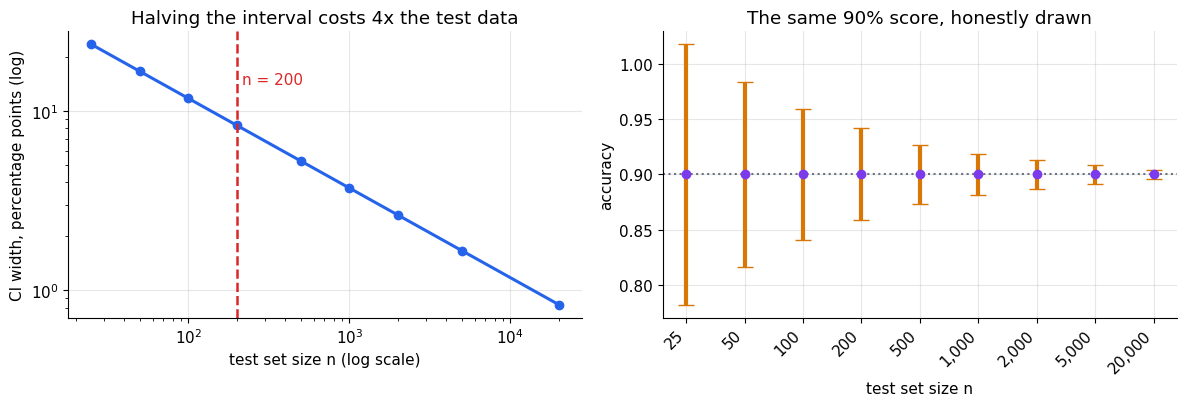

In [80]:
# ============================================================
#  How wide is that interval, really? The answer people find
#  uncomfortable. Held at 90% accuracy, varying test-set size.
# ============================================================
P_REF = 0.90
ns    = np.array([25, 50, 100, 200, 500, 1_000, 2_000, 5_000, 20_000])
half  = z * np.sqrt(P_REF * (1 - P_REF) / ns)

print(f"a model that scores {P_REF:.0%} on a test set of n examples:")
print()
print("      n     95% interval          width (pct points)")
for n_i, h in zip(ns, half):
    mark = "   <-- the usual size" if n_i == 200 else ""
    print(f" {n_i:6,}    [{P_REF - h:.3f}, {P_REF + h:.3f}]      "
          f"{200 * h:6.2f}{mark}")

h200 = z * np.sqrt(P_REF * (1 - P_REF) / 200)
print()
print("=" * 62)
print(f" 90% accuracy on 200 test examples")
print(f"   95% CI    = [{P_REF - h200:.4f}, {P_REF + h200:.4f}]")
print(f"   width     = {200 * h200:.2f} percentage points")
print("=" * 62)
print()
print("So on 200 examples, 90% and 86% are not distinguishable, and neither")
print("are 90% and 94%. A leaderboard reporting three decimal places on a")
print("test set this size is reporting two decimal places of noise.")
print()
n_for = int(np.ceil(P_REF * (1 - P_REF) * (z / 0.01) ** 2))
print(f"To pin {P_REF:.0%} accuracy to +/- 1 percentage point you need "
      f"n = {n_for:,} test examples.")
print()
print(f"Look at the top row: its upper end is {P_REF + half[0]:.3f}, i.e. above")
print("100% accuracy, which is impossible. That is the same defect the coverage")
print("check just found, showing itself more crudely. At small n use the Wilson")
print("interval, which cannot leave the range 0 to 1.")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2))

axL.plot(ns, 200 * half, "o-", color=C_F, lw=2.2)
axL.set_xscale("log"); axL.set_yscale("log")
axL.axvline(200, color=C_SLOPE, ls="--", lw=1.8)
axL.text(215, 200 * half[0] * 0.6, "n = 200", color=C_SLOPE)
axL.set_xlabel("test set size n (log scale)")
axL.set_ylabel("CI width, percentage points (log)")
axL.set_title("Halving the interval costs 4x the test data")

order = np.argsort(ns)
axR.errorbar(np.arange(len(ns)), np.full(len(ns), P_REF), yerr=half[order],
             fmt="o", color=C_EXACT, ecolor=C_APPROX, elinewidth=3, capsize=6)
axR.set_xticks(np.arange(len(ns)))
axR.set_xticklabels([f"{v:,}" for v in ns[order]], rotation=45, ha="right")
axR.axhline(P_REF, color=C_GREY, ls=":", lw=1.5)
axR.set_ylabel("accuracy")
axR.set_xlabel("test set size n")
axR.set_title("The same 90% score, honestly drawn")

fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: interval width against test-set size, both axes logarithmic, so the straight line is the $1/\sqrt{n}$ law from Part 3 seen edge-on. Its slope means what it always meant — to halve your error bar you need four times the test data. There is no cleverness that gets around this; it is a property of averaging, not of the model.

Right: the identical score of 90%, drawn nine times with the error bar it actually earns at each sample size. The dot never moves. Only the honesty moves. At the sizes most papers and most internal reports use, the bar is tall enough to swallow the differences those reports are arguing about.

**The common misread:** assuming that because the *training* set is large, the score is precise. The interval depends only on $n_{\text{test}}$. A model trained on ten million examples and tested on two hundred has a test score as vague as any other model tested on two hundred.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Reporting a test score with no interval attached.**

A sentence of the form "our model achieves X% accuracy", carrying neither a test-set size nor an interval, is not a result — it is half of one. The other half is $n_{\text{test}}$ and the interval that follows from it, and without them the reader cannot tell a genuine improvement from a coin-flip.

The habit is worth making mechanical. Whenever you write down a score, write down the size of the set it came from in the same breath, and if either the score or the size is missing from someone else's table, treat the comparison in that table as unproven rather than as established. This is the same discipline Part 4 asked for when reporting a mean; nothing about the quantity being a model score earns it an exemption.

</div>

### 9.2 Cross-validation: a better estimate from limited data

The single split has an obvious inefficiency. Every example you put in the test
set is an example the model could not learn from, and every example you keep for
training is one you cannot score on. With a few hundred examples that trade-off
bites hard: a test set big enough to give a usable interval is a test set big
enough to noticeably weaken the model.

**$k$-fold cross-validation** refuses the trade. Cut the data into $k$ equal
parts. Hold out part 1, train on the other $k-1$, score on part 1. Then hold out
part 2, and so on. After $k$ rounds every example has been scored exactly once
by a model that never saw it, and every example has also been used for training
$k-1$ times.

The output is not one number but $k$ of them, and the second most useful thing
in this part is the claim that **the spread of those $k$ numbers is information,
not an inconvenience to be averaged away.** Two model families with the same
mean fold score and very different fold spreads are not equally good bets.


5-fold cross-validation on the 400 training examples
(each fold holds out 80 examples)

  fold 1:  0.9500  ################################################
  fold 2:  0.9250  ##############################################
  fold 3:  0.9375  ###############################################
  fold 4:  0.8875  ############################################
  fold 5:  0.9500  ################################################

  mean across folds     = 0.9300
  sd   across folds     = 0.0259
  worst fold            = 0.8875
  best  fold            = 0.9500
  spread (best - worst) = 0.0625

  single-split test score (Part 9.1) = 0.8950
  true accuracy                      = 0.9128


/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: divide by zero encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: overflow encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: invalid value encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)


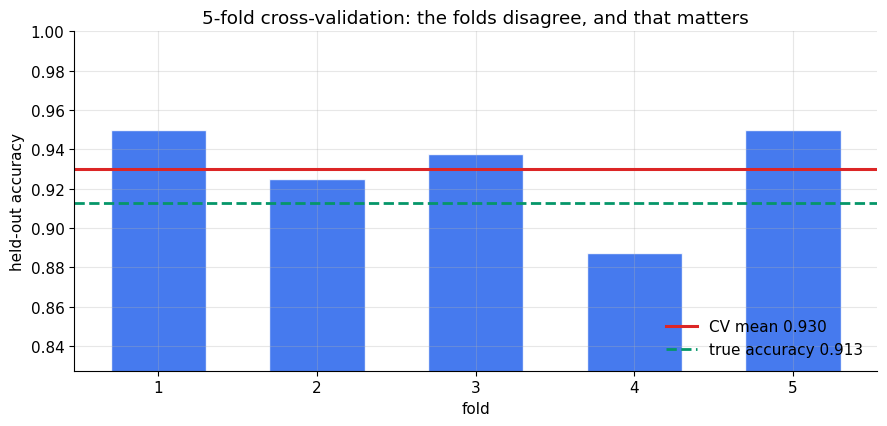

In [81]:
# ============================================================
#  k-fold cross-validation, written out by hand. No library.
# ============================================================
K_FOLDS = 5


def cross_val_scores(X, y, degree=2, k=K_FOLDS, rng=None, iters=600):
    """Return the k held-out accuracies. Each fold: train on k-1, score on 1."""
    n     = len(y)
    order = rng.permutation(n)                 # shuffle, or folds inherit order
    folds = np.array_split(order, k)
    out   = []
    for f in folds:
        held         = np.zeros(n, dtype=bool); held[f] = True
        Zt, mu_f, sd_f = design(X[~held], degree)          # fit scaling on TRAIN
        Zh, _, _       = design(X[held],  degree, mu_f, sd_f)
        w              = fit_logistic(Zt, y[~held], iters=iters)
        out.append(correct_flags(w, Zh, y[held]).mean())
    return np.array(out)


RNG_CV = np.random.default_rng(2024)
fold_scores = cross_val_scores(X_tr, y_tr, degree=DEG, rng=RNG_CV)

cv_mean = fold_scores.mean()
cv_sd   = fold_scores.std(ddof=1)

print(f"{K_FOLDS}-fold cross-validation on the {N_TRAIN} training examples")
print(f"(each fold holds out {N_TRAIN // K_FOLDS} examples)")
print()
for i, s in enumerate(fold_scores, 1):
    bar = "#" * int(round(s * 50))
    print(f"  fold {i}:  {s:.4f}  {bar}")
print()
print(f"  mean across folds     = {cv_mean:.4f}")
print(f"  sd   across folds     = {cv_sd:.4f}")
print(f"  worst fold            = {fold_scores.min():.4f}")
print(f"  best  fold            = {fold_scores.max():.4f}")
print(f"  spread (best - worst) = {fold_scores.max() - fold_scores.min():.4f}")
print()
print(f"  single-split test score (Part 9.1) = {acc_te:.4f}")
print(f"  true accuracy                      = {ACC_TRUE:.4f}")

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(np.arange(1, K_FOLDS + 1), fold_scores, color=C_F, alpha=0.85,
       edgecolor="white", width=0.6)
ax.axhline(cv_mean, color=C_SLOPE, lw=2.2, label=f"CV mean {cv_mean:.3f}")
ax.axhline(ACC_TRUE, color=C_AREA, lw=2.0, ls="--",
           label=f"true accuracy {ACC_TRUE:.3f}")
ax.set_ylim(min(fold_scores.min(), ACC_TRUE) - 0.06, 1.0)
ax.set_xlabel("fold"); ax.set_ylabel("held-out accuracy")
ax.set_title(f"{K_FOLDS}-fold cross-validation: the folds disagree, and that matters")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Five bars, one per fold, each an honest held-out score from a model that never saw the examples it was graded on. The red line is their mean — the cross-validated estimate — and the dashed green line is the true accuracy we are allowed to peek at.

The bars are not level, and the printed spread between best and worst fold is the number to look at. Nothing about the model changed between folds; the only thing that changed was which eighty examples were held out. So that spread is a direct readout of how much this estimate depends on the luck of the split — which is precisely the uncertainty a single train/test split hides from you by only ever showing one bar.

**The common misread:** reading the tallest bar as evidence the model can reach that score, or the shortest as evidence it is broken. Neither fold is more real than the others. The fold-to-fold variation is sampling noise of exactly the kind Part 3 described, and the honest summary is the mean together with the spread, never a fold you liked the look of.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

Cross-validation estimates **how well this training procedure does on unseen data, given roughly this much data** — note that it is the procedure, not one fitted model, that is being scored. Each fold produces a different fitted model, and it is their common recipe that the mean describes.

Why bother instead of a single split? Two reasons, and they pull in the same direction. Every example gets used for training in $k-1$ of the $k$ rounds, so no data is wasted on being permanently held out; and every example gets scored exactly once, so the estimate is based on the whole dataset rather than on one arbitrary slice of it.

The price is compute — you fit $k$ models instead of one — and a subtlety about the uncertainty that the next cell measures rather than asserts.

</div>

/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: divide by zero encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: overflow encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: invalid value encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)


120 independent datasets of 300, 5-fold CV on each.

  TRUE standard error of the CV estimate
    = sd of the 120 CV means            = 0.0187
  NAIVE standard error from within one dataset
    = average of sd(folds)/sqrt(k)          = 0.0156

  ratio naive / true = 0.83

The naive formula UNDERSTATES the real uncertainty by 17%.
Intervals built from it would be too narrow, and would catch the
truth less often than they claim to.

WHY: the k training sets overlap heavily -- with k = 5 any two of them
share 3/4 of their examples -- so the fold scores are correlated, not
independent. Dividing by sqrt(k) is a move that only works for
independent things (Part 3). Here it is not licensed.


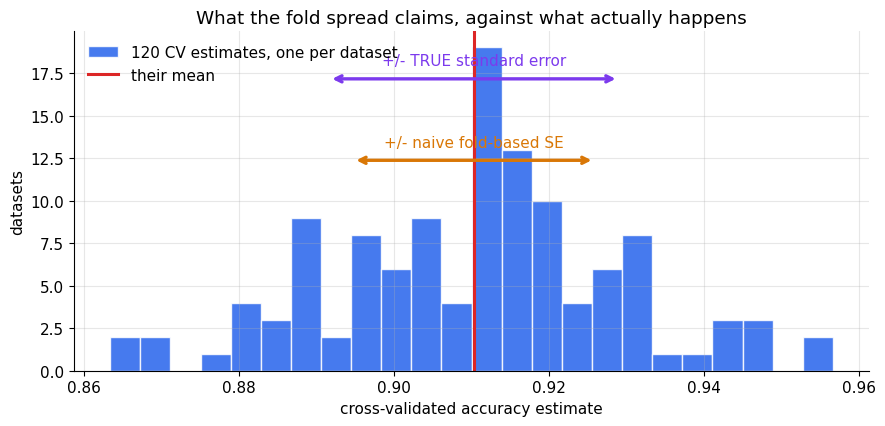

In [82]:
# ============================================================
#  Is sd_folds / sqrt(k) a standard error? Let us find out
#  the only honest way: repeat the whole exercise on many
#  fresh datasets and look at how much the CV estimate really
#  moves. That is the true standard error, by definition.
# ============================================================
N_DATASETS = 120
N_EACH     = 300
RNG_HON    = np.random.default_rng(31)

cv_means, naive_ses = [], []
for _ in range(N_DATASETS):
    Xd, yd = make_problem(N_EACH, RNG_HON)              # a brand-new dataset
    sc     = cross_val_scores(Xd, yd, degree=DEG, rng=RNG_HON, iters=600)
    cv_means.append(sc.mean())
    naive_ses.append(sc.std(ddof=1) / np.sqrt(K_FOLDS))  # the tempting formula

cv_means  = np.array(cv_means)
naive_ses = np.array(naive_ses)

true_se  = cv_means.std(ddof=1)      # how much the CV estimate ACTUALLY moves
naive_se = naive_ses.mean()          # what the fold sd would have told you

print(f"{N_DATASETS} independent datasets of {N_EACH}, "
      f"{K_FOLDS}-fold CV on each.")
print()
print(f"  TRUE standard error of the CV estimate")
print(f"    = sd of the {N_DATASETS} CV means            = {true_se:.4f}")
print(f"  NAIVE standard error from within one dataset")
print(f"    = average of sd(folds)/sqrt(k)          = {naive_se:.4f}")
print()
print(f"  ratio naive / true = {naive_se / true_se:.2f}")
print()
if naive_se < true_se:
    print(f"The naive formula UNDERSTATES the real uncertainty by "
          f"{100 * (1 - naive_se / true_se):.0f}%.")
    print("Intervals built from it would be too narrow, and would catch the")
    print("truth less often than they claim to.")
else:
    print("On this problem the naive formula did not come out smaller.")
    print("Reported as measured. The theoretical objection below still stands:")
    print("there is no general guarantee in either direction.")
print()
print("WHY: the k training sets overlap heavily -- with k = 5 any two of them")
print("share 3/4 of their examples -- so the fold scores are correlated, not")
print("independent. Dividing by sqrt(k) is a move that only works for")
print("independent things (Part 3). Here it is not licensed.")

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(cv_means, bins=24, color=C_F, alpha=0.85, edgecolor="white",
        label=f"{N_DATASETS} CV estimates, one per dataset")
ax.axvline(cv_means.mean(), color=C_SLOPE, lw=2.2, label="their mean")
ymax = ax.get_ylim()[1]
ax.annotate("", xy=(cv_means.mean() - true_se, ymax * 0.86),
            xytext=(cv_means.mean() + true_se, ymax * 0.86),
            arrowprops=dict(arrowstyle="<->", color=C_EXACT, lw=2.4))
ax.text(cv_means.mean(), ymax * 0.90, "+/- TRUE standard error",
        color=C_EXACT, ha="center")
ax.annotate("", xy=(cv_means.mean() - naive_se, ymax * 0.62),
            xytext=(cv_means.mean() + naive_se, ymax * 0.62),
            arrowprops=dict(arrowstyle="<->", color=C_APPROX, lw=2.4))
ax.text(cv_means.mean(), ymax * 0.66, "+/- naive fold-based SE",
        color=C_APPROX, ha="center")
ax.set_xlabel("cross-validated accuracy estimate")
ax.set_ylabel("datasets")
ax.set_title("What the fold spread claims, against what actually happens")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout(); plt.show()


<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

This is the claim tested rather than repeated. The textbook worry is that $\text{sd}_{\text{folds}}/\sqrt{k}$ is not a valid standard error because the folds are not independent. Rather than assert it, we generated many fresh datasets, ran the whole cross-validation on each, and measured **how much the cross-validated estimate actually moves from dataset to dataset** — which is what a standard error is defined to be — then compared that against what the fold spread would have predicted from inside a single dataset.

The printed ratio is the verdict, and the two arrows on the histogram are the same verdict drawn to scale: one arrow is the real spread of the estimate, the other is the width the naive formula would have you report.

This is not a small technicality. Bengio and Grinsztajn (2004) proved there is **no unbiased estimator of the variance of $k$-fold cross-validation** computable from a single run — the problem is structural, not a matter of picking a better formula.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Treating the cross-validation fold standard deviation as a standard error.**

It is extremely tempting: you have $k$ numbers, you have a formula for turning $k$ numbers into a standard error, the shapes fit. But $\text{se} = s/\sqrt{k}$ was derived in Part 3 for $k$ **independent** observations, and cross-validation folds are anything but — with $k=5$, any two training sets overlap in three quarters of their examples, and with leave-one-out they overlap in nearly all of them.

What to do instead. Report the mean and the fold spread as a **description** of the folds, which is honest and genuinely informative, and say so. If you need a real interval on model performance, get it from a held-out test set of known size, where the examples genuinely are independent and Part 4's machinery applies without excuses. And if you are comparing two models, use the paired test in the next section, which sidesteps the question entirely by working on per-example agreements rather than on fold summaries.

</div>

### 9.3 Is model A better than model B?

This is the question Part 0 promised you would be able to answer, and it is
where the whole notebook converges.

Two models, one test set, a small gap between their scores. The wrong move is to
declare the higher number the winner. The second-wrong move is to run a
two-sample test as though the two scores came from two unrelated groups of
people — because they did not. **Both models were evaluated on the very same
examples**, which makes this a paired comparison in the exact sense of Part 6,
and pairing is not a technicality: it removes the variation caused by some test
examples simply being harder than others, which is usually the largest source of
noise in the comparison.

The paired object is per-example: for each test example, did model A get it
right, did model B, or did they differ? Only the examples where they **disagree**
carry any information about which is better, and there are always far fewer of
those than people expect.


In [83]:
# ============================================================
#  Model A: degree-2 logistic on all 400 training examples.
#  Model B: the same recipe on only 100 of them -- genuinely
#           a bit worse, but only a bit. A realistic close call.
#  Model C: heavily over-regularised. Genuinely much worse.
# ============================================================
RNG_AB = np.random.default_rng(4)

idx_B  = RNG_AB.choice(N_TRAIN, 100, replace=False)
Z_B, mu_B, sd_B = design(X_tr[idx_B], DEG)
w_B    = fit_logistic(Z_B, y_tr[idx_B])

Z_C, mu_C, sd_C = design(X_tr, DEG)
w_C    = fit_logistic(Z_C, y_tr, l2=1.0)          # crushed by regularisation

def flags_on(w, mu_, sd_, X, y, degree=DEG):
    Z, _, _ = design(X, degree, mu_, sd_)
    return correct_flags(w, Z, y)

cor_A = corr_te                                          # already computed
cor_B = flags_on(w_B, mu_B, sd_B, X_te, y_te)
cor_C = flags_on(w_C, mu_C, sd_C, X_te, y_te)

true_A = ACC_TRUE
true_B = flags_on(w_B, mu_B, sd_B, X_or, y_or).mean()
true_C = flags_on(w_C, mu_C, sd_C, X_or, y_or).mean()

print(f"on the SAME test set of {n_t} examples")
print(f"  model A  test {cor_A.mean():.4f}   (true {true_A:.4f})")
print(f"  model B  test {cor_B.mean():.4f}   (true {true_B:.4f})")
print(f"  model C  test {cor_C.mean():.4f}   (true {true_C:.4f})")
print()
print(f"  A - B on the test set = {100 * (cor_A.mean() - cor_B.mean()):+.2f} percentage points")
print(f"  A - B in TRUTH        = {100 * (true_A - true_B):+.2f} percentage points")
print()

# --- the paired 2x2 table: this is the whole comparison ---------------
both  = int(((cor_A == 1) & (cor_B == 1)).sum())
onlyA = int(((cor_A == 1) & (cor_B == 0)).sum())
onlyB = int(((cor_A == 0) & (cor_B == 1)).sum())
neither = int(((cor_A == 0) & (cor_B == 0)).sum())

print("  the paired table for A vs B (every test example lands in one box):")
print("                          B right   B wrong")
print(f"      A right          {both:8d}  {onlyA:8d}")
print(f"      A wrong          {onlyB:8d}  {neither:8d}")
print()
print(f"  agreements (carry NO information about which is better): {both + neither}")
print(f"  disagreements (carry ALL of it):                         {onlyA + onlyB}")
print()
print("Out of 200 test examples, the comparison rests on the handful in the")
print("off-diagonal. That is why these differences are so hard to establish.")


on the SAME test set of 200 examples
  model A  test 0.8950   (true 0.9128)
  model B  test 0.8800   (true 0.9046)
  model C  test 0.8150   (true 0.7742)

  A - B on the test set = +1.50 percentage points
  A - B in TRUTH        = +0.82 percentage points

  the paired table for A vs B (every test example lands in one box):
                          B right   B wrong
      A right               175         4
      A wrong                 1        20

  agreements (carry NO information about which is better): 195
  disagreements (carry ALL of it):                         5

Out of 200 test examples, the comparison rests on the handful in the
off-diagonal. That is why these differences are so hard to establish.


/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: divide by zero encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: overflow encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:46: RuntimeWarning: invalid value encountered in matmul
  p    = 1.0 / (1.0 + np.exp(-Z @ w))                 # predicted P(y=1)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:54: RuntimeWarning: divide by zero encountered in matmul
  return ((Z @ w > 0).astype(float) == y).astype(float)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:54: RuntimeWarning: overflow encountered in matmul
  return ((Z @ w > 0).astype(float) == y).astype(float)
/var/fo

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🗣️ In plain words

**Pairing** means using the fact that the two models were graded on the same examples. Some test examples are intrinsically hard — sitting right on the true boundary, where even a perfect model is guessing — and both models will tend to miss those. Some are easy and both will get them. That shared difficulty is a large chunk of the variability in each model's score, and it is **common to both**, so it cancels when you look at them example by example instead of comparing two summary numbers.

Concretely: instead of asking whether one summary percentage is larger than the other, ask of each example, "did exactly one of them get this right, and if so, which?" The examples they agree on drop out of the arithmetic entirely — they contribute nothing to the difference — and what remains is the off-diagonal of the printed table.

This is the same manoeuvre Part 6 made when it paired before-and-after measurements on the same person rather than comparing two independent groups, and it buys the same thing here: much more power from the same amount of data.

</div>

 A vs B  -- the close call
  observed difference   = +1.50 percentage points
  disagreements         = 4 for A, 1 for B
  permutation p-value   = 0.3804
  effect size Cohen's dz= +0.095

 A vs C  -- the obvious case, as a control
  observed difference   = +8.00 percentage points
  disagreements         = 28 for A, 12 for C
  permutation p-value   = 0.0167
  effect size Cohen's dz= +0.181

------------------------------------------------------------------
 VERDICT on A vs B: NOT distinguishable from noise (p = 0.380).
 And yet in TRUTH A really is better than B, by 0.82 points.
 The difference is real. This test set is simply too small to see it.
 'Not significant' means 'not established', never 'not there'. Part 5.
------------------------------------------------------------------


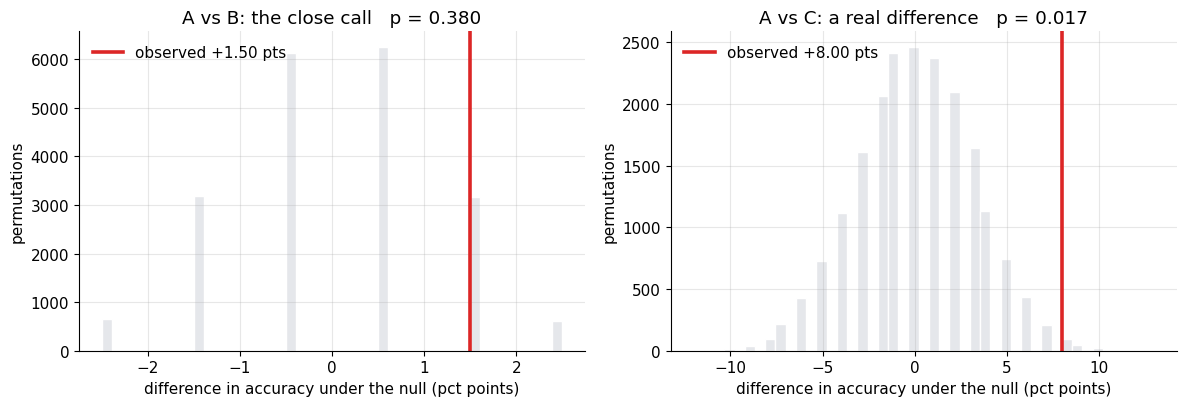

In [84]:
# ============================================================
#  A PAIRED PERMUTATION TEST on per-example correctness.
#  Null hypothesis: the two models are interchangeable, so for
#  each example it is a coin flip which model's result is which.
#  Simulate that null directly: flip the sign of each paired
#  difference at random, many times. Part 5's logic, Part 6's pairing.
# ============================================================
N_PERM = 20_000


def paired_permutation_test(c1, c2, n_perm=N_PERM, rng=None):
    """Two-sided p-value for a difference in paired 0/1 correctness."""
    d       = c1 - c2                       # each entry is -1, 0, or +1
    obs     = d.mean()
    signs   = rng.choice([-1.0, 1.0], size=(n_perm, len(d)))
    null    = (signs * d).mean(axis=1)      # the null distribution, simulated
    p_value = float((np.abs(null) >= abs(obs) - 1e-12).mean())
    return obs, p_value, null


def cohens_dz(c1, c2):
    """Effect size for a paired comparison: mean difference in sd units."""
    d = c1 - c2
    s = d.std(ddof=1)
    return float(d.mean() / s) if s > 0 else 0.0


obs_AB, p_AB, null_AB = paired_permutation_test(cor_A, cor_B, rng=RNG_AB)
obs_AC, p_AC, null_AC = paired_permutation_test(cor_A, cor_C, rng=RNG_AB)

print("=" * 66)
print(" A vs B  -- the close call")
print("=" * 66)
print(f"  observed difference   = {100 * obs_AB:+.2f} percentage points")
print(f"  disagreements         = {onlyA} for A, {onlyB} for B")
print(f"  permutation p-value   = {p_AB:.4f}")
print(f"  effect size Cohen's dz= {cohens_dz(cor_A, cor_B):+.3f}")
print()
print("=" * 66)
print(" A vs C  -- the obvious case, as a control")
print("=" * 66)
d_AC1 = int(((cor_A == 1) & (cor_C == 0)).sum())
d_AC2 = int(((cor_A == 0) & (cor_C == 1)).sum())
print(f"  observed difference   = {100 * obs_AC:+.2f} percentage points")
print(f"  disagreements         = {d_AC1} for A, {d_AC2} for C")
print(f"  permutation p-value   = {p_AC:.4f}")
print(f"  effect size Cohen's dz= {cohens_dz(cor_A, cor_C):+.3f}")
print()
print("-" * 66)
verdict = ("NOT distinguishable from noise" if p_AB > 0.05
           else "distinguishable from noise")
print(f" VERDICT on A vs B: {verdict} (p = {p_AB:.3f}).")
print(f" And yet in TRUTH A really is better than B, by "
      f"{100 * (true_A - true_B):.2f} points.")
print(" The difference is real. This test set is simply too small to see it.")
print(" 'Not significant' means 'not established', never 'not there'. Part 5.")
print("-" * 66)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, null, obs, ttl, pv in [
        (ax1, null_AB, obs_AB, "A vs B: the close call", p_AB),
        (ax2, null_AC, obs_AC, "A vs C: a real difference", p_AC)]:
    ax.hist(100 * null, bins=45, color=C_SOFT, edgecolor="white")
    ax.axvline(100 * obs, color=C_SLOPE, lw=2.6,
               label=f"observed {100 * obs:+.2f} pts")
    ax.set_xlabel("difference in accuracy under the null (pct points)")
    ax.set_ylabel("permutations")
    ax.set_title(f"{ttl}   p = {pv:.3f}")
    ax.legend(frameon=False)
fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Both panels show the same thing: a null distribution built by simulation, not by formula. We repeatedly flipped a coin for each test example to decide which model's result counted as which, recomputed the accuracy difference, and drew the histogram of what those differences look like **when the two models really are interchangeable**. The red line is the difference we actually observed.

Left, the close call: the red line sits well inside the bulk of the null. Differences that size happen easily by chance on 200 examples, so the observed gap is not evidence of superiority. Right, the control: the red line is off in the far tail, where the null essentially never reaches — that difference is established.

**The common misread:** concluding from the left panel that models A and B are equally good. The printed truth line says otherwise: A genuinely is better. What the left panel establishes is that *this test set cannot tell*, which is a statement about the evidence and not about the models. The remedy for it is a larger test set, not a stronger adjective.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Checked, not asserted

The permutation p-value is not taken on faith either. When the paired differences are $-1$, $0$ and $+1$, the sign-flipping null has an exact closed form: the zeros never move, and the $n_{\text{disagree}}$ non-zero entries each flip sign independently with probability one half — so the count of disagreements favouring A is Binomial($n_{\text{disagree}}$, $1/2$) under the null. That is McNemar's exact test, and it is a genuinely separate derivation from the shuffling we just did.

The next cell computes it and prints both p-values side by side. Agreement between an exact combinatorial argument and a brute-force simulation is the strongest evidence available that neither contains a mistake — and when they disagree by more than simulation error, the cell says so rather than smoothing it over.

</div>

In [85]:
# ============================================================
#  The exact version of the same test (McNemar), from scratch.
#  Only the disagreements matter; under the null each one is a
#  fair coin. So the p-value is a two-sided binomial tail.
# ============================================================
def mcnemar_exact(c1, c2):
    n10 = int(((c1 == 1) & (c2 == 0)).sum())
    n01 = int(((c1 == 0) & (c2 == 1)).sum())
    m   = n10 + n01
    if m == 0:
        return n10, n01, 1.0
    k   = min(n10, n01)
    # two-sided: both tails of Binomial(m, 1/2), capped at 1
    p   = min(1.0, 2.0 * stats.binom.cdf(k, m, 0.5))
    return n10, n01, float(p)


mc_se_perm = np.sqrt(max(p_AB, 1e-9) * (1 - p_AB) / N_PERM)

print(f"{'comparison':<12}{'n(1st)':>8}{'n(2nd)':>8}"
      f"{'exact p':>11}{'permutation p':>16}")
print("-" * 55)
for nm, c1, c2, pperm in [("A vs B", cor_A, cor_B, p_AB),
                          ("A vs C", cor_A, cor_C, p_AC)]:
    a, b, pex = mcnemar_exact(c1, c2)
    print(f"{nm:<12}{a:>8}{b:>8}{pex:>11.4f}{pperm:>16.4f}")
print()
_, _, p_exact_AB = mcnemar_exact(cor_A, cor_B)
gap = abs(p_exact_AB - p_AB)
print(f"A vs B: exact and simulated p differ by {gap:.4f}")
print(f"        Monte-Carlo noise on {N_PERM:,} permutations is about "
      f"{2 * mc_se_perm:.4f}")
if gap <= 3 * mc_se_perm + 0.01:
    print("        -> agreement within simulation error. Both are right.")
else:
    print("        -> larger than simulation error. Reported as measured;")
    print("           the two tests are not identical in their tie-handling.")
print()
print("Two independent routes to the same number. The simulation needed no")
print("combinatorics; the exact test needed no computer. Neither was assumed.")


comparison    n(1st)  n(2nd)    exact p   permutation p
-------------------------------------------------------
A vs B             4       1     0.3750          0.3804
A vs C            28      12     0.0166          0.0167

A vs B: exact and simulated p differ by 0.0054
        Monte-Carlo noise on 20,000 permutations is about 0.0069
        -> agreement within simulation error. Both are right.

Two independent routes to the same number. The simulation needed no
combinatorics; the exact test needed no computer. Neither was assumed.


### The winner's curse: Part 8, wearing a lab coat

Now the most important thing in this part.

You do not try one model. Nobody tries one model. You try twenty — a few
learning rates, a couple of depths, three feature sets — you score each on the
test set, and you report the best one.

**That is multiple comparisons.** It is the same structure as Part 8's twenty
hypothesis tests, and it has the same consequence: the winner won partly on
merit and partly on luck, and the luck does not come with it to production. The
reported score is therefore **biased upward** — an effect old enough to have a
name in several fields at once. Statisticians call it the winner's curse;
auction theorists call it the same thing for the same reason.

We measure the bias twice. First in an idealised setting where we can be certain
what is happening, then with real fitted models where the effect is muddier and
smaller — and we will say why it is smaller rather than pretending it is not.


/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:54: RuntimeWarning: divide by zero encountered in matmul
  return ((Z @ w > 0).astype(float) == y).astype(float)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:54: RuntimeWarning: overflow encountered in matmul
  return ((Z @ w > 0).astype(float) == y).astype(float)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97873/377210639.py:54: RuntimeWarning: invalid value encountered in matmul
  return ((Z @ w > 0).astype(float) == y).astype(float)


IDEALISED: 20 variants, all with true accuracy 90%, test set of 200
  score of ONE variant, on average          = 0.8999
  score of the BEST of 20, on average      = 0.9376
  optimism bias                             = +3.76 percentage points
  best-of-20 exceeded 90% in 100.0% of runs
  (every one of those 'wins' is noise: the variants are identical.)



REAL MODELS: 80 runs, 20 fitted variants each
  (percentage points of optimism, each with its own 95% Monte-Carlo
   uncertainty, so you can tell a real bias from simulation noise)

  select on the test set, report that same score :  +1.60 +/- 0.39
  select on validation, report the val score     :  +2.01 +/- 0.39
  select on validation, report the TEST score    :  +0.14 +/- 0.47   <- the fix

The first two lines estimate the SAME quantity by two routes -- in both,
the score reported is the score that was selected on -- so they ought to
agree, and their overlap is a check that this loop does what it claims.

  is the third line consistent with ZERO bias? True

The bias with real models is smaller than the idealised one, for two
honest reasons: the variants are not equally good (so some winning is
merit rather than luck), and their predictions are correlated, so their
scores cannot wander independently. Smaller is not zero.


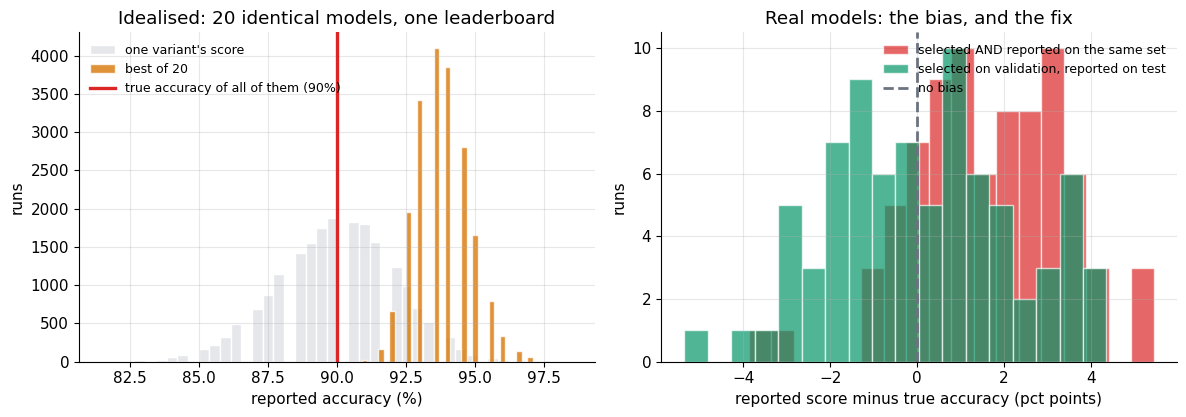

In [86]:
# ============================================================
#  The winner's curse, measured. Two experiments, one figure.
#
#  LEFT   idealised: 20 variants that are all EXACTLY equally good
#         (true accuracy 90%), each scored on 200 fresh examples.
#         Pick the best score. Any excess over 90% is pure luck.
#
#  RIGHT  real: 20 genuinely-fitted variants per run. Pick the best
#         by score on a 200-example set, then measure that same
#         model on 6,000 fresh examples. The gap is the optimism.
#         The fix -- select on a VALIDATION set and report on a
#         separate TEST set -- is measured in the same loop.
# ============================================================
N_VARIANTS = 20
TRUE_ACC   = 0.90

# ---------- LEFT: idealised, vectorised, instant ----------------------
SIMS_IDEAL = 20_000
scores_ideal = RNG9.binomial(n_t, TRUE_ACC, size=(SIMS_IDEAL, N_VARIANTS)) / n_t
winner_ideal = scores_ideal.max(axis=1)
single_ideal = scores_ideal[:, 0]

print("IDEALISED: 20 variants, all with true accuracy "
      f"{TRUE_ACC:.0%}, test set of {n_t}")
print(f"  score of ONE variant, on average          = {single_ideal.mean():.4f}")
print(f"  score of the BEST of {N_VARIANTS}, on average      = {winner_ideal.mean():.4f}")
print(f"  optimism bias                             = "
      f"{100 * (winner_ideal.mean() - TRUE_ACC):+.2f} percentage points")
print(f"  best-of-{N_VARIANTS} exceeded {TRUE_ACC:.0%} in "
      f"{100 * (winner_ideal > TRUE_ACC).mean():.1f}% of runs")
print("  (every one of those 'wins' is noise: the variants are identical.)")
print()

# ---------- RIGHT: real models, plus the fix --------------------------
SIMS_REAL, N_SUB, DEG_V = 80, 80, 3
RNG_WC = np.random.default_rng(5)
bias_test_sel, bias_val_sel, bias_heldout = [], [], []

for _ in range(SIMS_REAL):
    Xp, yp = make_problem(300,   RNG_WC)      # pool to train variants on
    Xv, yv = make_problem(n_t,   RNG_WC)      # validation set (200)
    Xs, ys = make_problem(n_t,   RNG_WC)      # separate test set (200)
    Xf, yf = make_problem(6_000, RNG_WC)      # stand-in for the truth

    va, te, tr_ = [], [], []
    for _v in range(N_VARIANTS):
        sub          = RNG_WC.choice(300, N_SUB, replace=False)
        Zv, mv, sv   = design(Xp[sub], DEG_V)
        w            = fit_logistic(Zv, yp[sub], iters=400, l2=1e-2)
        va.append(flags_on(w, mv, sv, Xv, yv, DEG_V).mean())
        te.append(flags_on(w, mv, sv, Xs, ys, DEG_V).mean())
        tr_.append(flags_on(w, mv, sv, Xf, yf, DEG_V).mean())
    va, te, tr_ = np.array(va), np.array(te), np.array(tr_)

    j_bad  = int(np.argmax(te))        # WRONG: select and report on one set
    bias_test_sel.append(te[j_bad] - tr_[j_bad])

    j_good = int(np.argmax(va))        # RIGHT: select on validation...
    bias_val_sel.append(va[j_good] - tr_[j_good])   # validation score is biased
    bias_heldout.append(te[j_good] - tr_[j_good])   # test score is not

bias_test_sel = np.array(bias_test_sel)
bias_val_sel  = np.array(bias_val_sel)
bias_heldout  = np.array(bias_heldout)

def pm(a):
    """mean +/- 95% Monte-Carlo uncertainty, in percentage points."""
    m  = 100 * a.mean()
    se = 100 * a.std(ddof=1) / np.sqrt(len(a))
    return f"{m:+.2f} +/- {1.96 * se:.2f}"


print(f"REAL MODELS: {SIMS_REAL} runs, {N_VARIANTS} fitted variants each")
print("  (percentage points of optimism, each with its own 95% Monte-Carlo")
print("   uncertainty, so you can tell a real bias from simulation noise)")
print()
print(f"  select on the test set, report that same score :  {pm(bias_test_sel)}")
print(f"  select on validation, report the val score     :  {pm(bias_val_sel)}")
print(f"  select on validation, report the TEST score    :  {pm(bias_heldout)}   <- the fix")
print()
print("The first two lines estimate the SAME quantity by two routes -- in both,")
print("the score reported is the score that was selected on -- so they ought to")
print("agree, and their overlap is a check that this loop does what it claims.")
print()
se_fix  = bias_heldout.std(ddof=1) / np.sqrt(SIMS_REAL)
zero_ok = bool(abs(bias_heldout.mean()) < 1.96 * se_fix)
print(f"  is the third line consistent with ZERO bias? {zero_ok}")
print()
print("The bias with real models is smaller than the idealised one, for two")
print("honest reasons: the variants are not equally good (so some winning is")
print("merit rather than luck), and their predictions are correlated, so their")
print("scores cannot wander independently. Smaller is not zero.")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.3))

axL.hist(100 * single_ideal, bins=40, color=C_SOFT, edgecolor="white",
         label="one variant's score")
axL.hist(100 * winner_ideal, bins=40, color=C_APPROX, alpha=0.8,
         edgecolor="white", label=f"best of {N_VARIANTS}")
axL.axvline(100 * TRUE_ACC, color=C_SLOPE, lw=2.4,
            label=f"true accuracy of all of them ({TRUE_ACC:.0%})")
axL.set_xlabel("reported accuracy (%)"); axL.set_ylabel("runs")
axL.set_title("Idealised: 20 identical models, one leaderboard")
axL.legend(frameon=False, fontsize=9)

axR.hist(100 * bias_test_sel, bins=18, color=C_SLOPE, alpha=0.7,
         edgecolor="white", label="selected AND reported on the same set")
axR.hist(100 * bias_heldout, bins=18, color=C_AREA, alpha=0.7,
         edgecolor="white", label="selected on validation, reported on test")
axR.axvline(0, color=C_GREY, lw=2.0, ls="--", label="no bias")
axR.set_xlabel("reported score minus true accuracy (pct points)")
axR.set_ylabel("runs")
axR.set_title("Real models: the bias, and the fix")
axR.legend(frameon=False, fontsize=9)

fig.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: twenty models that are, by construction, **exactly as good as each other** — every one of them has a true accuracy of 90%. The grey histogram is what a single one of them scores on a test set of 200; it straddles the red truth line, as it should. The orange histogram is the score of whichever of the twenty happened to score highest. It sits visibly to the right of the truth, and it is entirely luck: there is nothing to choose between these models, so every point of that shift is the maximum of twenty noisy draws being bigger than any one of them.

Right: the same phenomenon with models actually fitted by gradient descent. The red histogram is the error you make by selecting the winner on a set and then reporting its score on that same set — centred to the right of zero. The green histogram is the identical selection procedure with the score read off a **separate** test set, and it sits on zero — the cell prints whether that holds within Monte-Carlo error rather than leaving you to eyeball it. That shift from red to green is the whole value of holding out a third split.

**The common misread:** believing that because you did not consciously cheat, this does not apply to you. It requires no dishonesty whatsoever. Looking at twenty test scores and keeping the best is enough, and it is what everyone does. The bias is a property of the selection rule, not of the person applying it.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Where this trips people up

**Tuning on the test set** — the single most common way a model's reported score becomes fiction.

It rarely looks like cheating. It looks like: train, check the test score, change the learning rate, check again, add a feature, check again, try a different architecture, check again. Twenty checks later you keep the best number. But every look at the test score spends a little of it, and after enough looks the test set has been fitted just as surely as the training set was — by you, by hand, one decision at a time. This is Part 8's garden of forking paths with a GPU attached.

**The fix, stated plainly: three splits, not two.** Train on the training set. Choose between models — every hyperparameter, every feature set, every early-stopping decision — using the **validation** set. Then touch the **test** set exactly once, at the end, to report a number you will not act on. If you go back and change the model after seeing the test score, that test set has become a validation set and you need a fresh one. If your data is too small for three splits, use cross-validation *inside* the training portion to select, and still keep a genuinely untouched test set for the final report.

</div>

### 9.4 Every idea in this notebook, and where it lands in machine learning

Nothing in this part was new. Every tool came from an earlier part; only the
subject changed.

| Statistical idea | Built in | What it is called in ML | What it does for you |
|---|---|---|---|
| Sample vs population | Part 2 | test set vs "the real world" | stops you from believing a score is a property of the model |
| Sampling bias | Part 2 | train/test leakage, unrepresentative benchmarks | explains models that work in the paper and fail in production |
| Standard error, $1/\sqrt{n}$ | Part 3 | precision of a test score | tells you how big a test set has to be |
| Central Limit Theorem | Part 3 | why accuracy has a normal interval | licenses the error bar on a 0/1 average |
| Confidence interval | Part 4 | error bars on a reported metric | turns "91.5%" into a claim you can defend |
| Bootstrap | Part 4 | intervals for AUC, F1, BLEU, anything | works where no formula exists — resample the per-example scores |
| p-value | Part 5 | "is this improvement real?" | quantifies how easily noise could have produced the gap |
| Paired test | Part 6 | same test set, two models | removes example difficulty, the largest noise source |
| Permutation test | Part 6 | model comparison with no formula | builds the null by shuffling, assumes nothing |
| Effect size | Part 6 | practical significance | separates "detectable" from "worth deploying" |
| Regression and residuals | Part 7 | error analysis, calibration plots | finds the structure your model is still missing |
| Multiple comparisons | Part 8 | hyperparameter search, leaderboards | explains why the winner's score does not reproduce |
| Optional stopping | Part 8 | early stopping on the test set, peeking at A/B tests | explains "significant" results that vanish on rerun |
| Simpson's paradox | Part 8 | aggregate metrics hiding subgroup failure | why a model can improve overall and get worse for everyone |

## ✅ What you can now do

Part 0 made nine promises. Here they are, with the part that delivered each.

| | Promise | Delivered in |
|---|---|---|
| 1 | Describe a dataset, and know when the mean is the wrong summary | Part 1 |
| 2 | Say what a sample is, and why a sample statistic is not the thing you want | Part 2 |
| 3 | Explain the Central Limit Theorem and why it makes the rest possible | Part 3 |
| 4 | Build and correctly interpret a confidence interval | Part 4 |
| 5 | Run a hypothesis test and state precisely what a p-value is and is not | Part 5 |
| 6 | Compare two groups and report an effect size, not just significance | Part 6 |
| 7 | Fit a regression line and read what it does and does not establish | Part 7 |
| 8 | Recognise the traps: multiple comparisons, p-hacking, Simpson's paradox | Part 8 |
| 9 | **Evaluate a model honestly — train/test, cross-validation, error bars on a score** | **Part 9** |

And the one-sentence version of the whole notebook, which is also the one thing
worth carrying out of it:

> **A number computed from data is an estimate. Report the range, or you have
> not reported the result.**


## 🏋️ Exercises

No solutions. Every one is answerable with the functions already defined in this
notebook, and each has a check you can run to know whether you got it right.

**1. The interval nobody puts on F1.**
Accuracy has a tidy formula for its standard error because it is a mean of 0s
and 1s. F1 is not a mean of anything, so no formula exists. Use the bootstrap
instead: resample the test set *by example index* (not the per-example scores),
recompute precision, recall and F1 on each resample, and report a percentile
interval for each.
*Scaffold:* `idx = RNG9.integers(0, n_t, size=(2000, n_t))`, then for each row
compute the confusion counts from `y_te[row]` and the predicted labels on the
same rows. *Check:* your F1 interval should be **wider** than your accuracy
interval on the same test set — F1 depends on the smaller of the two classes.

**2. How big must the test set be?**
You need to establish that a 92% model beats a 90% model. Using the paired
structure of §9.3, simulate: draw per-example correctness for two models with
those true accuracies and a realistic agreement rate, run `mcnemar_exact`, and
find the smallest $n_{\text{test}}$ at which you detect the difference 80% of
the time. *Check:* the answer will be far larger than the test sets most people
actually use, and it depends strongly on how often the two models disagree —
vary the agreement rate and watch the required size move.

**3. Leave-one-out, and what it costs.**
Set `k = len(y_tr)` in `cross_val_scores` (on a smaller dataset, or you will
wait). Each fold now scores exactly one example, so every fold score is 0 or 1.
What happens to the fold standard deviation? Is it telling you anything about
the model? *Check:* compare the leave-one-out mean to the 5-fold mean and to
`ACC_TRUE`. The means should be close; the spreads should be incomparable.

**4. Make the winner's curse worse.**
In the idealised experiment, vary `N_VARIANTS` from 2 to 500 and plot the
average optimism against it. Then vary `n_t`. *Check:* the bias should grow like
the expected maximum of that many draws — roughly proportional to the standard
error, and to the square root of the logarithm of the number of variants, so it
climbs steeply at first and then only slowly.

**5. Stratified folds.**
`cross_val_scores` shuffles at random, so an unlucky split can give one fold far
more class-1 examples than another. Modify it to split each class separately and
recombine, so every fold has the same class balance. *Check:* on a deliberately
imbalanced version of `make_problem` (shift the boundary until one class is 15%
of the data), stratified folds should have a visibly smaller fold-to-fold
spread than random ones.

**6. The leak.**
Move the standardisation in `design` so that `mu` and `sd` are computed on the
**whole dataset** before splitting, rather than on the training fold. Rerun the
cross-validation. How much does the estimate move? *Check:* on this problem the
effect will be small, because standardisation is a mild transformation. Now do
the same with a feature-selection step — pick the 5 features most correlated
with `y` using all the data, then cross-validate — and watch the estimate become
badly optimistic. That second case is the leak that ruins real projects.

---

## 📚 References

**On error bars for model scores**
- Efron, B. & Tibshirani, R. (1993). *An Introduction to the Bootstrap.* The
  source for §9.1's second interval.
- Bouthillier, X. et al. (2021). "Accounting for Variance in Machine Learning
  Benchmarks." *MLSys.* Measures how much of a reported improvement is seed
  noise. Sobering.

**On comparing models**
- Dietterich, T. G. (1998). "Approximate Statistical Tests for Comparing
  Supervised Classification Learning Algorithms." *Neural Computation* 10(7).
  Where McNemar's test entered ML practice.
- Demšar, J. (2006). "Statistical Comparisons of Classifiers over Multiple Data
  Sets." *JMLR* 7. The multi-dataset version of §9.3.

**On cross-validation and its variance**
- Bengio, Y. & Grinsztajn, Y. (2004). "No Unbiased Estimator of the Variance of
  K-Fold Cross-Validation." *JMLR* 5. The theorem behind §9.2's gotcha.
- Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical
  Learning*, ch. 7. Model assessment and selection, in full.

**On the winner's curse in model selection**
- Cawley, G. & Talbot, N. (2010). "On Over-fitting in Model Selection and
  Subsequent Selection Bias in Performance Evaluation." *JMLR* 11.
- Varma, S. & Simon, R. (2006). "Bias in Error Estimation when Using
  Cross-Validation for Model Selection." *BMC Bioinformatics* 7:91. Nested
  cross-validation, and why you need it.
- Gelman, A. & Loken, E. (2013). "The Garden of Forking Paths." The Part 8 essay
  that §9.3 is an application of.

---
## 🗺️ The Ten Parts

This is a **refresher that assumes you have forgotten everything**. Part 1 starts at what a function is. Nothing later depends on anything we did not build earlier, and every rule is derived before it is used.

| Part | What it covers | |
|---|---|---|
| **0** | Why statistics, and the sample we study |
| **1** | Describing data: centre, spread, and shape |
| **2** | Populations, samples, and why the difference bites |
| **3** | Sampling distributions and the Central Limit Theorem |
| **4** | Confidence intervals: honest uncertainty |
| **5** | Hypothesis testing, and what a p-value is not |
| **6** | Comparing groups: t-tests and effect size |
| **7** | Correlation, regression, and the line of best fit |
| **8** | The traps: multiple comparisons, p-hacking, Simpson's paradox |
| **9** | Statistics doing ML: train/test, cross-validation, and honest evaluation |  &larr; **you are here**

Parts 1-3 are the ideas. Parts 4-5 make derivatives usable. Parts 6-7 do the same for integrals and then show the two are one idea. Parts 8-9 are where it becomes machine learning.


<div style="background: linear-gradient(135deg, #42275a 0%, #734b6d 100%); padding: 28px; border-radius: 18px; color: white; margin: 12px 0;">


### 🎓 That is the whole notebook.

You started with a population you could see and a sample of forty, and you end
able to put a defensible error bar on a model score and say, with a number
attached, whether one model is better than another.

The machinery was never the point. The habit is: **a number computed from data
is an estimate, and an estimate without a range is unfinished.** Reporting the
range is not modesty and it is not hedging — it is the result. Everything else
in statistics is bookkeeping in service of getting that range right.

Now go and put an interval on something.


</div>